In [1]:
import pandas as pd
import numpy as np
import pickle
from ScanImageTiffReader import ScanImageTiffReader
import os
import matplotlib.pyplot as plt
import scipy.signal
from scipy.stats import norm
from tqdm import tqdm
import tifffile
from scipy.signal import butter, lfilter,find_peaks, convolve
from scipy.signal.windows import gaussian
from ibllib.io.video import *
import scipy.ndimage
import cv2
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML
from matplotlib.animation import PillowWriter
from ScanImageTiffReader import ScanImageTiffReader
import json
from murphlib.caimage import *
from murphlib.tools import *
from murphlib.plotting import *
from murphlib.regression import *
from sklearn.decomposition import PCA
from sklearn.metrics import explained_variance_score
from scipy.stats import zscore
import scipy.io
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import seaborn as sns
import ibllib.io.raw_data_loaders as rawio
from ibllib.io.extractors.training_wheel import get_wheel_position, extract_wheel_moves, extract_wheel_velocity
import brainbox.behavior.wheel as wh
plt.rcParams['animation.ffmpeg_path'] = r'D:\ffmpeg\bin\ffmpeg.exe'
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

In [113]:
import gc
plt.close('all')
gc.collect()

1964

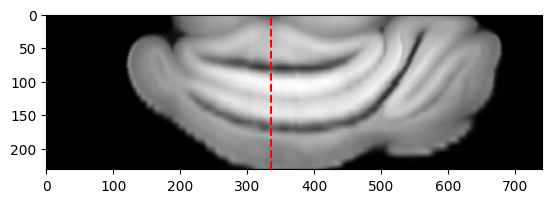

In [2]:
atlas_template = np.load(r'I:\Cerebellum_Imaging_Dec2025\Registration\atlas_template_slice51.npy')
atlas_template = atlas_template[999:1230, 199:940]
plt.imshow(atlas_template, cmap='gray')
plt.axvline(x=335, color='red', linestyle='--')

In [ ]:
tv = np.load(r'D:\Lab_Analysis\allenCCF\template_volume_10um.npy')
atlas_template = create_angled_slice(
        tv, 
        pitch_angle=15,  # 15 degrees nose down
        roll_angle=3,     # roll along ant-post axis, + rolls to the left
        slice_height=65
    )
atlas_template = atlas_template[999:1230, 199:940]
plt.imshow(atlas_template,cmap='gray')

In [3]:
def compute_group_uev_session(
    F,                  # (N_neurons, T)
    design_matrix,      # (T, P)
    ridge_model,        # array/list of length N_neurons, each a dict as above
    group_predictors    # list of *base* names, e.g. ['vis_left_choice_times', 'aud_left_choice_times']
):
    """
    Compute unique explained variance for a *group* of predictors
    (e.g., all lags of vis_left_choice_times + aud_left_choice_times)
    using a drop-group approach.

    F is assumed to be (N, T): neurons x time
    design_matrix is (T, P): time x predictors
    """

    N = len(ridge_model)
    predictors = ridge_model[0]['predictors']  # full shifted predictor names
    P = len(predictors)

    # ---- find indices of all shifted copies for the group ----
    # More strict: require that the predictor name *starts with* the base name
    # or contains it followed by an underscore.
    group_idx = []
    for j, pname in enumerate(predictors):
        for g in group_predictors:
            if g in pname:
                group_idx.append(j)
                break  # don't double-add if two bases match
    group_idx = np.array(sorted(set(group_idx)), dtype=int)
    #print(group_idx)

    if group_idx.size == 0:
        raise ValueError(f"No predictors found for group_predictors={group_predictors}")

    # ---- build beta/intercept arrays ----
    beta = np.zeros((N, P))
    intercepts = np.zeros(N)

    for i, cell in enumerate(ridge_model):
        beta[i, :] = cell['beta']              # (P,)
        intercepts[i] = cell['intercepts']     # scalar

    # ---- compute UEV for the group ----
    uev_group = np.zeros(N)

    # sanity on shapes
    # F: (N, T), design_matrix: (T, P)
    assert design_matrix.shape[1] == P, "Design matrix P mismatch with predictors"
    assert F.shape[1] == design_matrix.shape[0], "Time dimension mismatch between F and design_matrix"

    for i in range(N):
        y = F[i, :]                               # (T,)

        # full model
        y_hat_full = design_matrix @ beta[i, :] + intercepts[i]
        rss_full = np.sum((y - y_hat_full) ** 2)

        # reduced model: zero out all lags of the group predictors
        b_red = beta[i, :].copy()
        b_red[group_idx] = 0.0
        y_hat_red = design_matrix @ b_red + intercepts[i]
        rss_red = np.sum((y - y_hat_red) ** 2)

        # unique explained variance of the *group*
        uev_group[i] = (rss_red - rss_full) / rss_full

    return uev_group

In [11]:
predictors

['vis_ruleCue_times',
 'forward_1frame_vis_ruleCue_times',
 'forward_2frame_vis_ruleCue_times',
 'forward_3frame_vis_ruleCue_times',
 'forward_4frame_vis_ruleCue_times',
 'aud_ruleCue_times',
 'forward_1frame_aud_ruleCue_times',
 'forward_2frame_aud_ruleCue_times',
 'forward_3frame_aud_ruleCue_times',
 'forward_4frame_aud_ruleCue_times',
 'left_vis_stimOn_times',
 'forward_1frame_left_vis_stimOn_times',
 'forward_2frame_left_vis_stimOn_times',
 'forward_3frame_left_vis_stimOn_times',
 'forward_4frame_left_vis_stimOn_times',
 'right_vis_stimOn_times',
 'forward_1frame_right_vis_stimOn_times',
 'forward_2frame_right_vis_stimOn_times',
 'forward_3frame_right_vis_stimOn_times',
 'forward_4frame_right_vis_stimOn_times',
 'left_aud_stimOn_times',
 'forward_1frame_left_aud_stimOn_times',
 'forward_2frame_left_aud_stimOn_times',
 'forward_3frame_left_aud_stimOn_times',
 'forward_4frame_left_aud_stimOn_times',
 'right_aud_stimOn_times',
 'forward_1frame_right_aud_stimOn_times',
 'forward_2frame

In [4]:
agg_data = {}
behav_train_path = r'I:\Cerebellum_imaging_Dec2025\training_data'
ca_img_path = r'I:\Cerebellum_Imaging_Dec2025'
#mouse_ids = ['AE_L2', 'AE_L3', 'AF_R3', 'AF_L2', 'AF_L3', 'AB_R2', 'J_L2', 'A_R2', 'A_R3','O_R2', 'R_L2'] 
#mouse_ids = ['AF_L3', 'AB_R2', 'A_R2', 'A_R3','J_L2', 'AF_L2'] 
mouse_ids = ['AE_L3']
for mouse in mouse_ids:
    mouse_path = os.path.join(ca_img_path, mouse)
    
    subdir = [d for d in os.listdir(mouse_path)]
    dates = [s for s in subdir if (
        s.isdigit() or 
        (s.endswith('_valvesilent') and s[:-12].isdigit()) or
        (s.endswith('_valvesilent_punishsilent') and s[:-25].isdigit())
    )]

    mouse_data = {key: {} for key in dates + ['training']}
    for date in dates:
        session_path = os.path.join(mouse_path, date)
        bhv_path = os.path.join(session_path, 'behavior')
        facemap_folder = os.path.join(bhv_path, 'raw_video_data')
        subdir = [d for d in os.listdir(session_path)]
        if 'arm1' in subdir:
            arm1_img_path = os.path.join(session_path, 'arm1')
            arm1_stat = get_stat_with_coord(arm1_img_path)
            try:
                arm1_ridge_model = np.load(os.path.join(arm1_img_path, 'ridge_model_with_bootstrap_with_vel_lastmove_choice_cv_fixed.npy'), allow_pickle=True)
            except:
                arm1_ridge_model = np.load(os.path.join(arm1_img_path, 'ridge_model_with_bootstrap_with_vel_lastmove_choice.npy'), allow_pickle=True)
            predictors = arm1_ridge_model[0]['predictors']
            unique_predictors = arm1_ridge_model[0]['unique_predictors']
            arm1_stat = attach_reg_model_to_stat(arm1_stat, arm1_ridge_model) # bonferroni correction applied to bootstrap p-values
            mouse_data[date]['arm1'] = {}
            mouse_data[date]['arm1']['stat'] = np.array(arm1_stat, dtype=object)
            mouse_data[date]['arm1']['table_for_img'] = pd.read_csv(arm1_img_path+'\\table_for_regression.csv')
            mouse_data[date]['arm1']['design_matrix'] = np.load(os.path.join(arm1_img_path, 'design_matrix.npy'))
            with open(os.path.join(arm1_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
                    arm1_img_meta = json.load(json_file)
            frame_rate_arm1 = arm1_img_meta['SI.hRoiManager.scanFrameRate']
            arm1_dff = np.load(os.path.join(arm1_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy'))    
            tf_arm1_table_for_img = mouse_data[date]['arm1']['table_for_img']
            arm1_dff_for_video = arm1_dff[:,tf_arm1_table_for_img['ruleCue_times'][0]:tf_arm1_table_for_img['intervals_1'].iloc[-1]]

            X = mouse_data[date]['arm1']['design_matrix']    # (T, P)
            F = arm1_dff_for_video                           # (N, T)

            # Left choice group: all lags of VIS + AUD left choice
            left_group_bases = ['vis_left_choice_times', 'aud_left_choice_times']
            uev_left_choice = compute_group_uev_session(
                F=F,
                design_matrix=X,
                ridge_model=arm1_ridge_model,
                group_predictors=left_group_bases
            )

            # Right choice group: all lags of VIS + AUD right choice
            right_group_bases = ['vis_right_choice_times', 'aud_right_choice_times']
            uev_right_choice = compute_group_uev_session(
                F=F,
                design_matrix=X,
                ridge_model=arm1_ridge_model,
                group_predictors=right_group_bases
            )
            idx_visL = unique_predictors.index('vis_left_choice_times')
            idx_audL = unique_predictors.index('aud_left_choice_times')
            idx_visR = unique_predictors.index('vis_right_choice_times')
            idx_audR = unique_predictors.index('aud_right_choice_times')
            # Attach as last two elements of each neuron's unique_explained_variance
            stat_arr = mouse_data[date]['arm1']['stat']
            for i, st in enumerate(stat_arr):
                uev_old = st['unique_explained_variance']

                # ensure it's an array
                uev_old_arr = np.asarray(uev_old)
                uev_new = np.concatenate([
                    uev_old_arr,
                    np.array([uev_left_choice[i], uev_right_choice[i]])
                ])

                st['unique_explained_variance'] = uev_new

                pvals = np.asarray(st['bootstrap_p_value'])

                p_visL = pvals[idx_visL]
                p_audL = pvals[idx_audL]
                p_visR = pvals[idx_visR]
                p_audR = pvals[idx_audR]

                # conservative group p-values: require both modalities to be significant
                p_left_group = max(p_visL, p_audL)
                p_right_group = max(p_visR, p_audR)

                # append as last two entries
                p_new = np.concatenate([pvals, np.array([p_left_group, p_right_group])])
                st['bootstrap_p_value'] = p_new
            mouse_data[date]['arm1']['unique_predictors_extended'] = list(unique_predictors) + ['left_choice_group', 'right_choice_group']
        if 'arm2' in subdir:
            arm2_img_path = os.path.join(session_path, 'arm2')
            arm2_stat = get_stat_with_coord(arm2_img_path)
            try:
                arm2_ridge_model = np.load(os.path.join(arm2_img_path, 'ridge_model_with_bootstrap_with_vel_lastmove_choice_cv_fixed.npy'), allow_pickle=True)
            except:
                arm2_ridge_model = np.load(os.path.join(arm2_img_path, 'ridge_model_with_bootstrap_with_vel_lastmove_choice.npy'), allow_pickle=True)
            predictors = arm2_ridge_model[0]['predictors']
            unique_predictors = arm2_ridge_model[0]['unique_predictors']
            arm2_stat = attach_reg_model_to_stat(arm2_stat, arm2_ridge_model) # bonferroni correction applied to bootstrap p-values
            mouse_data[date]['arm2'] = {}
            mouse_data[date]['arm2']['stat'] = np.array(arm2_stat, dtype=object)
            mouse_data[date]['arm2']['table_for_img'] = pd.read_csv(arm2_img_path+'\\table_for_regression.csv')
            mouse_data[date]['arm2']['design_matrix'] = np.load(os.path.join(arm2_img_path, 'design_matrix.npy'))
            with open(os.path.join(arm2_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
                    arm2_img_meta = json.load(json_file)
            frame_rate_arm2 = arm2_img_meta['SI.hRoiManager.scanFrameRate']
            arm2_dff = np.load(os.path.join(arm2_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy'))    
            tf_arm2_table_for_img = mouse_data[date]['arm2']['table_for_img']
            arm2_dff_for_video = arm2_dff[:,tf_arm2_table_for_img['ruleCue_times'][0]:tf_arm2_table_for_img['intervals_1'].iloc[-1]]

            X = mouse_data[date]['arm2']['design_matrix']    # (T, P)
            F = arm2_dff_for_video                           # (N, T)

            # Left choice group: all lags of VIS + AUD left choice
            left_group_bases = ['vis_left_choice_times', 'aud_left_choice_times']
            uev_left_choice = compute_group_uev_session(
                F=F,
                design_matrix=X,
                ridge_model=arm2_ridge_model,
                group_predictors=left_group_bases
            )

            # Right choice group: all lags of VIS + AUD right choice
            right_group_bases = ['vis_right_choice_times', 'aud_right_choice_times']
            uev_right_choice = compute_group_uev_session(
                F=F,
                design_matrix=X,
                ridge_model=arm2_ridge_model,
                group_predictors=right_group_bases
            )
            idx_visL = unique_predictors.index('vis_left_choice_times')
            idx_audL = unique_predictors.index('aud_left_choice_times')
            idx_visR = unique_predictors.index('vis_right_choice_times')
            idx_audR = unique_predictors.index('aud_right_choice_times')
            # Attach as last two elements of each neuron's unique_explained_variance
            stat_arr = mouse_data[date]['arm2']['stat']
            for i, st in enumerate(stat_arr):
                uev_old = st['unique_explained_variance']

                # ensure it's an array
                uev_old_arr = np.asarray(uev_old)
                uev_new = np.concatenate([
                    uev_old_arr,
                    np.array([uev_left_choice[i], uev_right_choice[i]])
                ])

                st['unique_explained_variance'] = uev_new

                pvals = np.asarray(st['bootstrap_p_value'])

                p_visL = pvals[idx_visL]
                p_audL = pvals[idx_audL]
                p_visR = pvals[idx_visR]
                p_audR = pvals[idx_audR]

                # conservative group p-values: require both modalities to be significant
                p_left_group = max(p_visL, p_audL)
                p_right_group = max(p_visR, p_audR)

                # append as last two entries
                p_new = np.concatenate([pvals, np.array([p_left_group, p_right_group])])
                st['bootstrap_p_value'] = p_new


        mouse_data[date]['pupil_area'] = np.load(os.path.join(facemap_folder, 'pupil_area.npy')) # synced to table for video
        mouse_data[date]['pupil_xpos'] = np.load(os.path.join(facemap_folder, 'pupil_xpos.npy'))
        mouse_data[date]['pupil_ypos'] = np.load(os.path.join(facemap_folder, 'pupil_ypos.npy'))
        mouse_data[date]['body_motion'] = np.load(os.path.join(facemap_folder, 'bodymotion_svd.npy'))
        mouse_data[date]['face_motion'] = np.load(os.path.join(facemap_folder, 'facemotion_svd.npy'))
        mouse_data[date]['lick'] = np.load(os.path.join(facemap_folder, 'lickmotion_svd.npy'))
        mouse_data[date]['pupil_area'] = fill_nan_with_previous(mouse_data[date]['pupil_area'])
        mouse_data[date]['pupil_xpos'] = fill_nan_with_previous(mouse_data[date]['pupil_xpos'])
        mouse_data[date]['pupil_ypos'] = fill_nan_with_previous(mouse_data[date]['pupil_ypos'])
        mouse_data[date]['table_for_video'] = pd.read_csv(bhv_path+'\\table_for_video.csv')
        mouse_data[date]['trials_table'] = pd.read_parquet(bhv_path+'\\alf\\_ibl_trials.table.pqt')
        
        bpod_trials = rawio.load_data(bhv_path, task_collection='raw_behavior_data')
        ts, pos = get_wheel_position(bhv_path, bpod_trials, task_collection='raw_behavior_data')
        interp_pos, interp_ts = wh.interpolate_position(ts, pos, freq=1000)
        wheel_moves = extract_wheel_moves(ts, pos, display=False)
        mouse_data[date]['wheel_vel'] = extract_wheel_velocity(interp_pos) # synced to trials table
        mouse_data[date]['wheel_ts'] = interp_ts
        mouse_data[date]['wheel_pos'] = interp_pos
    
    os.makedirs(os.path.join(mouse_path, 'figures'), exist_ok=True)
    mouse_data['training']['accuracies_vis'] = np.load(os.path.join(behav_train_path,mouse, 'accuracies_vis.npy')) 
    mouse_data['training']['accuracies_aud'] = np.load(os.path.join(behav_train_path,mouse, 'accuracies_aud.npy'))
    mouse_data['training']['num_trials'] = np.load(os.path.join(behav_train_path,mouse, 'num_trials.npy'))  
    mouse_data['training']['training_dates'] = np.load(os.path.join(behav_train_path,mouse, 'training_dates.npy'))
    psth_time_start = -0.4
    psth_time_end = 1.2
    event_preds = unique_predictors[:15]
    
    
    for predi, pred in enumerate(event_preds):
        pred_idx = [i for i, name in enumerate(predictors) if pred in name]
        for dayi, date in enumerate(dates):
            session_path = os.path.join(mouse_path, date)
            if 'arm1' in mouse_data[date]:
                arm1_img_path = os.path.join(session_path, 'arm1')
                arm1_table_for_img = pd.read_csv(arm1_img_path+'\\table_for_img.csv')
                with open(os.path.join(arm1_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
                    arm1_img_meta = json.load(json_file)
                frame_rate_arm1 = arm1_img_meta['SI.hRoiManager.scanFrameRate']
                arm1_dff = np.load(os.path.join(arm1_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy'))    
                tf_arm1_table_for_img = mouse_data[date]['arm1']['table_for_img']
                arm1_bsl_psth_frame_idx = find_frame_indices(tf_arm1_table_for_img, frame_rate_arm1, (-0.4, -0.067), 'ruleCueTrigger_times').astype(int)
                arm1_bsl_psth = get_trial_PSTH(arm1_dff, arm1_bsl_psth_frame_idx, zscore=False).transpose(1, 0, 2)
                arm1_bsl_psth = arm1_bsl_psth.reshape(arm1_bsl_psth.shape[0], -1)
                arm1_bsl_mean = np.mean(arm1_bsl_psth, axis=1)
                arm1_bsl_sd = np.std(arm1_bsl_psth, axis=1)
                psth_frame_idx = find_frame_indices(tf_arm1_table_for_img, frame_rate_arm1, (psth_time_start, psth_time_end), pred).astype(int)
                if len(psth_frame_idx) != 0:
                    all_psth = get_trial_PSTH(arm1_dff, psth_frame_idx, zscore=False)
                    z_psth = (all_psth - arm1_bsl_mean[np.newaxis, :, np.newaxis]) / arm1_bsl_sd[np.newaxis, :, np.newaxis]
                    mean_psth = np.mean(all_psth, axis=0)
                    mean_z_psth = np.mean(z_psth, axis=0)
                    for i, neuron in enumerate(mouse_data[date]['arm1']['stat']):
                        beta = neuron['beta'][pred_idx]
                        neuron[pred+'_beta'] = beta
                        neuron[pred+'_psth_raw'] = np.squeeze(all_psth[:,i,:])
                        neuron[pred+'_psth'] = np.squeeze(z_psth[:,i,:])
            if 'arm2' in mouse_data[date]:  
                arm2_img_path = os.path.join(session_path, 'arm2')
                arm2_table_for_img = pd.read_csv(arm2_img_path+'\\table_for_img.csv')
                with open(os.path.join(arm2_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
                    arm2_img_meta = json.load(json_file)
                frame_rate_arm2 = arm2_img_meta['SI.hRoiManager.scanFrameRate']
                arm2_dff = np.load(os.path.join(arm2_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy')) 
                tf_arm2_table_for_img = mouse_data[date]['arm2']['table_for_img']
                arm2_bsl_psth_frame_idx = find_frame_indices(tf_arm2_table_for_img, frame_rate_arm2, (-0.4, -0.067), 'ruleCueTrigger_times').astype(int)
                arm2_bsl_psth = get_trial_PSTH(arm2_dff, arm2_bsl_psth_frame_idx, zscore=False).transpose(1, 0, 2)
                arm2_bsl_psth = arm2_bsl_psth.reshape(arm2_bsl_psth.shape[0], -1)
                arm2_bsl_mean = np.mean(arm2_bsl_psth, axis=1)
                arm2_bsl_sd = np.std(arm2_bsl_psth, axis=1)
                psth_frame_idx = find_frame_indices(tf_arm2_table_for_img, frame_rate_arm2, (psth_time_start, psth_time_end), pred).astype(int)
                if len(psth_frame_idx) != 0:
                    all_psth = get_trial_PSTH(arm2_dff, psth_frame_idx, zscore=False)
                    z_psth = (all_psth - arm2_bsl_mean[np.newaxis, :, np.newaxis]) / arm2_bsl_sd[np.newaxis, :, np.newaxis]
                    mean_psth = np.mean(all_psth, axis=0)
                    mean_z_psth = np.mean(z_psth, axis=0)
                    for i, neuron in enumerate(mouse_data[date]['arm2']['stat']):
                        beta = neuron['beta'][pred_idx]
                        neuron[pred+'_beta'] = beta
                        neuron[pred+'_psth_raw'] = np.squeeze(all_psth[:,i,:])
                        neuron[pred+'_psth'] = np.squeeze(z_psth[:,i,:])
    agg_data[mouse] = mouse_data
    

2026-01-08 10:55:25.745 WARNING  [raw_data_loaders.py:655] _iblrig_encoderPositions.raw.ssv rotary encoder timestamps swapped at index: 113967  I:\Cerebellum_Imaging_Dec2025\AE_L3\20250617_valvesilent\behavior\raw_behavior_data\_iblrig_encoderPositions.raw.ssv
2026-01-08 10:57:50.483 WARNING  [raw_data_loaders.py:655] _iblrig_encoderPositions.raw.ssv rotary encoder timestamps swapped at index: 66038  I:\Cerebellum_Imaging_Dec2025\AE_L3\20250722_valvesilent\behavior\raw_behavior_data\_iblrig_encoderPositions.raw.ssv
2026-01-08 10:57:50.489 WARNING  [raw_data_loaders.py:655] _iblrig_encoderPositions.raw.ssv rotary encoder timestamps swapped at index: 177585  I:\Cerebellum_Imaging_Dec2025\AE_L3\20250722_valvesilent\behavior\raw_behavior_data\_iblrig_encoderPositions.raw.ssv


['vis_ruleCue_times',
 'aud_ruleCue_times',
 'left_vis_stimOn_times',
 'right_vis_stimOn_times',
 'left_aud_stimOn_times',
 'right_aud_stimOn_times',
 'vis_left_choice_times',
 'vis_right_choice_times',
 'aud_left_choice_times',
 'aud_right_choice_times',
 'vis_reward_times',
 'aud_reward_times',
 'vis_punish_times',
 'aud_punish_times',
 'omission_times',
 'previous_feedbackType',
 'reward_history',
 'body',
 'lick',
 'face',
 'pupil_area',
 'pupil_xpos',
 'pupil_ypos',
 'vel']

In [6]:
def rolling_average(data, window_size):
    result = np.empty_like(data, dtype=float)
    
    for i in range(len(data)):
        start_idx = max(0, i - window_size + 1)
        result[i] = np.mean(data[start_idx:i+1])
    
    return result


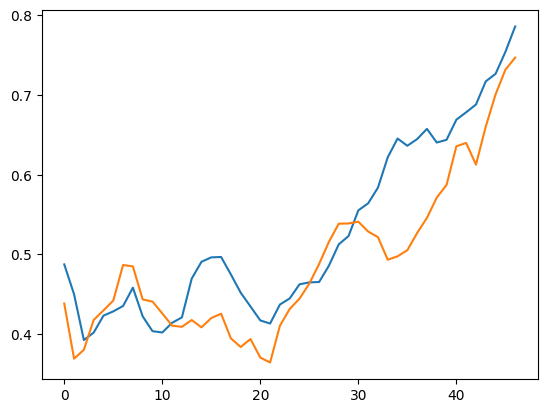

In [7]:
vis_perf = rolling_average(agg_data['AE_L2']['training']['accuracies_vis'],5)
aud_perf = rolling_average(agg_data['AE_L2']['training']['accuracies_aud'],5)
plt.plot(vis_perf)
plt.plot(aud_perf)

In [ ]:
agg_data['AE_L2']['20250821_valvesilent_punishsilent']['arm1']['stat'][0]['ycoord_atlas']

0        105.0
1        182.0
2        266.0
3        364.0
4        448.0
        ...   
249    27230.0
250    27326.0
251    27408.0
252        NaN
253        NaN
Name: firstMovement_times, Length: 254, dtype: float64

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# -------------------------------
# Utility helpers
# -------------------------------

def rolling_average(x, w=3):
    x = np.asarray(x, dtype=float)
    if w <= 1 or x.size == 0:
        return x
    pad = np.pad(x, (w-1, 0), mode='edge')
    c = np.cumsum(pad)
    out = (c[w:] - c[:-w]) / w
    head = np.full(w-1, out[0])
    return np.concatenate([head, out])

def classify_day_stage(vis_perf, aud_perf, vis_raw, aud_raw, perf_thresh=0.65):
    """
    Returns: 'naive' | 'vis_expert' | 'aud_expert' | 'db_expert'
    Prefers rolling perf; falls back to raw day perf.
    """
    v = float(vis_perf) if np.isfinite(vis_perf) else float(vis_raw)
    a = float(aud_perf) if np.isfinite(aud_perf) else float(aud_raw)
    v_ok = (v > perf_thresh) or (vis_raw > perf_thresh)
    a_ok = (a > perf_thresh) or (aud_raw > perf_thresh)
    if v_ok and a_ok:   return 'db_expert'
    if v_ok and not a_ok: return 'vis_expert'
    if a_ok and not v_ok: return 'aud_expert'
    return 'naive'

def robust_symmetric_clim(maps, pct=99.0, fallback=0.01):
    vals = []
    for m in maps:
        if m is None: 
            continue
        v = m[np.isfinite(m)]
        if v.size:
            vals.append(np.abs(v).ravel())
    if not vals:
        return (-fallback, fallback)
    allabs = np.concatenate(vals)
    lim = np.percentile(allabs, pct)
    lim = max(lim, fallback)
    return (-lim, lim)

# -------------------------------
# Rasterization (per-pixel) bins
# -------------------------------

def _bin_edges_from_extent(xlim, ylim, binsize):
    nbx = max(2, int(np.ceil((xlim[1] - xlim[0]) / binsize)))
    nby = max(2, int(np.ceil((ylim[1] - ylim[0]) / binsize)))
    xedges = np.linspace(xlim[0], xlim[1], nbx+1)
    yedges = np.linspace(ylim[0], ylim[1], nby+1)
    return xedges, yedges, nbx, nby

def rasterize_dendrites_full_atlas(
    neurons,
    atlas_shape,              # (H, W) from atlas_template.shape
    downsample=4,
    min_count=10,
    smooth_sigma_bins=1.0,
    weighting='length'        # 'length' | 'unit' | 'none'
):
    """
    Rasterizes dendrite pixels over the FULL atlas (0..W, 0..H) on a downsampled grid.
    Returns:
      H_mean (ny_ds, nx_ds), H_count (ny_ds, nx_ds), extent=[0,W,0,H]
    """
    H, W = map(int, atlas_shape)
    assert H > 0 and W > 0

    # downsampled grid size
    nx_ds = (W + downsample - 1) // downsample
    ny_ds = (H + downsample - 1) // downsample
    nb = nx_ds * ny_ds

    H_count_flat = np.zeros(nb, dtype=np.float32)
    H_sum_flat   = np.zeros(nb, dtype=np.float32)

    inv_ds = 1.0 / float(downsample)

    for neu in neurons:
        x = np.asarray(neu['xcoord_atlas']).ravel().astype(np.int64)  # columns
        y = np.asarray(neu['ycoord_atlas']).ravel().astype(np.int64)  # rows
        d = float(neu['data'])
        if x.size == 0 or y.size == 0 or not np.isfinite(d):
            continue

        # Clip to full atlas bounds
        ok = (x >= 0) & (x < W) & (y >= 0) & (y < H)
        if not np.any(ok):
            continue
        x = x[ok]; y = y[ok]

        # Downsampled bin indices in full field
        ix_ds = (x * inv_ds).astype(np.int64)  # 0..nx_ds-1
        iy_ds = (y * inv_ds).astype(np.int64)  # 0..ny_ds-1
        lin = (iy_ds * nx_ds + ix_ds)

        # Unique bins hit by this neuron + pixel counts
        u, c = np.unique(lin, return_counts=True)

        if weighting == 'unit':
            total = c.sum()
            wcounts = (c / total).astype(np.float32) if total > 0 else np.zeros_like(c, dtype=np.float32)
        elif weighting == 'none':
            wcounts = np.ones_like(c, dtype=np.float32)
        else:  # 'length'
            wcounts = c.astype(np.float32)

        H_count_flat[u] += wcounts
        H_sum_flat[u]   += wcounts * d

    with np.errstate(invalid='ignore', divide='ignore'):
        H_mean_flat = H_sum_flat / H_count_flat

    H_count = H_count_flat.reshape(ny_ds, nx_ds)
    H_mean  = H_mean_flat.reshape(ny_ds, nx_ds)

    # Mask sparse bins
    H_mean[H_count < min_count] = np.nan

    # Optional smoothing preserving NaNs
    if smooth_sigma_bins and smooth_sigma_bins > 0:
        mask = np.isfinite(H_mean)
        Hf = np.where(mask, H_mean, 0.0)
        wf = gaussian_filter(mask.astype(float), smooth_sigma_bins, mode='nearest')
        hf = gaussian_filter(Hf, smooth_sigma_bins, mode='nearest')
        H_mean = np.where(wf > 1e-9, hf / wf, np.nan)

    extent = [0, W, 0, H]
    return H_mean, H_count, extent


def make_stage_maps_rasterized_full_atlas(
    agg_data,
    mouse_ids,
    atlas_template,               # 2D background image
    pred_name,
    unique_predictors,
    full_predictors,
    perf_thresh=0.65,
    downsample=4,                 # spatial downsample factor
    smooth_sigma_bins=1.0,
    min_count=10,
    zscore_within_session=False,
    frame_reduction='mean',       # 'mean' or 'sum' across predictor lags
    weighting='length',            # 'length'|'unit'|'none'
    data_type='beta',
    clim = (-0.02, 0.02)
):
    """
    2x2 stage maps on the FULL atlas field using per-pixel rasterization.
    """
    
    unique_pred_idx = unique_predictors.index(pred_name)
    H, W = atlas_template.shape
    pooled = {k: [] for k in ['naive','vis_expert','aud_expert','db_expert']}

    for mouse in mouse_ids:
        md = agg_data[mouse]
        vis_acc = np.asarray(md['training']['accuracies_vis'])
        aud_acc = np.asarray(md['training']['accuracies_aud'])
        tr_dates = np.asarray(md['training']['training_dates'])
        vis_roll = rolling_average(vis_acc, w=3)
        aud_roll = rolling_average(aud_acc, w=3)

        img_dates = [s for s in md.keys() if (s.isdigit()
                   or (s.endswith('_valvesilent') and s.replace('_valvesilent','').isdigit())
                   or (s.endswith('_valvesilent_punishsilent') and s.replace('_valvesilent_punishsilent','').isdigit()))]

        for date in img_dates:
            #print('Aggregating mouse ' + mouse + ' date: ' + date + '...')
            if 'valvesilent' not in date and 'reward' in pred_name:
                print('Skipping ' + mouse + ' date: ' + date + ' for reward...')
                continue
            if 'punishsilent' not in date and 'punish' in pred_name:
                print('Skipping ' + mouse + ' date: ' + date + ' for punish...')
                continue
            idx = np.where(tr_dates == date[:8])[0]
            if idx.size == 0:
                continue
            di = int(idx[0])
            stage = classify_day_stage(vis_roll[di], aud_roll[di], vis_acc[di], aud_acc[di], perf_thresh)

            session_neurons, session_data = [], []
            for arm in ['arm1','arm2']:
                if arm not in md[date]:
                    continue
                for neuron in md[date][arm]['stat']:
                    if data_type == 'beta':
                        pred_idx = [i for i, nm in enumerate(predictors) if pred_name in nm]
                        if not pred_idx:
                            raise ValueError(f"Predictor '{pred_name}' not found in predictors list.")
                        beta_arr = np.asarray(neuron['beta'])[pred_idx].reshape(-1)
                        d = float(np.nanmean(beta_arr)) if frame_reduction == 'mean' else float(np.nansum(beta_arr))
                    elif data_type == 'r2':
                        d = neuron['unique_explained_variance'][unique_pred_idx]
                    p_value = neuron['bootstrap_p_value'][unique_pred_idx]
                    if p_value > 0.05:
                        d = 0
                    x = np.asarray(neuron['xcoord_atlas']).ravel()
                    y = np.asarray(neuron['ycoord_atlas']).ravel()
                    if x.size == 0 or y.size == 0 or not np.isfinite(d):
                        continue

                    session_neurons.append({'xcoord_atlas': x, 'ycoord_atlas': y, 'data': d})
                    session_data.append(d)

            if not session_neurons:
                continue

            if zscore_within_session:
                sb = np.asarray(session_data, dtype=float)
                mu = np.nanmean(sb); sd = np.nanstd(sb)
                zsb = np.zeros_like(sb) if (not np.isfinite(sd) or sd == 0.0) else (sb - mu) / sd
                for i in range(len(session_neurons)):
                    session_neurons[i]['data'] = float(zsb[i])

            pooled[stage].extend(session_neurons)

    # Build maps per stage on the FULL atlas
    stage_maps = {}
    extent = [0, W, 0, H]
    for stage in ['naive','vis_expert','aud_expert','db_expert']:
        print('build map for ' + stage + '...')
        neurons = pooled[stage]
        if not neurons:
            stage_maps[stage] = None
            continue
        H_mean, H_count, _ = rasterize_dendrites_full_atlas(
            neurons=neurons,
            atlas_shape=atlas_template.shape,
            downsample=downsample,
            min_count=min_count,
            smooth_sigma_bins=smooth_sigma_bins,
            weighting=weighting
        )
        stage_maps[stage] = H_mean

    # Color limits shared across panels
    #vmin, vmax = robust_symmetric_clim([stage_maps[s] for s in stage_maps], pct=99.0, fallback=0.01)
    if data_type == 'beta':
        vmin, vmax = clim
    elif data_type == 'r2':
        vmin, vmax = clim

    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
    panel_order  = ['naive','vis_expert','aud_expert','db_expert']
    panel_titles = ['Naive','Vis expert','Aud expert','Double expert']
    im_last = None

    for ax, stg, title in zip(axes.ravel(), panel_order, panel_titles):
        ax.imshow(atlas_template, cmap='gray', extent=[0, W, 0, H], origin='upper')
        Hm = stage_maps[stg]
        if Hm is not None:
            im_last = ax.imshow(
                Hm, cmap='coolwarm', vmin=vmin, vmax=vmax,
                extent=extent, origin='upper', alpha=0.9, interpolation='nearest'
            )
        ax.set_aspect('equal', adjustable='box')
        ax.set_title(title, fontsize=14)
        ax.set_xticks([]); ax.set_yticks([])

    if im_last is not None:
        cbar = fig.colorbar(im_last, ax=axes.ravel().tolist(), shrink=0.8)
        cbar.set_label(f"Mean β for '{pred_name}'" + (" (z-scored per session)" if zscore_within_session else ""), rotation=90)

    return fig, axes, stage_maps, extent

In [ ]:
psth

In [6]:
def draw_roi_polygon(atlas_template, roi_name, color='C0'):
    """
    Interactively draw a polygon ROI on atlas_template.

    Click vertices in order; press Enter or right-click to finish.
    Returns an (N, 2) array of (x, y) polygon vertices in atlas coordinates.
    """
    H, W = atlas_template.shape
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(atlas_template, cmap='gray', extent=[0, W, 0, H], origin='upper')
    ax.set_title(f"Draw ROI for: {roi_name}\nLeft-click vertices, Enter to finish")
    ax.set_xticks([]); ax.set_yticks([])

    pts = plt.ginput(n=-1, timeout=0)  # click until Enter
    plt.close(fig)

    if len(pts) < 3:
        raise ValueError(f"Not enough points for ROI '{roi_name}'")

    verts = np.array(pts, dtype=float)  # shape (N, 2)
    return verts

def draw_multiple_rois(atlas_template, roi_names):
    """
    Loop over roi_names and let user draw each ROI polygon.
    Returns: dict roi_name -> (N, 2) array of vertices.
    """
    roi_polygons = {}
    for name in roi_names:
        verts = draw_roi_polygon(atlas_template, name)
        roi_polygons[name] = verts
    return roi_polygons

In [6]:
%matplotlib tk

In [7]:
roi_names = ['simplex', 'crus_I', 'lob_V', 'lob_VI']
roi_polygons = draw_multiple_rois(atlas_template, roi_names)

# Save once so you don't redraw every time
np.savez(os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m', 'roi_polygons.npz'), **{k: v for k, v in roi_polygons.items()})

In [7]:
loaded = np.load(os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m', 'roi_polygons.npz'), allow_pickle=True)
roi_polygons = {k: loaded[k] for k in loaded.files}

In [8]:
%matplotlib inline

In [9]:
from matplotlib.path import Path

def polygon_to_mask(verts, atlas_shape):
    """
    verts: (N, 2) array of (x, y) in atlas coords (as returned by ginput on
           an imshow(..., extent=[0,W,0,H], origin='upper'))
    atlas_shape: (H, W)
    Returns: mask (H, W) with True inside polygon.
    """
    H, W = atlas_shape

    # pixel centers in *image index* space
    x_idx, y_idx = np.meshgrid(
        np.arange(W) + 0.5,      # columns
        np.arange(H) + 0.5       # rows
    )

    # convert row indices to the SAME y coordinates used when drawing:
    # origin='upper' + extent=[0,W,0,H] → row 0 is at y = H, row H-1 at y = 0
    y_world = H - y_idx         # flip vertically
    x_world = x_idx

    pts = np.vstack([x_world.ravel(), y_world.ravel()]).T  # (H*W, 2)

    path = Path(verts)
    inside = path.contains_points(pts)
    mask = inside.reshape(H, W)
    return mask

def polygons_to_masks(roi_polygons, atlas_shape):
    """
    roi_polygons: dict roi_name -> (N,2) array of vertices
    Returns: dict roi_name -> mask (H,W)
    """
    masks = {}
    for name, verts in roi_polygons.items():
        masks[name] = polygon_to_mask(verts, atlas_shape)
    return masks

In [10]:
roi_masks_full = polygons_to_masks(roi_polygons, atlas_template.shape)
# fig, ax = plt.subplots()
# H, W = atlas_template.shape
# ax.imshow(atlas_template, cmap='gray', extent=[0, W, 0, H], origin='upper', zorder=0)

# base = [plt.cm.Reds, plt.cm.Blues, plt.cm.Purples, plt.cm.Oranges]
# for i, roi in enumerate(roi_masks_full.keys()):
#     cmap = base[i % len(base)].copy()
#     cmap.set_under((0, 0, 0, 0))             # fully transparent for values < vmin
#     mask = roi_masks_full[roi].astype(float)
#     ax.imshow(mask, cmap=cmap, alpha=0.3, vmin=0.5,          # 0 is “under” => transparent
#               extent=[0, W, 0, H], origin='upper', interpolation='none', zorder=1)

# ax.set_xlim(0, W); ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal')

# fig.savefig(
#     os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig2', "roi_mask.svg"),
#     format='svg',
#     dpi=300,
#     bbox_inches='tight',
#     transparent=True,   # optional: removes white background
#     metadata={'Creator': 'Matplotlib'}
# )

In [11]:
def downsample_mask(mask, downsample):
    """
    mask: (H, W) boolean
    downsample: same factor as used for rasterize_dendrites_full_atlas
    Returns: ds_mask (ny_ds, nx_ds) boolean
             True if any full-res pixel in that bin is inside ROI.
    """
    H, W = mask.shape
    ny_ds = (H + downsample - 1) // downsample
    nx_ds = (W + downsample - 1) // downsample
    ds_mask = np.zeros((ny_ds, nx_ds), dtype=bool)

    for iy in range(ny_ds):
        for ix in range(nx_ds):
            y0 = iy * downsample
            y1 = min((iy + 1) * downsample, H)
            x0 = ix * downsample
            x1 = min((ix + 1) * downsample, W)
            patch = mask[y0:y1, x0:x1]
            if patch.size > 0 and patch.any():
                ds_mask[iy, ix] = True
    return ds_mask

def make_downsampled_roi_masks(roi_masks_full, downsample):
    """
    roi_masks_full: dict roi_name -> mask (H,W)
    Returns: dict roi_name -> ds_mask (ny_ds, nx_ds)
    """
    ds_masks = {}
    for name, m in roi_masks_full.items():
        ds_masks[name] = downsample_mask(m, downsample)
    return ds_masks

In [12]:
downsample = 2  # same as in make_stage_maps_rasterized_full_atlas
roi_masks_ds = make_downsampled_roi_masks(roi_masks_full, downsample)

In [7]:
agg_data['AE_L2']['20250612']['arm1']['stat'][0]['ycoord_atlas']

array([40.75560414, 40.75681622, 40.7580283 , 40.90587839, 40.90709047,
       40.90830255, 40.90951463, 40.91072671, 40.91193879, 40.91315087,
       41.05736471, 41.05857679, 41.05978887, 41.06100095, 41.06221303,
       41.06342511, 41.06463719, 41.21006312, 41.2112752 , 41.21248728,
       41.21369936, 41.21491144, 41.21612352, 41.2173356 , 41.21854768,
       41.36033737, 41.36154945, 41.36276153, 41.36397361, 41.36518569,
       41.36639777, 41.36760985, 41.36882193, 41.37003401, 41.37124609,
       41.51303578, 41.51424786, 41.51545994, 41.51667202, 41.5178841 ,
       41.51909618, 41.52030826, 41.52152034, 41.52273242, 41.5239445 ,
       41.66452211, 41.66573419, 41.66694627, 41.66815835, 41.66937043,
       41.67058251, 41.67179459, 41.67300667, 41.67421875, 41.67543083,
       41.67664291, 41.81722051, 41.81843259, 41.81964467, 41.82085675,
       41.82206883, 41.82328091, 41.82449299, 41.82570507, 41.82691715,
       41.82812923, 41.82934131, 41.96991892, 41.971131  , 41.97

In [22]:
unique_predictors

['vis_ruleCue_times',
 'aud_ruleCue_times',
 'left_vis_stimOn_times',
 'right_vis_stimOn_times',
 'left_aud_stimOn_times',
 'right_aud_stimOn_times',
 'vis_left_choice_times',
 'vis_right_choice_times',
 'aud_left_choice_times',
 'aud_right_choice_times',
 'vis_reward_times',
 'aud_reward_times',
 'vis_punish_times',
 'aud_punish_times',
 'omission_times',
 'previous_feedbackType',
 'reward_history',
 'body',
 'lick',
 'face',
 'pupil_area',
 'pupil_xpos',
 'pupil_ypos',
 'vel']

In [66]:
os.makedirs(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\figs\group_aggregate\beta', exist_ok=True)
os.makedirs(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\figs\group_aggregate\r2', exist_ok=True)

In [75]:
unique_predictors

['vis_ruleCue_times',
 'aud_ruleCue_times',
 'left_vis_stimOn_times',
 'right_vis_stimOn_times',
 'left_aud_stimOn_times',
 'right_aud_stimOn_times',
 'vis_left_choice_times',
 'vis_right_choice_times',
 'aud_left_choice_times',
 'aud_right_choice_times',
 'vis_reward_times',
 'aud_reward_times',
 'vis_punish_times',
 'aud_punish_times',
 'omission_times',
 'previous_feedbackType',
 'reward_history',
 'body',
 'lick',
 'face',
 'pupil_area',
 'pupil_xpos',
 'pupil_ypos',
 'vel']

In [13]:
def estimate_roi_angle_from_mask(roi_mask_ds, downsample, mode='long_axis'):
    """
    roi_mask_ds: 2D boolean (ny_ds, nx_ds) in downsampled atlas coordinates
    downsample: factor used in rasterize_dendrites_full_atlas

    Returns angle_deg such that the principal axis is at angle_deg
    in atlas coordinates, where x increases to the right, y increases down.
    """
    ys, xs = np.where(roi_mask_ds)
    if xs.size == 0:
        return 0.0

    # Convert to atlas pixel coordinates (same as in compute_roi_profiles_from_maps)
    y_atlas = (ys + 0.5) * downsample
    x_atlas = (xs + 0.5) * downsample

    X = np.stack([x_atlas, y_atlas], axis=1)  # shape (N, 2)
    Xc = X - X.mean(axis=0, keepdims=True)

    # PCA via SVD
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    principal_vec = Vt[0]  # (vx, vy), unit vector along longest axis

    vx, vy = principal_vec
    angle_rad = np.arctan2(vy, vx)  # radians
    angle_deg = np.degrees(angle_rad)

    # If you want the "stripe" to be roughly horizontal or vertical
    # you can flip the sign / add 90° here based on convention.
    if mode == 'orthogonal':
        angle_deg = angle_deg + 90.0

    return angle_deg

def compute_roi_profiles_along_axis(
    stage_maps,
    roi_masks_ds,
    downsample,
    atlas_shape,
    roi_angles_deg=None,       # dict roi_name -> CW rotation angle (deg)
    bin_width_pixels=None,
    voxel_size_um=10.0
):
    """
    Compute 1D profiles along the 'ML' axis in a rotated view of each ROI.

    Interpretation:
      - angle_deg is how much you conceptually rotate the ROI mask CLOCKWISE.
      - After this rotation, we take HORIZONTAL bins (x' axis) in that rotated view.
      - This corresponds to:
          x' = x*cos(theta) + y*sin(theta)
        where (x, y) are atlas coordinates (ML, AP).

    Returns:
      profiles[roi_name][stage]['diag'] = (coords_mm, vals)
          coords_mm: distance along rotated horizontal axis (mm), starting at 0
      diag_angles[roi_name] = angle_deg actually used
    """
    H, W = atlas_shape
    profiles = {name: {} for name in roi_masks_ds.keys()}
    diag_angles = {}

    if bin_width_pixels is None:
        bin_width_pixels = downsample

    for roi_name, roi_mask in roi_masks_ds.items():
        ys, xs = np.where(roi_mask)
        if xs.size == 0:
            continue

        # atlas coordinates of pixel centers in original frame
        y_atlas = (ys + 0.5) * downsample
        x_atlas = (xs + 0.5) * downsample

        # --- rotation angle: how much you rotate the mask CW ---
        if roi_angles_deg is not None and roi_name in roi_angles_deg:
            angle_deg = float(roi_angles_deg[roi_name])
        else:
            # default: no rotation if angle not provided
            angle_deg = 0.0
        diag_angles[roi_name] = angle_deg

        angle_rad = np.deg2rad(angle_deg)

        # -------------------------------------------------------
        # Define horizontal axis in the rotated view (image coords, y down):
        # If you *visually* rotate the mask CLOCKWISE by theta,
        # the new horizontal axis x' in original (x,y) has:
        #   x' = x*cos(theta) - y*sin(theta)
        # -------------------------------------------------------
        ux = np.cos(angle_rad)
        uy = -np.sin(angle_rad)

        # initial projection onto rotated-horizontal axis
        s = x_atlas * ux + y_atlas * uy

        # -------------------------------------------------------
        # Fix direction so s increases roughly with x (left→right)
        # -------------------------------------------------------
        if np.corrcoef(s, x_atlas)[0, 1] < 0:
            ux, uy = -ux, -uy
            s = x_atlas * ux + y_atlas * uy

        # -------------------------------------------------------
        # Start axis at 0 on one edge of the ROI
        # -------------------------------------------------------
        s_min = s.min()
        s_rel = s - s_min
        s_max = s_rel.max()

        nbins = max(1, int(np.ceil(s_max / bin_width_pixels)))
        edges = np.linspace(0.0, s_max, nbins + 1)
        centers = 0.5 * (edges[:-1] + edges[1:])

        # convert to mm
        centers_um = centers * voxel_size_um
        centers_mm = centers_um / 1000.0

        # -------------------------------------------------------
        # Build profiles for each stage
        # -------------------------------------------------------
        for stage, Hm in stage_maps.items():
            if Hm is None:
                continue
            assert Hm.shape == roi_mask.shape, "stage_map and ROI mask shape mismatch"

            vals = Hm[ys, xs]  # values inside ROI for this stage
            bin_idx = np.digitize(s_rel, edges) - 1

            prof_vals = np.full(nbins, np.nan)
            for b in range(nbins):
                mask_b = (bin_idx == b)
                if np.any(mask_b):
                    prof_vals[b] = np.nanmean(vals[mask_b])

            if stage not in profiles[roi_name]:
                profiles[roi_name][stage] = {}
            profiles[roi_name][stage]['diag'] = (centers_mm, prof_vals)

    return profiles, diag_angles

In [14]:
def plot_roi_profiles(
    profiles, roi_name, axis='AP',
    stages=('naive','vis_expert','aud_expert','db_expert'),
    ax=None, title_prefix='', perc=False, ylim=None
):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3))

    colors = {
        'naive': '#A0A0A0',
        'vis_expert': '#4E79A7',
        'aud_expert': '#F28E2B',
        'db_expert': '#59A14F'
    }

    voxel_size_um = 10.0
    bregma_AP_idx = 540
    midline_ML_idx = 335

    roi_prof = profiles.get(roi_name, {})

    for stg in stages:
        if stg not in roi_prof or axis not in roi_prof[stg]:
            continue
        coords, vals = roi_prof[stg][axis]

        if axis == 'AP':
            coords_um = (coords + 999) * voxel_size_um
            coords_rel_bregma_mm = (coords_um - bregma_AP_idx * voxel_size_um) / 1000
            coords_to_plot = coords_rel_bregma_mm
            xlabel = 'AP (mm from bregma)'
        elif axis == 'ML':
            coords_um = (coords - midline_ML_idx) * voxel_size_um
            coords_rel_mm = coords_um / 1000
            coords_to_plot = coords_rel_mm
            xlabel = 'ML (mm from midline)'
        elif axis == 'diag':
            # coords are already in mm along rotated horizontal axis, from 0
            coords_to_plot = coords
            xlabel = 'Distance across stripes (mm from 0)'
            # or: xlabel = 'ML (mm in rotated frame)'
        else:
            raise ValueError(f"Unknown axis type '{axis}'")

        yvals = vals * 100 if perc else vals
        ax.plot(coords_to_plot, yvals, label=stg, color=colors.get(stg, None), lw=2)

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Mean value (%)' if perc else 'Mean value')

    if ylim is not None:
        ax.set_ylim(ylim)

    ax.set_title(f"{title_prefix}{roi_name} – {axis}")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False)
    return ax

In [15]:
from scipy.ndimage import rotate
def plot_rotated_roi_mask(roi_mask_ds, angle_deg, ax=None, title=None):
    """
    Rotate the ROI mask so that its principal (stripe) axis becomes horizontal
    and plot it for sanity check.

    roi_mask_ds : 2D boolean in downsampled atlas space
    angle_deg   : angle of stripe axis in original space (same as diag_angles[roi])
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 3))

    # Convert to float for rotate, then back to bool
    # Rotate by -angle to align stripe axis with horizontal
    rotated = rotate(
        roi_mask_ds.astype(float),
        angle=-angle_deg,
        reshape=True,   # keep full rotated extent
        order=0         # nearest-neighbor
    ) > 0.5

    ax.imshow(rotated, cmap='gray', origin='upper')
    ax.set_xticks([]); ax.set_yticks([])
    if title is None:
        title = f"Rotated ROI (−{angle_deg:.1f}°)"
    ax.set_title(title)
    return ax

<Axes: title={'center': 'Rotated ROI (−0.0°)'}>

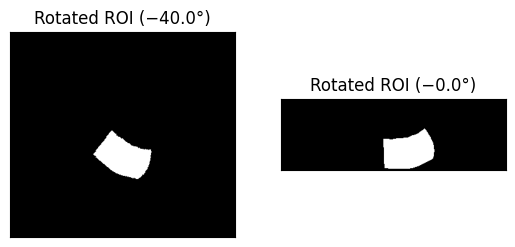

In [83]:
fig, axes = plt.subplots(1, 2)
roi = 'lob_VI'
plot_rotated_roi_mask(roi_masks_ds[roi], 40, ax=axes[0])
plot_rotated_roi_mask(roi_masks_ds[roi], 0, ax=axes[1])

In [9]:
unique_predictors_extended = list(unique_predictors) + ['left_choice_times', 'right_choice_times']

In [16]:
unique_predictors

['vis_ruleCue_times',
 'aud_ruleCue_times',
 'left_vis_stimOn_times',
 'right_vis_stimOn_times',
 'left_aud_stimOn_times',
 'right_aud_stimOn_times',
 'vis_left_choice_times',
 'vis_right_choice_times',
 'aud_left_choice_times',
 'aud_right_choice_times',
 'vis_reward_times',
 'aud_reward_times',
 'vis_punish_times',
 'aud_punish_times',
 'omission_times',
 'previous_feedbackType',
 'reward_history',
 'body',
 'lick',
 'face',
 'pupil_area',
 'pupil_xpos',
 'pupil_ypos',
 'vel']

In [17]:
# pred_name = unique_predictors[:15]  # e.g., 'stim_onset', 'choice_left', ...
for pred_name in unique_predictors[10:12]:
    fig, axes, stage_maps, extent = make_stage_maps_rasterized_full_atlas(
        agg_data=agg_data,
        mouse_ids=mouse_ids,
        atlas_template=atlas_template,
        pred_name=pred_name,
        unique_predictors=unique_predictors,
        full_predictors=predictors,
        perf_thresh=0.65,
        downsample=2,                # try 8 for speed, 2 for detail
        smooth_sigma_bins=1.0,
        min_count=30,                # bump a bit if downsample is small
        zscore_within_session=False,
        frame_reduction='mean',
        weighting='length' ,          # or 'unit' to equalize per-neuron contribution
        data_type='r2',
        clim = (-0.02, 0.02)
    )

    #out_dir = r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\figs\group_aggregate\r2_topo'
    svg_out_dir = r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig6'
    # os.makedirs(out_dir, exist_ok=True)
    fig.savefig(os.path.join(svg_out_dir, f"ALL_stage_maps_fullatlas_{pred_name.replace(' ','_')}_ds2.png"),
                dpi=300, bbox_inches='tight')
    fig.savefig(
        os.path.join(svg_out_dir, f"ALL_stage_maps_fullatlas_{pred_name.replace(' ','_')}_ds2.svg"),
        format='svg',
        dpi=300,
        bbox_inches='tight',
        transparent=True,   # optional: removes white background
        metadata={'Creator': 'Matplotlib'}
    )
    plt.close(fig)
    rotation_angle = {'lob_V':0, 'lob_VI':0, 'simplex':40, 'crus_I':40}
    rot_profiles, angles = compute_roi_profiles_along_axis(
                stage_maps=stage_maps,
                roi_masks_ds=roi_masks_ds,
                downsample=downsample,
                atlas_shape=atlas_template.shape,
                roi_angles_deg=rotation_angle,      # auto-PCA per ROI
                bin_width_pixels=downsample
            )
    roi_list = ['lob_V', 'lob_VI', 'simplex', 'crus_I']
    
    fig, axes = plt.subplots(2, 2, figsize=(6, 4), sharey=True)
    for ax, roi_name in zip(axes.ravel(), roi_list):
        ax = plot_roi_profiles(rot_profiles, ax=ax, roi_name=roi_name, axis='diag', 
                    title_prefix='angle:' + f'{angles[roi_name]:.1f}', ylim=(-0.001, 0.011))
    plt.tight_layout()
    # out_dir = r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\figs\group_aggregate\r2_roi_profiles'
    # os.makedirs(out_dir, exist_ok=True)
    fig.savefig(
        os.path.join(svg_out_dir, f"diag_roi_profiles_{pred_name.replace(' ','_')}.svg"),
        format='svg',
        dpi=300,
        bbox_inches='tight',
        transparent=True,   # optional: removes white background
        metadata={'Creator': 'Matplotlib'}
    )
    fig.savefig(
        os.path.join(svg_out_dir, f"diag_roi_profiles_{pred_name.replace(' ','_')}.png"),
        dpi=300,
        bbox_inches='tight'
    )
    plt.close(fig)

Skipping AE_L2 date: 20250612 for reward...
Skipping AE_L3 date: 20250612 for reward...
Skipping AF_R3 date: 20250528 for reward...
Skipping AF_R3 date: 20250604 for reward...
Skipping AF_L2 date: 20250528 for reward...
Skipping AF_L2 date: 20250604 for reward...
Skipping AF_L3 date: 20250604 for reward...
Skipping AB_R2 date: 20250527 for reward...
Skipping J_L2 date: 20240904 for reward...
Skipping J_L2 date: 20240910 for reward...
Skipping J_L2 date: 20240918 for reward...
Skipping J_L2 date: 20240924 for reward...
Skipping J_L2 date: 20241015 for reward...
Skipping J_L2 date: 20241018 for reward...
Skipping J_L2 date: 20241106 for reward...
Skipping J_L2 date: 20241111 for reward...
Skipping J_L2 date: 20241118 for reward...
Skipping A_R2 date: 20240815 for reward...
Skipping A_R2 date: 20240821 for reward...
Skipping A_R2 date: 20240910 for reward...
Skipping A_R2 date: 20240924 for reward...
Skipping A_R2 date: 20241015 for reward...
Skipping A_R2 date: 20241018 for reward...
Ski

C:\Users\dirk\AppData\Local\Temp\ipykernel_27008\1977767479.py:133: RuntimeWarning: invalid value encountered in divide
  H_mean = np.where(wf > 1e-9, hf / wf, np.nan)


build map for vis_expert...
build map for aud_expert...
build map for db_expert...


C:\Users\dirk\AppData\Local\Temp\ipykernel_27008\3775377582.py:134: RuntimeWarning: Mean of empty slice
  prof_vals[b] = np.nanmean(vals[mask_b])


Skipping AE_L2 date: 20250612 for reward...
Skipping AE_L3 date: 20250612 for reward...
Skipping AF_R3 date: 20250528 for reward...
Skipping AF_R3 date: 20250604 for reward...
Skipping AF_L2 date: 20250528 for reward...
Skipping AF_L2 date: 20250604 for reward...
Skipping AF_L3 date: 20250604 for reward...
Skipping AB_R2 date: 20250527 for reward...
Skipping J_L2 date: 20240904 for reward...
Skipping J_L2 date: 20240910 for reward...
Skipping J_L2 date: 20240918 for reward...
Skipping J_L2 date: 20240924 for reward...
Skipping J_L2 date: 20241015 for reward...
Skipping J_L2 date: 20241018 for reward...
Skipping J_L2 date: 20241106 for reward...
Skipping J_L2 date: 20241111 for reward...
Skipping J_L2 date: 20241118 for reward...
Skipping A_R2 date: 20240815 for reward...
Skipping A_R2 date: 20240821 for reward...
Skipping A_R2 date: 20240910 for reward...
Skipping A_R2 date: 20240924 for reward...
Skipping A_R2 date: 20241015 for reward...
Skipping A_R2 date: 20241018 for reward...
Ski

In [32]:
def build_stage_by_mouse_date(agg_data, mouse_ids, pred_name, perf_thresh=0.7):
    """
    Build a dict[mouse][date] -> stage using rolling-averaged performance.

    Depends on your existing:
        rolling_average(vis_acc, w=3)
        classify_day_stage(vis_roll, aud_roll, vis_acc, aud_acc, perf_thresh)
    """
    stage_by_mouse_date = {m: {} for m in mouse_ids}

    for mouse in mouse_ids:
        md = agg_data[mouse]
        vis_acc = np.asarray(md['training']['accuracies_vis'])
        aud_acc = np.asarray(md['training']['accuracies_aud'])
        tr_dates = np.asarray(md['training']['training_dates'])  # YYYYMMDD strings

        vis_roll = rolling_average(vis_acc, w=3)
        aud_roll = rolling_average(aud_acc, w=3)

        img_dates = [s for s in md.keys() if (
            s.isdigit()
            or (s.endswith('_valvesilent') and s.replace('_valvesilent', '').isdigit())
            or (s.endswith('_valvesilent_punishsilent') and s.replace('_valvesilent_punishsilent', '').isdigit())
        )]

        for date in img_dates:
            # same reward/punish skip logic you showed
            if 'valvesilent' not in date and 'reward' in pred_name:
                continue
            if 'punishsilent' not in date and 'punish' in pred_name:
                continue

            # match to training date (strip suffixes)
            idx = np.where(tr_dates == date[:8])[0]
            if idx.size == 0:
                continue
            di = int(idx[0])

            stage = classify_day_stage(
                vis_roll[di], aud_roll[di],
                vis_acc[di], aud_acc[di],
                perf_thresh
            )
            stage_by_mouse_date[mouse][date] = stage

    return stage_by_mouse_date

def assign_roi_and_position(neurons, roi_masks_full, frac_thresh=0.5):
    """
    For a list of neuron dicts (with 'xcoord_atlas', 'ycoord_atlas'),
    assign each neuron to the ROI in which it has the largest fraction of pixels
    above frac_thresh. Also compute a representative (x_full, y_full) position
    from pixels inside that ROI.

    Returns
    -------
    roi_names : list of str or None
    x_full    : array of float, full-res x coordinate in atlas pixels
    y_full    : array of float, full-res y coordinate in atlas pixels
    """
    # assume all ROI masks have the same shape
    some_roi = next(iter(roi_masks_full.values()))
    H, W = np.asarray(some_roi, dtype=bool).shape

    n_neurons = len(neurons)
    roi_names = [None] * n_neurons
    x_full = np.full(n_neurons, np.nan)
    y_full = np.full(n_neurons, np.nan)

    # pre-cast masks to bool arrays
    roi_bool_masks = {
        name: np.asarray(mask, dtype=bool)
        for name, mask in roi_masks_full.items()
    }

    for i, neuron in enumerate(neurons):
        x = np.asarray(neuron['xcoord_atlas'], dtype=int)
        y = np.asarray(neuron['ycoord_atlas'], dtype=int)

        ok = (x >= 0) & (x < W) & (y >= 0) & (y < H)
        if not np.any(ok):
            continue

        x = x[ok]
        y = y[ok]
        n_pix_total = len(x)

        best_roi = None
        best_frac = 0.0
        best_x = None
        best_y = None

        for roi_name, roi_mask_bool in roi_bool_masks.items():
            in_roi = roi_mask_bool[y, x]
            n_pix_in_roi = np.count_nonzero(in_roi)
            frac_in_roi = n_pix_in_roi / n_pix_total

            if frac_in_roi > frac_thresh and frac_in_roi > best_frac:
                best_frac = frac_in_roi
                best_roi = roi_name
                if n_pix_in_roi > 0:
                    best_x = x[in_roi].mean()
                    best_y = y[in_roi].mean()

        if best_roi is not None:
            roi_names[i] = best_roi
            x_full[i] = best_x if best_x is not None else x.mean()
            y_full[i] = best_y if best_y is not None else y.mean()

    return roi_names, x_full, y_full





def compute_onset_latency_per_neuron_from_psth(
    agg_data,
    mouse_ids,
    base_pred,              # e.g. 'vis_right_choice_times'
    psth_time_start,        # e.g. -0.4
    psth_time_end,          # e.g.  1.2
    window=(0.0, 0.3),      # search window in seconds (relative to event)
    thresh=1.0,             # z-score threshold for "response onset"
    roi_masks_full=None,
    stage_by_mouse_date=None,
    frac_thresh=0.5,
    arms=('arm1', 'arm2')
):
    """
    For each neuron, find the FIRST timepoint in 'window' where neuron's
    z-scored PSTH (neuron[base_pred + '_psth']) crosses 'thresh'.

    Returns
    -------
    df : DataFrame with columns
        ['mouse','date','arm','neuron_idx','stage',
         'roi_name','latency_s','x_full','y_full']
    """
    if roi_masks_full is None:
        raise ValueError("roi_masks_full must be provided")
    if stage_by_mouse_date is None:
        raise ValueError("stage_by_mouse_date must be provided")

    rows = []

    for mouse in mouse_ids:
        md = agg_data[mouse]
        for date, sess in md.items():
            if date == 'training':
                continue

            stage = stage_by_mouse_date.get(mouse, {}).get(date, 'unknown')

            for arm in arms:
                if arm not in sess:
                    continue
                stats = sess[arm].get('stat', None)
                if stats is None:
                    continue

                # assign ROI + positions once per arm/date
                roi_names, x_full, y_full = assign_roi_and_position(
                    neurons=stats,
                    roi_masks_full=roi_masks_full,
                    frac_thresh=frac_thresh
                )

                for i, st in enumerate(stats):
                    roi_name = roi_names[i]
                    if roi_name is None:
                        continue

                    key = base_pred + '_psth'
                    if key not in st:
                        continue

                    psth = np.asarray(st[key])

                    # handle (trials, T) vs (T,)
                    if psth.ndim == 2:
                        psth_mean = np.nanmean(psth, axis=0)
                    elif psth.ndim == 1:
                        psth_mean = psth
                    else:
                        # unexpected shape, skip
                        continue

                    T = psth_mean.shape[-1]
                    if T < 2:
                        continue

                    t = np.linspace(psth_time_start, psth_time_end, T)

                    # restrict to the search window
                    w0, w1 = window
                    mask_w = (t >= w0) & (t <= w1)
                    idx_w = np.where(mask_w)[0]
                    if idx_w.size == 0:
                        continue  # no samples in window

                    psth_win = psth_mean[idx_w]
                    # first crossing of threshold
                    crossings = np.where(psth_win >= thresh)[0]
                    if crossings.size == 0:
                        latency = np.nan  # no onset
                    else:
                        first_idx = idx_w[crossings[0]]
                        latency = float(t[first_idx])  # in seconds

                    rows.append({
                        'mouse': mouse,
                        'date': date,
                        'arm': arm,
                        'neuron_idx': i,
                        'stage': stage,
                        'roi_name': roi_name,
                        'latency_s': latency,
                        'x_full': float(x_full[i]),
                        'y_full': float(y_full[i])
                    })

    df = pd.DataFrame(rows)
    return df

def compute_latency_profiles_along_diag(
    df_lat,
    roi_masks_ds,
    roi_angles_deg,
    downsample,
    atlas_shape,
    bin_width_pixels=None,
    voxel_size_um=10.0,
    latency_col='latency_s'
):
    """
    Build 1D profiles of onset latency along the rotated horizontal (diag) axis
    for each ROI and each stage.

    Returns
    -------
    latency_profiles[roi_name][stage]['diag'] = (coords_mm, mean_latency, counts)
    diag_angles[roi_name] = angle_deg
    """
    H, W = atlas_shape

    if bin_width_pixels is None:
        bin_width_pixels = downsample

    latency_profiles = {name: {} for name in roi_masks_ds.keys()}
    diag_angles = {}

    for roi_name, roi_mask_ds in roi_masks_ds.items():
        ys_roi, xs_roi = np.where(roi_mask_ds)
        if xs_roi.size == 0:
            continue

        # ROI pixels in FULL atlas coordinates
        y_atlas_roi = (ys_roi + 0.5) * downsample
        x_atlas_roi = (xs_roi + 0.5) * downsample

        # rotation angle (CW)
        if roi_angles_deg is not None and roi_name in roi_angles_deg:
            angle_deg = float(roi_angles_deg[roi_name])
        else:
            angle_deg = 0.0
        diag_angles[roi_name] = angle_deg

        angle_rad = np.deg2rad(angle_deg)
        ux = np.cos(angle_rad)
        uy = -np.sin(angle_rad)

        # define axis with ROI pixels
        s_roi = x_atlas_roi * ux + y_atlas_roi * uy

        # make s increase left→right
        if np.corrcoef(s_roi, x_atlas_roi)[0, 1] < 0:
            ux, uy = -ux, -uy
            s_roi = x_atlas_roi * ux + y_atlas_roi * uy

        s_min = s_roi.min()
        s_roi_rel = s_roi - s_min
        s_max = s_roi_rel.max()

        nbins = max(1, int(np.ceil(s_max / bin_width_pixels)))
        edges = np.linspace(0.0, s_max, nbins + 1)
        centers = 0.5 * (edges[:-1] + edges[1:])

        centers_um = centers * voxel_size_um
        centers_mm = centers_um / 1000.0

        # neurons in this ROI
        df_roi = df_lat[df_lat['roi_name'] == roi_name].copy()
        if df_roi.empty:
            continue

        x_neu = df_roi['x_full'].values
        y_neu = df_roi['y_full'].values

        s_neu = x_neu * ux + y_neu * uy
        s_neu_rel = s_neu - s_min

        bin_idx_neu = np.digitize(s_neu_rel, edges) - 1
        bin_idx_neu = np.clip(bin_idx_neu, 0, nbins - 1)
        df_roi['bin_idx'] = bin_idx_neu

        # profiles per stage
        for stage in df_roi['stage'].unique():
            df_stage = df_roi[df_roi['stage'] == stage]

            mean_lat = np.full(nbins, np.nan)
            counts = np.zeros(nbins, dtype=int)

            for b in range(nbins):
                mask_b = (df_stage['bin_idx'].values == b)
                if np.any(mask_b):
                    vals_b = df_stage.loc[mask_b, latency_col].values
                    mean_lat[b] = np.nanmean(vals_b)
                    counts[b] = mask_b.sum()

            if stage not in latency_profiles[roi_name]:
                latency_profiles[roi_name][stage] = {}

            latency_profiles[roi_name][stage]['diag'] = (
                centers_mm,
                mean_lat,
                counts
            )

    return latency_profiles, diag_angles

In [36]:
def plot_latency_profiles(
    latency_profiles,
    roi_name,
    axis='diag',
    stages=('naive','vis_expert','aud_expert','db_expert'),
    ax=None,
    title_prefix='',
    ylim=None
):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3))
    else:
        fig = ax.figure

    colors = {
        'naive': '#A0A0A0',
        'vis_expert': '#4E79A7',
        'aud_expert': '#F28E2B',
        'db_expert': '#59A14F'
    }

    roi_prof = latency_profiles.get(roi_name, {})

    for stg in stages:
        if stg not in roi_prof or axis not in roi_prof[stg]:
            continue
        coords, vals, counts = roi_prof[stg][axis]

        ax.plot(coords, vals, label=stg,
                color=colors.get(stg, None), lw=2)

    ax.set_xlabel('Distance across stripes (mm from 0)')
    ax.set_ylabel('Onset latency (s)')

    if ylim is not None:
        ax.set_ylim(ylim)

    ax.set_title(f"{title_prefix}{roi_name} – {axis}")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False)
    return ax

C:\Users\dirk\AppData\Local\Temp\ipykernel_21076\2811125821.py:317: RuntimeWarning: Mean of empty slice
  mean_lat[b] = np.nanmean(vals_b)
C:\Users\dirk\AppData\Local\Temp\ipykernel_21076\2811125821.py:317: RuntimeWarning: Mean of empty slice
  mean_lat[b] = np.nanmean(vals_b)
C:\Users\dirk\AppData\Local\Temp\ipykernel_21076\2811125821.py:317: RuntimeWarning: Mean of empty slice
  mean_lat[b] = np.nanmean(vals_b)
C:\Users\dirk\AppData\Local\Temp\ipykernel_21076\2811125821.py:317: RuntimeWarning: Mean of empty slice
  mean_lat[b] = np.nanmean(vals_b)


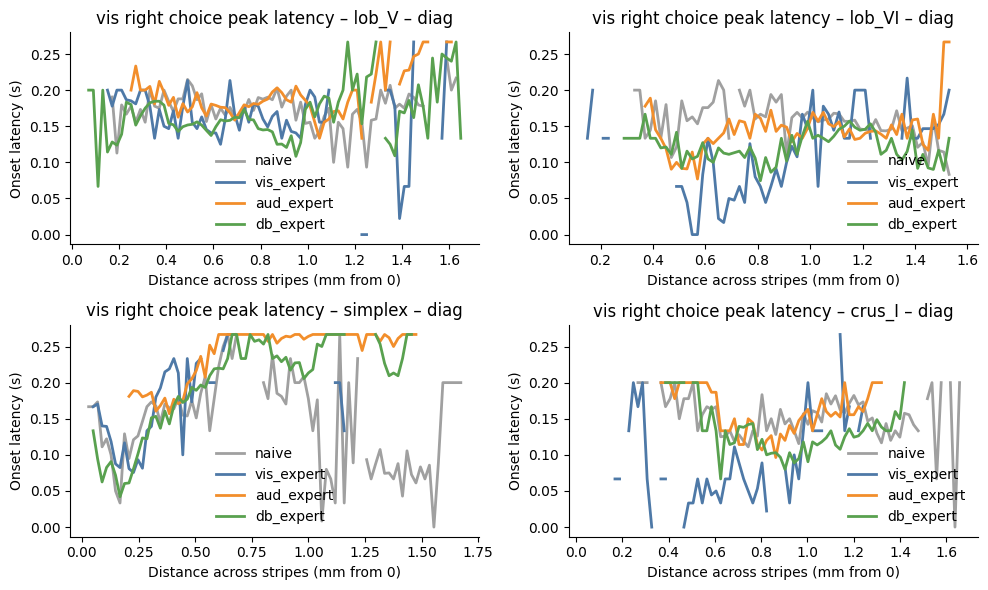

In [39]:
# 1) Stage classification
stage_by_mouse_date = build_stage_by_mouse_date(
    agg_data=agg_data,
    mouse_ids=mouse_ids,
    pred_name='vis_right_choice_times',  # for reward/punish skip logic
    perf_thresh=0.65                      # or your value
)

# 2) get per-neuron onset latency from z-PSTH
df_lat = compute_onset_latency_per_neuron_from_psth(
    agg_data=agg_data,
    mouse_ids=mouse_ids,
    base_pred='vis_right_choice_times',
    psth_time_start=psth_time_start,
    psth_time_end=psth_time_end,
    window=(0.0, 0.3),
    thresh=1.5,
    roi_masks_full=roi_masks_full,
    stage_by_mouse_date=stage_by_mouse_date,
    frac_thresh=0.5
)

# 3) bin along diag axis in each ROI
rotation_angle = {'lob_V':0, 'lob_VI':0, 'simplex':40, 'crus_I':40}
downsample = 2  # same as in make_stage_maps_rasterized_full_atlas
roi_masks_ds = make_downsampled_roi_masks(roi_masks_full, downsample)
latency_profiles, diag_angles = compute_latency_profiles_along_diag(
    df_lat=df_lat,
    roi_masks_ds=roi_masks_ds,
    roi_angles_deg=rotation_angle,
    downsample=downsample,
    atlas_shape=atlas_template.shape,
    bin_width_pixels=None,
    voxel_size_um=10.0
)



# 4) Plot for one ROI
fig, axes = plt.subplots(2, 2,figsize=(10, 6))
roi_name = ['lob_V', 'lob_VI', 'simplex', 'crus_I']
for roi, ax in zip(roi_name, axes.flatten()):
    plot_latency_profiles(
        latency_profiles,
        roi_name=roi,       # e.g.
        axis='diag',
        stages=('naive','vis_expert','aud_expert','db_expert'),
        ax=ax,
        title_prefix='vis right choice peak latency – '
    )
fig.tight_layout()

In [28]:
from collections import defaultdict

import numpy as np
import pandas as pd

def count_neurons_in_rois(agg_data, mouse_ids, roi_masks_full, frac_thresh=0.5):
    """
    Count how many neurons fall within each ROI mask for each mouse and session (date).
    Both arm1 and arm2 neurons are combined for each date.

    A neuron is counted for a region only if more than `frac_thresh`
    fraction of its pixels fall inside that region.
    """
    rows = []

    for mouse in mouse_ids:
        md = agg_data[mouse]
        for date, sess in md.items():
            if date == 'training':
                continue

            # ---- combine all neurons from both arms ----
            neurons = []
            for arm in ['arm1', 'arm2']:
                if arm in sess:
                    neurons.extend(sess[arm]['stat'])
            if not neurons:
                continue

            # ---- count per ROI ----
            for roi_name, roi_mask in roi_masks_full.items():
                roi_mask_bool = np.asarray(roi_mask, dtype=bool)
                H, W = roi_mask_bool.shape
                n_in_roi = 0

                for neuron in neurons:
                    x = np.asarray(neuron['xcoord_atlas'], dtype=int)
                    y = np.asarray(neuron['ycoord_atlas'], dtype=int)
                    ok = (x >= 0) & (x < W) & (y >= 0) & (y < H)
                    if not np.any(ok):
                        continue

                    x = x[ok]
                    y = y[ok]
                    n_pix_total = len(x)
                    n_pix_in_roi = np.count_nonzero(roi_mask_bool[y, x])
                    frac_in_roi = n_pix_in_roi / n_pix_total

                    if frac_in_roi > frac_thresh:
                        n_in_roi += 1

                rows.append({
                    'mouse': mouse,
                    'date': date,
                    'roi': roi_name,
                    'count': n_in_roi
                })

    df = pd.DataFrame(rows)
    return df

def summarize_counts(df):
    summary = (
        df.groupby(['mouse', 'roi'])['count']
        .agg(['mean', 'std', 'count'])
        .reset_index()
        .rename(columns={'count': 'n_sessions'})
    )
    return summary

import matplotlib.lines as mlines

def plot_neuron_counts(df, roi_order=None):
    plt.style.use('seaborn-v0_8-whitegrid')

    if roi_order is None:
        roi_order = sorted(df['roi'].unique())

    fig, ax = plt.subplots(figsize=(8, 4))

    mice = sorted(df['mouse'].unique())
    offsets = np.linspace(-0.25, 0.25, len(mice))

    # --- Distinct Nature-style color palette (up to ~12 clearly different hues) ---
    # Source: Tol’s "bright" and "vibrant" palettes + slight tuning for Matplotlib
    tol_bright = [
        "#4477AA", "#EE6677", "#228833", "#CCBB44",
        "#66CCEE", "#AA3377", "#BBBBBB", "#000000",
        "#FFA500", "#009E73", "#882255", "#44AA99"
    ]
    colors = tol_bright[:len(mice)]

    color_map = dict(zip(mice, colors))
    offset_map = dict(zip(mice, offsets))

    # --- Plot data ---
    for mouse in mice:
        color = color_map[mouse]
        dx = offset_map[mouse]
        sub = df[df['mouse'] == mouse]

        for i, roi in enumerate(roi_order):
            roi_sub = sub[sub['roi'] == roi]
            if roi_sub.empty:
                continue
            # individual sessions
            ax.scatter(
                np.full(len(roi_sub), i + dx),
                roi_sub['count'],
                color=color, s=30, alpha=0.5
            )
            # mean across sessions
            mean_val = roi_sub['count'].mean()
            ax.plot(i + dx, mean_val, 'o',
                    color=color, markersize=10,
                    markeredgecolor='k', lw=0)

    # --- Axis styling ---
    ax.set_xticks(range(len(roi_order)))
    ax.set_xticklabels([r.replace('_', ' ') for r in roi_order],
                       rotation=30, ha='right')
    ax.set_ylabel('Neuron count per session')
    ax.set_title('Neurons recorded per ROI across mice')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)
    # --- Legend with proxy handles ---
    proxies = [
        mlines.Line2D([], [], color=color_map[m], marker='o', lw=0, ms=8)
        for m in mice
    ]
    ax.legend(
        proxies, mice,
        frameon=False,
        title='Mouse',
        bbox_to_anchor=(1.05, 1),
        loc='upper left'
    )

    plt.tight_layout()
    return fig, ax

In [109]:
mouse

'R_L2'

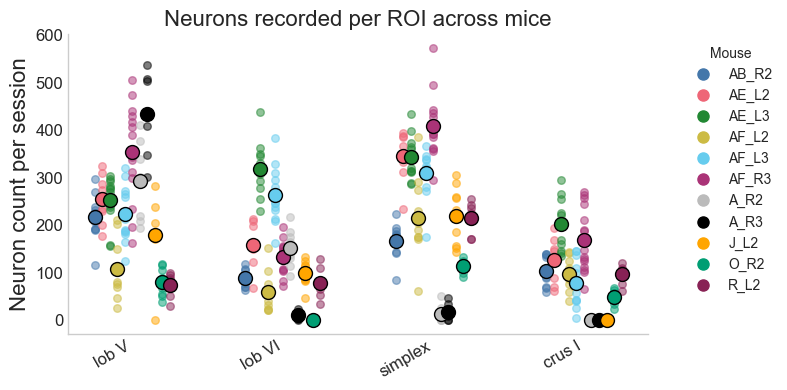

In [33]:
roi_list = ['lob_V', 'lob_VI', 'simplex', 'crus_I']

df_counts = count_neurons_in_rois(agg_data, mouse_ids, roi_masks_full)
summary = summarize_counts(df_counts)

fig, ax = plot_neuron_counts(df_counts, roi_order=roi_list)
fig.savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig2', "'neuron_counts_by_roi.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)
#fig.savefig('neuron_counts_by_roi.svg', bbox_inches='tight', transparent=True)

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import matplotlib.patches as mpatches

def plot_stacked_dff_with_events(
    dff, table_for_img, stat, roi_masks_full,
    fps=15.0, t_window=None, event_cols=None,
    # --- random selection controls ---
    roi_names=('simplex','crus_I','lob_V','lob_VI'),
    per_roi_max=5, frac_thresh=0.5, seed=None,
    # --- visuals / scaling ---
    normalize='zscore_global', gain=1.0, offset_step=None, gap=0.2,
    smooth_win_s=None,
    event_alpha=0.25, trace_lw=0.8,
    figsize=(12, 6), title=None,
):
    """
    Atlas-based ROI assignment -> random sample per ROI -> stacked dF/F (ROI-colored)
    with visible event overlays.
    Returns (fig, ax, selection_dict).
    """
    ROI_COLOR_MAP = {
        'simplex': plt.cm.Reds,
        'crus_I': plt.cm.Blues,
        'lob_V': plt.cm.Purples,
        'lob_VI': plt.cm.Oranges,
    }

    roi_palette = {}
    for rn in roi_names:
        cmap = ROI_COLOR_MAP.get(rn, plt.cm.Greys)  # fallback color if missing
        roi_palette[rn] = cmap(0.65)

    # ----- atlas-based ROI assignment (fraction of pixels in each mask) -----
    masks = [np.asarray(roi_masks_full[rn], dtype=bool) for rn in roi_names]
    roi_stack = np.stack(masks, axis=0)  # (R,H,W)
    R, H, W = roi_stack.shape
    n_neurons, n_frames = dff.shape

    roi_idx = np.full(n_neurons, -1, dtype=int)
    for i, neuron in enumerate(stat):
        x = np.asarray(neuron.get('xcoord_atlas', []), dtype=int)
        y = np.asarray(neuron.get('ycoord_atlas', []), dtype=int)
        if x.size == 0 or y.size == 0:
            continue
        ok = (x >= 0) & (x < W) & (y >= 0) & (y < H)
        if not np.any(ok):
            continue
        x, y = x[ok], y[ok]
        fracs = roi_stack[:, y, x].mean(axis=1)   # (R,)
        k = int(np.argmax(fracs))
        if fracs[k] > frac_thresh:
            roi_idx[i] = k

    # ----- random selection per ROI (reproducible with seed) -----
    rng = np.random.default_rng(seed)
    selected = []
    for r_i, rn in enumerate(roi_names):
        pool = np.where(roi_idx == r_i)[0]
        if pool.size == 0:
            continue
        n_pick = min(per_roi_max, pool.size)
        chosen = rng.choice(pool, size=n_pick, replace=False)
        selected.extend(chosen.tolist())
    selected = np.asarray(selected, dtype=int)
    selected_roi = [roi_names[roi_idx[i]] for i in selected]

    # ----- time window -----
    if t_window is None:
        f0, f1 = 0, n_frames
    else:
        t0, t1 = t_window
        f0 = max(0, int(t0 * fps))
        f1 = min(n_frames, int(t1 * fps))
        if f1 <= f0:
            raise ValueError("Empty t_window.")

    t = np.arange(f0, f1) / fps
    yseg = dff[selected, f0:f1].astype(float)

    # ----- basic normalization options -----
    def zscore_global(arr2d):
        mu = np.nanmean(arr2d); sd = np.nanstd(arr2d) or 1.0
        return (arr2d - mu) / sd
    if normalize == 'zscore_global':
        yplot = zscore_global(yseg)
    else:
        yplot = yseg
    yplot *= float(gain)

    # optional smoothing
    if smooth_win_s and smooth_win_s > 0:
        win = max(1, int(round(smooth_win_s * fps)))
        if win % 2 == 0: win += 1
        k = np.ones(win)/win
        for r in range(yplot.shape[0]):
            yplot[r] = np.convolve(yplot[r], k, mode='same')

    # spacing
    if offset_step is None:
        lo, hi = np.nanpercentile(yplot, [5, 95])
        step = max(1e-9, hi - lo) + gap
    else:
        step = float(offset_step)
    offsets = np.arange(yplot.shape[0])[::-1] * step

    # ----- plot traces -----
    fig, ax = plt.subplots(figsize=figsize)
    for row, rn in enumerate(selected_roi):
        color = roi_palette.get(rn, (0.5,0.5,0.5,1))
        ax.plot(t, yplot[row] + offsets[row], lw=trace_lw, color=color)

    ymin, ymax = -0.6*step, (offsets[0] + 1.6*step) if len(offsets) else step
    ax.set_xlim(t[0], t[-1]); ax.set_ylim(ymin, ymax)

    # ----- event overlays as translucent bands -----
    if event_cols is None:
        event_cols = list(table_for_img.columns)
    event_colors = ['#FF6F61', '#5DADE2', '#58D68D', '#AF7AC5', '#F8C471']

    for j, col in enumerate(event_cols):
        if col not in table_for_img.columns:
            continue
        frames = np.asarray(table_for_img[col].dropna().values)
        frames = frames[(frames >= f0) & (frames < f1)]
        for tt in frames / fps:
            ax.axvspan(tt - 0.05, tt + 0.05,
                       color=to_rgba(event_colors[j % len(event_colors)], event_alpha), lw=0)

    # --- SD bar (for z-score) ---
    if isinstance(normalize, str) and normalize.startswith('zscore'):
    # yplot is shape (n_sel_neurons, n_timepoints), AFTER gain & smoothing
    # This SD reflects the variability of what you're actually visualizing.
        sd_vis = np.nanstd(yplot)

        if sd_vis > 0:
            bar_len = sd_vis
            x0, x1 = ax.get_xlim()
            y0, y1 = ax.get_ylim()

            # place the bar inside the axes, e.g. bottom-left
            bar_x = x0 + 0.03 * (x1 - x0)
            bar_y0 = y0 + 0.05 * (y1 - y0)

            ax.plot([bar_x, bar_x], [bar_y0, bar_y0 + bar_len],
                    color='k', lw=2)
            ax.text(bar_x + 0.02 * (x1 - x0),
                    bar_y0 + bar_len / 2,
                    '1 SD',
                    va='center', ha='left', fontsize=9)
    # ----- ROI legend (only those used) -----
    used = [r for r in dict.fromkeys(selected_roi) if r is not None]
    roi_handles = [mpatches.Patch(color=roi_palette[r], label=r) for r in used]
    leg1 = None
    if roi_handles:
        leg1 = ax.legend(roi_handles, [h.get_label() for h in roi_handles],
                         loc='center left', bbox_to_anchor=(1.02, 0.5),
                         frameon=False, fontsize=9, title="ROI")

    # ----- Event legend -----
    event_handles = []
    for j, col in enumerate(event_cols):
        if col not in table_for_img.columns:
            continue
        event_handles.append(
            mpatches.Patch(color=to_rgba(event_colors[j % len(event_colors)], 1.0),
                           label=col)
        )
    if event_handles:
        leg2 = ax.legend(event_handles, [h.get_label() for h in event_handles],
                         loc='upper left', bbox_to_anchor=(1.02, 1.0),
                         frameon=False, fontsize=8, title="Events")
        if leg1 is not None:
            ax.add_artist(leg1)

    ax.set_xlabel('Time (s)')
    ax.set_yticks([])
    if title:
        ax.set_title(title)
    ax.spines[['top','right','left']].set_visible(False)
    plt.tight_layout()

    selection = {
        "indices": selected,
        "roi_for_index": selected_roi,
        "roi_palette": roi_palette,
        "t_window": (f0 / fps, f1 / fps),
        "seed": seed,
        "frac_thresh": frac_thresh,
        "per_roi_max": per_roi_max,
    }
    return fig, ax, selection


In [15]:
def plot_psth_grid_for_selection(
    stat, selection, event_cols,
    psth_time_start=-0.4, psth_time_end=1.2, fps=15.0,
    show_sem=True, sem_alpha=0.25, lw=1.6,
    sharey='row',              # 'row' | 'col' | True | False
    common_ylim=None,          # e.g., (-1.5, 2.0); None -> auto per-row if sharey='row'
    figsize_per=(3.0, 1.6),    # (width, height) per subplot
    # NEW:
    style_mode='shade',        # 'shade' or 'linestyle'
    roi_cmaps=None,            # dict roi_name -> matplotlib colormap
    event_shades=None,         # iterable in [0..1], e.g., np.linspace(0.35,0.85,n_events)
    linestyle_cycle=None,      # list like ['-', '--', '-.', ':']
    add_legends=True
):
    """
    Grid of subplots with shape (num_selected_neurons, len(event_cols)).
    Each subplot: mean PSTH (z-scored) ± SEM for that neuron & event.
    Color encodes ROI; events are separated by either colormap shade or linestyle.
    """
    sel_idx = np.array(selection["indices"])          # neuron indices you plotted
    sel_roi = list(selection["roi_for_index"])        # ROI tag per selected neuron
    roi_palette = selection.get("roi_palette", {})    # roi_name -> RGBA

    n_neurons = len(sel_idx)
    n_events = len(event_cols)

    # PSTH length & timebase
    T = None
    for i in sel_idx:
        nstat = stat[i]
        for pred in event_cols:
            arr = nstat.get(pred + "_psth", None)
            if arr is not None and arr.size > 0:
                T = arr.shape[-1]
                break
        if T is not None:
            break
    if T is None:
        raise ValueError("Could not infer PSTH length T from selected neurons.")
    t = np.linspace(psth_time_start, psth_time_end, T, endpoint=False)

    # Default ROI -> base colormap mapping
    default_roi_cmaps = {
        'simplex': plt.cm.Reds,
        'crus_I':  plt.cm.Blues,
        'lob_V':   plt.cm.Purples,
        'lob_VI':  plt.cm.Oranges,
    }
    if roi_cmaps is None:
        roi_cmaps = default_roi_cmaps

    # Event encodings
    if style_mode == 'shade':
        if event_shades is None:
            event_shades = np.linspace(0.35, 0.85, n_events)
        if len(event_shades) != n_events:
            raise ValueError("event_shades must have the same length as event_cols.")
    else:  # linestyle mode
        if linestyle_cycle is None:
            linestyle_cycle = ['-', '--', '-.', ':', (0, (1, 1))]
        if len(linestyle_cycle) < n_events:
            k = (n_events // len(linestyle_cycle)) + 1
            linestyle_cycle = (linestyle_cycle * k)[:n_events]

    # Figure and axes
    fig_w = max(6.0, figsize_per[0] * n_events)
    fig_h = max(4.0, figsize_per[1] * n_neurons)

    # IMPORTANT: only share globally if sharey is literally True
    sharey_flag = True if sharey is True else False

    fig, axs = plt.subplots(
        n_neurons, n_events,
        figsize=(fig_w, fig_h),
        sharex=True,
        sharey=sharey_flag
    )

    # Handle 1D shapes
    if n_neurons == 1 and n_events == 1:
        axs = np.array([[axs]])
    elif n_neurons == 1:
        axs = axs[np.newaxis, :]
    elif n_events == 1:
        axs = axs[:, np.newaxis]

    # Compute per-row y-lims if requested
    row_ylim = [None] * n_neurons
    if common_ylim is None and (sharey == 'row'):
        for r, i in enumerate(sel_idx):
            lo_all, hi_all = [], []
            for c, pred in enumerate(event_cols):
                arr = stat[i].get(pred + "_psth", None)
                if arr is None or arr.size == 0:
                    continue
                m = np.nanmean(arr, axis=0)
                lo, hi = np.nanmin(m), np.nanmax(m)
                if show_sem:
                    sem = np.nanstd(arr, axis=0) / np.sqrt(max(1, arr.shape[0]))
                    lo = min(lo, np.nanmin(m - sem))
                    hi = max(hi, np.nanmax(m + sem))
                lo_all.append(lo)
                hi_all.append(hi)
            if lo_all and hi_all:
                # slightly larger padding to avoid cut-off
                pad = 0.2 * (np.nanmax(hi_all) - np.nanmin(lo_all) + 1e-9)
                row_ylim[r] = (np.nanmin(lo_all) - pad, np.nanmax(hi_all) + pad)

    # Draw grid
    for r, (i, roi_name) in enumerate(zip(sel_idx, sel_roi)):
        cmap = roi_cmaps.get(roi_name, plt.cm.Greys)
        roi_mid_color = roi_palette.get(roi_name, cmap(0.65))  # for labels/legend

        for c, pred in enumerate(event_cols):
            ax = axs[r, c]
            arr = stat[i].get(pred + "_psth", None)  # (trials, T)
            ax.axvline(0, color='k', lw=0.8, alpha=0.6)

            if arr is not None and arr.size > 0:
                m = np.nanmean(arr, axis=0)
                # color / style for this event
                if style_mode == 'shade':
                    col = cmap(event_shades[c])
                    ls = '-'
                else:
                    col = roi_mid_color
                    ls = linestyle_cycle[c]

                if show_sem:
                    sem = np.nanstd(arr, axis=0) / np.sqrt(max(1, arr.shape[0]))
                    ax.fill_between(t, m - sem, m + sem,
                                    color=col, alpha=sem_alpha, linewidth=0)
                ax.plot(t, m, color=col, lw=lw, ls=ls)

            # cosmetics
            if r == n_neurons - 1:
                ax.set_xlabel("Time (s)")
            else:
                ax.set_xticklabels([])

            # keep ytick labels on the *first column*, hide on others
            if c == 0:
                ax.set_ylabel(f"n {i}\n{roi_name}",
                              rotation=0, ha='right', va='center',
                              labelpad=18, color=roi_mid_color)
                # make sure numeric y-ticks are visible
                ax.tick_params(axis='y', labelsize=8)
            else:
                ax.set_yticklabels([])

            # apply y-lims
            if common_ylim is not None:
                ax.set_ylim(*common_ylim)
            elif row_ylim[r] is not None and (sharey == 'row'):
                ax.set_ylim(*row_ylim[r])

            ax.spines[['top', 'right']].set_visible(False)
            if r == 0:
                ax.set_title(pred, fontsize=10, pad=6)

    # leave space on the right for legends
    plt.tight_layout(rect=(0, 0, 0.86, 1.0))

    # Legends on the right
    if add_legends:
        # ROI legend (mid-tone swatches)
        unique_rois = [rn for rn in dict.fromkeys(sel_roi) if rn is not None]
        roi_handles = []
        for rn in unique_rois:
            cmap = roi_cmaps.get(rn, plt.cm.Greys)
            face = roi_palette.get(rn, cmap(0.65))
            roi_handles.append(mpatches.Patch(color=face, label=rn))
        if roi_handles:
            fig.legend(
                roi_handles, [h.get_label() for h in roi_handles],
                title="ROI", loc='center right',
                bbox_to_anchor=(0.985, 0.65), frameon=False
            )

        # Event legend
        if style_mode == 'shade':
            neutral = plt.cm.Greys
            ev_handles = [
                mpatches.Patch(color=neutral(event_shades[c]), label=name)
                for c, name in enumerate(event_cols)
            ]
            if ev_handles:
                fig.legend(
                    ev_handles, [h.get_label() for h in ev_handles],
                    title="Event (shade)", loc='center right',
                    bbox_to_anchor=(0.985, 0.32), frameon=False
                )
        else:
            from matplotlib.lines import Line2D
            ev_handles = [
                Line2D([0], [0], color='k', lw=2,
                       ls=linestyle_cycle[c], label=name)
                for c, name in enumerate(event_cols)
            ]
            if ev_handles:
                fig.legend(
                    ev_handles, [h.get_label() for h in ev_handles],
                    title="Event (style)", loc='center right',
                    bbox_to_anchor=(0.985, 0.32), frameon=False
                )

    return fig, axs

In [13]:
del roi_masks_full['crus_II']

In [14]:
roi_masks_full.keys()

dict_keys(['simplex', 'crus_I', 'lob_V', 'lob_VI'])

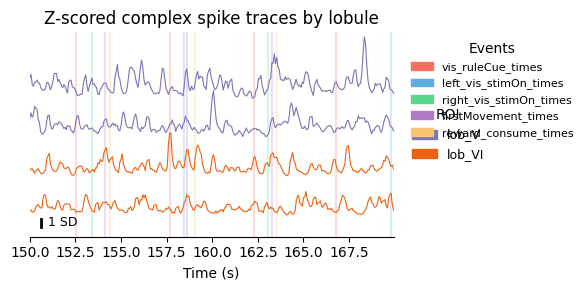

In [91]:
fps = 15.0
t_window = (150, 170)  # seconds
event_cols = ['vis_ruleCue_times','left_vis_stimOn_times','right_vis_stimOn_times','firstMovement_times', 'reward_consume_times']  # adjust to your columns

mouse = 'AE_L3'
date = '20250820_valvesilent'
arm1_dff = np.load(os.path.join(
            r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m', mouse, date,
            'arm1', 'dff_moving_percentile_pc_lowpass_0p5hz.npy'
        ))
arm1_neurons = agg_data[mouse][date]['arm1']['stat']
arm1_design_matrix = agg_data[mouse][date]['arm1']['design_matrix']
arm1_table_for_img = agg_data[mouse][date]['arm1']['table_for_img']
# Build an ROI palette (pastel for anatomy)


fig1, ax1, sel1 = plot_stacked_dff_with_events(
    dff = arm1_dff, 
    table_for_img = arm1_table_for_img, 
    stat = arm1_neurons, 
    roi_masks_full = roi_masks_full,         # or e.g. list(range(0, 60))
    per_roi_max=2,                # balanced sampling per ROI
    frac_thresh = 0.9,
    roi_names=('lob_V','lob_VI'),
    fps=15, t_window=t_window, event_cols=event_cols,
    normalize='zscore_per_global',   # or 'zscore_per_trace'
    gain=0.5,                    # scales both traces and SD bar
    smooth_win_s=0.2,            # optional visual smoothing
    title='Z-scored complex spike traces by lobule',
    figsize=(6, 3)
)
plt.show()

In [100]:
fig1.savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig2', "arm1_trace_with_events.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

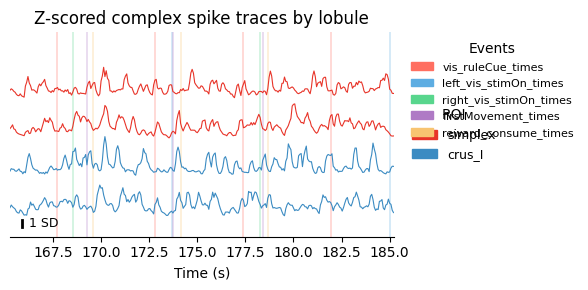

In [93]:
arm2_dff = np.load(os.path.join(
            r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m', mouse, date,
            'arm1', 'dff_moving_percentile_pc_lowpass_0p5hz.npy'
        ))
arm2_neurons = agg_data[mouse][date]['arm2']['stat']
arm2_design_matrix = agg_data[mouse][date]['arm2']['design_matrix']
arm2_table_for_img = agg_data[mouse][date]['arm2']['table_for_img']
# Build an ROI palette (pastel for anatomy)

offset = (arm2_table_for_img['ruleCueTrigger_times'][0]-arm1_table_for_img['ruleCueTrigger_times'][0])/15
fig2, ax2, sel2 = plot_stacked_dff_with_events(
    dff = arm2_dff, 
    table_for_img = arm2_table_for_img, 
    stat = arm2_neurons, 
    roi_masks_full = roi_masks_full,         # or e.g. list(range(0, 60))
    per_roi_max=2,                # balanced sampling per ROI
    frac_thresh = 0.9,
    roi_names=('simplex','crus_I'),
    fps=15, t_window=t_window+offset, event_cols=event_cols,
    normalize='zscore_per_global',   # or 'zscore_per_trace'
    gain=0.5,                    # scales both traces and SD bar
    smooth_win_s=0.2,            # optional visual smoothing
    title='Z-scored complex spike traces by lobule',
    figsize=(6, 3)
)
plt.show()

In [101]:
fig2.savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig2', "arm2_trace_with_events.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

In [34]:
(arm2_table_for_img['ruleCueTrigger_times'][0]-arm1_table_for_img['ruleCueTrigger_times'][0])/15

15.266666666666667

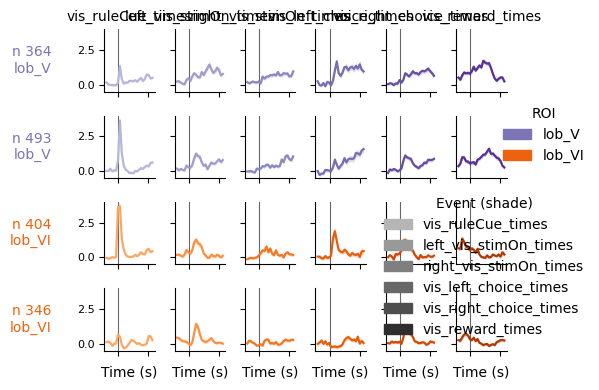

In [98]:
event_pred2plot = ['vis_ruleCue_times','left_vis_stimOn_times','right_vis_stimOn_times','vis_left_choice_times','vis_right_choice_times', 'vis_reward_times']
fig_grid1, axs_grid1 = plot_psth_grid_for_selection(
    stat=arm1_neurons,
    selection=sel1,  # from your stacked-trace function
    event_cols=event_pred2plot,
    psth_time_start=-0.4, psth_time_end=1.2, fps=15.0,
    style_mode='shade',                 # or 'linestyle'
    event_shades=np.linspace(0.4, 0.85, 6),  # 5 events
    figsize_per=(1, 0.6),
    sharey='row', 
    common_ylim=(-0.5, 4),
    show_sem=True
)
plt.show()

In [102]:
fig_grid1.savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig2', "arm1_psth_grid.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

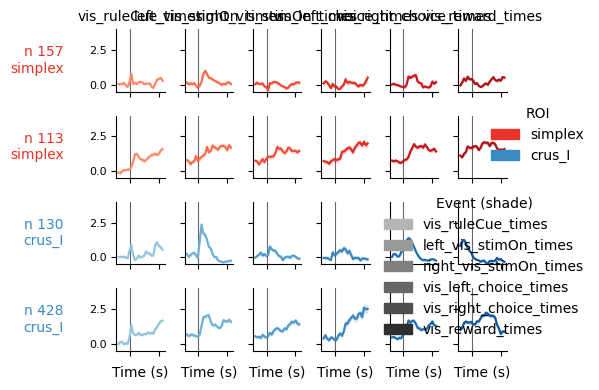

In [99]:
fig_grid2, axs_grid2 = plot_psth_grid_for_selection(
    stat=arm2_neurons,
    selection=sel2,  # from your stacked-trace function
    event_cols=event_pred2plot,
    psth_time_start=-0.4, psth_time_end=1.2, fps=15.0,
    style_mode='shade',                 # or 'linestyle'
    event_shades=np.linspace(0.4, 0.85, 6),  # 5 events
    figsize_per=(1, 0.6),
    sharey='row', 
    common_ylim=(-0.5, 4),
    show_sem=True
)
plt.show()

In [103]:
fig_grid2.savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig2', "arm2_psth_grid.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

In [30]:
agg_data[mouse][date]['arm2']['stat'][260]['id']

321

In [131]:
import numpy as np
import matplotlib.pyplot as plt

def plot_design_matrix_predictor_stacked(
    design_matrix,
    unique_pred_name,
    predictor_names,
    fps=15.0,
    t_window=None,
    color='k',
    gap=0.3,            # vertical gap between traces
    amplitude_scale=1,  # multiply each trace amplitude
    figsize=(8, 4),
    title=None,
):
    """
    Plot all design-matrix columns that contain `unique_pred_name`
    as clean, NON-overlapping stacked traces (like dFF stacks).
    """
    X = np.asarray(design_matrix)
    n_frames, n_preds = X.shape

    # 1) find matching predictors
    col_idx = [i for i, name in enumerate(predictor_names)
               if unique_pred_name in str(name)]
    if len(col_idx) == 0:
        raise ValueError(f"No predictors found containing '{unique_pred_name}'.")
    n_cols = len(col_idx)
    n_cols = min(n_cols, 10)
    # 2) time window
    if t_window is None:
        f0, f1 = 0, n_frames
    else:
        t0, t1 = t_window
        f0 = max(0, int(np.floor(t0 * fps)))
        f1 = min(n_frames, int(np.ceil(t1 * fps)))
    t = np.arange(f0, f1) / fps

    # 3) extract & stack design matrix pieces
    Xsel = X[f0:f1, :][:, col_idx].T     # shape: (n_cols, T)
    Xsel *= amplitude_scale

    # 4) determine spacing based on max amplitude across all basis functions
    max_amp = np.nanmax(np.abs(Xsel))
    if max_amp == 0:
        max_amp = 1.0

    step = max_amp * (1 + gap)     # ensures clean separation
    offsets = np.arange(n_cols)[::-1] * step

    # 5) plot
    fig, ax = plt.subplots(figsize=figsize)
    
    for i in range(n_cols):
        ax.plot(t, Xsel[i] + offsets[i], color=color, lw=1.0)

    # 6) y-limits (safe padding)
    ymin = -0.5 * step
    ymax = offsets[0] + 1.5 * step
    ax.set_ylim(ymin, ymax)

    ax.set_xlim(t[0], t[-1])
    ax.set_xlabel("Time (s)")
    ax.set_yticks([])

    if title is None:
        title = f"{unique_pred_name} basis functions (stacked)"
    ax.set_title(title)

    ax.spines[['top', 'right', 'left']].set_visible(False)
    plt.tight_layout()

    return fig, ax


In [119]:
unique_predictors

['vis_ruleCue_times',
 'aud_ruleCue_times',
 'left_vis_stimOn_times',
 'right_vis_stimOn_times',
 'left_aud_stimOn_times',
 'right_aud_stimOn_times',
 'vis_left_choice_times',
 'vis_right_choice_times',
 'aud_left_choice_times',
 'aud_right_choice_times',
 'vis_reward_times',
 'aud_reward_times',
 'vis_punish_times',
 'aud_punish_times',
 'omission_times',
 'previous_feedbackType',
 'reward_history',
 'body',
 'lick',
 'face',
 'pupil_area',
 'pupil_xpos',
 'pupil_ypos',
 'vel']

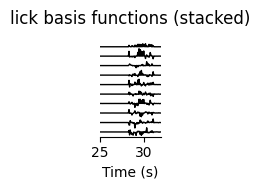

In [157]:
fig, ax = plot_design_matrix_predictor_stacked(
    design_matrix=arm2_design_matrix,
    unique_pred_name='lick',
    predictor_names=predictors,
    fps=15.0,
    t_window=(25, 32),
    color='k',
    title='lick basis functions (stacked)',
    figsize=(1, 2)
)

In [158]:
fig.savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig2', "lick_trace.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

CHOICE STUFF

In [ ]:
t = agg_data['AE_L2']['20250814_valvesilent_punishsilent']['arm1']['table_for_img']
t
col_name  = 'left_vis_stimOn_times'
t = t[t[col_name]>0]
#t = t[(t['lastMovement_times']-t['stimOnTrigger_times'])>9]
print(len(t))
print(t.index.values)
#print(np.array(t['lastMovement_times'])-np.array(t['stimOnTrigger_times']))


In [40]:
def get_agg_data_choice_psth(agg_data, mouse_ids, column_name, arms=('arm1', 'arm2'), raw = False, long_rt = False):
    """
    Aggregate PSTHs across mice/dates/arms efficiently.
    """
    if not raw:
        col_key = f"{column_name}_psth"
    else:
        col_key = f"{column_name}_psth_raw"
    blocks = []
    rt_info = {'mouse': [], 'date': [], 'arm': [], 'neuron_idx': []}

    for mouse in mouse_ids:
        print('processing mouse: ', mouse)
        mouse_data = agg_data.get(mouse, {})
        for date, day in mouse_data.items():
            # filters
            if 'training' in date:
                continue
            if column_name and 'reward' in column_name and 'valvesilent' not in date:
                continue
            if column_name and 'punish' in column_name and 'punishsilent' not in date:
                continue
            
            for arm in arms:
                arm_dict = day.get(arm)
                if arm_dict is None:
                    continue

                stats = arm_dict.get('stat', [])
                if len(stats) == 0:
                    continue
                if long_rt: # only for choice variable
                    t = arm_dict.get('table_for_img').copy()
                    t_filtered = t[t[column_name]>0].reset_index(drop=True)
                    t_filtered_longrt = t_filtered[t_filtered['lastMovement_times']-t_filtered['stimOnTrigger_times']>9]
                    long_rt_idx = t_filtered_longrt.index.values
                batch = []
                for i, neuron in enumerate(stats):
                    arr = neuron.get(col_key)
                    if long_rt:
                        arr = arr[long_rt_idx]
                    arr = np.mean(arr, axis=0) # take trial average of psth
                    if arr is None:
                        continue
                    a = np.asarray(arr)
                    if a.ndim != 1:
                        a = a.reshape(-1)
                    batch.append(a)
                    rt_info['mouse'].append(mouse)
                    rt_info['date'].append(date)
                    rt_info['arm'].append(arm)
                    rt_info['neuron_idx'].append(i)

                if batch:
                    blocks.append(np.stack(batch, axis=0))

    rt = np.concatenate(blocks, axis=0) if blocks else np.empty((0, 0), dtype=float)
    return rt, rt_info


In [55]:
agg_data['AE_L2']['training'].keys()

dict_keys(['accuracies_vis', 'accuracies_aud', 'num_trials', 'training_dates'])

In [58]:
date = '20250624_valvesilent'
agg_data['AE_L2']['training']['accuracies_vis'][np.where(agg_data['AE_L2']['training']['training_dates']==date[:8])[0]]

array([0.50588235])

In [19]:
def get_agg_data_beta(agg_data, mouse_ids, unique_predictors, column_name, arms=('arm1', 'arm2')):
    """
    Aggregate PSTHs across mice/dates/arms efficiently.
    """
    col_key = f"{column_name}_beta"
    blocks = []
    rt_info = {'mouse': [], 'date': [], 'arm': [], 'neuron_idx': [], 'vis_perf': [], 'aud_perf': []}
    unique_pred_idx = unique_predictors.index(column_name)
    pval = []
    r2 = []
    for mouse in mouse_ids:
        #print('processing mouse: ', mouse)
        mouse_data = agg_data.get(mouse, {})
        for date, day in mouse_data.items():
            # filters
            if 'training' in date:
                continue
            if column_name and 'reward' in column_name and 'valvesilent' not in date:
                continue
            if column_name and 'punish' in column_name and 'punishsilent' not in date:
                continue
            vis_perf = mouse_data['training']['accuracies_vis'][np.where(mouse_data['training']['training_dates']==date[:8])[0]]
            aud_perf = mouse_data['training']['accuracies_aud'][np.where(mouse_data['training']['training_dates']==date[:8])[0]]
            for arm in arms:
                arm_dict = day.get(arm)
                if arm_dict is None:
                    continue

                stats = arm_dict.get('stat', [])
                if len(stats) == 0:
                    continue

                batch = []
                for i, neuron in enumerate(stats):
                    arr = neuron.get(col_key)
                    if arr is None:
                        continue
                    a = np.asarray(arr)
                    if a.ndim != 1:
                        a = a.reshape(-1)
                    batch.append(a)
                    pval.append(neuron['bootstrap_p_value'][unique_pred_idx])
                    r2.append(neuron['unique_explained_variance'][unique_pred_idx])
                    rt_info['mouse'].append(mouse)
                    rt_info['date'].append(date)
                    rt_info['arm'].append(arm)
                    rt_info['neuron_idx'].append(i)
                    rt_info['vis_perf'].append(vis_perf)
                    rt_info['aud_perf'].append(aud_perf)

                if batch:
                    blocks.append(np.stack(batch, axis=0))

    rt = np.concatenate(blocks, axis=0) if blocks else np.empty((0, 0), dtype=float)
    return rt, np.asarray(pval), np.asarray(r2), rt_info

In [42]:
vis_left_choice_psth_raw, psth_info = get_agg_data_choice_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='vis_left_choice_times', raw = True, long_rt = True)
aud_left_choice_psth_raw, psth_info = get_agg_data_choice_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='aud_left_choice_times', raw = True, long_rt = True)
vis_right_choice_psth_raw, psth_info = get_agg_data_choice_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='vis_right_choice_times', raw = True, long_rt = True)
aud_right_choice_psth_raw, psth_info = get_agg_data_choice_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='aud_right_choice_times', raw = True, long_rt = True)
vis_left_choice_psth, psth_info = get_agg_data_choice_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='vis_left_choice_times', raw = False, long_rt = True)
aud_left_choice_psth, psth_info = get_agg_data_choice_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='aud_left_choice_times', raw = False, long_rt = True)
vis_right_choice_psth, psth_info = get_agg_data_choice_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='vis_right_choice_times', raw = False, long_rt = True)
aud_right_choice_psth, psth_info = get_agg_data_choice_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='aud_right_choice_times', raw = False, long_rt = True)



processing mouse:  AE_L2
processing mouse:  AE_L3
processing mouse:  AF_R3
processing mouse:  AF_L2
processing mouse:  AF_L3
processing mouse:  AB_R2
processing mouse:  J_L2
processing mouse:  A_R2
processing mouse:  A_R3
processing mouse:  O_R2
processing mouse:  R_L2
processing mouse:  AE_L2
processing mouse:  AE_L3
processing mouse:  AF_R3
processing mouse:  AF_L2
processing mouse:  AF_L3
processing mouse:  AB_R2
processing mouse:  J_L2
processing mouse:  A_R2
processing mouse:  A_R3
processing mouse:  O_R2
processing mouse:  R_L2
processing mouse:  AE_L2
processing mouse:  AE_L3
processing mouse:  AF_R3
processing mouse:  AF_L2
processing mouse:  AF_L3
processing mouse:  AB_R2
processing mouse:  J_L2
processing mouse:  A_R2
processing mouse:  A_R3
processing mouse:  O_R2
processing mouse:  R_L2
processing mouse:  AE_L2
processing mouse:  AE_L3
processing mouse:  AF_R3
processing mouse:  AF_L2
processing mouse:  AF_L3


c:\Users\dirk\anaconda3\envs\iblenv\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\dirk\anaconda3\envs\iblenv\lib\site-packages\numpy\core\_methods.py:184: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


processing mouse:  AB_R2
processing mouse:  J_L2
processing mouse:  A_R2
processing mouse:  A_R3
processing mouse:  O_R2
processing mouse:  R_L2
processing mouse:  AE_L2
processing mouse:  AE_L3
processing mouse:  AF_R3
processing mouse:  AF_L2
processing mouse:  AF_L3
processing mouse:  AB_R2
processing mouse:  J_L2
processing mouse:  A_R2
processing mouse:  A_R3
processing mouse:  O_R2
processing mouse:  R_L2
processing mouse:  AE_L2
processing mouse:  AE_L3
processing mouse:  AF_R3
processing mouse:  AF_L2
processing mouse:  AF_L3
processing mouse:  AB_R2
processing mouse:  J_L2
processing mouse:  A_R2
processing mouse:  A_R3
processing mouse:  O_R2
processing mouse:  R_L2
processing mouse:  AE_L2
processing mouse:  AE_L3
processing mouse:  AF_R3
processing mouse:  AF_L2
processing mouse:  AF_L3
processing mouse:  AB_R2
processing mouse:  J_L2
processing mouse:  A_R2
processing mouse:  A_R3
processing mouse:  O_R2
processing mouse:  R_L2
processing mouse:  AE_L2
processing mouse:  A

In [20]:
vis_left_choice_beta, vis_left_choice_pval, vis_left_choice_r2, beta_info = get_agg_data_beta(agg_data=agg_data, mouse_ids = mouse_ids, unique_predictors = unique_predictors, column_name='vis_left_choice_times')
aud_left_choice_beta, aud_left_choice_pval, aud_left_choice_r2, beta_info = get_agg_data_beta(agg_data=agg_data, mouse_ids = mouse_ids, unique_predictors = unique_predictors, column_name='aud_left_choice_times')
vis_right_choice_beta, vis_right_choice_pval, vis_right_choice_r2, beta_info = get_agg_data_beta(agg_data=agg_data, mouse_ids = mouse_ids, unique_predictors = unique_predictors, column_name='vis_right_choice_times')
aud_right_choice_beta, aud_right_choice_pval, aud_right_choice_r2, beta_info = get_agg_data_beta(agg_data=agg_data, mouse_ids = mouse_ids, unique_predictors = unique_predictors, column_name='aud_right_choice_times')


In [46]:
alpha = 0.005
vis_left_context_neuron_idx =  np.where((vis_left_choice_pval<alpha) & (aud_left_choice_pval>alpha))[0]
aud_left_context_neuron_idx = np.where((vis_left_choice_pval>alpha) & (aud_left_choice_pval<alpha))[0]
vis_right_context_neuron_idx = np.where((vis_right_choice_pval<alpha) & (aud_right_choice_pval>alpha))[0]
aud_right_context_neuron_idx = np.where((vis_right_choice_pval>alpha) & (aud_right_choice_pval<alpha))[0]

In [47]:
print(len(vis_left_context_neuron_idx), len(aud_left_context_neuron_idx), len(vis_right_context_neuron_idx), len(aud_right_context_neuron_idx))

8400 3021 11255 6880


In [48]:
psth_timepoint = np.linspace(psth_time_start*1000,psth_time_end*1000,vis_left_choice_psth.shape[1])
beta_timepoint = np.linspace(0,300,vis_left_choice_beta.shape[1])

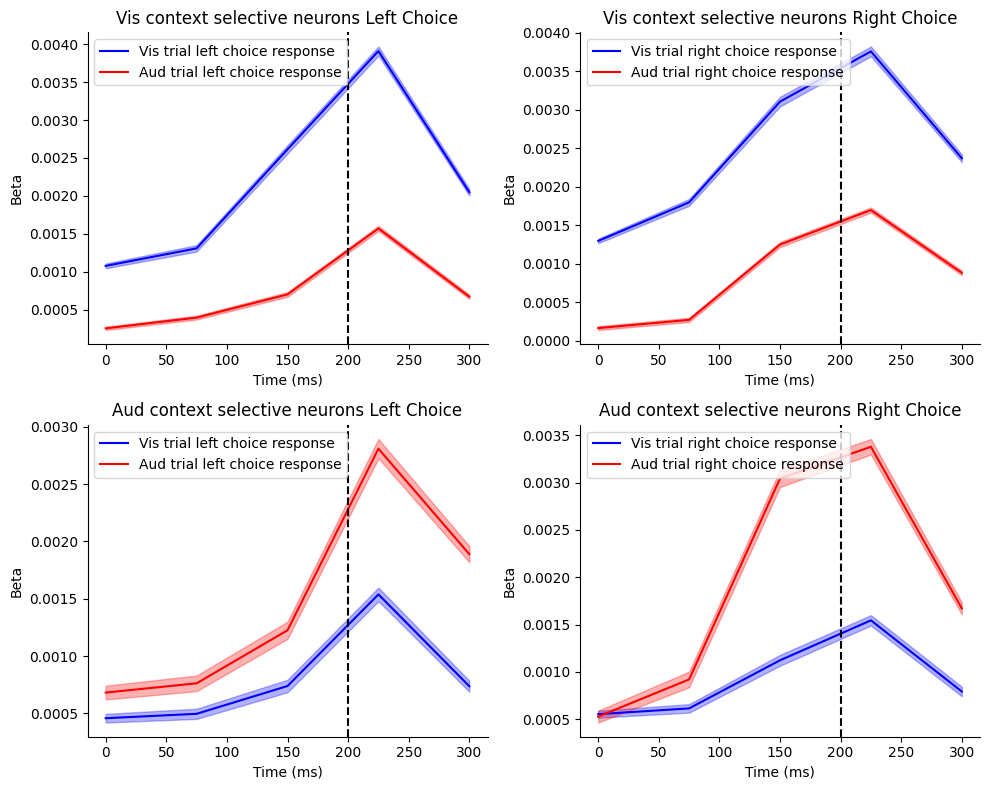

In [27]:

fig, axes = plt.subplots(2,2, figsize=(10,8))
plot_with_error_shading(vis_left_choice_beta[vis_left_context_neuron_idx], time_points=beta_timepoint, color='blue', ax=axes[0,0], label='Vis trial left choice response')
plot_with_error_shading(aud_left_choice_beta[vis_left_context_neuron_idx], time_points=beta_timepoint, color='red', ax=axes[0,0], label='Aud trial left choice response')
axes[0,0].axvline(x=200, color='black', linestyle='--')
axes[0,0].set_title('Vis context selective neurons Left Choice')
axes[0,0].set_xlabel('Time (ms)')
axes[0,0].set_ylabel('Beta')
axes[0,0].legend(loc='upper left')
#axes[0,0].text(0.5, 0.5, str(len(vis_left_context_neuron_idx))+'\\'+str(vis_left_choice_beta.shape[0]), ha='center', va='center', transform=axes[0,0].transAxes)
plot_with_error_shading(vis_right_choice_beta[vis_right_context_neuron_idx], time_points=beta_timepoint, color='blue', ax=axes[0,1], label='Vis trial right choice response')
plot_with_error_shading(aud_right_choice_beta[vis_right_context_neuron_idx], time_points=beta_timepoint, color='red', ax=axes[0,1], label='Aud trial right choice response')
axes[0,1].axvline(x=200, color='black', linestyle='--')
axes[0,1].set_title('Vis context selective neurons Right Choice')
axes[0,1].set_xlabel('Time (ms)')
axes[0,1].set_ylabel('Beta')
axes[0,0].legend(loc='upper left')
plot_with_error_shading(vis_left_choice_beta[aud_left_context_neuron_idx], time_points=beta_timepoint, color='blue', ax=axes[1,0], label='Vis trial left choice response')
plot_with_error_shading(aud_left_choice_beta[aud_left_context_neuron_idx], time_points=beta_timepoint, color='red', ax=axes[1,0], label='Aud trial left choice response')
axes[1,0].axvline(x=200, color='black', linestyle='--')
axes[1,0].set_title('Aud context selective neurons Left Choice')
axes[1,0].set_xlabel('Time (ms)')
axes[1,0].set_ylabel('Beta')
axes[0,0].legend(loc='upper left')
plot_with_error_shading(vis_right_choice_beta[aud_right_context_neuron_idx], time_points=beta_timepoint, color='blue', ax=axes[1,1], label='Vis trial right choice response')
plot_with_error_shading(aud_right_choice_beta[aud_right_context_neuron_idx], time_points=beta_timepoint, color='red', ax=axes[1,1], label='Aud trial right choice response')
axes[1,1].axvline(x=200, color='black', linestyle='--')
axes[1,1].set_title('Aud context selective neurons Right Choice')
axes[1,1].set_xlabel('Time (ms)')
axes[1,1].set_ylabel('Beta')
axes[0,0].legend(loc='upper left')
plt.tight_layout()
plt.show()


In [96]:
aud_right_choice_psth[aud_right_context_neuron_idx].shape

(8039, 25)

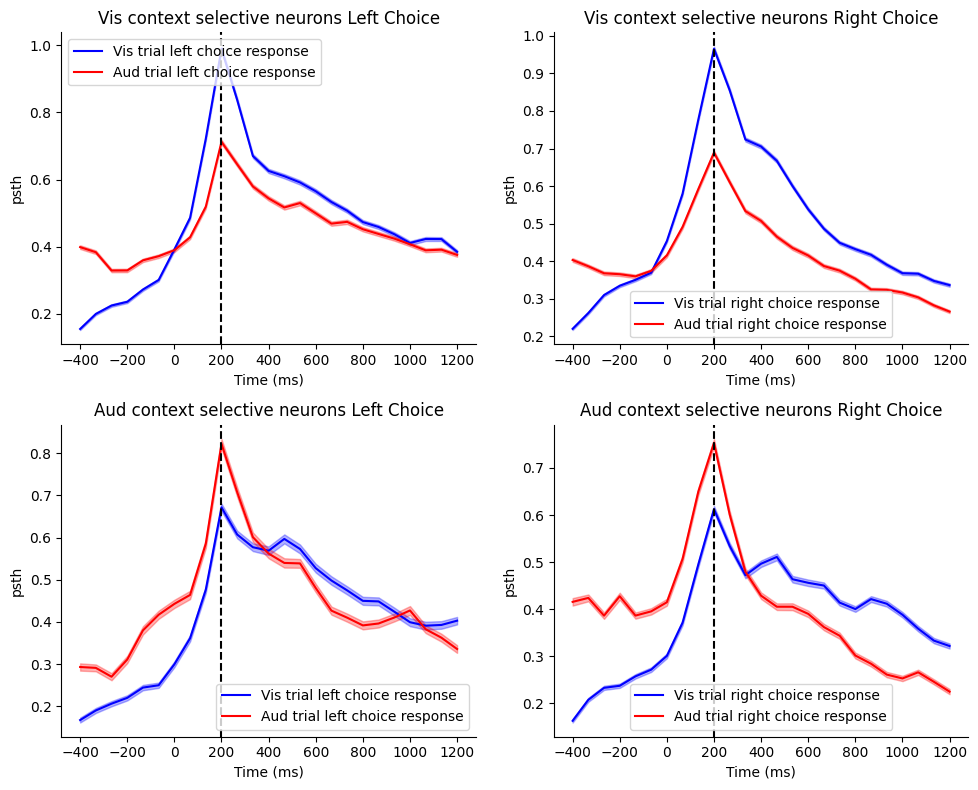

In [90]:
fig, axes = plt.subplots(2,2, figsize=(10,8))
plot_with_error_shading(vis_left_choice_psth[vis_left_context_neuron_idx], time_points=psth_timepoint, color='blue', ax=axes[0,0], label='Vis trial left choice response')
plot_with_error_shading(aud_left_choice_psth[vis_left_context_neuron_idx], time_points=psth_timepoint, color='red', ax=axes[0,0], label='Aud trial left choice response')
axes[0,0].axvline(x=200, color='black', linestyle='--')
axes[0,0].set_title('Vis context selective neurons Left Choice')
axes[0,0].set_xlabel('Time (ms)')
axes[0,0].set_ylabel('psth')
axes[0,0].legend(loc='upper left')
plot_with_error_shading(vis_right_choice_psth[vis_right_context_neuron_idx], time_points=psth_timepoint, color='blue', ax=axes[0,1], label='Vis trial right choice response')
plot_with_error_shading(aud_right_choice_psth[vis_right_context_neuron_idx], time_points=psth_timepoint, color='red', ax=axes[0,1], label='Aud trial right choice response')
axes[0,1].axvline(x=200, color='black', linestyle='--')
axes[0,1].set_title('Vis context selective neurons Right Choice')
axes[0,1].set_xlabel('Time (ms)')
axes[0,1].set_ylabel('psth')
axes[0,0].legend(loc='upper left')
plot_with_error_shading(vis_left_choice_psth[aud_left_context_neuron_idx], time_points=psth_timepoint, color='blue', ax=axes[1,0], label='Vis trial left choice response')
plot_with_error_shading(aud_left_choice_psth[aud_left_context_neuron_idx], time_points=psth_timepoint, color='red', ax=axes[1,0], label='Aud trial left choice response')
axes[1,0].axvline(x=200, color='black', linestyle='--')
axes[1,0].set_title('Aud context selective neurons Left Choice')
axes[1,0].set_xlabel('Time (ms)')
axes[1,0].set_ylabel('psth')
axes[0,0].legend(loc='upper left')
plot_with_error_shading(vis_right_choice_psth[aud_right_context_neuron_idx], time_points=psth_timepoint, color='blue', ax=axes[1,1], label='Vis trial right choice response')
plot_with_error_shading(aud_right_choice_psth[aud_right_context_neuron_idx], time_points=psth_timepoint, color='red', ax=axes[1,1], label='Aud trial right choice response')
axes[1,1].axvline(x=200, color='black', linestyle='--')
axes[1,1].set_title('Aud context selective neurons Right Choice')
axes[1,1].set_xlabel('Time (ms)')
axes[1,1].set_ylabel('psth')
axes[0,0].legend(loc='upper left')
plt.tight_layout()
plt.show()

In [52]:
alpha = 0.05
vis_left_choice_neuron_idx =  np.where((vis_left_choice_pval<alpha) & (vis_right_choice_pval>alpha))[0]
aud_left_choice_neuron_idx = np.where((aud_left_choice_pval<alpha) & (aud_right_choice_pval>alpha))[0]
vis_right_choice_neuron_idx = np.where((vis_right_choice_pval<alpha) & (vis_left_choice_pval>alpha))[0]
aud_right_choice_neuron_idx = np.where((aud_right_choice_pval<alpha) & (aud_left_choice_pval>alpha))[0]

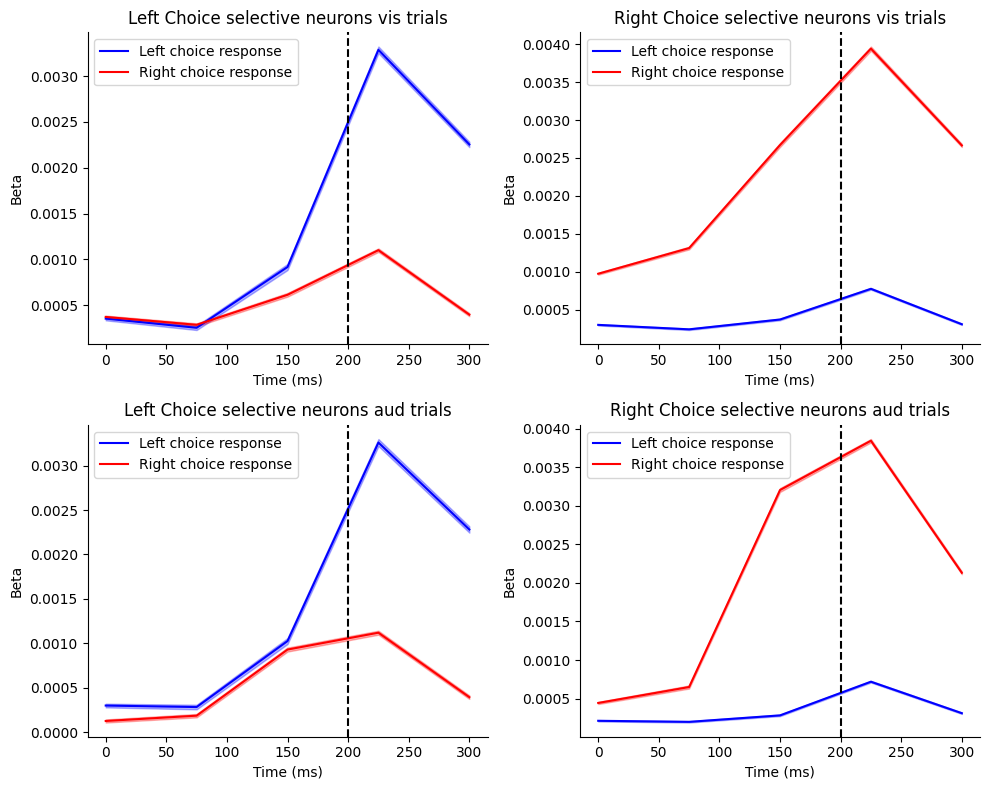

In [93]:

fig, axes = plt.subplots(2,2, figsize=(10,8))
plot_with_error_shading(vis_left_choice_beta[vis_left_choice_neuron_idx], time_points=beta_timepoint, color='blue', ax=axes[0,0], label='Left choice response')
plot_with_error_shading(vis_right_choice_beta[vis_left_choice_neuron_idx], time_points=beta_timepoint, color='red', ax=axes[0,0], label='Right choice response')
axes[0,0].axvline(x=200, color='black', linestyle='--')
axes[0,0].set_title('Left Choice selective neurons vis trials')
axes[0,0].set_xlabel('Time (ms)')
axes[0,0].set_ylabel('Beta')
axes[0,0].legend(loc='upper left')
plot_with_error_shading(vis_left_choice_beta[vis_right_choice_neuron_idx], time_points=beta_timepoint, color='blue', ax=axes[0,1], label='Left choice response')
plot_with_error_shading(vis_right_choice_beta[vis_right_choice_neuron_idx], time_points=beta_timepoint, color='red', ax=axes[0,1], label='Right choice response')
axes[0,1].axvline(x=200, color='black', linestyle='--')
axes[0,1].set_title('Right Choice selective neurons vis trials')
axes[0,1].set_xlabel('Time (ms)')
axes[0,1].set_ylabel('Beta')
axes[0,0].legend(loc='upper left')
plot_with_error_shading(aud_left_choice_beta[aud_left_choice_neuron_idx], time_points=beta_timepoint, color='blue', ax=axes[1,0], label='Left choice response')
plot_with_error_shading(aud_right_choice_beta[aud_left_choice_neuron_idx], time_points=beta_timepoint, color='red', ax=axes[1,0], label='Right choice response')
axes[1,0].axvline(x=200, color='black', linestyle='--')
axes[1,0].set_title('Left Choice selective neurons aud trials')
axes[1,0].set_xlabel('Time (ms)')
axes[1,0].set_ylabel('Beta')
axes[0,0].legend(loc='upper left')
plot_with_error_shading(aud_left_choice_beta[aud_right_choice_neuron_idx], time_points=beta_timepoint, color='blue', ax=axes[1,1], label='Left choice response')
plot_with_error_shading(aud_right_choice_beta[aud_right_choice_neuron_idx], time_points=beta_timepoint, color='red', ax=axes[1,1], label='Right choice response')
axes[1,1].axvline(x=200, color='black', linestyle='--')
axes[1,1].set_title('Right Choice selective neurons aud trials')
axes[1,1].set_xlabel('Time (ms)')
axes[1,1].set_ylabel('Beta')
axes[0,0].legend(loc='upper left')
plt.tight_layout()
plt.show()

In [15]:
left_choice_pval = []
right_choice_pval = []
left_choice_r2 = []
right_choice_r2 = []
arms = ('arm1', 'arm2')
for mouse in mouse_ids:
    #print('processing mouse: ', mouse)
    mouse_data = agg_data.get(mouse, {})
    for date, day in mouse_data.items():
        # filters
        if 'training' in date:
            continue
        
        for arm in arms:
            arm_dict = day.get(arm)
            if arm_dict is None:
                continue

            stats = arm_dict.get('stat', [])
            if len(stats) == 0:
                continue
            for i, neuron in enumerate(stats):
                left_choice_pval.append(neuron['bootstrap_p_value'][-2])
                right_choice_pval.append(neuron['bootstrap_p_value'][-1])
                left_choice_r2.append(neuron['unique_explained_variance'][-2])
                right_choice_r2.append(neuron['unique_explained_variance'][-1])
left_choice_pval = np.asarray(left_choice_pval)
right_choice_pval = np.asarray(right_choice_pval)
left_choice_r2 = np.asarray(left_choice_r2)
right_choice_r2 = np.asarray(right_choice_r2)



In [16]:
alpha = 0.01
left_choice_neuron_idx =  np.where((left_choice_pval<alpha) & (right_choice_pval>alpha))[0]
right_choice_neuron_idx = np.where((left_choice_pval>alpha) & (right_choice_pval<alpha))[0]
bilateral_choice_neuron_idx = np.where((left_choice_pval<alpha) & (right_choice_pval<alpha))[0]
print(len(left_choice_neuron_idx), len(right_choice_neuron_idx), len(bilateral_choice_neuron_idx))

3091 11008 959


In [64]:
left_choice_psth.shape

(84388, 25)

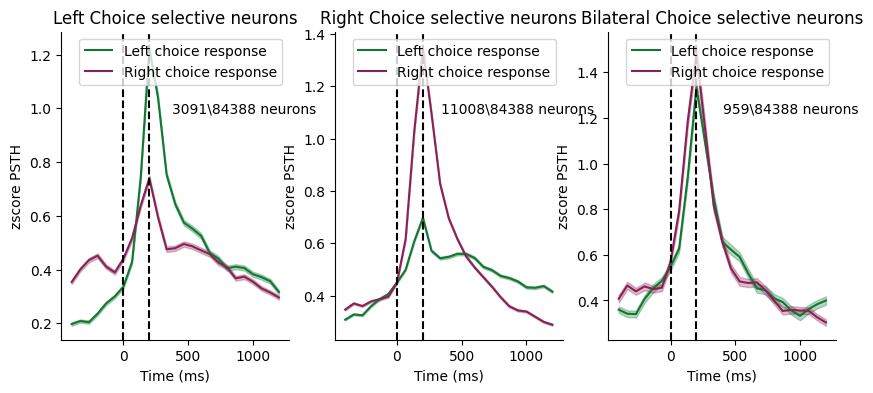

In [69]:
left_choice_psth = (vis_left_choice_psth+aud_left_choice_psth)/2
right_choice_psth = (vis_right_choice_psth+aud_right_choice_psth)/2

fig, axes = plt.subplots(1,3, figsize=(10,4))
left_choice_color = '#117733'
right_choice_color = '#882255'
plot_with_error_shading(left_choice_psth[left_choice_neuron_idx], time_points=psth_timepoint, color=left_choice_color, ax=axes[0], label='Left choice response')
plot_with_error_shading(right_choice_psth[left_choice_neuron_idx], time_points=psth_timepoint, color=right_choice_color, ax=axes[0], label='Right choice response')
axes[0].axvline(x=200, color='black', linestyle='--')
axes[0].set_title('Left Choice selective neurons')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('zscore PSTH')
axes[0].legend(loc='upper right')
axes[0].axvline(x=0, color='black', linestyle='--')
axes[0].text(0.8, 0.75, str(len(left_choice_neuron_idx))+'\\'+str(left_choice_psth.shape[0])+' neurons', ha='center', va='center', transform=axes[0].transAxes)
plot_with_error_shading(left_choice_psth[right_choice_neuron_idx], time_points=psth_timepoint, color=left_choice_color, ax=axes[1], label='Left choice response')
plot_with_error_shading(right_choice_psth[right_choice_neuron_idx], time_points=psth_timepoint, color=right_choice_color, ax=axes[1], label='Right choice response')
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_title('Right Choice selective neurons')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('zscore PSTH')
axes[1].legend(loc='upper right')
axes[1].text(0.8, 0.75, str(len(right_choice_neuron_idx))+'\\'+str(right_choice_psth.shape[0])+' neurons', ha='center', va='center', transform=axes[1].transAxes)
axes[1].axvline(x=200, color='black', linestyle='--')

plot_with_error_shading(left_choice_psth[bilateral_choice_neuron_idx], time_points=psth_timepoint, color=left_choice_color, ax=axes[2], label='Left choice response')
plot_with_error_shading(right_choice_psth[bilateral_choice_neuron_idx], time_points=psth_timepoint, color=right_choice_color, ax=axes[2], label='Right choice response')
axes[2].axvline(x=0, color='black', linestyle='--')
axes[2].set_title('Bilateral Choice selective neurons')
axes[2].set_xlabel('Time (ms)')
axes[2].set_ylabel('zscore PSTH')
axes[2].legend(loc='upper right')
axes[2].text(0.8, 0.75, str(len(bilateral_choice_neuron_idx))+'\\'+str(left_choice_psth.shape[0])+' neurons', ha='center', va='center', transform=axes[2].transAxes)
axes[2].axvline(x=200, color='black', linestyle='--')


In [70]:
fig.savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig5', "psth_avg_choice_neurons.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

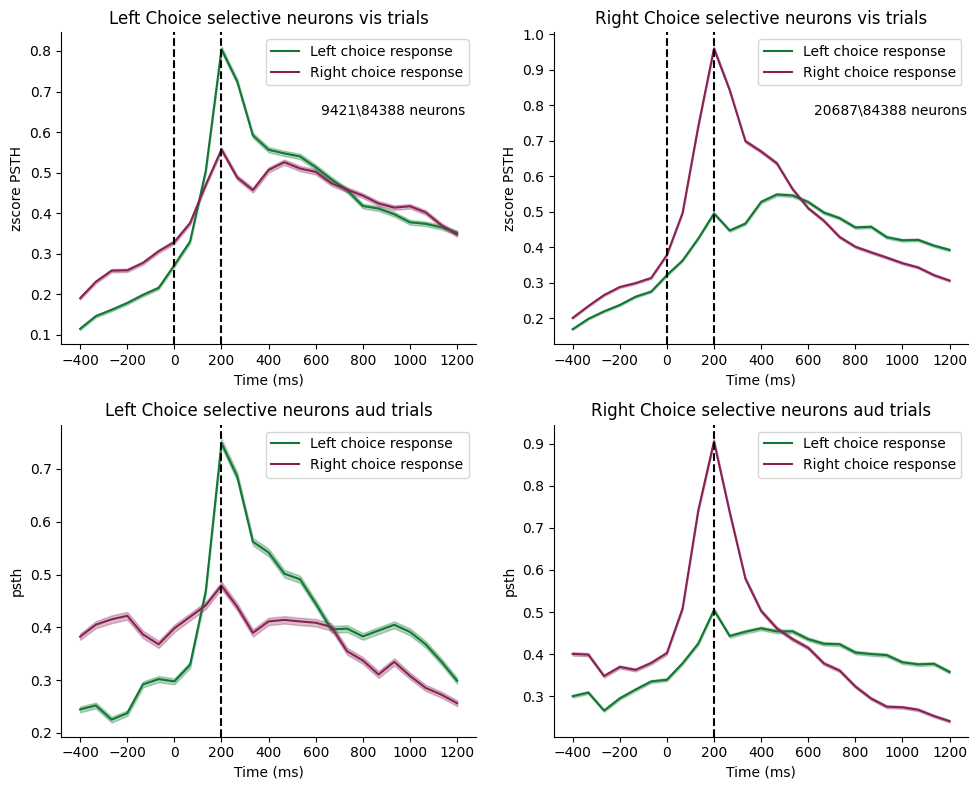

In [53]:
fig, axes = plt.subplots(2,2, figsize=(10,8))
left_choice_color = '#117733'
right_choice_color = '#882255'
plot_with_error_shading(vis_left_choice_psth[vis_left_choice_neuron_idx], time_points=psth_timepoint, color=left_choice_color, ax=axes[0,0], label='Left choice response')
plot_with_error_shading(vis_right_choice_psth[vis_left_choice_neuron_idx], time_points=psth_timepoint, color=right_choice_color, ax=axes[0,0], label='Right choice response')
axes[0,0].axvline(x=200, color='black', linestyle='--')
axes[0,0].set_title('Left Choice selective neurons vis trials')
axes[0,0].set_xlabel('Time (ms)')
axes[0,0].set_ylabel('zscore PSTH')
axes[0,0].legend(loc='upper right')
axes[0,0].axvline(x=0, color='black', linestyle='--')
axes[0,0].text(0.8, 0.75, str(len(vis_left_choice_neuron_idx))+'\\'+str(vis_left_choice_psth.shape[0])+' neurons', ha='center', va='center', transform=axes[0,0].transAxes)
plot_with_error_shading(vis_left_choice_psth[vis_right_choice_neuron_idx], time_points=psth_timepoint, color=left_choice_color, ax=axes[0,1], label='Left choice response')
plot_with_error_shading(vis_right_choice_psth[vis_right_choice_neuron_idx], time_points=psth_timepoint, color=right_choice_color, ax=axes[0,1], label='Right choice response')
axes[0,1].axvline(x=0, color='black', linestyle='--')
axes[0,1].set_title('Right Choice selective neurons vis trials')
axes[0,1].set_xlabel('Time (ms)')
axes[0,1].set_ylabel('zscore PSTH')
axes[0,1].legend(loc='upper right')
axes[0,1].text(2.0, 0.75, str(len(vis_right_choice_neuron_idx))+'\\'+str(vis_right_choice_psth.shape[0])+' neurons', ha='center', va='center', transform=axes[0,0].transAxes)
axes[0,1].axvline(x=200, color='black', linestyle='--')
plot_with_error_shading(aud_left_choice_psth[aud_left_choice_neuron_idx], time_points=psth_timepoint, color=left_choice_color, ax=axes[1,0], label='Left choice response')
plot_with_error_shading(aud_right_choice_psth[aud_left_choice_neuron_idx], time_points=psth_timepoint, color=right_choice_color, ax=axes[1,0], label='Right choice response')
axes[1,0].axvline(x=200, color='black', linestyle='--')
axes[1,0].set_title('Left Choice selective neurons aud trials')
axes[1,0].set_xlabel('Time (ms)')
axes[1,0].set_ylabel('psth')
axes[1,0].legend(loc='upper right')
plot_with_error_shading(aud_left_choice_psth[aud_right_choice_neuron_idx], time_points=psth_timepoint, color=left_choice_color, ax=axes[1,1], label='Left choice response')
plot_with_error_shading(aud_right_choice_psth[aud_right_choice_neuron_idx], time_points=psth_timepoint, color=right_choice_color, ax=axes[1,1], label='Right choice response')
axes[1,1].axvline(x=200, color='black', linestyle='--')
axes[1,1].set_title('Right Choice selective neurons aud trials')
axes[1,1].set_xlabel('Time (ms)')
axes[1,1].set_ylabel('psth')
axes[1,1].legend(loc='upper right')
plt.tight_layout()
plt.show()

In [34]:
assert(vis_left_choice_psth.shape == vis_right_choice_psth.shape == aud_left_choice_psth.shape == aud_right_choice_psth.shape)

In [ ]:
psth_timepoint = np.linspace(psth_time_start*1000,psth_time_end*1000,vis_left_choice_psth.shape[1])
choice_onset_idx = np.where(psth_timepoint == 0)[0][0]
movement_onset_idx = np.where(psth_timepoint == 200)[0][0]
t_choice_window = np.arange(choice_onset_idx, movement_onset_idx)
t_baseline = np.arange(0, choice_onset_idx)


In [3]:
agg_data['AE_L2']['20250624_valvesilent']['arm1']['stat'][1]['bootstrap_p_value'].shape

NameError: name 'agg_data' is not defined

In [35]:
unique_predictors

['vis_ruleCue_times',
 'aud_ruleCue_times',
 'left_vis_stimOn_times',
 'right_vis_stimOn_times',
 'left_aud_stimOn_times',
 'right_aud_stimOn_times',
 'vis_left_choice_times',
 'vis_right_choice_times',
 'aud_left_choice_times',
 'aud_right_choice_times',
 'vis_reward_times',
 'aud_reward_times',
 'vis_punish_times',
 'aud_punish_times',
 'omission_times',
 'previous_feedbackType',
 'reward_history',
 'body',
 'lick',
 'face',
 'pupil_area',
 'pupil_xpos',
 'pupil_ypos',
 'vel']

In [4]:
def loo_reconstruct_activity(neuron, X, preds, full_predictors, exact_match=True):
    """
    Reconstruct activity for a single neuron using the full model and a
    leave-one-out (LOO) version where all columns belonging to `pred` are removed
    (by zeroing their betas). No refitting is performed.

    Parameters
    ----------
    neuron : dict
        Must contain:
          - 'beta': (P,) or (1,P) array of weights for this neuron (matches X columns)
          - 'intercept': scalar
    X : array, shape (T, P)
        Design matrix used to fit the model (same column order as full_predictors).
    pred : list of str
        Unique predictor name to leave out (matches columns in `full_predictors`).
    full_predictors : list[str] of length P
        Names for each column of X (e.g., expanded supports for events).
    exact_match : bool, default True
        If True, match columns where name == pred or name startswith(pred).
        If False, use substring containment (pred in name).

    Returns
    -------
    y_full : (T,) ndarray
        Reconstruction with all predictors: X @ beta + intercept.
    y_loo : (T,) ndarray
        Reconstruction with `pred` columns removed (their contribution zeroed).
    contrib : (T,) ndarray
        The contribution of `pred` alone (y_full - y_loo).
    idx : (K,) ndarray
        Integer indices of columns belonging to `pred`.
    """
    beta = np.asarray(neuron['beta']).ravel()
    b0 = float(neuron.get('intercept', 0.0))

    if X.shape[1] != beta.size:
        raise ValueError(f"Shape mismatch: X has {X.shape[1]} columns but beta has {beta.size}.")

    # pick columns for this unique predictor
    all_idx = []
    if exact_match:
        for pred in preds:
            idx = np.array(
                [i for i, nm in enumerate(full_predictors) if (nm == pred) or nm.startswith(pred)],
                dtype=int
            )
            all_idx.append(idx)
    else:
        for pred in preds:
            idx = np.array(
                [i for i, nm in enumerate(full_predictors) if pred in nm],
                dtype=int
            )
            all_idx.append(idx)
    all_idx = np.concatenate(all_idx)
    #print(idx)
    # full reconstruction
    y_full = X @ beta + b0

    # contribution of the predictor's columns
    if all_idx.size > 0:
        contrib = X[:, all_idx] @ beta[all_idx]
    else:
        contrib = np.zeros(X.shape[0], dtype=float)

    # LOO reconstruction (remove that contribution)
    y_loo = y_full - contrib

    return y_full, y_loo
    

In [17]:
agg_data['AE_L2']['20250624_valvesilent']['arm1']['table_for_img']

,intervals_0,intervals_1,ruleCue_times,ruleCueTrigger_times,response_times,choice,stimOnTrigger_times,stimOn_times,contrastLeft,contrastRight,...,left_vis_stimOn_times,right_vis_stimOn_times,left_aud_stimOn_times,right_aud_stimOn_times,vis_left_choice_times,vis_right_choice_times,aud_left_choice_times,aud_right_choice_times,previous_feedbackType,reward_history
0,531,917,654,654,863,-1,666,669,1.0,NaN,...,669.0,NaN,NaN,NaN,858.0,NaN,NaN,NaN,0,0.60
1,939,1253,949,948,1199,1,960,961,NaN,1.0,...,NaN,961.0,NaN,NaN,NaN,1195.0,NaN,NaN,-1,0.60
2,1275,1521,1308,1308,1498,1,1320,1321,1.0,NaN,...,1321.0,NaN,NaN,NaN,NaN,1492.0,NaN,NaN,-1,0.60
3,1541,1649,1554,1554,1595,-1,1566,1567,0.5,NaN,...,1567.0,NaN,NaN,NaN,1590.0,NaN,NaN,NaN,1,0.60
4,1671,1825,1750,1749,1801,-1,1762,1762,NaN,0.5,...,NaN,1762.0,NaN,NaN,1796.0,NaN,NaN,NaN,-1,0.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,44538,44941,44545,44545,44887,1,44557,44558,NaN,0.0,...,NaN,NaN,NaN,44557.0,NaN,NaN,NaN,44878.0,-1,0.35
258,44962,45177,44970,44969,45153,1,44982,44982,0.0,NaN,...,NaN,NaN,44982.0,NaN,NaN,NaN,NaN,45147.0,-1,0.40
259,45197,45302,45229,45229,45248,-1,45241,45242,0.0,NaN,...,NaN,NaN,45241.0,NaN,NaN,NaN,45239.0,NaN,1,0.40
260,45321,45801,45364,45363,45777,1,45375,45376,1.0,NaN,...,45376.0,NaN,NaN,NaN,NaN,45771.0,NaN,NaN,-1,0.40


In [5]:
def plot_loo_reconstruction(neuron, design_matrix, table_for_img, pred, loo_pred = None, full_predictors = predictors, psth = None,psth_time_start = None, psth_time_end = None, psth_timepoint = None, ax = None, color = 'blue', label = True):
    """
    Reconstruct activity for a single neuron using the full model and a leave-one-out (LOO) version where all columns belonging to `pred` are removed (by zeroing their betas). 
    No refitting is performed.
    If loo_pred is None, the function will use the full model and remove the columns belonging to `pred`.
    If loo_pred is not None, the function will use the full model and remove the columns belonging to the list of predictors in loo_pred.
    """
    psth_pred = pred
    if pred == 'left_choice_times':
        print('left choice times')
        pred = ['vis_left_choice_times', 'aud_left_choice_times']
    elif pred == 'right_choice_times':
        pred = ['vis_right_choice_times', 'aud_right_choice_times']
    
    if loo_pred is None:
        if isinstance(pred, list):
            pred2loo = pred
        else:
            pred2loo = [pred]
    else:
        pred2loo = loo_pred
        
    y_full, y_loo = loo_reconstruct_activity(neuron, design_matrix, pred2loo, full_predictors = predictors, exact_match=False)
    y_full = np.concatenate([np.zeros(table_for_img['ruleCue_times'][0]), y_full])
    y_loo = np.concatenate([np.zeros(table_for_img['ruleCue_times'][0]), y_loo])
    
    if psth_pred == 'left_choice_times':
        psth_frame_idx = np.concatenate(
            [
                find_frame_indices(table_for_img, 15, (psth_time_start, psth_time_end), 'aud_left_choice_times').astype(int),
                find_frame_indices(table_for_img, 15, (psth_time_start, psth_time_end), 'vis_left_choice_times').astype(int)
            ],
            axis=0
        )
    elif psth_pred == 'right_choice_times':
        psth_frame_idx = np.concatenate(
            [
                find_frame_indices(table_for_img, 15, (psth_time_start, psth_time_end), 'aud_right_choice_times').astype(int),
                find_frame_indices(table_for_img, 15, (psth_time_start, psth_time_end), 'vis_right_choice_times').astype(int)
            ],
            axis=0
        )
    else:
        psth_frame_idx = find_frame_indices(table_for_img, 15, (psth_time_start, psth_time_end), psth_pred).astype(int)
    
    y_full_psth = np.squeeze(get_trial_PSTH(y_full.reshape(1, -1), psth_frame_idx, zscore=False))
    y_full_mean_psth = np.nanmean(y_full_psth, axis=0)
    y_full_bsl_mean = np.nanmean(y_full_psth[:, np.arange(0, int(np.abs(psth_time_start)/0.066))].ravel())
    
    y_loo_psth = np.squeeze(get_trial_PSTH(y_loo.reshape(1, -1), psth_frame_idx, zscore=False))
    y_loo_mean_psth = np.nanmean(y_loo_psth, axis=0)
    y_loo_bsl_mean = np.nanmean(y_loo_psth[:, np.arange(0, int(np.abs(psth_time_start)/0.066))].ravel())
    #plot_with_error_shading(y_full_psth-y_full_bsl_mean, time_points=psth_timepoint, color='blue', ax=ax, label='Full model')
    #plot_with_error_shading(y_loo_psth-y_loo_bsl_mean, time_points=psth_timepoint, color='red', ax=ax, label='LOO model')
    if label:
        ax.plot(psth_timepoint, y_full_mean_psth-y_full_bsl_mean, color=color, label='Full model', linewidth = 3)
    else:
        ax.plot(psth_timepoint, y_full_mean_psth-y_full_bsl_mean, color=color, linewidth = 3)
    if label:
        ax.plot(psth_timepoint, y_loo_mean_psth-y_loo_bsl_mean, color=color, label='LOO model', linestyle='--', linewidth = 2)
    else:
        ax.plot(psth_timepoint, y_loo_mean_psth-y_loo_bsl_mean, color=color, linestyle='--', linewidth = 2)
    if psth is None:
        if psth_pred == 'left_choice_times':
            raw_psth1 = neuron['vis_left_choice_times_psth_raw']
            raw_psth2 = neuron['aud_left_choice_times_psth_raw']
            raw_psth = np.concatenate([raw_psth1, raw_psth2], axis=0)
        elif psth_pred == 'right_choice_times':
            raw_psth1 = neuron['vis_right_choice_times_psth_raw']
            raw_psth2 = neuron['aud_right_choice_times_psth_raw']
            raw_psth = np.concatenate([raw_psth1, raw_psth2], axis=0)
        else:
            raw_psth = neuron[psth_pred+'_psth_raw']
        psth_bsl_mean = np.nanmean(raw_psth[:, np.arange(0, int(np.abs(psth_time_start)/0.066))].ravel())
        bsl_corr_psth = raw_psth-psth_bsl_mean
        if label:
            plot_with_error_shading(bsl_corr_psth, time_points=psth_timepoint, color=color, ax=ax, label='Neuron PSTH')
        else:
            plot_with_error_shading(bsl_corr_psth, time_points=psth_timepoint, color=color, ax=ax)
    else:
        if psth.ndim != 1:
            psth_bsl_mean = np.nanmean(psth[:, np.arange(0, int(np.abs(psth_time_start)/0.066))].ravel())
            bsl_corr_psth = psth-psth_bsl_mean
            if label:
                plot_with_error_shading(bsl_corr_psth, time_points=psth_timepoint, color=color, ax=ax, label='Neuron PSTH')
            else:
                plot_with_error_shading(bsl_corr_psth, time_points=psth_timepoint, color=color, ax=ax)
        else:
            psth_bsl_mean = np.nanmean(psth[np.arange(0, int(np.abs(psth_time_start)/0.066))])
            bsl_corr_psth = psth-psth_bsl_mean
            if label:
                ax.plot(psth_timepoint, bsl_corr_psth, color=color, label='Neuron PSTH', linewidth = 2)
            else:
                ax.plot(psth_timepoint, bsl_corr_psth, color=color, linewidth = 2)
    # plt.show()



In [113]:
unique_predictors

['vis_ruleCue_times',
 'aud_ruleCue_times',
 'left_vis_stimOn_times',
 'right_vis_stimOn_times',
 'left_aud_stimOn_times',
 'right_aud_stimOn_times',
 'vis_left_choice_times',
 'vis_right_choice_times',
 'aud_left_choice_times',
 'aud_right_choice_times',
 'vis_reward_times',
 'aud_reward_times',
 'vis_punish_times',
 'aud_punish_times',
 'omission_times',
 'previous_feedbackType',
 'reward_history',
 'body',
 'lick',
 'face',
 'pupil_area',
 'pupil_xpos',
 'pupil_ypos',
 'vel']

In [ ]:
vis_left_choice_psth_raw.shape

(80968, 5)

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10,8))
pred1 = 'left_aud_stimOn_times'
id =20000
m = beta_info['mouse'][id]
d = beta_info['date'][id]
a = beta_info['arm'][id]
i = beta_info['neuron_idx'][id]
neuron = agg_data[m][d][a]['stat'][i]
dm = agg_data[m][d][a]['design_matrix']
tf = agg_data[m][d][a]['table_for_img']
plot_loo_reconstruction(neuron, dm, tf, pred=pred1, full_predictors = predictors, 
                        psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = ax, color = 'blue')

plt.show()

In [13]:
psth_timepoint = np.linspace(psth_time_start*1000,psth_time_end*1000,25)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0.013081189560926548
left choice times
left choice times


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


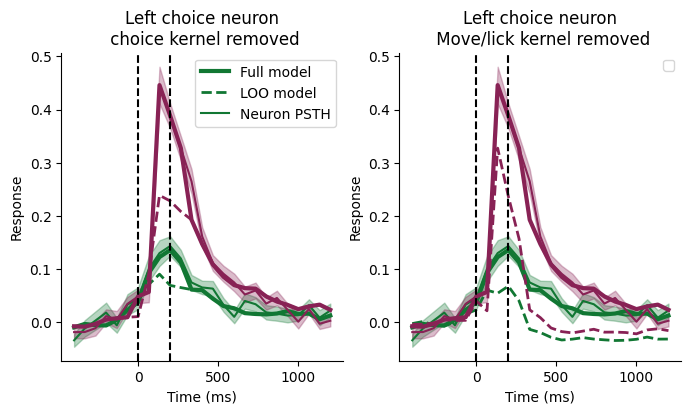

In [37]:
left_choice_color = '#117733'
right_choice_color = '#882255'
pred1 = 'left_choice_times'
pred2 = 'right_choice_times'
sorted_indices = np.argsort(right_choice_r2 - left_choice_r2)[::-1]
id = sorted_indices[500]
print((right_choice_r2 - left_choice_r2)[id])
m = beta_info['mouse'][id]
d = beta_info['date'][id]
a = beta_info['arm'][id]
i = beta_info['neuron_idx'][id]
neuron = agg_data[m][d][a]['stat'][i]
dm = agg_data[m][d][a]['design_matrix']
tf = agg_data[m][d][a]['table_for_img']
# psth1 = vis_left_choice_psth_raw[id]
# psth2 = vis_right_choice_psth_raw[id]
fig, axes = plt.subplots(1,2, figsize=(8,4))
plot_loo_reconstruction(neuron, dm, tf, pred=pred1, full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[0], color = left_choice_color)

plot_loo_reconstruction(neuron, dm, tf, pred=pred2, full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[0], color = right_choice_color, label = False)

plot_loo_reconstruction(neuron, dm, tf, pred=pred1, loo_pred=['face', 'body', 'lick', 'vel'], full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[1], color = left_choice_color, label = False)

plot_loo_reconstruction(neuron, dm, tf, pred=pred2, loo_pred=['face', 'body', 'lick', 'vel'], full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[1], color = right_choice_color, label = False)
axes[0].axvline(x=200, color='black', linestyle='--')
axes[0].axvline(x=0, color='black', linestyle='--')
axes[0].set_title('Left choice neuron\n choice kernel removed')
axes[1].axvline(x=200, color='black', linestyle='--')
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_title('Left choice neuron\n Move/lick kernel removed')
plt.show()

In [38]:
fig.savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig5', "example_neuron_kernel_removed_ipsiprefer.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

In [92]:
print(m, d, a, i)

AF_R3 20250828_valvesilent arm1 55


Reward stuff

In [10]:
t = agg_data['AE_L2']['20250624_valvesilent']['arm1']['table_for_img']
np.array(t['reward_consume_times']-t['feedback_times'])

array([ nan,  nan,   4.,  nan, 112.,  41.,  nan,   2.,  18.,   4.,  nan,
         1.,  nan,  nan,   4.,   3.,  nan,   2.,  23.,  nan,   4.,  nan,
        nan,  10.,  nan,  nan,  nan,   1.,  nan,  nan,  nan,  nan,  nan,
         2.,   1.,  nan,   3.,  nan,   3.,   2.,  nan,  nan,  54.,  nan,
         1.,   6.,  nan,  nan,  nan,   4.,  nan,  nan,   2.,  nan,  nan,
         5.,  nan,  nan,  nan,  nan,  nan,  25.,  nan,   3.,  nan,  nan,
         1.,  nan,   1.,  nan,  nan,   3.,  nan,  nan,  nan,   1.,  nan,
         3.,  nan,  nan,  nan,  nan,   3.,  nan,  nan,  nan,  nan,  nan,
         3.,  nan,  nan,  nan,  41.,  nan,  64.,   1.,  51.,   1.,  nan,
        nan,   2.,   1.,  nan,  nan,   4.,  nan,   7.,   9.,  nan,   3.,
         2.,  nan,   2.,   3.,   2.,  nan,  nan,   3.,  nan,  nan,  nan,
        10.,  nan,   2.,  nan,  nan,   2.,  nan,   1.,  nan,   2.,  nan,
         2.,   4.,  nan,   5.,   1.,   1.,   1.,   5.,  nan,  nan,   1.,
        nan,  nan,   1.,  nan,   2.,  nan,  37.,   

In [67]:
def get_agg_data_reward_psth(agg_data, mouse_ids, column_name, arms=('arm1', 'arm2'), raw = False, long_rt = False):
    """
    Aggregate PSTHs across mice/dates/arms efficiently.
    """
    if not raw:
        col_key = f"{column_name}_psth"
    else:
        col_key = f"{column_name}_psth_raw"
    blocks = []
    rt_info = {'mouse': [], 'date': [], 'arm': [], 'neuron_idx': []}

    for mouse in mouse_ids:
        
        mouse_data = agg_data.get(mouse, {})
        for date, day in mouse_data.items():
            print('processing mouse: ', mouse, 'date: ', date)
            # filters
            if 'training' in date:
                continue
            if column_name and 'reward' in column_name and 'valvesilent' not in date:
                continue
            if column_name and 'punish' in column_name and 'punishsilent' not in date:
                continue
            
            for arm in arms:
                arm_dict = day.get(arm)
                if arm_dict is None:
                    continue

                stats = arm_dict.get('stat', [])
                if len(stats) == 0:
                    continue
                if long_rt: # only for reward variable
                    t = arm_dict.get('table_for_img').copy()
                    t_filtered = t[t[column_name]>0].reset_index(drop=True)
                    t_filtered_longrt = t_filtered[(t_filtered['reward_consume_times']-t_filtered['feedback_times'])>3]
                    long_rt_idx = t_filtered_longrt.index.values
                batch = []
                for i, neuron in enumerate(stats):
                    arr = neuron.get(col_key)
                    if long_rt:
                        arr = arr[long_rt_idx]
                    arr = np.mean(arr, axis=0) # take trial average of psth
                    if arr is None:
                        continue
                    a = np.asarray(arr)
                    if a.ndim != 1:
                        a = a.reshape(-1)
                    batch.append(a)
                    rt_info['mouse'].append(mouse)
                    rt_info['date'].append(date)
                    rt_info['arm'].append(arm)
                    rt_info['neuron_idx'].append(i)

                if batch:
                    blocks.append(np.stack(batch, axis=0))

    rt = np.concatenate(blocks, axis=0) if blocks else np.empty((0, 0), dtype=float)
    return rt, rt_info


In [38]:
long_rt = False
vis_reward_psth_raw, psth_info = get_agg_data_reward_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='vis_reward_times', raw = True, long_rt = long_rt)
aud_reward_psth_raw, psth_info = get_agg_data_reward_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='aud_reward_times', raw = True, long_rt = long_rt)
vis_reward_psth, psth_info = get_agg_data_reward_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='vis_reward_times', raw = False, long_rt = long_rt)
aud_reward_psth, psth_info = get_agg_data_reward_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='aud_reward_times', raw = False, long_rt = long_rt)

processing mouse:  AE_L2 date:  20250612
processing mouse:  AE_L2 date:  20250624_valvesilent
processing mouse:  AE_L2 date:  20250701_valvesilent
processing mouse:  AE_L2 date:  20250708_valvesilent
processing mouse:  AE_L2 date:  20250715_valvesilent
processing mouse:  AE_L2 date:  20250729_valvesilent
processing mouse:  AE_L2 date:  20250814_valvesilent_punishsilent
processing mouse:  AE_L2 date:  20250821_valvesilent_punishsilent
processing mouse:  AE_L2 date:  training
processing mouse:  AE_L3 date:  20250612
processing mouse:  AE_L3 date:  20250617_valvesilent
processing mouse:  AE_L3 date:  20250624_valvesilent
processing mouse:  AE_L3 date:  20250701_valvesilent
processing mouse:  AE_L3 date:  20250708_valvesilent
processing mouse:  AE_L3 date:  20250722_valvesilent
processing mouse:  AE_L3 date:  20250729_valvesilent
processing mouse:  AE_L3 date:  20250812_valvesilent
processing mouse:  AE_L3 date:  20250820_valvesilent
processing mouse:  AE_L3 date:  20250828_valvesilent
pro

In [29]:
vis_reward_beta, vis_reward_pval, vis_reward_r2, beta_info = get_agg_data_beta(agg_data=agg_data, mouse_ids = mouse_ids, unique_predictors = unique_predictors, column_name='vis_reward_times')
aud_reward_beta, aud_reward_pval, aud_reward_r2, beta_info = get_agg_data_beta(agg_data=agg_data, mouse_ids = mouse_ids, unique_predictors = unique_predictors, column_name='aud_reward_times')


In [42]:
alpha = 0.002
vis_reward_neuron_idx =  np.where((vis_reward_pval<alpha) & (aud_reward_pval>alpha))[0]
aud_reward_neuron_idx = np.where((aud_reward_pval<alpha) & (vis_reward_pval>alpha))[0]
print(len(vis_reward_neuron_idx))
print(len(aud_reward_neuron_idx))

947
699


In [51]:
r2_thresh = 0.01
vis_reward_neuron_idx =  np.where((vis_reward_r2>r2_thresh) & (aud_reward_r2<r2_thresh))[0]
aud_reward_neuron_idx = np.where((aud_reward_r2>r2_thresh) & (vis_reward_r2<r2_thresh))[0]
print(len(vis_reward_neuron_idx))
print(len(aud_reward_neuron_idx))

115
38


In [39]:
psth_timepoint = np.linspace(psth_time_start*1000,psth_time_end*1000,vis_reward_psth.shape[1])
beta_timepoint = np.linspace(0,1000,vis_reward_beta.shape[1])

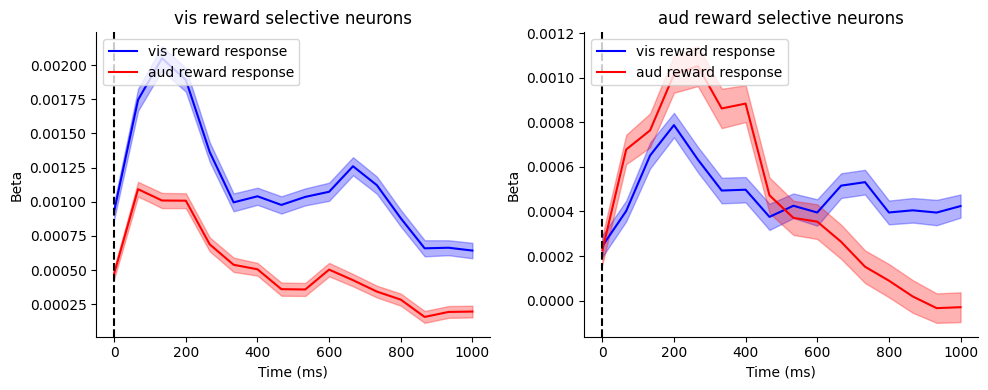

In [43]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
plot_with_error_shading(vis_reward_beta[vis_reward_neuron_idx], time_points=beta_timepoint, color='blue', ax=axes[0], label='vis reward response')
plot_with_error_shading(aud_reward_beta[vis_reward_neuron_idx], time_points=beta_timepoint, color='red', ax=axes[0], label='aud reward response')
axes[0].axvline(x=0, color='black', linestyle='--')
axes[0].set_title('vis reward selective neurons')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Beta')
axes[0].legend(loc='upper left')
plot_with_error_shading(vis_reward_beta[aud_reward_neuron_idx], time_points=beta_timepoint, color='blue', ax=axes[1], label='vis reward response')
plot_with_error_shading(aud_reward_beta[aud_reward_neuron_idx], time_points=beta_timepoint, color='red', ax=axes[1], label='aud reward response')
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_title('aud reward selective neurons')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Beta')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

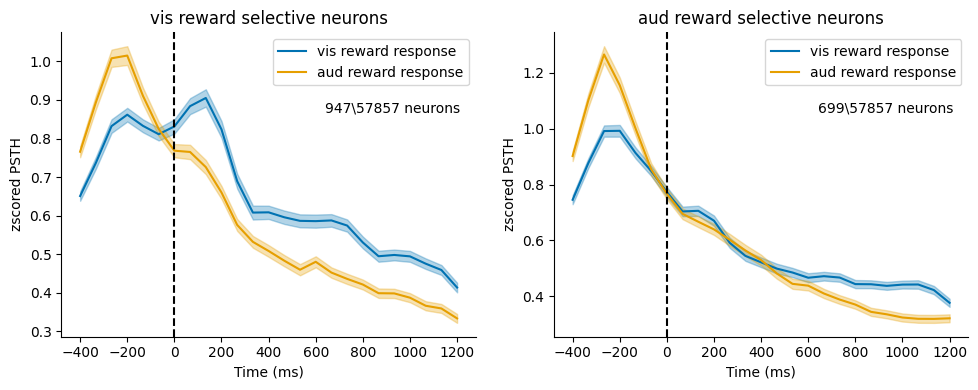

In [44]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
vis_color = '#0072B2'
aud_color = '#E69F00'
plot_with_error_shading(vis_reward_psth[vis_reward_neuron_idx], time_points=psth_timepoint, color=vis_color, ax=axes[0], label='vis reward response')
plot_with_error_shading(aud_reward_psth[vis_reward_neuron_idx], time_points=psth_timepoint, color=aud_color, ax=axes[0], label='aud reward response')
axes[0].axvline(x=0, color='black', linestyle='--')
axes[0].set_title('vis reward selective neurons')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('zscored PSTH')
axes[0].legend(loc='upper right')
axes[0].text(0.8, 0.75, str(len(vis_reward_neuron_idx))+'\\'+str(vis_reward_psth.shape[0])+' neurons', ha='center', va='center', transform=axes[0].transAxes)
plot_with_error_shading(vis_reward_psth[aud_reward_neuron_idx], time_points=psth_timepoint, color=vis_color, ax=axes[1], label='vis reward response')
plot_with_error_shading(aud_reward_psth[aud_reward_neuron_idx], time_points=psth_timepoint, color=aud_color, ax=axes[1], label='aud reward response')
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_title('aud reward selective neurons')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('zscored PSTH')
axes[1].legend(loc='upper right')
axes[1].text(0.8, 0.75, str(len(aud_reward_neuron_idx))+'\\'+str(aud_reward_psth.shape[0])+' neurons', ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

In [37]:
unique_predictors

['vis_ruleCue_times',
 'aud_ruleCue_times',
 'left_vis_stimOn_times',
 'right_vis_stimOn_times',
 'left_aud_stimOn_times',
 'right_aud_stimOn_times',
 'vis_left_choice_times',
 'vis_right_choice_times',
 'aud_left_choice_times',
 'aud_right_choice_times',
 'vis_reward_times',
 'aud_reward_times',
 'vis_punish_times',
 'aud_punish_times',
 'omission_times',
 'previous_feedbackType',
 'reward_history',
 'body',
 'lick',
 'face',
 'pupil_area',
 'pupil_xpos',
 'pupil_ypos',
 'vel']

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


-0.00454306631349701


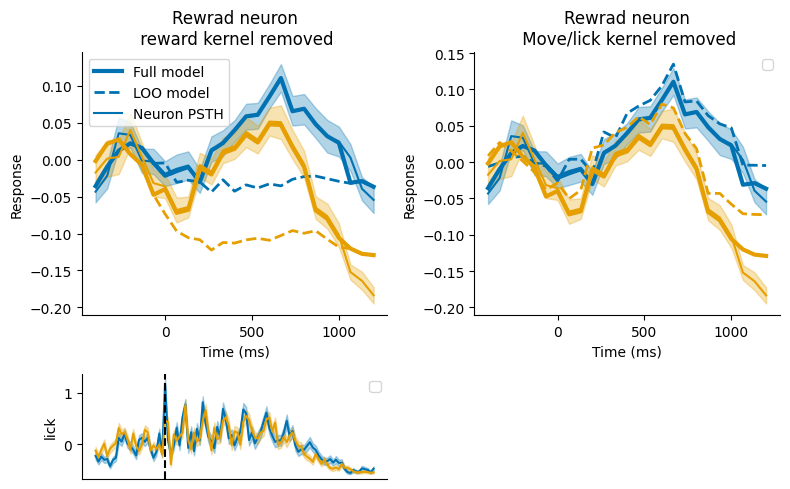

In [82]:
fig, axes = plt.subplots(2, 2, gridspec_kw={'height_ratios': [5, 2]}, figsize=(8,5))
vis_color = '#0072B2'
aud_color = '#E69F00'
pred1 = 'vis_reward_times'
pred2 = 'aud_reward_times'
sorted_indices = np.argsort(vis_reward_r2 - aud_reward_r2)[::-1]
# id = sorted_indices[-4]
id = aud_reward_neuron_idx[2]
print((vis_reward_r2 - aud_reward_r2)[id])
m = beta_info['mouse'][id]
d = beta_info['date'][id]
a = beta_info['arm'][id]
i = beta_info['neuron_idx'][id]
neuron = agg_data[m][d][a]['stat'][i]
dm = agg_data[m][d][a]['design_matrix']
tf = agg_data[m][d][a]['table_for_img']
# psth1 = vis_left_choice_psth_raw[id]
# psth2 = vis_right_choice_psth_raw[id]
plot_loo_reconstruction(neuron, dm, tf, pred=pred1, full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[0,0], color = vis_color)

plot_loo_reconstruction(neuron, dm, tf, pred=pred2, full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[0,0], color = aud_color, label = False)

plot_loo_reconstruction(neuron, dm, tf, pred=pred1, loo_pred=['face', 'body', 'lick'], full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[0,1], color = vis_color, label = False)

plot_loo_reconstruction(neuron, dm, tf, pred=pred2, loo_pred=['face', 'body', 'lick'], full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[0,1], color = aud_color, label = False)

axes[0,0].legend(loc='upper left')
axes[0,0].set_title('Rewrad neuron\n reward kernel removed')
axes[0,1].set_title('Rewrad neuron\n Move/lick kernel removed')
#axes[0,0].title()

lick = agg_data[m][d]
lick = agg_data[m][d]['lick']
tf_v = agg_data[m][d]['table_for_video']
v_vis_reward_frame_idx = find_frame_indices(tf_v[tf_v['modality']==0], 60.4, (psth_time_start, psth_time_end), 'reward_consume_times').astype(int)
v_aud_reward_frame_idx = find_frame_indices(tf_v[tf_v['modality']==1], 60.4, (psth_time_start, psth_time_end), 'reward_consume_times').astype(int)
vis_reward_lick = get_trial_PSTH(np.expand_dims(lick[:,0], axis=0), v_vis_reward_frame_idx, zscore=True).squeeze()
aud_reward_lick = get_trial_PSTH(np.expand_dims(lick[:,0], axis=0), v_aud_reward_frame_idx, zscore=True).squeeze()
lick_timepoint = np.linspace(psth_time_start*1000,psth_time_end*1000,vis_reward_lick.shape[1])
plot_with_error_shading(vis_reward_lick, time_points=lick_timepoint, color=vis_color, ax=axes[1,0])
plot_with_error_shading(aud_reward_lick, time_points=lick_timepoint, color=aud_color, ax=axes[1,0])
axes[1,0].axvline(x=0, color='black', linestyle='--')
axes[1,0].set_xlabel('Time (ms)')
axes[1,0].set_ylabel('lick') 
axes[1,0].xaxis.set_visible(False) 
axes[1,1].axis('off')
plt.tight_layout()
plt.show()

In [120]:
print(m, d, a, i)

AF_L3 20250909_valvesilent_punishsilent arm2 37


In [240]:
def get_day_reward_selectivity_stats(
    mouse_data,
    unique_predictors,
    alpha=0.03,
    arms=('arm1','arm2')
):
    """
    For a single mouse:
    returns per-day dicts:
      dates_used:           list of date strings
      vis_perf_by_day:      np.array, shape (n_days,)
      aud_perf_by_day:      np.array, shape (n_days,)
      frac_vis_only_by_day: np.array, shape (n_days,)
      frac_aud_only_by_day: np.array, shape (n_days,)
    """
    # predictor indices
    try:
        vis_idx = unique_predictors.index('vis_reward_times')
        aud_idx = unique_predictors.index('aud_reward_times')
    except ValueError:
        raise ValueError("Make sure 'vis_reward_times' and 'aud_reward_times' are in unique_predictors")

    training_dates = np.asarray(mouse_data['training']['training_dates'])
    vis_perf_all   = np.asarray(mouse_data['training']['accuracies_vis'])
    aud_perf_all   = np.asarray(mouse_data['training']['accuracies_aud'])

    # imaging dates = keys that look like session days (start with '202')
    img_dates = [d for d in mouse_data.keys() if d.startswith('202') and 'valvesilent' in d]
    # make chronological
    img_dates = sorted(img_dates, key=lambda s: int(s[:8]))

    dates_used = []
    vis_perf_by_day = []
    aud_perf_by_day = []
    frac_vis_only_by_day = []
    frac_aud_only_by_day = []

    for date in img_dates:
        td_idx = np.where(training_dates == date[:8])[0]
        if td_idx.size == 0:
            continue  # skip if we don't have behavior for that imaging day

        # collect neurons from both arms
        vis_only_flags = []
        aud_only_flags = []
        total_neurons  = 0

        day_dict = mouse_data[date]
        for arm in arms:
            if arm not in day_dict:
                continue
            stats = day_dict[arm].get('stat', [])
            for nrn in stats:
                pvals = nrn['bootstrap_p_value']
                if vis_idx >= len(pvals) or aud_idx >= len(pvals):
                    continue

                p_vis = pvals[vis_idx]
                p_aud = pvals[aud_idx]

                # only count this neuron if it has valid p-values
                if not np.isfinite(p_vis) or not np.isfinite(p_aud):
                    continue

                total_neurons += 1
                vis_only_flags.append( (p_vis < alpha) and (p_aud >= alpha) )
                aud_only_flags.append( (p_aud < alpha) and (p_vis >= alpha) )

        if total_neurons == 0:
            continue

        vis_only_flags = np.asarray(vis_only_flags, dtype=bool)
        aud_only_flags = np.asarray(aud_only_flags, dtype=bool)

        frac_vis_only = np.sum(vis_only_flags) / total_neurons
        frac_aud_only = np.sum(aud_only_flags) / total_neurons

        dates_used.append(date)
        vis_perf_by_day.append(vis_perf_all[td_idx][0])
        aud_perf_by_day.append(aud_perf_all[td_idx][0])
        frac_vis_only_by_day.append(frac_vis_only)
        frac_aud_only_by_day.append(frac_aud_only)

    return {
        'dates_used': np.array(dates_used),
        'vis_perf_by_day': np.array(vis_perf_by_day, dtype=float),
        'aud_perf_by_day': np.array(aud_perf_by_day, dtype=float),
        'frac_vis_only_by_day': np.array(frac_vis_only_by_day, dtype=float),
        'frac_aud_only_by_day': np.array(frac_aud_only_by_day, dtype=float),
    }


def plot_modality_specific_reward_fraction_vs_performance(
    agg_data,
    mouse_ids,
    unique_predictors,
    alpha=0.03,
    perf_modality='vis',      # 'vis' or 'aud' → which behavior to bin on
    perf_min=0.35,
    perf_max=1.0,
    bin_width=0.10,
    color_vis_only='#0072B2', # for "vis-only reward neurons"
    color_aud_only='#E69F00', # for "aud-only reward neurons"
    show_individual=True,
    figsize=(4,3),
):
    """
    For each mouse we get per-day:
      perf (visual or auditory),
      frac_vis_only,
      frac_aud_only.

    Then we:
      - bin by performance
      - compute mean (per mouse) within-bin
      - then across-mouse mean ± SEM
    and plot both vis-only and aud-only curves on same axes.
    """

    use_vis_perf = (perf_modality.lower() == 'vis')

    # set up bins
    edges = np.arange(perf_min, perf_max + 1e-12, bin_width)
    centers = 0.5 * (edges[:-1] + edges[1:])
    n_bins = len(centers)

    # we'll build these per bin, per mouse
    per_mouse_binned_visonly = []
    per_mouse_binned_audonly = []

    for mouse in mouse_ids:
        if mouse not in agg_data:
            continue

        stats = get_day_reward_selectivity_stats(
            agg_data[mouse],
            unique_predictors=unique_predictors,
            alpha=alpha
        )

        perf_day = stats['vis_perf_by_day'] if use_vis_perf else stats['aud_perf_by_day']
        frac_vis_only_day = stats['frac_vis_only_by_day']
        frac_aud_only_day = stats['frac_aud_only_by_day']

        if perf_day.size == 0:
            continue

        # average this mouse's days within each performance bin
        binned_visonly = np.full(n_bins, np.nan)
        binned_audonly = np.full(n_bins, np.nan)
        for bi in range(n_bins):
            in_bin = (perf_day >= edges[bi]) & (perf_day < edges[bi+1])
            if np.any(in_bin):
                binned_visonly[bi] = np.nanmean(frac_vis_only_day[in_bin])
                binned_audonly[bi] = np.nanmean(frac_aud_only_day[in_bin])

        per_mouse_binned_visonly.append(binned_visonly)
        per_mouse_binned_audonly.append(binned_audonly)

    if len(per_mouse_binned_visonly) == 0:
        raise RuntimeError("No valid mice / data for this analysis.")

    per_mouse_binned_visonly = np.vstack(per_mouse_binned_visonly)  # (n_mice, n_bins)
    per_mouse_binned_audonly = np.vstack(per_mouse_binned_audonly)

    mean_visonly = np.nanmean(per_mouse_binned_visonly, axis=0)
    sem_visonly  = sem(per_mouse_binned_visonly, axis=0)

    mean_audonly = np.nanmean(per_mouse_binned_audonly, axis=0)
    sem_audonly  = sem(per_mouse_binned_audonly, axis=0)

    # --- Plot
    fig, ax = plt.subplots(figsize=figsize)

    if show_individual:
        # faint lines per mouse, for vis-only neurons
        for row in per_mouse_binned_visonly:
            ax.plot(centers, row,
                    color=color_vis_only, alpha=0.2, lw=1)
        # faint lines per mouse, for aud-only neurons
        for row in per_mouse_binned_audonly:
            ax.plot(centers, row,
                    color=color_aud_only, alpha=0.2, lw=1)

    # group mean ± SEM (vis-only)
    ax.errorbar(
        centers, mean_visonly, yerr=sem_visonly,
        fmt='o-', color=color_vis_only, lw=2, capsize=3,
        label='Vis-only reward cells'
    )
    # group mean ± SEM (aud-only)
    ax.errorbar(
        centers, mean_audonly, yerr=sem_audonly,
        fmt='s-', color=color_aud_only, lw=2, capsize=3,
        label='Aud-only reward cells'
    )

    ax.set_xlabel(f"{perf_modality.upper()} performance (accuracy)")
    ax.set_ylabel("Fraction of modality-specific reward neurons")
    ax.set_xlim(perf_min, perf_max)
    ax.set_ylim(0, 0.3)  # adjust if needed
    ax.grid(True, alpha=0.3)
    ax.set_title("Reward selectivity becomes modality tagged?")

    ax.legend(frameon=False, loc='upper left')
    plt.tight_layout()
    plt.show()

    return {
        'bin_centers': centers,
        'mean_visonly': mean_visonly,
        'sem_visonly': sem_visonly,
        'mean_audonly': mean_audonly,
        'sem_audonly': sem_audonly,
        'per_mouse_binned_visonly': per_mouse_binned_visonly,
        'per_mouse_binned_audonly': per_mouse_binned_audonly,
    }

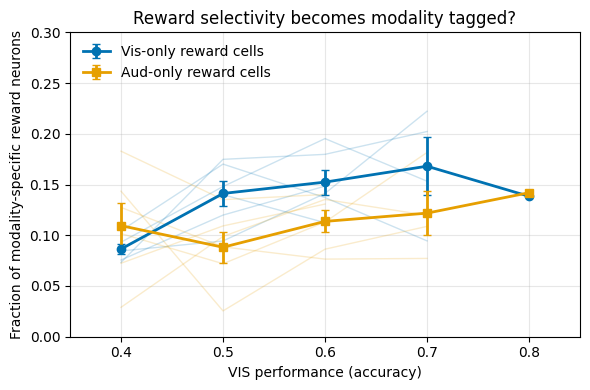

In [244]:
res = plot_modality_specific_reward_fraction_vs_performance(
    agg_data=agg_data,
    mouse_ids=mouse_ids,
    unique_predictors=unique_predictors,
    alpha=0.05,
    perf_modality='vis',      # bin by visual performance
    perf_min=0.35,
    perf_max=0.85,
    bin_width=0.1,
    color_vis_only='#0072B2',  # visual-style blue
    color_aud_only='#E69F00',  # auditory-style orange
    show_individual=True,
    figsize=(6,4)
)

Decoding stuff

In [33]:


# ---- assumes your loo_reconstruct_activity(), find_frame_indices(), etc. are already defined ----

def build_residual_tensor(
    neurons,                 # list[dict], each has neuron['beta'], neuron['intercept'],
    dff,                     # (n_neurons, n_time), need to have same length as neurons
    design_matrix,           # (T_model, P)
    predictors,              # list[str] length P (column names for design_matrix)
    table_for_img,           # dict-like with trial info; needs ['ruleCue_times'] and label cols
    preds_to_exclude,        # list[str]; predictors to leave out (e.g., ['choice']), should be same as align_pred?
    psth_time_start,         # e.g., -1.0  (seconds; whatever your find_frame_indices expects)
    psth_time_end,           # e.g., 1.0
    align_pred,              # str passed to find_frame_indices, e.g., 'ruleCue' or your event name. the activity around which the prediction is made
    frames_per_s=15,         # your frame rate if find_frame_indices needs it
):
    """
    Returns:
      residual_tensor: (n_neurons, n_trials, n_time) ndarray
      psth_frame_idx:  (n_trials, n_time) ndarray of absolute frame indices used
      
    """
    assert(len(neurons) == dff.shape[0])
    # get the per-trial absolute frame indices covering the time window
    table_for_img['all_choice_times'] = (
        table_for_img['lastMovement_times'] - 3
    ).astype(float)
    # print(table_for_img['choice_times'].to_numpy())
    # print(np.sum(~np.isnan(table_for_img['choice_times'].to_numpy())))
    psth_frame_idx = find_frame_indices(
        table_for_img,
        frames_per_s,
        (psth_time_start, psth_time_end),
        align_pred
    ).astype(int)  # shape: (n_trials, n_time)
    print(psth_frame_idx.shape)
    n_trials, n_time = psth_frame_idx.shape
    trial_mask = ~np.isnan(table_for_img[align_pred])
    # build residuals for each neuron
    pad_len = int(table_for_img['ruleCue_times'][0])  # how many zeros to pre-pad (your convention)
    residual_blocks = []

    for i, nrn in enumerate(neurons):
        # print('building residual tensor for neuron: ', i)
        # predict with LOO (exclude chosen predictors, no refit)
        _, y_loo = loo_reconstruct_activity(
            nrn, design_matrix, preds_to_exclude, full_predictors=predictors, exact_match=False
        )
        # align y_loo to F with the same pre-padding convention
        y_loo_aligned = np.concatenate([np.zeros(pad_len, dtype=float), y_loo])
        assert(len(y_loo_aligned) == table_for_img['intervals_1'].iloc[-1])
        # residual = raw - y_loo
        F = np.asarray(dff[i]).ravel()
        y_loo_aligned = np.concatenate([y_loo_aligned, np.zeros(len(F)-len(y_loo_aligned), dtype=float)])
        if F.shape[0] != y_loo_aligned.shape[0]:
            raise ValueError(f"Length mismatch: F={F.shape[0]} vs y_loo_aligned={y_loo_aligned.shape[0]}")
        resid = F - y_loo_aligned
        # slice residuals into (n_trials, n_time) via advanced indexing
        # (broadcasting: for each trial row, grab those absolute frames)
        resid_trials_time = resid[psth_frame_idx]  # shape (n_trials, n_time)
        residual_blocks.append(resid_trials_time)

    residual_tensor = np.stack(residual_blocks, axis=0)  # (n_neurons, n_trials, n_time)
    return residual_tensor, psth_frame_idx, trial_mask



def population_decode_timecourse_session(
    data,
    mouse,
    date,
    predictors,
    preds_to_exclude,        # e.g., ['choice'] or ['choice_left','choice_right']
    psth_time_start,         # e.g., -0.5
    psth_time_end,           # e.g.,  1.0
    align_pred,              # e.g., 'ruleCue'
    label_key='choice',      # 'choice' (−1/1) or 'modality' (0/1)
    custom_labels=None,      # override labels if provided
    trial_mask=None,         # optional external trial mask
    frames_per_s=15,
    C=1.0,
    l1_ratio=1.0,
    n_splits=5,
    random_state=0,
    max_iter=5000,
    return_tensor=False,
    do_shuffle=True,
):
    """
    Build residual tensor for a session, decode over time (real + shuffled),
    and return summary dict.
    """

    # ---------- build residual tensors for arm1 / arm2 ----------
    if 'arm1' in data[mouse][date].keys():
        arm1_dff = np.load(os.path.join(
            r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m', mouse, date,
            'arm1', 'dff_moving_percentile_pc_lowpass_0p5hz.npy'
        ))
        arm1_neurons = data[mouse][date]['arm1']['stat']
        arm1_design_matrix = data[mouse][date]['arm1']['design_matrix']
        arm1_table_for_img = data[mouse][date]['arm1']['table_for_img']

        arm1_residual_tensor, arm1_psth_frame_idx, arm1_trial_mask = build_residual_tensor(
            arm1_neurons, arm1_dff, arm1_design_matrix, predictors, arm1_table_for_img,
            preds_to_exclude, psth_time_start, psth_time_end, align_pred, frames_per_s
        )

    if 'arm2' in data[mouse][date].keys():
        arm2_dff = np.load(os.path.join(
            r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m', mouse, date,
            'arm2', 'dff_moving_percentile_pc_lowpass_0p5hz.npy'
        ))
        arm2_neurons = data[mouse][date]['arm2']['stat']
        arm2_design_matrix = data[mouse][date]['arm2']['design_matrix']
        arm2_table_for_img = data[mouse][date]['arm2']['table_for_img']

        arm2_residual_tensor, arm2_psth_frame_idx, arm2_trial_mask = build_residual_tensor(
            arm2_neurons, arm2_dff, arm2_design_matrix, predictors, arm2_table_for_img,
            preds_to_exclude, psth_time_start, psth_time_end, align_pred, frames_per_s
        )

    # merge arms if available
    if 'arm1_residual_tensor' in locals() and arm1_residual_tensor is not None \
    and 'arm2_residual_tensor' in locals() and arm2_residual_tensor is not None:
        assert arm1_residual_tensor.shape[1] == arm2_residual_tensor.shape[1], \
            "arm1 and arm2 must have same number of trials"
        residual_tensor = np.concatenate([arm1_residual_tensor, arm2_residual_tensor], axis=0)
        psth_frame_idx = arm1_psth_frame_idx  # trial x time, same trials assumed
        arm_trial_mask = arm1_trial_mask      # boolean for valid trials
        table_ref = arm1_table_for_img        # use arm1 table for labels
    elif 'arm1_residual_tensor' in locals() and arm1_residual_tensor is not None:
        residual_tensor = arm1_residual_tensor
        psth_frame_idx = arm1_psth_frame_idx
        arm_trial_mask = arm1_trial_mask
        table_ref = arm1_table_for_img
    elif 'arm2_residual_tensor' in locals() and arm2_residual_tensor is not None:
        residual_tensor = arm2_residual_tensor
        psth_frame_idx = arm2_psth_frame_idx
        arm_trial_mask = arm2_trial_mask
        table_ref = arm2_table_for_img
    else:
        raise ValueError("No residual tensor found.")

    # ---------- build labels ----------
    if custom_labels is not None:
        labels = np.asarray(custom_labels).ravel()
    else:
        labels = np.asarray(table_ref[label_key]).ravel()

    # Keep only trials that were actually included in residual_tensor
    labels = labels[arm_trial_mask]

    # this "new_trial_mask" matches what decode_timecourse_L1_fast expects:
    # starts from the ALREADY filtered trial set, and can further drop trials.
    final_trial_mask = np.ones_like(labels, dtype=bool)

    # optional: externally provided trial_mask (e.g. correct-only)
    if trial_mask is not None:
        # trial_mask should be full-length (all trials), so first align:
        trial_mask = np.asarray(trial_mask).ravel()
        trial_mask = trial_mask[arm_trial_mask]
        final_trial_mask &= trial_mask

    # automatically drop choice==0
    if label_key == 'choice':
        final_trial_mask &= (labels != 0)

    # ---------- decode ----------
    decode_out = decode_timecourse_L1_fast(
        residual_tensor,
        labels,
        trial_mask=final_trial_mask,
        n_splits=n_splits,
        C=C,
        l1_ratio=l1_ratio,
        random_state=random_state,
        max_iter=max_iter,
        do_shuffle=True  # important
    )

    # time axis for plotting (same length as psth_frame_idx.shape[1])
    n_time = psth_frame_idx.shape[1]
    timepoints = np.linspace(psth_time_start, psth_time_end, n_time)

    # assemble session output dict
    out = dict(
        date=date,
        timepoints=timepoints,
        acc=decode_out['acc_time_raw'],
        acc_std=decode_out['acc_std_time_raw'],
        acc_bal=decode_out['acc_time_bal'],
        acc_bal_std=decode_out['acc_std_time_bal'],

        shuf_acc=decode_out.get('shuf_acc_time_raw', None),
        shuf_acc_std=decode_out.get('shuf_acc_std_time_raw', None),
        shuf_acc_bal=decode_out.get('shuf_acc_time_bal', None),
        shuf_acc_bal_std=decode_out.get('shuf_acc_std_time_bal', None),

        baseline=decode_out['majority_baseline'],
        psth_frame_idx=psth_frame_idx,
    )

    if return_tensor:
        out['residual_tensor'] = residual_tensor

    return out

In [32]:
def _fold_acc_for_time(
    X_t, y_t, splits, C, l1_ratio, max_iter, tol, random_state
):
    """
    Train/test on each CV split for a single timepoint using labels y_t.
    Returns:
      raw_mean, raw_std, bal_mean, bal_std
    """
    raw_accs = []
    bal_accs = []

    for train_idx, test_idx in splits:
        Xtr = X_t[train_idx]
        Xte = X_t[test_idx]
        ytr = y_t[train_idx]
        yte = y_t[test_idx]

        # standardize using train stats
        mu = Xtr.mean(axis=0, dtype=np.float64)
        sd = Xtr.std(axis=0, ddof=1, dtype=np.float64)
        sd[sd == 0] = 1.0

        Xtr = (Xtr - mu) / sd
        Xte = (Xte - mu) / sd

        clf = LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            l1_ratio=l1_ratio,
            C=C,
            max_iter=max_iter,
            tol=tol,
            n_jobs=1,          # parallelization handled outside
            warm_start=True,
            random_state=random_state,
        )
        clf.fit(Xtr, ytr)

        y_pred = clf.predict(Xte)

        raw_acc = np.mean(y_pred == yte)
        bal_acc = balanced_accuracy_score(yte, y_pred)

        raw_accs.append(raw_acc)
        bal_accs.append(bal_acc)

    raw_accs = np.asarray(raw_accs, dtype=np.float64)
    bal_accs = np.asarray(bal_accs, dtype=np.float64)

    raw_mean = raw_accs.mean()
    raw_std  = raw_accs.std(ddof=1) if raw_accs.size > 1 else 0.0

    bal_mean = bal_accs.mean()
    bal_std  = bal_accs.std(ddof=1) if bal_accs.size > 1 else 0.0

    return raw_mean, raw_std, bal_mean, bal_std


def decode_timecourse_L1_fast(
    residual_tensor,     # (n_neurons, n_trials, n_time)
    labels,              # (n_trials,)
    trial_mask=None,
    n_splits=5,
    C=1.0,
    l1_ratio=1.0,
    random_state=0,
    max_iter=2000,
    tol=1e-3,
    n_jobs_time=-1,
    dtype=np.float32,
    do_shuffle=True,
):
    """
    Faster variant with bias correction AND shuffle control.

    Returns a dict with:
      acc_time_raw        : (n_time,) mean CV raw accuracy per timepoint
      acc_std_time_raw    : (n_time,) std across folds (raw)
      acc_time_bal        : (n_time,) mean CV balanced accuracy per timepoint
      acc_std_time_bal    : (n_time,) std across folds (balanced)
      majority_baseline   : float, majority-class baseline accuracy

      If do_shuffle:
      shuf_acc_time_raw
      shuf_acc_std_time_raw
      shuf_acc_time_bal
      shuf_acc_std_time_bal
      (same shapes, using label-shuffled decoding)
    """
    n_neurons, n_trials, n_time = residual_tensor.shape
    labels = np.asarray(labels).ravel()
    if labels.shape[0] != n_trials:
        raise ValueError("labels length must match number of trials in residual_tensor")

    # mask trials if provided
    if trial_mask is None:
        trial_mask = np.ones(n_trials, dtype=bool)
    else:
        trial_mask = np.asarray(trial_mask, dtype=bool)
        if trial_mask.shape[0] != n_trials:
            raise ValueError("trial_mask length must match number of trials")

    # masked labels
    y_all = labels[trial_mask]
    if len(np.unique(y_all)) != 2:
        raise ValueError("labels must contain exactly two classes after masking")

    # majority baseline (raw acc you'd get always guessing the majority class)
    _, counts = np.unique(y_all, return_counts=True)
    majority_baseline = counts.max() / counts.sum()

    # prep data once: (T, trials_masked, neurons)
    X_all = residual_tensor[:, trial_mask, :].transpose(2, 1, 0)
    X_all = X_all.astype(dtype, copy=False)
    X_all = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0)

    # CV splits (reused for all timepoints and for shuffled control)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    splits = list(skf.split(np.zeros_like(y_all), y_all))

    # ---- REAL LABELS ----
    outs_real = Parallel(n_jobs=n_jobs_time, prefer="processes")(
        delayed(_fold_acc_for_time)(
            X_all[t], y_all, splits, C, l1_ratio, max_iter, tol, random_state
        )
        for t in range(n_time)
    )

    outs_real = np.asarray(outs_real, dtype=object)
    acc_time_raw     = np.array([o[0] for o in outs_real], dtype=np.float64)
    acc_std_time_raw = np.array([o[1] for o in outs_real], dtype=np.float64)
    acc_time_bal     = np.array([o[2] for o in outs_real], dtype=np.float64)
    acc_std_time_bal = np.array([o[3] for o in outs_real], dtype=np.float64)

    result = {
        'acc_time_raw': acc_time_raw,
        'acc_std_time_raw': acc_std_time_raw,
        'acc_time_bal': acc_time_bal,
        'acc_std_time_bal': acc_std_time_bal,
        'majority_baseline': majority_baseline,
    }

    # ---- SHUFFLED LABELS ----
    if do_shuffle:
        rng = np.random.default_rng(random_state)
        y_shuf = rng.permutation(y_all)

        # We maintain class counts with permutation, so StratifiedKFold still valid.
        # IMPORTANT: we keep the same splits so chance curve is directly comparable.
        outs_shuf = Parallel(n_jobs=n_jobs_time, prefer="processes")(
            delayed(_fold_acc_for_time)(
                X_all[t], y_shuf, splits, C, l1_ratio, max_iter, tol, random_state
            )
            for t in range(n_time)
        )

        outs_shuf = np.asarray(outs_shuf, dtype=object)
        shuf_acc_time_raw     = np.array([o[0] for o in outs_shuf], dtype=np.float64)
        shuf_acc_std_time_raw = np.array([o[1] for o in outs_shuf], dtype=np.float64)
        shuf_acc_time_bal     = np.array([o[2] for o in outs_shuf], dtype=np.float64)
        shuf_acc_std_time_bal = np.array([o[3] for o in outs_shuf], dtype=np.float64)

        result.update({
            'shuf_acc_time_raw': shuf_acc_time_raw,
            'shuf_acc_std_time_raw': shuf_acc_std_time_raw,
            'shuf_acc_time_bal': shuf_acc_time_bal,
            'shuf_acc_std_time_bal': shuf_acc_std_time_bal,
        })

    return result

In [8]:
def plot_decoding_accuracy(
    results,
    ax=None,
    title=None,
    time_range_ms=None,    # e.g. (-500, 1000)
    show_zero_line=True,
    color='C0',
    metric='raw',          # 'raw' or 'balanced'
    show_shuffled=True,
    shuffled_color='gray',
):
    """
    Plot decoding accuracy over time with ±1 SD and baseline,
    showing both real and shuffled-label decoding if available.

    Parameters
    ----------
    results : dict
        Must include:
          - 'timepoints' (s)
          - 'acc', 'acc_std'                (raw accuracy)
          - 'acc_bal', 'acc_bal_std'        (balanced accuracy)
          - 'baseline'                      (majority baseline for raw)
          - Optionally: 'shuf_acc', 'shuf_acc_std', etc.
    metric : {'raw','balanced'}
        'raw'      -> plots acc vs baseline
        'balanced' -> plots acc_bal vs 0.5
    show_shuffled : bool
        Whether to plot shuffled-label decoding curve if available.
    shuffled_color : str
        Color for shuffled curve (default gray).
    """
    tp_s = np.asarray(results['timepoints'])

    # --- choose metric ---
    if metric == 'raw':
        acc = np.asarray(results['acc'])
        sd  = np.asarray(results['acc_std'])
        baseline = results.get('baseline', 0.5)
        baseline_label = f'Baseline = {baseline:.2f}'
        baseline_y = baseline
        ylabel = 'Accuracy'

        # shuffled (if exists)
        acc_shuf = results.get('shuf_acc', None)
        sd_shuf  = results.get('shuf_acc_std', None)

    elif metric == 'balanced':
        acc = np.asarray(results['acc_bal'])
        sd  = np.asarray(results['acc_bal_std'])
        baseline_y = 0.5
        baseline_label = 'Chance = 0.5 (balanced)'
        ylabel = 'Balanced accuracy'

        # shuffled (if exists)
        acc_shuf = results.get('shuf_acc_bal', None)
        sd_shuf  = results.get('shuf_acc_bal_std', None)

    else:
        raise ValueError("metric must be 'raw' or 'balanced'")

    # --- convert timepoints (s → ms) ---
    tp_ms = tp_s * 1000

    # --- create axis ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 2.2))

    # --- plot shuffled curve first (if available) ---
    if show_shuffled and acc_shuf is not None:
        ax.plot(tp_ms, acc_shuf, color=shuffled_color, lw=1.5, ls='--', label='Shuffled')
        if sd_shuf is not None:
            ax.fill_between(tp_ms, acc_shuf - sd_shuf, acc_shuf + sd_shuf,
                            color=shuffled_color, alpha=0.2)

    # --- plot real decoding curve ---
    ax.plot(tp_ms, acc, color=color, lw=2.5, label='Real decoding')
    ax.fill_between(tp_ms, acc - sd, acc + sd, color=color, alpha=0.25)

    # --- baseline ---
    ax.axhline(baseline_y, ls=':', lw=1.3, color='gray', label=baseline_label)

    # --- zero ms vertical line ---
    if show_zero_line:
        ax.axvline(0, color='k', ls='--', lw=1)

    # --- aesthetics ---
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel(ylabel)
    if time_range_ms is not None:
        ax.set_xlim(*time_range_ms)
    if title:
        ax.set_title(title)

    ax.set_ylim(0.4, 1.0)
    ax.legend(loc='best', frameon=False)
    ax.grid(alpha=0.3)

    return ax

In [26]:
table_for_img = agg_data['AE_L2']['20250715_valvesilent']['arm1']['table_for_img']

In [308]:
date = '20250618_valvesilent'
mouse = 'AF_R3'
arm = 'arm2'
neurons = agg_data[mouse][date][arm]['stat']
arm1_dff = np.load(os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m',mouse,date,arm,'dff_moving_percentile_pc_lowpass_0p5hz.npy'))
dm = agg_data[mouse][date][arm]['design_matrix']
table_for_img = agg_data[mouse][date][arm]['table_for_img']

#psth_time_start = -1.0
#psth_time_end = 1.0

frames_per_s = 15
#residual_tensor, psth_frame_idx = build_residual_tensor(neurons, arm1_dff, dm, predictors, table_for_img, preds_to_exclude, psth_time_start, psth_time_end, align_pred, frames_per_s)

In [309]:
align_pred = 'all_choice_times'
preds_to_exclude = ['vis_left_choice_times', 'aud_left_choice_times', 'vis_right_choice_times', 'aud_right_choice_times']

results = population_decode_timecourse_session(
    agg_data,
    mouse,
    date,
    predictors,
    preds_to_exclude,        # e.g., ['choice'] or ['choice_left','choice_right'] depending on your naming
    psth_time_start,         # e.g., -0.5
    psth_time_end,           # e.g.,  1.0
    align_pred,              # e.g., 'ruleCue'
    label_key='choice',      # 'choice' (−1/1) or 'modality' (0/1), or pass your own vector below
    custom_labels=None,      # optional override for labels (length = n_trials)
    trial_mask=None,         # optional bool mask to subset trials
    frames_per_s=15,
    C=0.5,
    l1_ratio=1.0,
    n_splits=3,
    random_state=0,
    max_iter=2000,
    return_tensor=False,
)

(284, 25)
(284, 25)


<Axes: title={'center': 'choice decoding from choice'}, xlabel='Time (ms)', ylabel='Balanced accuracy'>

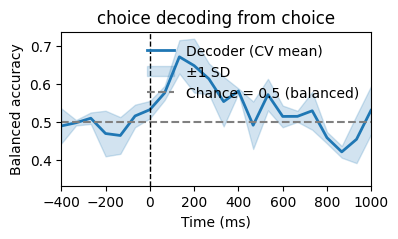

In [104]:
plot_decoding_accuracy(results, title='choice decoding from choice', time_range_ms=(-400, 1000), metric='balanced')

<Axes: title={'center': 'choice decoding from choice'}, xlabel='Time (ms)', ylabel='Balanced accuracy'>

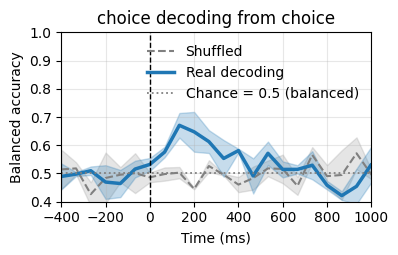

In [310]:
plot_decoding_accuracy(results, title='choice decoding from choice', time_range_ms=(-400, 1000), metric='balanced', show_shuffled=True)

In [30]:
with open(os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m','AE_L2', 'context_decoding_ruleCue_results.pkl'), 'rb') as f:
    results_all = pickle.load(f)

<Axes: title={'center': 'context decoding from ruleCue'}, xlabel='Time (ms)', ylabel='Accuracy'>

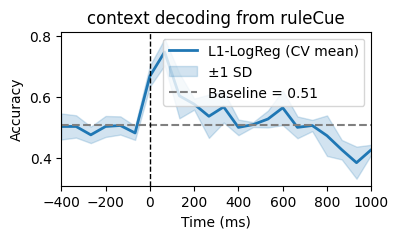

In [62]:
plot_decoding_accuracy(results_all[5], title='context decoding from ruleCue', time_range_ms=(-400, 1000))

In [35]:
temp_mouse_ids = [
 'AF_L3',
 'AB_R2',
 'J_L2',
 'A_R2',
 'A_R3',
 'O_R2',
 'R_L2'
 ]

In [ ]:
agg_data['AE_L2']['20250624_valvesilent']['arm1']['table_for_img']['lastMovement_times']

,intervals_0,intervals_1,ruleCue_times,ruleCueTrigger_times,response_times,choice,stimOnTrigger_times,stimOn_times,contrastLeft,contrastRight,...,left_vis_stimOn_times,right_vis_stimOn_times,left_aud_stimOn_times,right_aud_stimOn_times,vis_left_choice_times,vis_right_choice_times,aud_left_choice_times,aud_right_choice_times,previous_feedbackType,reward_history
0,531,917,654,654,863,-1,666,669,1.0,NaN,...,669.0,NaN,NaN,NaN,858.0,NaN,NaN,NaN,0,0.60
1,939,1253,949,948,1199,1,960,961,NaN,1.0,...,NaN,961.0,NaN,NaN,NaN,1195.0,NaN,NaN,-1,0.60
2,1275,1521,1308,1308,1498,1,1320,1321,1.0,NaN,...,1321.0,NaN,NaN,NaN,NaN,1492.0,NaN,NaN,-1,0.60
3,1541,1649,1554,1554,1595,-1,1566,1567,0.5,NaN,...,1567.0,NaN,NaN,NaN,1590.0,NaN,NaN,NaN,1,0.60
4,1671,1825,1750,1749,1801,-1,1762,1762,NaN,0.5,...,NaN,1762.0,NaN,NaN,1796.0,NaN,NaN,NaN,-1,0.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,44538,44941,44545,44545,44887,1,44557,44558,NaN,0.0,...,NaN,NaN,NaN,44557.0,NaN,NaN,NaN,44878.0,-1,0.35
258,44962,45177,44970,44969,45153,1,44982,44982,0.0,NaN,...,NaN,NaN,44982.0,NaN,NaN,NaN,NaN,45147.0,-1,0.40
259,45197,45302,45229,45229,45248,-1,45241,45242,0.0,NaN,...,NaN,NaN,45241.0,NaN,NaN,NaN,45239.0,NaN,1,0.40
260,45321,45801,45364,45363,45777,1,45375,45376,1.0,NaN,...,45376.0,NaN,NaN,NaN,NaN,45771.0,NaN,NaN,-1,0.40


20250604
(117, 25)
(117, 25)
20250618_valvesilent
(201, 25)
(201, 25)
20250625_valvesilent
(262, 25)
(262, 25)
20250702_valvesilent
(221, 25)
(221, 25)
20250710_valvesilent
(277, 25)
(277, 25)
20250716_valvesilent
(330, 25)
(330, 25)
20250723_valvesilent
(329, 25)
(329, 25)
20250730_valvesilent
(279, 25)
(279, 25)
20250814_valvesilent
(184, 25)
(184, 25)
20250821_valvesilent
(170, 25)
(170, 25)
20250828_valvesilent
(210, 25)
(210, 25)
20250904_valvesilent_punishsilent
(211, 25)
(211, 25)
20250909_valvesilent_punishsilent
(222, 25)
(222, 25)
training
20250527
(228, 25)
(228, 25)
20250612_valvesilent
(282, 25)
(282, 25)
20250617_valvesilent
(176, 25)
(176, 25)
20250625_valvesilent
(277, 25)
(277, 25)
20250701_valvesilent
(256, 25)
(256, 25)
20250708_valvesilent
(285, 25)
(285, 25)
20250715_valvesilent
(242, 25)
(242, 25)
20250722_valvesilent
(166, 25)
(166, 25)
20250730_valvesilent
(171, 25)
(171, 25)
20250731_valvesilent
(198, 25)
(198, 25)
20250814_valvesilent_punishsilent
(183, 25)
(1

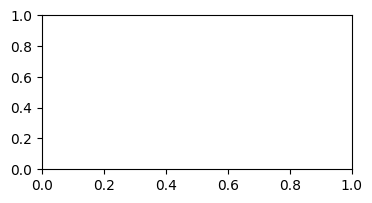

In [37]:
align_pred = 'all_choice_times' # need to be column name in table_for_img
preds_to_exclude = ['vis_left_choice_times', 'aud_left_choice_times', 'vis_right_choice_times', 'aud_right_choice_times'] # need to be unique predictor
fig, ax = plt.subplots(figsize=(4, 2))

for mouse in temp_mouse_ids:
    dates = list(agg_data[mouse].keys())
    results_all = []
    for date in dates:
        print(date)
        if date[:3] != '202':
            continue
        results = population_decode_timecourse_session(
            data=agg_data,
            mouse=mouse,
            date=date,
            predictors=predictors,                 # column names for design_matrix 
            preds_to_exclude=preds_to_exclude,           # or ['choice_left','choice_right'] if split cols
            psth_time_start=psth_time_start,
            psth_time_end=psth_time_end,
            align_pred=align_pred,
            label_key='choice',                    # uses table_for_img['choice'] (−1 left, +1 right)
            frames_per_s=15,
            C=0.5, l1_ratio=1.0, n_splits=3,
            random_state=42
        )
        results_all.append(results)
    if len(results_all) > 0:
        with open(os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m',mouse, 'choice_decoding_choice_shuffled_results.pkl'), 'wb') as f:
            pickle.dump(results_all, f)

In [84]:
def build_motion_tensor(
    motion,               # np.ndarray, shape (T_video, n_features) or (T_video,)
    table_for_video,      # DataFrame with trial rows, same order as motion-aligned trials
    psth_time_start,      # e.g. -0.5 (s)
    psth_time_end,        # e.g.  1.0 (s)
    align_pred,           # e.g. 'reward_consume_times'
    frames_per_s=60,      # video frame rate
):
    """
    Build a tensor of motion features aligned to an event, similar to residual_tensor.

    Returns:
      motion_tensor  : (n_features, n_trials_kept, n_time)
      psth_frame_idx : (n_trials_kept, n_time) absolute video-frame indices
      trial_mask     : (n_trials_full,) bool; which trials from table_for_video were kept
    """
    motion = np.asarray(motion)

    # Ensure 2D: (T_video, n_features)
    if motion.ndim == 1:
        motion = motion[:, None]

    T_video = motion.shape[0]

    # Per-trial frame indices around align_pred, like for imaging but with 60 Hz
    psth_frame_idx = find_frame_indices(
        table_for_video,
        frames_per_s,
        (psth_time_start, psth_time_end),
        align_pred
    ).astype(int)  # (n_trials_kept, n_time)

    # Optionally sanity-check index range
    if psth_frame_idx.max() >= T_video:
        raise ValueError(
            f"Video frame indices exceed motion length: max={psth_frame_idx.max()}, "
            f"T_video={T_video}"
        )

    n_trials_kept, n_time = psth_frame_idx.shape
    # trial_mask in *full* table space: kept trials are True
    trial_mask = ~np.isnan(table_for_video[align_pred].to_numpy())
    # (assuming find_frame_indices drops exactly those with NaN in align_pred)

    # Gather motion: (n_trials_kept, n_time, n_features)
    motion_trials_time_feat = motion[psth_frame_idx]          # index frames
    # Reorder axes: (n_features, n_trials_kept, n_time)
    motion_tensor = np.moveaxis(motion_trials_time_feat, 2, 0)

    return motion_tensor, psth_frame_idx, trial_mask
def motion_decode_timecourse_session(
    data,
    mouse,
    date,
    motion_key,           # 'body_motion', 'face_motion', 'lick', etc.
    psth_time_start,      # e.g. -0.5
    psth_time_end,        # e.g.  1.0
    align_pred,           # e.g. 'reward_consume_times'
    label_key='modality', # e.g. 'modality' or 'choice'
    custom_labels=None,
    trial_mask=None,      # external mask over trials (correct-only, etc.)
    frames_per_s=60,
    C=1.0,
    l1_ratio=1.0,
    n_splits=5,
    random_state=0,
    max_iter=2000,
    do_shuffle=True,
    return_tensor=False,
):
    """
    Decode labels from motion-only features around an event for one session.
    Uses the same decode_timecourse_L1_fast as your neural decoder.
    """
    session_data = data[mouse][date]
    table_for_video = session_data['table_for_video']
    motion = session_data[motion_key]   # e.g. body_motion_svd

    # 1) Build motion tensor (features x trials x time)
    motion_tensor, psth_frame_idx, base_trial_mask = build_motion_tensor(
        motion,
        table_for_video,
        psth_time_start,
        psth_time_end,
        align_pred,
        frames_per_s=frames_per_s,
    )

    # 2) Labels (full trial length, then restrict to kept trials)
    if custom_labels is not None:
        labels_full = np.asarray(custom_labels).ravel()
    else:
        labels_full = np.asarray(table_for_video[label_key]).ravel()

    # sanity
    if labels_full.shape[0] != base_trial_mask.shape[0]:
        raise ValueError("labels_full and table_for_video length mismatch")

    labels = labels_full[base_trial_mask]  # now length == motion_tensor.shape[1]

    # 3) Final trial mask in *filtered* space
    final_trial_mask = np.ones_like(labels, dtype=bool)

    # external mask (e.g. correct trials) is provided in full space; align it:
    if trial_mask is not None:
        trial_mask = np.asarray(trial_mask).ravel()
        if trial_mask.shape[0] != base_trial_mask.shape[0]:
            raise ValueError("external trial_mask length must match table_for_video")
        final_trial_mask &= trial_mask[base_trial_mask]

    # optionally drop choice==0
    if label_key == 'choice':
        final_trial_mask &= (labels != 0)

    # 4) Run decoder
    decode_out = decode_timecourse_L1_fast(
        motion_tensor,
        labels,
        trial_mask=final_trial_mask,
        n_splits=n_splits,
        C=C,
        l1_ratio=l1_ratio,
        random_state=random_state,
        max_iter=max_iter,
        do_shuffle=do_shuffle,
    )

    # 5) Time axis
    n_time = psth_frame_idx.shape[1]
    timepoints = np.linspace(psth_time_start, psth_time_end, n_time)

    out = dict(
        mouse=mouse,
        date=date,
        motion_key=motion_key,
        align_pred=align_pred,
        timepoints=timepoints,

        acc=decode_out['acc_time_raw'],
        acc_std=decode_out['acc_std_time_raw'],
        acc_bal=decode_out['acc_time_bal'],
        acc_bal_std=decode_out['acc_std_time_bal'],

        shuf_acc=decode_out.get('shuf_acc_time_raw', None),
        shuf_acc_std=decode_out.get('shuf_acc_std_time_raw', None),
        shuf_acc_bal=decode_out.get('shuf_acc_time_bal', None),
        shuf_acc_bal_std=decode_out.get('shuf_acc_std_time_bal', None),

        baseline=decode_out['majority_baseline'],
        psth_frame_idx=psth_frame_idx,
    )

    if return_tensor:
        out['motion_tensor'] = motion_tensor

    return out

In [99]:
res = motion_decode_timecourse_session(
    agg_data,
    mouse='AF_L3',
    date='20250618_valvesilent',
    motion_key='face_motion',
    psth_time_start=-0.4,
    psth_time_end=1.2,
    align_pred='reward_consume_times',
    label_key='modality',   # or 'choice'
    C=1.0,
    l1_ratio=1.0,
    n_splits=5,
    do_shuffle=True,
)

In [ ]:
align_pred = 'reward_consume_times' # need to be column name in table_for_img
fig, ax = plt.subplots(figsize=(4, 2))

for mouse in mouse_ids:
    dates = list(agg_data[mouse].keys())
    results_all = []
    for date in dates:
        print(date)
        if date[:3] != '202':
            continue
        tbl = agg_data[mouse][date]['table_for_video']

        if 'reward_consume_times' not in tbl.columns:
            # create new column copied from feedback_times
            tbl['reward_consume_times'] = tbl['feedback_times'].copy()
            # set reward_consume_times = NaN where feedbackType == -1
            tbl.loc[tbl['feedbackType'] == -1, 'reward_consume_times'] = np.nan
        results = motion_decode_timecourse_session(
            agg_data,
            mouse=mouse,
            date=date,
            motion_key='lick',
            psth_time_start=psth_time_start,
            psth_time_end=psth_time_end,
            align_pred=align_pred,
            label_key='modality',   # or 'choice'
            C=1.0,
            l1_ratio=1.0,
            n_splits=5,
            do_shuffle=True,
        )
        results_all.append(results)
    if len(results_all) > 0:
        with open(os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m',mouse, 'context_decoding_lick_motion_shuffled_results.pkl'), 'wb') as f:
            pickle.dump(results_all, f)

In [105]:
c = agg_data['AE_L2']['20250612']['table_for_video']['feedback_times']
c[agg_data['AE_L2']['20250612']['table_for_video']['feedbackType'] == -1] = np.nan

C:\Users\dirk\AppData\Local\Temp\ipykernel_32252\2364592118.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c[agg_data['AE_L2']['20250612']['table_for_video']['feedbackType'] == -1] = np.nan


In [106]:
c

0           NaN
1           NaN
2        4924.0
3        5615.0
4           NaN
         ...   
125    165843.0
126         NaN
127         NaN
128         NaN
129         NaN
Name: feedback_times, Length: 130, dtype: float64

In [100]:
res['acc']

array([0.61      , 0.57142857, 0.55380952, 0.56285714, 0.56380952,
       0.61142857, 0.61      , 0.50333333, 0.50380952, 0.58190476,
       0.52333333, 0.46761905, 0.50619048, 0.48428571, 0.43761905,
       0.47619048, 0.4852381 , 0.44666667, 0.49666667, 0.45428571,
       0.61238095, 0.38666667, 0.43571429, 0.41714286, 0.44619048,
       0.5547619 , 0.33047619, 0.4647619 , 0.41714286, 0.50380952,
       0.47619048, 0.54428571, 0.4752381 , 0.54333333, 0.47666667,
       0.4852381 , 0.39857143, 0.52809524, 0.54428571, 0.47809524,
       0.53142857, 0.55190476, 0.53333333, 0.58333333, 0.56333333,
       0.56285714, 0.48666667, 0.51428571, 0.4947619 , 0.44761905,
       0.53428571, 0.36809524, 0.41      , 0.53285714, 0.58333333,
       0.52428571, 0.41619048, 0.51428571, 0.51285714, 0.5052381 ,
       0.5247619 , 0.47571429, 0.54571429, 0.43666667, 0.42571429,
       0.41761905, 0.49666667, 0.51428571, 0.59142857, 0.45761905,
       0.48571429, 0.5247619 , 0.42809524, 0.38809524, 0.57142

In [98]:
res['acc']

array([0.60685714, 0.63126531, 0.66408163, 0.64342857, 0.692     ,
       0.65567347, 0.7124898 , 0.72514286, 0.61510204, 0.64383673,
       0.68383673, 0.676     , 0.66791837, 0.67208163, 0.65967347,
       0.6842449 , 0.7124898 , 0.65159184, 0.6757551 , 0.648     ,
       0.6964898 , 0.65159184, 0.67159184, 0.66808163, 0.71632653,
       0.7044898 , 0.65191837, 0.70057143, 0.68057143, 0.684     ,
       0.61959184, 0.59934694, 0.64808163, 0.7204898 , 0.60734694,
       0.71665306, 0.66383673, 0.57077551, 0.6557551 , 0.66432653,
       0.6355102 , 0.57861224, 0.57085714, 0.60734694, 0.61126531,
       0.62359184, 0.64334694, 0.63967347, 0.64767347, 0.6275102 ,
       0.61926531, 0.63934694, 0.61518367, 0.60734694, 0.52971429,
       0.54644898, 0.6115102 , 0.61893878, 0.60726531, 0.57485714,
       0.57844898, 0.61510204, 0.60718367, 0.61036735, 0.58669388,
       0.56244898, 0.57069388, 0.63134694, 0.65967347, 0.55044898,
       0.62391837, 0.59942857, 0.51436735, 0.65567347, 0.59526

In [83]:
agg_data['AE_L2']['20250715_valvesilent']['face_motion'].shape

(187312, 500)

In [22]:
from scipy.stats import friedmanchisquare, wilcoxon

def bin_modality_decoding_vs_performance_windowed(
    agg_data,
    mouse_ids,
    base_dir,
    title = None,
    filename='context_decoding_ruleCue_results.pkl',
    time_window=None,         # e.g., (0.0, 0.5) seconds; if None, uses full available range
    perf_modality='vis',      # 'vis' or 'aud' performance for binning
    perf_min=0.35,
    perf_max=1.0,
    bin_width=0.10,
    color='#0072B2',
    show_individual=True,
    metric='raw',             # 'raw' or 'balanced'
    shuf_color='gray'
):
    """
    Aggregate session-level decoding accuracy averaged over a specified time window,
    binned by behavioral performance, and averaged across mice.

    Now also includes shuffled-label decoding (gray) and prints stats:
      - Friedman test across performance bins (real & shuffled)
      - Pairwise Wilcoxon tests between adjacent bins (real).
    """

    # define performance bins
    edges = np.arange(perf_min, perf_max + 1e-12, bin_width)
    centers = 0.5 * (edges[:-1] + edges[1:])
    n_bins = len(centers)

    use_vis = (perf_modality.lower() == 'vis')

    # store per-mouse binned averages (real and shuffled)
    per_mouse_binned_real = []
    per_mouse_binned_shuf = []

    for mouse in mouse_ids:
        pkl_path = os.path.join(base_dir, mouse, filename)
        if not os.path.exists(pkl_path):
            print(f"[{mouse}] file not found → skip")
            continue

        with open(pkl_path, 'rb') as f:
            results_all = pickle.load(f)

        if not results_all:
            continue

        # behavior training arrays
        train_dates = np.asarray(agg_data[mouse]['training']['training_dates'])
        perf_arr = np.asarray(
            agg_data[mouse]['training']['accuracies_vis' if use_vis else 'accuracies_aud']
        )

        # imaging dates we associate to results_all by index
        img_dates = [date for date in agg_data[mouse].keys() if date.startswith('202')]
        # keep chronological order so index aligns with results_all order
        img_dates = sorted(img_dates, key=lambda d: int(d[:8]))

        # collect per-session metrics for this mouse
        session_perf = []
        session_real_mean = []  # mean decoding (real labels) in time_window
        session_shuf_mean = []  # mean decoding (shuffled labels) in time_window

        for i, res in enumerate(results_all):
            if i >= len(img_dates):
                break

            date = img_dates[i]
            td = date[:8]

            # which curve(s) do we pull? depends on 'metric'
            if metric == 'raw':
                acc_curve      = np.asarray(res['acc'])
                shuf_acc_curve = np.asarray(res.get('shuf_acc', []))
            elif metric == 'balanced':
                acc_curve      = np.asarray(res['acc_bal'])
                shuf_acc_curve = np.asarray(res.get('shuf_acc_bal', []))
            else:
                raise ValueError("metric must be 'raw' or 'balanced'")

            tp = np.asarray(res['timepoints'])  # seconds, same length as acc_curve

            # basic sanity
            if acc_curve.size == 0 or tp.size != acc_curve.size:
                continue
            if shuf_acc_curve.size == 0 or shuf_acc_curve.size != acc_curve.size:
                # if shuffled is missing for this session, skip shuffled for this session
                shuf_acc_curve = np.full_like(acc_curve, np.nan, dtype=float)

            # pick time window
            if time_window is None:
                real_mean_val = float(np.nanmean(acc_curve))
                shuf_mean_val = float(np.nanmean(shuf_acc_curve))
            else:
                t0, t1 = time_window
                mask_tw = (tp >= t0) & (tp <= t1)
                if not np.any(mask_tw):
                    continue
                real_mean_val = float(np.nanmean(acc_curve[mask_tw]))
                shuf_mean_val = float(np.nanmean(shuf_acc_curve[mask_tw]))

            # map behavioral performance for that date
            idx = np.where(train_dates == td)[0]
            if idx.size == 0:
                continue
            perf_val = float(perf_arr[idx][0])

            session_perf.append(perf_val)
            session_real_mean.append(real_mean_val)
            session_shuf_mean.append(shuf_mean_val)

        if len(session_perf) == 0:
            continue

        session_perf = np.asarray(session_perf)
        session_real_mean = np.asarray(session_real_mean)
        session_shuf_mean = np.asarray(session_shuf_mean)

        # bin by performance for THIS mouse
        binned_real = np.full(n_bins, np.nan)
        binned_shuf = np.full(n_bins, np.nan)
        for bi in range(n_bins):
            in_bin = (session_perf >= edges[bi]) & (session_perf < edges[bi+1])
            if np.any(in_bin):
                binned_real[bi] = np.nanmean(session_real_mean[in_bin])
                binned_shuf[bi] = np.nanmean(session_shuf_mean[in_bin])

        per_mouse_binned_real.append(binned_real)
        per_mouse_binned_shuf.append(binned_shuf)

    # bail if nothing usable
    if not per_mouse_binned_real:
        raise RuntimeError("No valid sessions found across mice.")

    per_mouse_binned_real = np.vstack(per_mouse_binned_real)  # (n_mice, n_bins)
    per_mouse_binned_shuf = np.vstack(per_mouse_binned_shuf)  # (n_mice, n_bins)

    # group mean ± SEM across mice
    mean_real = np.nanmean(per_mouse_binned_real, axis=0)
    sem_real  = sem(per_mouse_binned_real, axis=0)

    mean_shuf = np.nanmean(per_mouse_binned_shuf, axis=0)
    sem_shuf  = sem(per_mouse_binned_shuf, axis=0)

    # y-label and title adapt to metric
    if metric == 'raw':
        ylab = 'Decoding accuracy'
        ttl  = 'Decoding vs learning'
        ychance = None  # we cannot plot a single baseline; baseline differs per session
    else:
        ylab = 'Decoding accuracy'
        ttl  = 'Bias-corrected decoding vs learning'
        ychance = 0.5   # class-balanced chance

    # ---------- plot ----------
    fig, ax = plt.subplots(figsize=(3,2.5))

    # individual mice, shuffled (gray)
    if show_individual:
        for row in per_mouse_binned_shuf:
            ax.plot(centers, row, color=shuf_color, alpha=0.2, lw=1)

    # individual mice, real (color)
    if show_individual:
        for row in per_mouse_binned_real:
            ax.plot(centers, row, color=color, alpha=0.25, lw=1)

    # group mean shuffled
    ax.errorbar(
        centers, mean_shuf, yerr=sem_shuf,
        fmt='o--', color=shuf_color, lw=1.5, capsize=3,
        label='Shuffled'
    )

    # group mean real
    ax.errorbar(
        centers, mean_real, yerr=sem_real,
        fmt='o-', color=color, lw=2, capsize=3,
        label='Real'
    )

    # chance line if balanced
    if ychance is not None:
        ax.axhline(ychance, ls='--', lw=1, color='gray', alpha=0.7)

    ax.set_xlabel(f"{perf_modality.upper()} performance (accuracy)")
    ax.set_ylabel(ylab)
    ax.set_xlim(perf_min, perf_max)
    ax.set_ylim(0.4, 0.7)
    ax.set_title(ttl)
    ax.legend(frameon=False, loc='upper left')
    if title is not None:
        ax.set_title(title)
    plt.tight_layout()
    plt.show()

    # ---------- STATS: Friedman + pairwise Wilcoxon (real) ----------
    stats_dict = {}

    # helper: drop mice with NaN in any of the bins we're testing
    def _drop_nan_rows(arr):
        mask = np.all(np.isfinite(arr), axis=1)
        return arr[mask, :], mask

    real_complete, mask_real = _drop_nan_rows(per_mouse_binned_real)
    shuf_complete, mask_shuf = _drop_nan_rows(per_mouse_binned_shuf)

    # Friedman across bins (real)
    if real_complete.shape[0] >= 3 and real_complete.shape[1] >= 3:
        fr_stat, fr_p = friedmanchisquare(*[real_complete[:, i] for i in range(real_complete.shape[1])])
        print(f"\nFriedman test (real decoding across performance bins): "
              f"chi2 = {fr_stat:.3f}, p = {fr_p:.4g}, n = {real_complete.shape[0]} mice.")
        stats_dict['friedman_real'] = (fr_stat, fr_p, real_complete.shape[0])
    else:
        print("\nFriedman test (real): not enough complete data (need ≥3 mice with all bins).")
        stats_dict['friedman_real'] = None

    # Friedman across bins (shuffled) – mostly to show it's flat
    if shuf_complete.shape[0] >= 3 and shuf_complete.shape[1] >= 3:
        frs_stat, frs_p = friedmanchisquare(*[shuf_complete[:, i] for i in range(shuf_complete.shape[1])])
        print(f"Friedman test (shuffled decoding across performance bins): "
              f"chi2 = {frs_stat:.3f}, p = {frs_p:.4g}, n = {shuf_complete.shape[0]} mice.")
        stats_dict['friedman_shuf'] = (frs_stat, frs_p, shuf_complete.shape[0])
    else:
        print("Friedman test (shuffled): not enough complete data.")
        stats_dict['friedman_shuf'] = None

    # Pairwise Wilcoxon between adjacent bins (real)
    print("\nPairwise Wilcoxon tests between adjacent performance bins (real decoding):")
    pairwise_p = []
    for i in range(n_bins - 1):
        d1 = per_mouse_binned_real[:, i]
        d2 = per_mouse_binned_real[:, i+1]
        ok = np.isfinite(d1) & np.isfinite(d2)
        if ok.sum() >= 3:
            # one-sided: does decoding improve with performance?
            _, p = wilcoxon(d1[ok], d2[ok], alternative='less')
            print(f"  Bin {centers[i]:.2f} → {centers[i+1]:.2f}: "
                  f"n = {ok.sum()}, p = {p:.4g}")
            pairwise_p.append((i, i+1, p, ok.sum()))
        else:
            print(f"  Bin {centers[i]:.2f} → {centers[i+1]:.2f}: insufficient overlapping data (n < 3).")
            pairwise_p.append((i, i+1, np.nan, ok.sum()))
    stats_dict['pairwise_real'] = pairwise_p

    return {
        'bin_centers': centers,
        'per_mouse_binned_real': per_mouse_binned_real,
        'per_mouse_binned_shuf': per_mouse_binned_shuf,
        'mean_real': mean_real,
        'sem_real': sem_real,
        'mean_shuf': mean_shuf,
        'sem_shuf': sem_shuf,
        'perf_modality': 'vis' if use_vis else 'aud',
        'time_window': time_window,
        'metric': metric,
        'figure': fig,
        'ax': ax,
        'stats': stats_dict
    }

array([-0.4       , -0.33333333, -0.26666667, -0.2       , -0.13333333,
       -0.06666667,  0.        ,  0.06666667,  0.13333333,  0.2       ,
        0.26666667,  0.33333333,  0.4       ,  0.46666667,  0.53333333,
        0.6       ,  0.66666667,  0.73333333,  0.8       ,  0.86666667,
        0.93333333,  1.        ,  1.06666667,  1.13333333,  1.2       ])

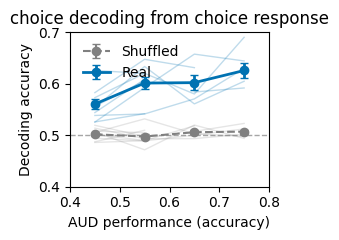


Friedman test (real decoding across performance bins): chi2 = 8.100, p = 0.04399, n = 4 mice.
Friedman test (shuffled decoding across performance bins): chi2 = 2.100, p = 0.5519, n = 4 mice.

Pairwise Wilcoxon tests between adjacent performance bins (real decoding):
  Bin 0.45 → 0.55: n = 9, p = 0.005859
  Bin 0.55 → 0.65: n = 5, p = 0.6875
  Bin 0.65 → 0.75: n = 5, p = 0.09375


In [27]:
base_dir = r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m'
# 1) Average decoding in 0–500 ms after ruleCue, bin by *visual* performance
res_vis= bin_modality_decoding_vs_performance_windowed(
    agg_data, mouse_ids, base_dir,
    title = 'choice decoding from choice response',
    filename='choice_decoding_choice_shuffled_results.pkl',
    time_window=(0, 0.2), perf_modality='aud',
    perf_min=0.4, perf_max=0.8, bin_width=0.1,
    metric='balanced',
    color='#0072B2',
    show_individual=True
)


In [ ]:
res_vis['figure'].savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig6', "context_decoding_from_face_bin_aud_performance.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

In [13]:
def sem(a, axis=0):
    a = np.asarray(a, dtype=float)
    n = np.sum(np.isfinite(a), axis=axis)
    sd = np.nanstd(a, axis=axis, ddof=1)
    with np.errstate(invalid='ignore', divide='ignore'):
        return sd / np.sqrt(n)
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

def plot_timecourse_progression_by_performance(
    agg_data,
    mouse_ids,
    base_dir,
    filename='choice_decoding_choice_shuffled_results.pkl',
    perf_modality='vis',      # 'vis' or 'aud' → which performance to bin on
    perf_min=0.35,
    perf_max=1.0,
    bin_width=0.10,
    metric='balanced',        # 'raw' or 'balanced'
    time_range_ms=None,       # e.g. (-200, 800); also defines stats window if not None
    cmap_name='viridis',      # colormap for learning progression
    lw_mean=2.5,
    lw_individual=1,
    alpha_individual=0.2,
    figsize=(4,3),
    show_individual=False,    # optional, for debugging
):
    """
    Plot average decoding timecourses (across mice) for all performance bins
    on a single plot. Color encodes behavioral performance bin.

    Each line = mean decoding across mice in one performance bin.

    Also:
      - collects shuffled-label timecourses per bin
      - runs real vs shuffled stats at each timepoint (paired Wilcoxon)
      - FDR-corrects p-values across timepoints per bin
      - prints earliest significant timepoint (ms) per bin, restricted to time_range_ms
    """
    use_vis = (perf_modality.lower() == 'vis')

    # define bins
    edges = np.arange(perf_min, perf_max + 1e-12, bin_width)
    centers = 0.5 * (edges[:-1] + edges[1:])
    n_bins = len(centers)

    per_bin_mouse_real = [[] for _ in range(n_bins)]
    per_bin_mouse_shuf = [[] for _ in range(n_bins)]
    time_template = None

    for mouse in mouse_ids:
        pkl_path = os.path.join(base_dir, mouse, filename)
        if not os.path.exists(pkl_path):
            print(f"[{mouse}] file not found → skip")
            continue

        with open(pkl_path, 'rb') as f:
            results_all = pickle.load(f)
        if not results_all:
            continue

        train_dates = np.asarray(agg_data[mouse]['training']['training_dates'])
        perf_arr = np.asarray(
            agg_data[mouse]['training']['accuracies_vis' if use_vis else 'accuracies_aud']
        )

        img_dates = [d for d in agg_data[mouse].keys() if d.startswith('202')]
        img_dates = sorted(img_dates, key=lambda d: int(d[:8]))

        mouse_bin_session_real = [[] for _ in range(n_bins)]
        mouse_bin_session_shuf = [[] for _ in range(n_bins)]

        for i, res in enumerate(results_all):
            if i >= len(img_dates):
                break
            date = img_dates[i]

            # choose metric
            if metric == 'raw':
                curve = np.asarray(res['acc'])
                shuf_curve = np.asarray(res.get('shuf_acc', []))
            elif metric == 'balanced':
                curve = np.asarray(res['acc_bal'])
                shuf_curve = np.asarray(res.get('shuf_acc_bal', []))
            else:
                raise ValueError("metric must be 'raw' or 'balanced'")

            tp = np.asarray(res['timepoints'])
            if (curve.size == 0 or tp.size != curve.size or
                shuf_curve.size == 0 or shuf_curve.size != curve.size):
                continue

            if time_template is None:
                time_template = tp.copy()

            td = date[:8]
            idx = np.where(train_dates == td)[0]
            if idx.size == 0:
                continue
            perf_val = float(perf_arr[idx][0])

            # find bin
            bin_idx = None
            for bi in range(n_bins):
                if perf_val >= edges[bi] and perf_val < edges[bi+1]:
                    bin_idx = bi
                    break
            if bin_idx is None:
                continue

            mouse_bin_session_real[bin_idx].append(curve)
            mouse_bin_session_shuf[bin_idx].append(shuf_curve)

        # average across this mouse's sessions within each bin
        for bi in range(n_bins):
            if len(mouse_bin_session_real[bi]) == 0:
                continue
            mean_real = np.nanmean(np.vstack(mouse_bin_session_real[bi]), axis=0)
            mean_shuf = np.nanmean(np.vstack(mouse_bin_session_shuf[bi]), axis=0)
            per_bin_mouse_real[bi].append(mean_real)
            per_bin_mouse_shuf[bi].append(mean_shuf)

    if time_template is None:
        raise RuntimeError("No valid decoding timecourses found across mice.")
    tp_ms = time_template * 1000.0

    fig, ax = plt.subplots(figsize=figsize)

    cmap = plt.get_cmap(cmap_name)
    norm = Normalize(vmin=perf_min, vmax=perf_max)
    sm = ScalarMappable(norm=norm, cmap=cmap)

    # window for stats (if None, use full range)
    if time_range_ms is None:
        stat_mask = np.ones_like(tp_ms, dtype=bool)
    else:
        stat_mask = (tp_ms >= time_range_ms[0]) & (tp_ms <= time_range_ms[1])

    sig_onset_times_ms = np.full(n_bins, np.nan)

    for bi, center_perf in enumerate(centers):
        curves_real = per_bin_mouse_real[bi]
        curves_shuf = per_bin_mouse_shuf[bi]
        if len(curves_real) == 0:
            continue

        curves_real = np.vstack(curves_real)
        curves_shuf = np.vstack(curves_shuf)

        mean_curve = np.nanmean(curves_real, axis=0)
        sem_curve  = sem(curves_real, axis=0)

        color = sm.to_rgba(center_perf)

        if show_individual:
            for mc in curves_real:
                ax.plot(tp_ms, mc, color=color, alpha=alpha_individual, lw=lw_individual)

        ax.plot(tp_ms, mean_curve, color=color, lw=lw_mean,
                label=f"{center_perf:.2f}")
        ax.fill_between(tp_ms, mean_curve - sem_curve, mean_curve + sem_curve,
                        color=color, alpha=0.15)

        # ---- stats: real vs shuffled, restricted to stat_mask ----
        n_time = curves_real.shape[1]
        pvals = np.full(n_time, np.nan)

        for ti in range(n_time):
            if not stat_mask[ti]:
                continue  # skip timepoints outside stats window
            r = curves_real[:, ti]
            s = curves_shuf[:, ti]
            ok = np.isfinite(r) & np.isfinite(s)
            if ok.sum() >= 3:
                _, p = wilcoxon(r[ok], s[ok], alternative='greater')
                pvals[ti] = p

        valid = np.isfinite(pvals)
        if valid.sum() > 0:
            _, pvals_fdr, _, _ = multipletests(pvals[valid], method='fdr_bh')
            p_fdr_full = np.full_like(pvals, np.nan)
            p_fdr_full[valid] = pvals_fdr

            # only consider significant points inside the stats window
            sig_idx = np.where((p_fdr_full < 0.05) & stat_mask)[0]
            if sig_idx.size > 0:
                first_sig_t = tp_ms[sig_idx[0]]
                sig_onset_times_ms[bi] = first_sig_t
                print(f"Perf bin {center_perf:.2f}: first real>shuffled at {first_sig_t:.1f} ms (FDR<0.05), n={curves_real.shape[0]} mice.")
            else:
                print(f"Perf bin {center_perf:.2f}: no significant timepoint real>shuffled in [{time_range_ms[0]}, {time_range_ms[1]}] ms (FDR<0.05).")
        else:
            print(f"Perf bin {center_perf:.2f}: no valid p-values for stats in the chosen time range.")

    # reference lines
    ax.axvline(0, color='k', ls='--', lw=1)
    if metric == 'balanced':
        ax.axhline(0.5, color='gray', ls='--', lw=1)

    # axes & labels
    if time_range_ms is not None:
        ax.set_xlim(*time_range_ms)
    ax.set_ylim(0.45, 0.75)
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Decoding choice accuracy")
    ax.set_title("Choice decoding from pre-movement response")
    ax.axvline(200, ls='--', lw=1, color='k', alpha=0.7)

    leg = ax.legend(
        title="performance bin",
        frameon=False,
        loc='upper right',
        ncol=1
    )

    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(f"{perf_modality.upper()} performance")

    plt.tight_layout()
    plt.show()

    return {
        'bin_centers': centers,
        'timepoints_ms': tp_ms,
        'per_bin_mouse_curves_real': per_bin_mouse_real,
        'per_bin_mouse_curves_shuf': per_bin_mouse_shuf,
        'sig_onset_times_ms': sig_onset_times_ms,
        'perf_modality': perf_modality,
        'metric': metric,
        'fig': fig,
        'ax': ax
    }


Perf bin 0.45: first real>shuffled at -133.3 ms (FDR<0.05), n=11 mice.
Perf bin 0.55: first real>shuffled at -66.7 ms (FDR<0.05), n=9 mice.
Perf bin 0.65: first real>shuffled at -66.7 ms (FDR<0.05), n=7 mice.
Perf bin 0.75: first real>shuffled at -66.7 ms (FDR<0.05), n=7 mice.


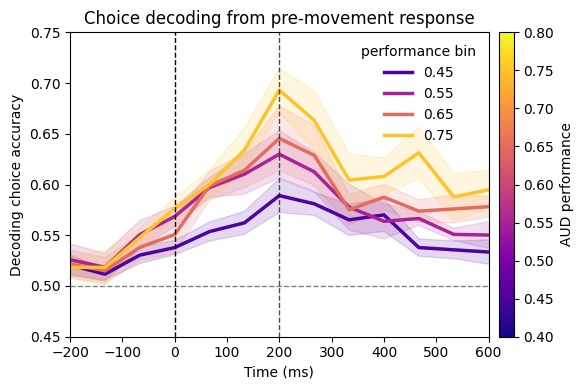

In [16]:
res = plot_timecourse_progression_by_performance(
    agg_data=agg_data,
    mouse_ids=mouse_ids,
    base_dir=r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m',
    filename='choice_decoding_choice_shuffled_results.pkl',
    perf_modality='aud',       # or 'aud'
    perf_min=0.4,
    perf_max=0.8,
    bin_width=0.1,
    metric='balanced',
    time_range_ms=(-200, 600),
    cmap_name='plasma',        # ‘viridis’, ‘cividis’, or ‘plasma’ all look great
    figsize=(6,4)
)

In [49]:
res['fig'].savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig5', "choice_decoding_timecourse_bin_perf.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

In [62]:
def plot_decoding_accuracy_by_session(
    agg_data,
    mouse_ids,
    base_dir,
    filename='context_decoding_ruleCue_results.pkl',
    time_window=None,        # e.g. (0, 0.5) seconds; None = full range
    sort_by_training=True,   # sort sessions by training date (recommended)
    color='#0072B2',
    show_individual=True
):
    """
    Plot average decoding accuracy across sessions (learning progression)
    for all mice — no performance binning.

    For each mouse:
      - loads decoding results from the given filename
      - averages accuracy across the given time window
      - aligns sessions by training date
    """
    per_mouse_curves = []
    n_sessions_max = 0

    for mouse in mouse_ids:
        pkl_path = os.path.join(base_dir, mouse, filename)
        if not os.path.exists(pkl_path):
            print(f"[{mouse}] file not found, skipping.")
            continue

        with open(pkl_path, 'rb') as f:
            results_all = pickle.load(f)
        if not results_all:
            continue

        # Sort by date if needed
        if sort_by_training:
            results_all = sorted(results_all, key=lambda r: int(r.get('date', '0')[:8]))

        # Per-session mean decoding accuracy (within window)
        session_means = []
        for res in results_all:
            acc = np.asarray(res['acc'])
            tp  = np.asarray(res['timepoints'])
            if acc.size == 0 or tp.size != acc.size:
                continue
            if time_window is None:
                mean_acc = np.nanmean(acc)
            else:
                t0, t1 = time_window
                mask = (tp >= t0) & (tp <= t1)
                if not np.any(mask):
                    continue
                mean_acc = np.nanmean(acc[mask])
            session_means.append(mean_acc)

        if len(session_means) == 0:
            continue

        per_mouse_curves.append(np.asarray(session_means))
        n_sessions_max = max(n_sessions_max, len(session_means))

    if not per_mouse_curves:
        raise RuntimeError("No valid data found for any mouse.")

    # pad each mouse’s curve with NaNs to align session indices
    curves_aligned = np.full((len(per_mouse_curves), n_sessions_max), np.nan)
    for i, curve in enumerate(per_mouse_curves):
        curves_aligned[i, :len(curve)] = curve

    mean_curve = np.nanmean(curves_aligned, axis=0)
    sem_curve  = sem(curves_aligned, axis=0)

    # Plot
    fig, ax = plt.subplots(figsize=(5,4))
    if show_individual:
        for row in curves_aligned:
            ax.plot(np.arange(1, len(row)+1), row, color=color, alpha=0.25, lw=1)
    ax.errorbar(np.arange(1, len(mean_curve)+1), mean_curve, yerr=sem_curve,
                fmt='o-', color=color, lw=2, capsize=3, label='Mean decoding accuracy')
    ax.set_xlabel('Session number')
    ax.set_ylabel('Decoding accuracy (averaged over window)')
    ax.set_ylim(0.4, 1.0)
    ax.grid(True, alpha=0.3)
    if time_window:
        ax.set_title(f"Average decoding accuracy (time window {time_window[0]:.3f}–{time_window[1]:.3f}s)")
    else:
        ax.set_title("Average decoding accuracy per session (full time range)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return {
        'session_curve_per_mouse': curves_aligned,
        'mean_curve': mean_curve,
        'sem_curve': sem_curve
    }

[AF_L3] file not found, skipping.
[AB_R2] file not found, skipping.
[J_L2] file not found, skipping.
[A_R2] file not found, skipping.
[A_R3] file not found, skipping.
[O_R2] file not found, skipping.
[R_L2] file not found, skipping.


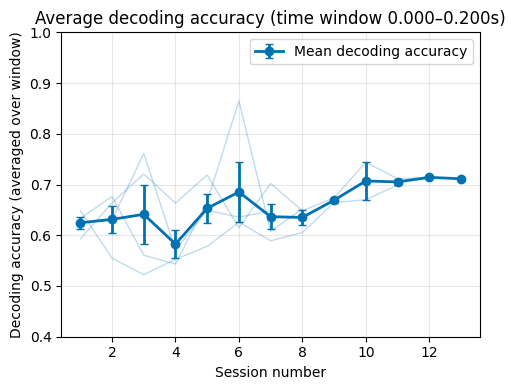

In [64]:
res = plot_decoding_accuracy_by_session(
    agg_data=agg_data,
    mouse_ids=mouse_ids,
    base_dir=base_dir,
    filename='choice_decoding_choice_shuffled_results.pkl',
    time_window=(0, 0.2),      # average within 0–0.5s after ruleCue
    sort_by_training=True,
    color='#0072B2'
)

In [108]:
plot_decoding_accuracy(results_all[0], title='context decoding from ruleCue', time_range_ms=(-400, 1000))

IndexError: list index out of range

Sensory response vs performance

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def plot_mouse_predictor_psth_all_neurons(
    agg_data,
    mouse,
    predictor,
    psth_time_window=(-0.4, 1.2),
    use_zscore=True,                # True -> uses predictor+'_psth'
    arms=('arm1', 'arm2'),
    sort_mode='peak_time',          # 'peak_time' or 'magnitude'
    sort_window=(0.0, 0.4),         # time window for sorting; None -> full
    vmin=-3, vmax=3,
    cmap='viridis',
    roi_masks_full=None,            # dict: roi_name -> 2D bool/0-1 mask (atlas space)
    roi_order=None,                 # list of roi names; if None, use roi_masks_full.keys()
    frac_thresh=0.5                 # min fraction of pixels in ROI to assign neuron
):
    """
    Plot PSTH heatmaps of all neurons for a given mouse and predictor, per session (date).

    - Combines arm1 and arm2 neurons.
    - Each subplot = one session (date).
    - Each row = a neuron.
    - Sorting:
        * sort_mode='peak_time'  -> by time of max|response| within sort_window (earliest first).
        * sort_mode='magnitude'  -> by max|response| within sort_window (smallest first).
    - Sorting window in seconds: sort_window=(t_start, t_end). If None, uses full psth_time_window.

    ROI-aware behavior (if roi_masks_full is provided):
    - Neurons are assigned to a single ROI (the ROI with highest frac_in_roi > frac_thresh).
    - In each session heatmap:
        rows are stacked as:
            [ROI1 neurons (sorted),
             ROI2 neurons (sorted),
             ...]
    - Horizontal white lines separate ROIs.

    Parameters
    ----------
    agg_data : dict
    mouse : str
    predictor : str
    psth_time_window : (float, float)
        Time axis range for the PSTH (must match your computation).
    use_zscore : bool
        True -> predictor+'_psth'; False -> predictor+'_psth_raw'.
    arms : tuple(str)
        Arms to include (e.g., ('arm1','arm2')).
    sort_mode : {'peak_time', 'magnitude'}
    sort_window : (float, float) or None
    vmin, vmax : float
        Color limits for imshow.
    cmap : str
    roi_masks_full : dict or None
        roi_name -> 2D mask in atlas coordinates.
    roi_order : list or None
        Order in which ROIs appear from top to bottom. Defaults to list(roi_masks_full.keys()).
    frac_thresh : float
        Threshold on fraction of neuron pixels in ROI to assign it.

    Returns
    -------
    fig, axes
    """
    mouse_data = agg_data[mouse]
    key = predictor + ('_psth' if use_zscore else '_psth_raw')

    # --- Setup ROI info if given ---
    use_roi = roi_masks_full is not None
    if use_roi:
        roi_masks_bool = {r: np.asarray(m, dtype=bool) for r, m in roi_masks_full.items()}
        if roi_order is None:
            roi_order = list(roi_masks_bool.keys())

    # --- collect dates ---
    dates = [d for d in mouse_data.keys() if d != 'training']
    dates = sorted(dates)

    session_psths = []   # list of (date, psths_sorted_all, t, roi_blocks_info)

    for date in dates:
        if not any(arm in mouse_data[date] for arm in arms):
            continue

        # For ROI grouping: dict roi_name -> list of psth rows
        if use_roi:
            roi_to_psths = {roi: [] for roi in roi_order}
        else:
            all_means = []  # single pool

        # --- iterate neurons ---
        for arm in arms:
            if arm not in mouse_data[date]:
                continue

            for neuron in mouse_data[date][arm]['stat']:
                if key not in neuron:
                    continue

                psth = neuron[key]
                if psth is None:
                    continue
                psth = np.asarray(psth)
                if psth.ndim == 1:
                    mean_psth = psth
                else:
                    mean_psth = np.nanmean(psth, axis=0)

                if use_roi:
                    # assign neuron to ROI by highest fraction
                    if 'xcoord_atlas' not in neuron or 'ycoord_atlas' not in neuron:
                        continue
                    x = np.asarray(neuron['xcoord_atlas'], dtype=int)
                    y = np.asarray(neuron['ycoord_atlas'], dtype=int)
                    # bounds
                    best_roi = None
                    best_frac = 0.0
                    for roi_name, roi_mask in roi_masks_bool.items():
                        H, W = roi_mask.shape
                        ok = (x >= 0) & (x < W) & (y >= 0) & (y < H)
                        if not np.any(ok):
                            continue
                        xx = x[ok]
                        yy = y[ok]
                        n_pix_total = len(xx)
                        if n_pix_total == 0:
                            continue
                        n_pix_in_roi = np.count_nonzero(roi_mask[yy, xx])
                        frac_in_roi = n_pix_in_roi / n_pix_total
                        if frac_in_roi > best_frac:
                            best_frac = frac_in_roi
                            best_roi = roi_name

                    if best_roi is not None and best_frac > frac_thresh:
                        roi_to_psths[best_roi].append(mean_psth)
                else:
                    all_means.append(mean_psth)

        # --- build stacked PSTH matrix for this date ---
        if use_roi:
            # if no ROI neurons at all, skip session
            if not any(len(v) > 0 for v in roi_to_psths.values()):
                continue

            # assume all PSTHs have same length
            # pick a non-empty ROI to infer T
            sample_roi = next(r for r in roi_order if len(roi_to_psths[r]) > 0)
            T = len(roi_to_psths[sample_roi][0])
            t = np.linspace(psth_time_window[0], psth_time_window[1], T)

            psth_blocks = []      # list of (roi_name, psths_roi_sorted)
            roi_block_sizes = []  # number of neurons per roi (after filtering)
            roi_block_names = []  # for plotting separators

            # sort within each ROI
            for roi_name in roi_order:
                if len(roi_to_psths[roi_name]) == 0:
                    continue
                psths_roi = np.vstack(roi_to_psths[roi_name])  # (n_roi_neurons, T)

                # define sorting mask
                if sort_window is not None:
                    t_start, t_end = sort_window
                    sort_mask = (t >= t_start) & (t <= t_end)
                    if not np.any(sort_mask):
                        sort_mask = np.ones_like(t, dtype=bool)
                else:
                    sort_mask = np.ones_like(t, dtype=bool)

                t_sort = t[sort_mask]
                psth_sort = psths_roi[:, sort_mask]

                if sort_mode == 'peak_time':
                    peak_times = []
                    for i in range(psth_sort.shape[0]):
                        y = psth_sort[i]
                        if np.all(np.isnan(y)):
                            peak_times.append(np.inf)
                        else:
                            peak_idx = np.nanargmax(np.abs(y))
                            peak_times.append(t_sort[peak_idx])
                    peak_times = np.array(peak_times)
                    sort_order = np.argsort(peak_times)   # earliest first
                elif sort_mode == 'magnitude':
                    mags = np.nanmax(np.abs(psth_sort), axis=1)
                    sort_order = np.argsort(mags)         # smallest first
                else:
                    raise ValueError("sort_mode must be 'peak_time' or 'magnitude'")

                psths_roi_sorted = psths_roi[sort_order]
                psth_blocks.append((roi_name, psths_roi_sorted))
                roi_block_sizes.append(psths_roi_sorted.shape[0])
                roi_block_names.append(roi_name)

            if len(psth_blocks) == 0:
                continue

            # stack all ROIs vertically: [ROI1 block; ROI2 block; ...]
            psths_sorted_all = np.vstack([blk for _, blk in psth_blocks])
            # info for separators: cumulative sums
            roi_cum_sizes = np.cumsum(roi_block_sizes)
            roi_blocks_info = {
                'names': roi_block_names,
                'sizes': roi_block_sizes,
                'cum_sizes': roi_cum_sizes
            }

        else:
            if not all_means:
                continue

            psths = np.vstack(all_means)    # (n_neurons, T)
            T = psths.shape[1]
            t = np.linspace(psth_time_window[0], psth_time_window[1], T)

            if sort_window is not None:
                t_start, t_end = sort_window
                sort_mask = (t >= t_start) & (t <= t_end)
                if not np.any(sort_mask):
                    sort_mask = np.ones_like(t, dtype=bool)
            else:
                sort_mask = np.ones_like(t, dtype=bool)

            t_sort = t[sort_mask]
            psth_sort = psths[:, sort_mask]

            if sort_mode == 'peak_time':
                peak_times = []
                for i in range(psth_sort.shape[0]):
                    y = psth_sort[i]
                    if np.all(np.isnan(y)):
                        peak_times.append(np.inf)
                    else:
                        peak_idx = np.nanargmax(np.abs(y))
                        peak_times.append(t_sort[peak_idx])
                peak_times = np.array(peak_times)
                sort_order = np.argsort(peak_times)
            elif sort_mode == 'magnitude':
                mags = np.nanmax(np.abs(psth_sort), axis=1)
                sort_order = np.argsort(mags)
            else:
                raise ValueError("sort_mode must be 'peak_time' or 'magnitude'")

            psths_sorted_all = psths[sort_order]
            roi_blocks_info = None

        session_psths.append((date, psths_sorted_all, t, roi_blocks_info))

    if not session_psths:
        print(f"No PSTH data for predictor '{predictor}' in mouse '{mouse}'.")
        return None, None

    # --- plotting ---
    n_sessions = len(session_psths)
    fig, axes = plt.subplots(1, n_sessions, figsize=(4 * n_sessions, 4))
    if n_sessions == 1:
        axes = [axes]

    last_im = None

    for ax, (date, psths_sorted_all, t, roi_blocks_info) in zip(axes, session_psths):
        n_rows = psths_sorted_all.shape[0]
        im = ax.imshow(
            psths_sorted_all,
            aspect='auto',
            extent=[psth_time_window[0], psth_time_window[1], 0, n_rows],
            cmap=cmap,
            vmin=vmin, vmax=vmax
        )
        last_im = im
        ax.axvline(0, color='red', linestyle='--')

        # draw ROI separators if available
        if roi_blocks_info is not None:
            for ysep in roi_blocks_info['cum_sizes'][:-1]:
                ax.axhline(y=n_rows-ysep, color='red', linestyle='-', linewidth=2)

        ax.set_title(date)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Neurons')

    # one colorbar on the right of the last subplot
    cbar = fig.colorbar(last_im, ax=axes[-1], fraction=0.046, pad=0.04)
    cbar.set_label('Z-scored dF/F' if use_zscore else 'dF/F')

    fig.suptitle(f"{mouse} – {predictor}", y=1.05)
    fig.tight_layout()

    return fig, axes


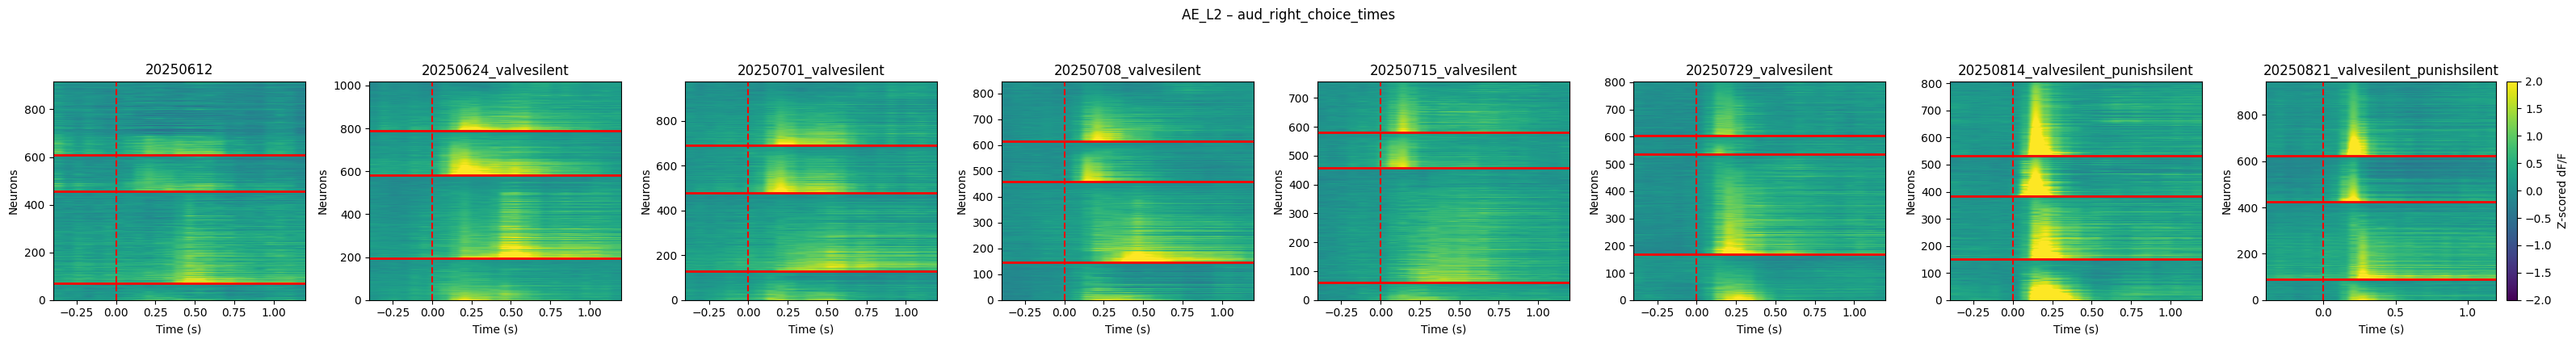

In [41]:
fig1, axes = plot_mouse_predictor_psth_all_neurons(
    agg_data,
    mouse='AE_L2',
    predictor='aud_right_choice_times',
    psth_time_window=(-0.4, 1.2),
    use_zscore=True,            # True -> uses predictor+'_psth'
    arms=('arm1', 'arm2'),
    sort_mode='magnitude',      # 'peak_time' or 'magnitude'
    sort_window=(0.0, 0.4),     # time window to compute peak (e.g. (0, 0.4)); None -> full window
    vmin=-2, vmax=2,
    cmap='viridis',
    roi_masks_full= roi_masks_full,            # dict: roi_name -> 2D bool/0-1 mask (atlas space)
    roi_order=['lob_V', 'lob_VI', 'simplex', 'crus_I'],                 # list of roi names; if None, use roi_masks_full.keys()
    frac_thresh=0.5 
)

In [42]:
fig1.savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig5', "example_aud_right_choice_psth_heatmap.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

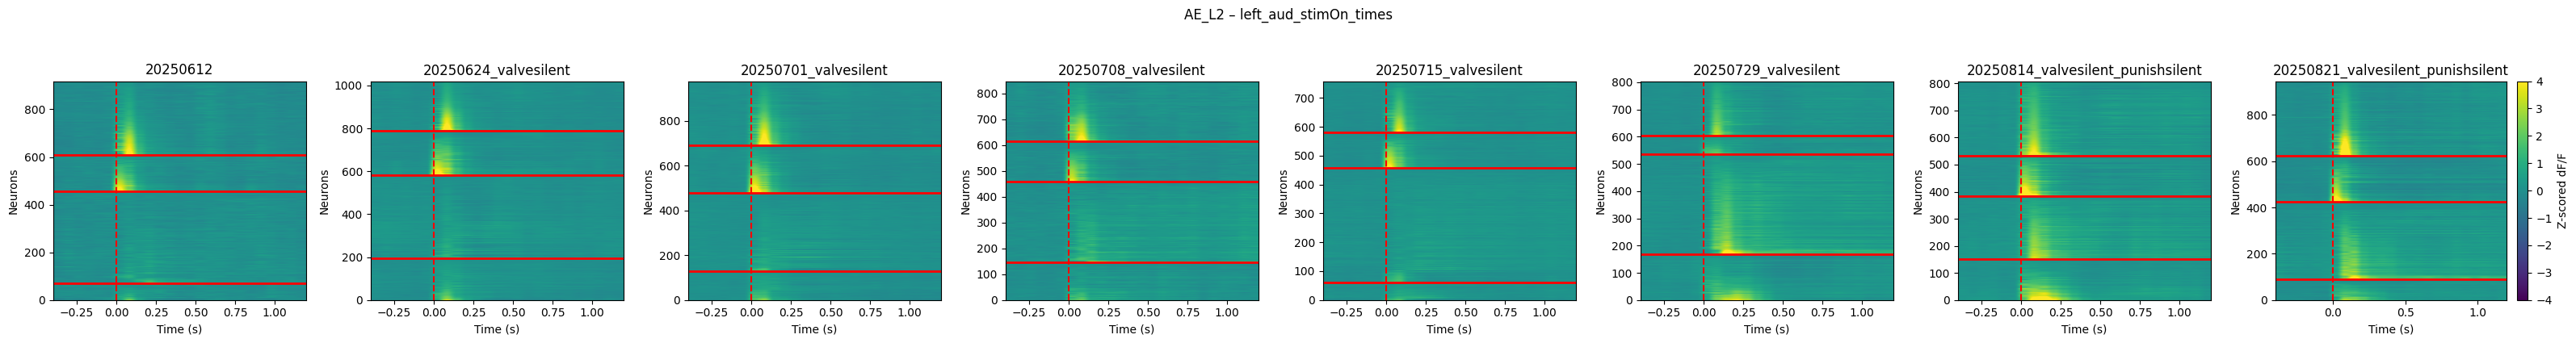

In [26]:
fig2, axes = plot_mouse_predictor_psth_all_neurons(
    agg_data,
    mouse='AE_L2',
    predictor='left_aud_stimOn_times',
    psth_time_window=(-0.4, 1.2),
    use_zscore=True,            # True -> uses predictor+'_psth'
    arms=('arm1', 'arm2'),
    sort_mode='magnitude',      # 'peak_time' or 'magnitude'
    sort_window=(0.0, 0.4),     # time window to compute peak (e.g. (0, 0.4)); None -> full window
    vmin=-4, vmax=4,
    cmap='viridis',
    roi_masks_full= roi_masks_full,            # dict: roi_name -> 2D bool/0-1 mask (atlas space)
    roi_order=['lob_V', 'lob_VI', 'simplex', 'crus_I'],                 # list of roi names; if None, use roi_masks_full.keys()
    frac_thresh=0.5 
)

In [27]:
fig2.savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig3', "example_left_aud_stimon_psth_heatmap.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

In [ ]:
pred = 'vis_ruleCue_times'
pred_idx = [i for i, name in enumerate(predictors) if pred in name]
unique_pred_idx = np.where(np.array(unique_predictors) == pred)[0]
rows, cols = grid_shape(len(mouse_ids))
fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
for mousei, mouse in enumerate(mouse_ids):

    mouse_data = agg_data[mouse]
    vis_perf = rolling_average(mouse_data['training']['accuracies_vis'], 3)
    aud_perf = rolling_average(mouse_data['training']['accuracies_aud'], 3)
    training_dates = mouse_data['training']['training_dates']
    img_dates = [s for s in mouse_data.keys() if (
        s.isdigit() or 
        (s.endswith('_valvesilent') and s[:-12].isdigit()) or
        (s.endswith('_valvesilent_punishsilent') and s[:-25].isdigit())
    )]

    beta_by_days = np.array([])
    vis_perf_by_days = np.array([])
    aud_perf_by_days = np.array([])
    training_day_count = np.array([])
    sig_prob_by_days = np.array([])
    for date in img_dates:
        training_day_num = np.where(training_dates==date[:8])[0]
        training_day_count = np.append(training_day_count, training_day_num)
        vis_perf_by_days = np.append(vis_perf_by_days, vis_perf[training_day_num])
        aud_perf_by_days = np.append(aud_perf_by_days, aud_perf[training_day_num])
        pval = np.array([])
        if 'arm1' in mouse_data[date]:
            for i, neuron in enumerate(mouse_data[date]['arm1']['stat']):
                pval = np.append(pval, neuron['bootstrap_p_value'][unique_pred_idx])
        if 'arm2' in mouse_data[date]:
            for i, neuron in enumerate(mouse_data[date]['arm2']['stat']):
                pval = np.append(pval, neuron['bootstrap_p_value'][unique_pred_idx])
        sig_prob = np.sum(pval < 0.05) / len(pval)
        sig_prob_by_days = np.append(sig_prob_by_days, sig_prob)

    if mouse == 'A_R2':  # delete later.. 20240815 doesn't appear in training_data
        beta_by_days = beta_by_days[1:]
        
    # Plot z-scored data on primary axis
    ax1 = axes[mousei//cols, mousei%cols]
    color1 = 'tab:blue'
    ax1.set_xlabel('Days')
    ax1.set_ylabel('Contralateral Vis Stim Beta', color=color1)
    
    # Add line
    line1 = ax1.plot(training_day_count, beta_by_days, color=color1, alpha=0.7)
    
    # Add scatter points
    scatter1 = ax1.scatter(training_day_count, beta_by_days, color=color1, s=30, zorder=3)
    
    ax1.tick_params(axis='y', labelcolor=color1)

    # Create secondary axis sharing the same x-axis
    ax2 = ax1.twinx()

    # Plot accuracy data on secondary axis
    color2 = 'tab:red'
    ax2.set_ylabel('Vis Trial %Correct', color=color2)
    
    # Add line
    line2 = ax2.plot(training_day_count, vis_perf_by_days, color=color2, alpha=0.7)
    
    # Add scatter points
    scatter2 = ax2.scatter(training_day_count, vis_perf_by_days, color=color2, s=30, zorder=3, marker='s')
    
    ax2.tick_params(axis='y', labelcolor=color2)

    # Set reasonable y-axis limits for both measures
    ax1.set_ylim(0, 0.005)  # typical range for z-scores
    ax2.set_ylim(0.35, 1.05)  # range for accuracy values

    # Add a title
    ax1.set_title(mouse)

plt.tight_layout()
plt.show()
    

In [10]:
# --- colors (color-blind friendly) ---
COLOR_VIS = '#0072B2'  # blue
COLOR_AUD = '#E69F00'  # orange
def sem(data, axis=0, nan_policy='omit'):
    """
    Compute the standard error of the mean (SEM) along a given axis.
    
    Parameters
    ----------
    data : array-like
        Input data.
    axis : int, default=0
        Axis along which to compute SEM.
    nan_policy : {'omit', 'propagate'}, default='omit'
        If 'omit', ignore NaNs. If 'propagate', NaNs propagate to the output.
        
    Returns
    -------
    sem : float or ndarray
        Standard error of the mean along the given axis.
    """
    data = np.asanyarray(data)
    if nan_policy == 'omit':
        valid = np.isfinite(data)
        count = np.sum(valid, axis=axis)
        std = np.nanstd(data, axis=axis, ddof=1)
    else:
        count = data.shape[axis]
        std = np.std(data, axis=axis, ddof=1)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        sem_val = std / np.sqrt(count)
    return sem_val

from scipy.stats import wilcoxon

def first_last_sigprop_per_mouse(mouse_data, unique_pred_idx, pval_thresh=0.05):
    """
    For a given mouse and predictor, return (first_sig_prop, last_sig_prop)
    across imaging days, using the same p-value threshold logic as
    collect_sigprop_by_day.
    """
    _, sig_prop, _, _ = collect_sigprop_by_day(
        mouse_data, unique_pred_idx, pval_thresh=pval_thresh
    )
    if sig_prop.size == 0:
        return None, None

    sig_prop = np.asarray(sig_prop, dtype=float)
    valid = np.isfinite(sig_prop)
    if not np.any(valid):
        return None, None

    sig_valid = sig_prop[valid]
    first = sig_valid[0]
    last = sig_valid[-1]
    return first, last

def collect_sigprop_by_day(mouse_data, unique_pred_idx, pval_thresh = 0.05):
    vis_perf_all = rolling_average(mouse_data['training']['accuracies_vis'], 3)
    aud_perf_all = rolling_average(mouse_data['training']['accuracies_aud'], 3)
    training_dates = mouse_data['training']['training_dates']

    img_dates = [s for s in mouse_data.keys() if (
        s.isdigit() or
        (s.endswith('_valvesilent') and s[:-12].isdigit()) or
        (s.endswith('_valvesilent_punishsilent') and s[:-25].isdigit())
    )]
    img_dates = sorted(img_dates, key=lambda s: int(s[:8]))

    sig_prop_by_day, vis_perf_by_day, aud_perf_by_day, valid_dates = [], [], [], []
    for date in img_dates:
        td_idx = np.where(training_dates == date[:8])[0]
        if len(td_idx) == 0:
            continue

        pvals = []
        if 'arm1' in mouse_data[date]:
            for nrn in mouse_data[date]['arm1']['stat']:
                pvals.append(nrn['bootstrap_p_value'][unique_pred_idx])
        if 'arm2' in mouse_data[date]:
            for nrn in mouse_data[date]['arm2']['stat']:
                pvals.append(nrn['bootstrap_p_value'][unique_pred_idx])
        if len(pvals) == 0:
            continue

        pvals = np.asarray(pvals).ravel()
        sig_prop = np.sum(pvals < pval_thresh) / pvals.size

        sig_prop_by_day.append(sig_prop)
        vis_perf_by_day.append(float(vis_perf_all[td_idx]))
        aud_perf_by_day.append(float(aud_perf_all[td_idx]))
        valid_dates.append(date)

    if len(valid_dates) == 0:
        return [], np.array([]), np.array([]), np.array([])
    return valid_dates, np.array(sig_prop_by_day), np.array(vis_perf_by_day), np.array(aud_perf_by_day)


def bin_and_normalize_per_mouse(
    mouse_data, unique_pred_idx, modality='vis',
    perf_min=0.35, perf_max=1.0, bin_width=0.10,
    normalize_to='first',  # 'first' | 'last' | None
    eps=1e-9, pval_thresh = 0.05
):
    """
    Returns:
      centers (n_bins,), binned (n_bins,)  — per-mouse curve binned by performance,
      optionally normalized to first/last day’s sig proportion.
    """
    _, sig_prop, vis_perf, aud_perf = collect_sigprop_by_day(mouse_data, unique_pred_idx, pval_thresh = pval_thresh)
    if sig_prop.size == 0:
        return None, None

    perf = vis_perf if modality == 'vis' else aud_perf

    # --- normalization selector ---
    normalizer = 1.0
    if normalize_to in ('first', 'last'):
        if normalize_to == 'first':
            base = sig_prop[~np.isnan(sig_prop)][0] if np.any(~np.isnan(sig_prop)) else np.nan
        else:  # 'last'
            valid_idx = np.where(~np.isnan(sig_prop))[0]
            base = sig_prop[valid_idx[-1]] if valid_idx.size else np.nan
        if np.isnan(base) or base <= 0:
            # if base is invalid/zero, fall back to NaN normalization (curve becomes NaN)
            norm_sig = np.full_like(sig_prop, np.nan, dtype=float)
        else:
            normalizer = base
            norm_sig = sig_prop / (base + eps)
    else:
        norm_sig = sig_prop  # no normalization

    # --- binning ---
    edges = np.arange(perf_min, perf_max + 1e-12, bin_width)
    centers = 0.5 * (edges[:-1] + edges[1:])

    binned = np.full(centers.shape, np.nan)
    for i in range(len(centers)):
        in_bin = (perf >= edges[i]) & (perf < edges[i+1])
        if np.any(in_bin):
            binned[i] = np.nanmean(norm_sig[in_bin])

    return centers, binned

from scipy.stats import sem
def population_sigprop_vs_performance(
    agg_data, mouse_ids, unique_predictors,
    pred_vis='vis_ruleCue_times', pred_aud='aud_ruleCue_times',
    perf_min=0.35, perf_max=1.0, bin_width=0.10,
    pval_thresh = 0.05,
    show_individual=True,
    normalize_to='first'   # 'first' | 'last' | None
):
    up = np.asarray(unique_predictors)
    idx_vis = np.where(up == pred_vis)[0]
    idx_aud = np.where(up == pred_aud)[0]
    if idx_vis.size == 0 or idx_aud.size == 0:
        raise ValueError("Could not find pred_vis or pred_aud in unique_predictors.")
    idx_vis, idx_aud = int(idx_vis[0]), int(idx_aud[0])

    vis_curves, aud_curves, centers_ref = [], [], None

    # per-mouse first/last sig proportions (raw, not normalized)
    vis_first_list, vis_last_list = [], []
    aud_first_list, aud_last_list = [], []
    mice_used_first_last = []

    for mouse in mouse_ids:
        md = agg_data[mouse]

        # --- binned curves (normalized) ---
        c_vis, b_vis = bin_and_normalize_per_mouse(
            md, idx_vis, modality='vis',
            perf_min=perf_min, perf_max=perf_max, bin_width=bin_width,
            normalize_to=normalize_to, pval_thresh=pval_thresh
        )
        c_aud, b_aud = bin_and_normalize_per_mouse(
            md, idx_aud, modality='aud',
            perf_min=perf_min, perf_max=perf_max, bin_width=bin_width,
            normalize_to=normalize_to, pval_thresh=pval_thresh
        )
        if (c_vis is not None) and (c_aud is not None):
            if centers_ref is None:
                centers_ref = c_vis
            vis_curves.append(b_vis)
            aud_curves.append(b_aud)

        # --- raw first/last sig proportions for this mouse ---
        fv, lv = first_last_sigprop_per_mouse(md, idx_vis, pval_thresh=pval_thresh)
        fa, la = first_last_sigprop_per_mouse(md, idx_aud, pval_thresh=pval_thresh)

        # require both vis and aud to have first/last -> same mice for both modalities
        if (fv is not None) and (lv is not None) and (fa is not None) and (la is not None):
            vis_first_list.append(fv)
            vis_last_list.append(lv)
            aud_first_list.append(fa)
            aud_last_list.append(la)
            mice_used_first_last.append(mouse)

    if centers_ref is None or not vis_curves or not aud_curves:
        raise RuntimeError("No valid mice with data to plot.")

    vis_curves = np.vstack(vis_curves)
    aud_curves = np.vstack(aud_curves)

    vis_mean = np.nanmean(vis_curves, axis=0)
    vis_sem  = sem(vis_curves, axis=0, nan_policy='omit')
    aud_mean = np.nanmean(aud_curves, axis=0)
    aud_sem  = sem(aud_curves, axis=0, nan_policy='omit')

    # --- Plot curves vs performance ---
    fig, ax = plt.subplots(figsize=(4, 3))

    if show_individual:
        for row in vis_curves:
            ax.plot(centers_ref, row, color=COLOR_VIS, alpha=0.25, lw=1)
        for row in aud_curves:
            ax.plot(centers_ref, row, color=COLOR_AUD, alpha=0.25, lw=1)

    ax.errorbar(centers_ref, vis_mean, yerr=vis_sem, fmt='o-', color=COLOR_VIS,
                lw=2, capsize=3, label='Ipsi Vis')
    ax.errorbar(centers_ref, aud_mean, yerr=aud_sem, fmt='s-', color=COLOR_AUD,
                lw=2, capsize=3, label='Ipsi Aud')

    ax.set_xlabel('Performance (accuracy)')
    ylabel = 'Sig. proportion'
    if normalize_to in ('first', 'last'):
        ylabel += f' (normalized to {normalize_to} day)'
    ax.set_ylabel(ylabel)
    ax.set_xlim(perf_min, perf_max)
    ax.set_ylim(0, 1.5)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ---------- Per-mouse first vs last (raw) ----------
    vis_first = np.asarray(vis_first_list, dtype=float)
    vis_last  = np.asarray(vis_last_list, dtype=float)
    aud_first = np.asarray(aud_first_list, dtype=float)
    aud_last  = np.asarray(aud_last_list, dtype=float)

    # paired Wilcoxon for first vs last within each modality
    def paired_wilcoxon(first, last):
        ok = np.isfinite(first) & np.isfinite(last)
        if ok.sum() >= 3:
            diff = last[ok] - first[ok]
            if np.allclose(diff, 0):
                stat, p = 0.0, 1.0
            else:
                stat, p = wilcoxon(first[ok], last[ok])
        else:
            stat, p = np.nan, np.nan
        return stat, p, int(ok.sum())

    vis_stat, vis_p, vis_n = paired_wilcoxon(vis_first, vis_last)
    aud_stat, aud_p, aud_n = paired_wilcoxon(aud_first, aud_last)

    print("First vs last imaging day (raw sig proportion):")
    print(f"Vis  : n={vis_n}, p={vis_p:.3g}, "
        f"median first={np.nanmedian(vis_first):.3f}, "
        f"median last={np.nanmedian(vis_last):.3f}, "
        f"mean first={np.nanmean(vis_first):.3f}, "
        f"mean last={np.nanmean(vis_last):.3f}, "
        f"SEM first={sem(vis_first, nan_policy='omit'):.3f}, "
        f"SEM last={sem(vis_last, nan_policy='omit'):.3f}")

    print(f"Aud  : n={aud_n}, p={aud_p:.3g}, "
        f"median first={np.nanmedian(aud_first):.3f}, "
        f"median last={np.nanmedian(aud_last):.3f}, "
        f"mean first={np.nanmean(aud_first):.3f}, "
        f"mean last={np.nanmean(aud_last):.3f}, "
        f"SEM first={sem(aud_first, nan_policy='omit'):.3f}, "
        f"SEM last={sem(aud_last, nan_policy='omit'):.3f}")

    # --- Boxplot ---
      # --- Boxplot + paired points ---
    fig2, ax2 = plt.subplots(figsize=(4, 3))

    data = [vis_first, vis_last, aud_first, aud_last]
    positions = [1, 2, 4, 5]

    bp = ax2.boxplot(
        data,
        positions=positions,
        widths=0.6,
        patch_artist=True,
        showfliers=False
    )

    colors = [COLOR_VIS, COLOR_VIS, COLOR_AUD, COLOR_AUD]

    # color boxes
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.4)

    # --- Correct whisker/cap colors ---
    whisker_colors = []
    for c in colors:
        whisker_colors.extend([c, c])   # lower & upper

    for whisker, c in zip(bp['whiskers'], whisker_colors):
        whisker.set_color(c)

    for cap, c in zip(bp['caps'], whisker_colors):
        cap.set_color(c)

    # medians (all black)
    for median in bp['medians']:
        median.set_color('k')
        median.set_linewidth(1.5)

    # ---- overlay single mouse points + connecting lines ----
    rng = np.random.default_rng(0)  # fixed seed for reproducible jitter

    # Vis: positions 1 (first) and 2 (last)
    n_vis = len(vis_first)
    jitter_vis = (rng.random(n_vis) - 0.5) * 0.25  # small horizontal jitter

    for i in range(n_vis):
        if not (np.isfinite(vis_first[i]) and np.isfinite(vis_last[i])):
            continue
        x_first = 1 + jitter_vis[i]
        x_last  = 2 + jitter_vis[i]
        y_first = vis_first[i]
        y_last  = vis_last[i]

        # line
        ax2.plot([x_first, x_last], [y_first, y_last],
                 color=COLOR_VIS, alpha=0.5, linewidth=1)
        # points
        ax2.plot(x_first, y_first, 'o', color=COLOR_VIS, alpha=0.8, markersize=4)
        ax2.plot(x_last,  y_last,  'o', color=COLOR_VIS, alpha=0.8, markersize=4)

    # Aud: positions 4 (first) and 5 (last)
    n_aud = len(aud_first)
    jitter_aud = (rng.random(n_aud) - 0.5) * 0.25

    for i in range(n_aud):
        if not (np.isfinite(aud_first[i]) and np.isfinite(aud_last[i])):
            continue
        x_first = 4 + jitter_aud[i]
        x_last  = 5 + jitter_aud[i]
        y_first = aud_first[i]
        y_last  = aud_last[i]

        ax2.plot([x_first, x_last], [y_first, y_last],
                 color=COLOR_AUD, alpha=0.5, linewidth=1)
        ax2.plot(x_first, y_first, 's', color=COLOR_AUD, alpha=0.8, markersize=4)
        ax2.plot(x_last,  y_last,  's', color=COLOR_AUD, alpha=0.8, markersize=4)

    ax2.set_xticks(positions)
    ax2.set_xticklabels(['Vis first', 'Vis last', 'Aud first', 'Aud last'],
                        rotation=30, ha='right')
    ax2.set_ylabel('Sig. proportion (raw)')
    ax2.set_ylim(0, 1.1)
    plt.tight_layout()
    plt.show()

    return {
        'bin_centers': centers_ref,
        'vis_curves_per_mouse': vis_curves,
        'aud_curves_per_mouse': aud_curves,
        'vis_mean': vis_mean, 'vis_sem': vis_sem,
        'aud_mean': aud_mean, 'aud_sem': aud_sem,
        'normalize_to': normalize_to,
        # new outputs:
        'mice_used_first_last': mice_used_first_last,
        'vis_first': vis_first,
        'vis_last': vis_last,
        'aud_first': aud_first,
        'aud_last': aud_last,
        'vis_first_last_stats': {
            'stat': vis_stat, 'p': vis_p, 'n': vis_n,
            'median_first': np.nanmedian(vis_first),
            'median_last': np.nanmedian(vis_last)
        },
        'aud_first_last_stats': {
            'stat': aud_stat, 'p': aud_p, 'n': aud_n,
            'median_first': np.nanmedian(aud_first),
            'median_last': np.nanmedian(aud_last)
        },
        'figure_curve' : fig,
        'figure_boxplot' : fig2
    }

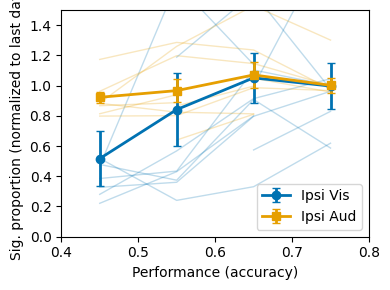

First vs last imaging day (raw sig proportion):
Vis  : n=11, p=0.0322, median first=0.031, median last=0.213, mean first=0.081, mean last=0.224, SEM first=0.042, SEM last=0.039
Aud  : n=11, p=0.175, median first=0.577, median last=0.630, mean first=0.557, mean last=0.652, SEM first=0.036, SEM last=0.030


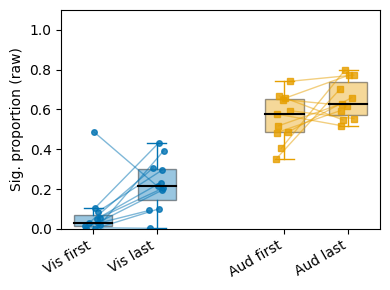

In [23]:
res = population_sigprop_vs_performance(
    agg_data=agg_data,
    mouse_ids=mouse_ids,
    unique_predictors=unique_predictors,
    pred_vis='left_vis_stimOn_times',
    pred_aud='left_aud_stimOn_times',
    perf_min=0.4, perf_max=0.8, bin_width=0.1,
    show_individual=True,
    normalize_to='last',
    pval_thresh=0.005
)

In [100]:
res['figure_curve'].savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig3', "sig_prop_curve.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

In [ ]:
res['figure_boxplot'].savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig3', "sig_prop_boxplot.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

In [18]:
from scipy.stats import wilcoxon, linregress

try:
    from statsmodels.stats.multitest import multipletests
    _HAS_STATSMODELS = True
except ImportError:
    _HAS_STATSMODELS = False
    def multipletests(pvals, method='fdr_bh'):
        # simple Benjamini–Hochberg fallback
        pvals = np.asarray(pvals, dtype=float)
        n = pvals.size
        order = np.argsort(pvals)
        ranked = np.empty_like(order, dtype=float)
        ranked[order] = np.arange(1, n+1)
        q = pvals * n / ranked
        # enforce monotonicity
        q_sorted = np.minimum.accumulate(q[order][::-1])[::-1]
        q = np.empty_like(q_sorted)
        q[order] = q_sorted
        reject = q < 0.05
        return reject, q, None, None


def analyze_population_sigprop(res):
    """
    Run stats on the output of population_sigprop_vs_performance().
    
    Tests:
      1) Vis vs Aud at each bin (paired Wilcoxon, FDR-corrected)
      2) First vs last bin within Vis and within Aud (paired Wilcoxon)
      3) Slope difference between Vis and Aud (per-mouse regression, paired Wilcoxon)
    """
    centers = res['bin_centers']
    vis_curves = np.asarray(res['vis_curves_per_mouse'])
    aud_curves = np.asarray(res['aud_curves_per_mouse'])
    n_bins = vis_curves.shape[1]

    # ---------- 1) Vis vs Aud at each bin ----------
    pvals_bin = np.full(n_bins, np.nan)
    stat_bin  = np.full(n_bins, np.nan)

    for i in range(n_bins):
        v = vis_curves[:, i]
        a = aud_curves[:, i]
        ok = np.isfinite(v) & np.isfinite(a)
        if ok.sum() >= 3:
            diff = v[ok] - a[ok]
            # Wilcoxon fails if all diffs are zero
            if np.allclose(diff, 0):
                p = 1.0
                stat = 0.0
            else:
                stat, p = wilcoxon(v[ok], a[ok])
            pvals_bin[i] = p
            stat_bin[i] = stat

    # FDR correction across bins
    mask_valid = np.isfinite(pvals_bin)
    pvals_fdr = np.full_like(pvals_bin, np.nan)
    reject_bin = np.zeros_like(pvals_bin, dtype=bool)
    if mask_valid.any():
        reject, p_corr, _, _ = multipletests(pvals_bin[mask_valid], method='fdr_bh')
        pvals_fdr[mask_valid] = p_corr
        reject_bin[mask_valid] = reject

    # ---------- 2) First vs last bin within each modality ----------
    def paired_first_last(curves):
        first = curves[:, 0]
        last  = curves[:, -1]
        ok = np.isfinite(first) & np.isfinite(last)
        if ok.sum() >= 3:
            diff = last[ok] - first[ok]
            if np.allclose(diff, 0):
                stat, p = 0.0, 1.0
            else:
                stat, p = wilcoxon(first[ok], last[ok])
        else:
            stat, p = np.nan, np.nan
        return {
            'stat': stat,
            'p': p,
            'n': int(ok.sum()),
            'median_first': np.nanmedian(first),
            'median_last': np.nanmedian(last),
            'median_change': np.nanmedian(last - first)
        }

    vis_first_last = paired_first_last(vis_curves)
    aud_first_last = paired_first_last(aud_curves)

    # ---------- 3) Slope difference between Vis and Aud ----------
    def per_mouse_slopes(curves, x):
        slopes = []
        for row in curves:
            y = np.asarray(row, dtype=float)
            ok = np.isfinite(y)
            if ok.sum() >= 2:
                slope = linregress(x[ok], y[ok]).slope
            else:
                slope = np.nan
            slopes.append(slope)
        return np.asarray(slopes, dtype=float)

    slopes_vis = per_mouse_slopes(vis_curves, centers)
    slopes_aud = per_mouse_slopes(aud_curves, centers)

    ok = np.isfinite(slopes_vis) & np.isfinite(slopes_aud)
    if ok.sum() >= 3:
        diff = slopes_vis[ok] - slopes_aud[ok]
        if np.allclose(diff, 0):
            slope_stat, slope_p = 0.0, 1.0
        else:
            slope_stat, slope_p = wilcoxon(slopes_vis[ok], slopes_aud[ok])
    else:
        slope_stat, slope_p = np.nan, np.nan

    slope_summary = {
        'stat': slope_stat,
        'p': slope_p,
        'n': int(ok.sum()),
        'median_slope_vis': np.nanmedian(slopes_vis),
        'median_slope_aud': np.nanmedian(slopes_aud),
        'median_slope_diff': np.nanmedian(slopes_vis - slopes_aud)
    }

    # ---------- Pretty print ----------
    print("=== Vis vs Aud at each bin (Wilcoxon, FDR-corrected) ===")
    for i, c in enumerate(centers):
        print(f"Bin {i} (center={c:.2f}): raw p={pvals_bin[i]:.3g}, "
              f"FDR p={pvals_fdr[i]:.3g}, sig={reject_bin[i]}")

    print("\n=== First vs last bin per modality (Wilcoxon) ===")
    print(f"Vis: n={vis_first_last['n']}, p={vis_first_last['p']:.3g}, "
          f"median first={vis_first_last['median_first']:.3f}, "
          f"median last={vis_first_last['median_last']:.3f}, "
          f"median change={vis_first_last['median_change']:.3f}")
    print(f"Aud: n={aud_first_last['n']}, p={aud_first_last['p']:.3g}, "
          f"median first={aud_first_last['median_first']:.3f}, "
          f"median last={aud_first_last['median_last']:.3f}, "
          f"median change={aud_first_last['median_change']:.3f}")

    print("\n=== Slope difference Vis vs Aud (per-mouse regression, Wilcoxon) ===")
    print(f"n={slope_summary['n']}, p={slope_summary['p']:.3g}, "
          f"median slope Vis={slope_summary['median_slope_vis']:.4f}, "
          f"median slope Aud={slope_summary['median_slope_aud']:.4f}, "
          f"median slope diff={slope_summary['median_slope_diff']:.4f}")

    return {
        'pvals_bin_raw': pvals_bin,
        'pvals_bin_fdr': pvals_fdr,
        'reject_bin': reject_bin,
        'vis_first_last': vis_first_last,
        'aud_first_last': aud_first_last,
        'slopes_vis': slopes_vis,
        'slopes_aud': slopes_aud,
        'slope_summary': slope_summary,
    }

In [24]:
stats_res = analyze_population_sigprop(res)

=== Vis vs Aud at each bin (Wilcoxon, FDR-corrected) ===
Bin 0 (center=0.45): raw p=0.0977, FDR p=0.391, sig=False
Bin 1 (center=0.55): raw p=0.945, FDR p=1, sig=False
Bin 2 (center=0.65): raw p=1, FDR p=1, sig=False
Bin 3 (center=0.75): raw p=1, FDR p=1, sig=False

=== First vs last bin per modality (Wilcoxon) ===
Vis: n=6, p=0.0312, median first=0.385, median last=0.969, median change=0.625
Aud: n=7, p=0.688, median first=0.885, median last=0.967, median change=0.038

=== Slope difference Vis vs Aud (per-mouse regression, Wilcoxon) ===
n=11, p=0.0186, median slope Vis=2.5136, median slope Aud=0.1682, median slope diff=1.3739


In [48]:
res

{'bin_centers': array([0.4, 0.5, 0.6, 0.7, 0.8]),
 'vis_curves_per_mouse': array([[1.34420628, 1.22528297,        nan, 0.38327522, 0.6946804 ],
        [       nan, 0.94325919, 0.81568761, 0.18411365,        nan],
        [1.17230769, 0.63064291, 0.12320213,        nan,        nan],
        [0.7978117 , 0.85973963, 0.74099317, 0.73835492,        nan],
        [       nan, 0.83494923, 0.89656797,        nan,        nan],
        [1.        , 0.90772501, 0.95803853, 0.77009498, 0.90950739],
        [       nan,        nan,        nan, 0.44043147, 0.04721789],
        [       nan, 0.51066818, 0.20968457, 0.043324  , 0.16641694],
        [0.98223784, 1.        ,        nan, 0.669691  , 0.18000709],
        [1.37415974, 1.        , 0.9741018 , 0.60417322, 0.98485365],
        [0.93559962, 0.91824559,        nan, 0.18757211,        nan]]),
 'aud_curves_per_mouse': array([[1.10227527, 1.21813153,        nan, 0.83779613, 1.33701758],
        [       nan, 0.74012015,        nan, 1.08847304, 1.1

In [49]:
def _imaging_dates(d):
    return sorted(
        [s for s in d.keys() if (s.isdigit() or
                                 (s.endswith('_valvesilent') and s[:-12].isdigit()) or
                                 (s.endswith('_valvesilent_punishsilent') and s[:-25].isdigit()))],
        key=lambda s: int(s[:8])
    )

def _last_imaging_date(mouse_data):
    dates = _imaging_dates(mouse_data)
    return dates[-1] if dates else None

def _perf_on_date(mouse_data, date, modality='vis'):
    td = mouse_data['training']['training_dates']
    idx = np.where(td == date[:8])[0]
    if idx.size == 0:
        return np.nan
    accs = mouse_data['training']['accuracies_vis'] if modality == 'vis' else mouse_data['training']['accuracies_aud']
    return float(accs[idx])

from scipy.stats import pearsonr, spearmanr, wilcoxon

def scatter_vis_peak_vs_rt_expert(
    agg_data,
    mouse_ids,
    unique_predictors,
    pred='left_vis_stimOn_times',
    p_thresh=0.05,
    psth_start= -0.5,          # seconds (relative to stim)
    psth_end  =  1.0,          # seconds
    peak_window=(0.0, 0.300),  # seconds window to search peak (0–300 ms)
    min_lastday_vis_perf=0.70, # “expert” threshold on last day; set None to include all mice
    show_per_neuron_points=False,  # currently unused, kept for compatibility
    color='#0072B2',           # blue
    s=10                       # scatter marker size
):
    up = np.asarray(unique_predictors)
    try:
        pred_idx = int(np.where(up == pred)[0][0])
    except Exception:
        raise ValueError(f"Predictor '{pred}' not found in unique_predictors.")

    all_peak_times = []
    all_rt_times   = []
    all_mouse_ids  = []

    for mouse in mouse_ids:
        md = agg_data[mouse]
        last_date = _last_imaging_date(md)
        if last_date is None:
            continue

        # Expert filter (visual performance on last imaging day)
        if min_lastday_vis_perf is not None:
            vis_perf_last = _perf_on_date(md, last_date, modality='vis')
            if not np.isfinite(vis_perf_last) or vis_perf_last < min_lastday_vis_perf:
                continue  # skip non-expert mice

        for arm in ('arm1','arm2'):
            if arm not in md[last_date]:
                continue

            # session table and trial alignment
            table = md[last_date][arm]['table_for_img']
            stim_col = pred  # e.g. 'left_vis_stimOn_times'
            move_col = 'firstMovement_times'

            stim = np.asarray(table[stim_col])
            move = np.asarray(table[move_col])
            trial_mask = ~np.isnan(stim)  # trials with a valid stimulus time
            stim_valid = stim[trial_mask]
            move_valid = move[trial_mask]

            # per-neuron processing
            for neuron in md[last_date][arm]['stat']:
                # significance check for this predictor
                pval = neuron['bootstrap_p_value'][pred_idx]
                if not np.isfinite(pval) or pval >= p_thresh:
                    continue

                psth = neuron[pred + '_psth']  # shape: n_trials x n_timepoints
                if psth.shape[0] != np.count_nonzero(trial_mask):
                    # mismatch in trial count -> skip this neuron
                    print("Trial count mismatch:", psth.shape[0], np.count_nonzero(trial_mask))
                    continue

                n_time = psth.shape[1]
                # time axis from PSTH sampling; 0 corresponds to event onset
                dt = (psth_end - psth_start) / (n_time-1)
                t = np.linspace(psth_start, psth_end, n_time)

                # window mask 0–300 ms
                w0, w1 = peak_window
                wmask = (t >= w0) & (t <= w1)
                if not np.any(wmask):
                    continue

                # per-trial peak time within the window
                window_data = psth[:, wmask]
                wd = window_data.copy()
                wd[~np.isfinite(wd)] = -np.inf
                peak_idx_in_win = np.argmax(wd, axis=1)  # index within window
                abs_idx = np.flatnonzero(wmask)[0] + peak_idx_in_win
                peak_times = t[abs_idx]  # seconds, relative to stim

                # reaction time (movement - stim), in seconds
                rt_frames = move_valid - stim_valid
                rt_time = rt_frames * dt  # assumes same sampling grid

                all_peak_times.append(peak_times)
                all_rt_times.append(rt_time)
                all_mouse_ids.append(np.array([mouse] * len(peak_times), dtype=object))

    if len(all_peak_times) == 0:
        raise RuntimeError("No data collected — check predictor name, p-threshold, or expert filter.")

    peak_vec = np.concatenate(all_peak_times)
    rt_vec   = np.concatenate(all_rt_times)
    mouse_vec = np.concatenate(all_mouse_ids)

    # ----- stats: per-mouse correlations -----
    # drop NaNs
    valid = np.isfinite(peak_vec) & np.isfinite(rt_vec)
    peak_valid = peak_vec[valid] * 1000.0  # ms
    rt_valid   = rt_vec[valid]   * 1000.0  # ms
    mouse_valid = mouse_vec[valid]

    unique_mice = np.unique(mouse_valid)
    pearsons = []
    spearmans = []

    for m in unique_mice:
        m_mask = (mouse_valid == m)
        if m_mask.sum() >= 10:  # require some samples
            r_p, _ = pearsonr(peak_valid[m_mask], rt_valid[m_mask])
            r_s, _ = spearmanr(peak_valid[m_mask], rt_valid[m_mask])
            pearsons.append(r_p)
            spearmans.append(r_s)

    pearsons = np.asarray(pearsons)
    spearmans = np.asarray(spearmans)

    if len(pearsons) >= 3:
        stat_p, pval_p = wilcoxon(pearsons)
        stat_s, pval_s = wilcoxon(spearmans)
    else:
        stat_p = pval_p = stat_s = pval_s = np.nan

    print("=== RT vs visual response peak latency (expert mice; per-mouse correlations) ===")
    print(f"n_mice = {len(pearsons)}")
    print(f"Pearson r: median = {np.nanmedian(pearsons):.3f}, "
          f"Pearson r: mean = {np.nanmean(pearsons):.3f}, "
          f"IQR = [{np.nanpercentile(pearsons,25):.3f}, {np.nanpercentile(pearsons,75):.3f}], "
          f"Wilcoxon vs 0: p = {pval_p:.3g}")
    print(f"Spearman ρ: median = {np.nanmedian(spearmans):.3f}, "
          f"IQR = [{np.nanpercentile(spearmans,25):.3f}, {np.nanpercentile(spearmans,75):.3f}], "
          f"Wilcoxon vs 0: p = {pval_s:.3g}")

    # ----- Plot (all points pooled, as before) -----
    fig, ax = plt.subplots(figsize=(5,4))
    ax.scatter(peak_vec*1000.0, rt_vec*1000.0, s=s, alpha=0.5,
               color=color, edgecolors='none')
    ax.axvline(0, ls='--', lw=1, color='k')
    ax.axhline(0, ls='--', lw=1, color='k')
    ax.set_xlabel('Visual response peak time (ms)')
    ax.set_ylabel('Reaction time (ms)')
    ax.set_title('Peak (0–300 ms) vs reaction time (expert mice)')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-100, 10000)
    plt.tight_layout()
    plt.show()

    return {
        'peak_times_s': peak_vec,
        'reaction_times_s': rt_vec,
        'mouse_ids': mouse_vec,
        'pearson_per_mouse': pearsons,
        'spearman_per_mouse': spearmans,
        'wilcoxon_pearson_p': pval_p,
        'wilcoxon_spearman_p': pval_s
    }

In [35]:
from scipy.stats import pearsonr, spearmanr, linregress
def plot_violin_rt_by_peak_latency(peak_times_s, rt_times_s,
                                   max_rt_ms=10000,
                                   min_rt_ms=-100,
                                   color='#0072B2'):
    """
    peak_times_s : (N,) array of peak times in seconds
    rt_times_s   : (N,) array of reaction times in seconds (can include NaN)

    Returns
    -------
    fig : matplotlib Figure
    stats : dict with correlation / regression statistics
    """

    # convert to ms
    peak_ms = peak_times_s * 1000.0
    rt_ms   = rt_times_s * 1000.0

    # drop NaNs in reaction time
    valid_mask = np.isfinite(rt_ms) & np.isfinite(peak_ms)
    peak_ms = peak_ms[valid_mask]
    rt_ms   = rt_ms[valid_mask]

    # clip extreme RTs for plotting (optional)
    rt_ms = np.clip(rt_ms, min_rt_ms, max_rt_ms)

    # ---- correlation / regression stats on raw data ----
    stats = {}
    if peak_ms.size >= 3:
        r_pearson, p_pearson = pearsonr(peak_ms, rt_ms)
        r_spearman, p_spearman = spearmanr(peak_ms, rt_ms)
        slope, intercept, r_lin, p_lin, stderr = linregress(peak_ms, rt_ms)

        stats.update({
            'n': int(peak_ms.size),
            'pearson_r': r_pearson,
            'pearson_p': p_pearson,
            'spearman_rho': r_spearman,
            'spearman_p': p_spearman,
            'slope': slope,
            'slope_p': p_lin,
            'slope_stderr': stderr
        })

        print("=== RT vs visual response peak latency (expert sessions) ===")
        print(f"Pearson r = {r_pearson:.3f}, p = {p_pearson:.3g}, n = {peak_ms.size}")
        print(f"Spearman ρ = {r_spearman:.3f}, p = {p_spearman:.3g}, n = {peak_ms.size}")
        print(f"Linear regression slope = {slope:.4f} ms/ms, p = {p_lin:.3g}")

    # ---- build violin plot (binned by discrete peak times) ----
    unique_peaks = np.unique(np.round(peak_ms).astype(int))
    data_per_peak = []
    for p in unique_peaks:
        data_per_peak.append(rt_ms[np.round(peak_ms).astype(int) == p])

    fig, ax = plt.subplots(figsize=(6,4))
    parts = ax.violinplot(
        data_per_peak,
        positions=unique_peaks,
        showmeans=False,
        showextrema=False,
        showmedians=False
    )

    # style violins
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.5)
        pc.set_edgecolor('none')

    # add median and IQR per group as extra info
    medians = [np.nanmedian(d) for d in data_per_peak]
    q1 = [np.nanpercentile(d, 25) for d in data_per_peak]
    q3 = [np.nanpercentile(d, 75) for d in data_per_peak]

    ax.scatter(unique_peaks, medians, color='k', s=20, zorder=3, label='median RT')
    ax.vlines(unique_peaks, q1, q3, color='k', lw=2, alpha=0.7)

    ax.set_xlabel('Visual response peak time (ms)')
    ax.set_ylabel('Reaction time (ms)')
    ax.set_ylim(0, max_rt_ms)
    # ax.set_title('Reaction time vs response peak latency')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    return fig, stats

=== RT vs visual response peak latency (expert mice; per-mouse correlations) ===
n_mice = 11
Pearson r: median = 0.028, Pearson r: median = 0.031, IQR = [-0.022, 0.081], Wilcoxon vs 0: p = 0.175
Spearman ρ: median = 0.136, IQR = [0.086, 0.164], Wilcoxon vs 0: p = 0.00293


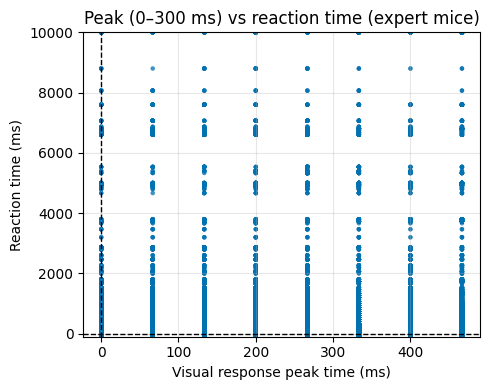

In [48]:
res = scatter_vis_peak_vs_rt_expert(
    agg_data=agg_data,
    mouse_ids=mouse_ids,
    unique_predictors=unique_predictors,
    pred='left_vis_stimOn_times',
    p_thresh=0.05,
    psth_start=psth_time_start,
    psth_end=psth_time_end,
    peak_window=(0.0, 0.5),
    min_lastday_vis_perf=None,  # set None to include all mice
    color='#0072B2',
    s=10
)

=== RT vs visual response peak latency (expert sessions) ===
Pearson r = 0.037, p = 2.77e-55, n = 178177
Spearman ρ = 0.052, p = 7.35e-107, n = 178177
Linear regression slope = 0.0572 ms/ms, p = 2.77e-55


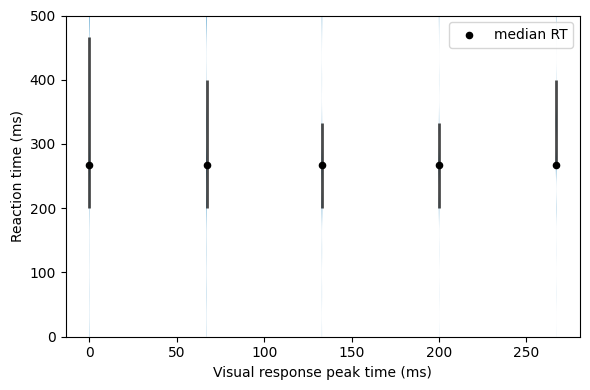

In [42]:
fig = plot_violin_rt_by_peak_latency(
    res['peak_times_s'],
    res['reaction_times_s'],
    max_rt_ms=500,
    min_rt_ms=0,
    color='#0072B2'
)

In [8]:
fig.savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig4', "rt_by_peak_latency.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

In [112]:
np.array(agg_data['AE_L2']['20250821_valvesilent_punishsilent']['arm1']['table_for_img']['firstMovement_times'])

array([  105.,   182.,   266.,   364.,   448.,   610.,   705.,   819.,
         940.,  1016.,    nan,  1204.,  1303.,  1394.,    nan,  1556.,
          nan,  1697.,  1778.,  1909.,  1977.,  2051.,  2167.,  2308.,
        2437.,  2537.,  2654.,  2776.,  2855.,  3040.,  3115.,  3211.,
        3349.,    nan,  3516.,  3626.,  3735.,    nan,  3893.,  3997.,
        4112.,    nan,  4319.,  4403.,  4520.,  4620.,  4707.,  4792.,
        4862.,  4947.,  5052.,  5129.,  5250.,  5353.,  5433.,    nan,
        5605.,  5735.,  5850.,  5995.,  6066.,  6151.,    nan,  6310.,
        6426.,  6518.,    nan,  6715.,  6790.,  6884.,  6947.,  7064.,
          nan,  7221.,  7321.,  7396.,    nan,  7571.,  7646.,  7722.,
        7814.,  7914.,  8050.,  8133.,    nan,  8341.,  8415.,    nan,
        8591.,    nan,  8759.,    nan,  8988.,  9076.,    nan,  9278.,
        9373.,  9486.,  9560.,  9654.,  9736.,  9862.,  9951., 10018.,
       10135., 10251., 10318., 10423.,    nan, 10599., 10719., 10804.,
      

In [16]:
left_vis_stimOn_beta, left_vis_stimOn_pval, left_vis_stimOn_r2, beta_info = get_agg_data_beta(agg_data=agg_data, mouse_ids = mouse_ids, unique_predictors = unique_predictors, column_name='left_vis_stimOn_times')
right_vis_stimOn_beta, right_vis_stimOn_pval, right_vis_stimOn_r2, beta_info = get_agg_data_beta(agg_data=agg_data, mouse_ids = mouse_ids, unique_predictors = unique_predictors, column_name='right_vis_stimOn_times')

#left_aud_stimOn_beta, left_aud_stimOn_pval, left_aud_stimOn_r2, beta_info = get_agg_data_beta(agg_data=agg_data, mouse_ids = mouse_ids, unique_predictors = unique_predictors, column_name='left_aud_stimOn_times')

In [17]:
psth_timepoint = np.linspace(psth_time_start*1000,psth_time_end*1000,agg_data[mouse_ids[0]]['20250612']['arm1']['stat'][0]['left_vis_stimOn_times_psth'].shape[1])

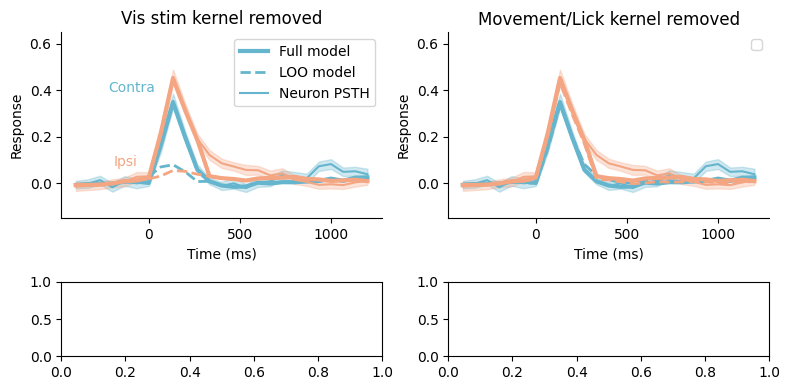

In [37]:
fig, axes = plt.subplots(2, 2, gridspec_kw={'height_ratios': [5, 2]}, figsize=(8,4))
left_color = '#64B5CD'
right_color = '#F4A582'
pred1 = 'left_vis_stimOn_times'
pred2 = 'right_vis_stimOn_times'
sorted_indices = np.argsort(right_vis_stimOn_r2)[::-1]
id = sorted_indices[0]
#print((left_vis_stimOn_r2)[id])
m = beta_info['mouse'][id]
d = beta_info['date'][id]
a = beta_info['arm'][id]
i = beta_info['neuron_idx'][id]
neuron = agg_data[m][d][a]['stat'][i]
dm = agg_data[m][d][a]['design_matrix']
tf = agg_data[m][d][a]['table_for_img']
# psth1 = vis_left_choice_psth_raw[id]
# psth2 = vis_right_choice_psth_raw[id]
plot_loo_reconstruction(neuron, dm, tf, pred=pred1, full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[0,0], color = left_color)

plot_loo_reconstruction(neuron, dm, tf, pred=pred2, full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[0,0], color = right_color, label = False)

plot_loo_reconstruction(neuron, dm, tf, pred=pred1, loo_pred=['face', 'body', 'lick', 'vel'], full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[0,1], color = left_color)

plot_loo_reconstruction(neuron, dm, tf, pred=pred2, loo_pred=['face', 'body', 'lick', 'vel'], full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[0,1], color = right_color)

axes[0,1].legend([])
axes[0,0].legend(loc='upper right')
axes[0,0].legend()
axes[0,0].text(0.22, 0.7, 'Contra', ha='center', va='center', transform=axes[0,0].transAxes, color = left_color)
axes[0,0].text(0.2, 0.3, 'Ipsi', ha='center', va='center', transform=axes[0,0].transAxes, color = right_color)
axes[0,0].set_title('Vis stim kernel removed')
axes[0,1].set_title('Movement/Lick kernel removed')
axes[0,0].set_ylim(-0.15, 0.65)
axes[0,1].set_ylim(-0.15, 0.65)
# lick = agg_data[m][d]
# lick = agg_data[m][d]['lick']
# tf_v = agg_data[m][d]['table_for_video']
# v_vis_reward_frame_idx = find_frame_indices(tf_v[tf_v['modality']==0], 60.4, (psth_time_start, psth_time_end), 'reward_consume_times').astype(int)
# v_aud_reward_frame_idx = find_frame_indices(tf_v[tf_v['modality']==1], 60.4, (psth_time_start, psth_time_end), 'reward_consume_times').astype(int)
# vis_reward_lick = get_trial_PSTH(np.expand_dims(lick[:,0], axis=0), v_vis_reward_frame_idx, zscore=True).squeeze()
# aud_reward_lick = get_trial_PSTH(np.expand_dims(lick[:,0], axis=0), v_aud_reward_frame_idx, zscore=True).squeeze()
# lick_timepoint = np.linspace(psth_time_start*1000,psth_time_end*1000,vis_reward_lick.shape[1])
# plot_with_error_shading(vis_reward_lick, time_points=lick_timepoint, color=vis_color, ax=axes[1,0])
# plot_with_error_shading(aud_reward_lick, time_points=lick_timepoint, color=aud_color, ax=axes[1,0])
# axes[1,0].axvline(x=0, color='black', linestyle='--')
# axes[1,0].set_xlabel('Time (ms)')
# axes[1,0].set_ylabel('lick') 
# axes[1,0].xaxis.set_visible(False) 
plt.tight_layout()
plt.show()

In [38]:
fig.savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig4', "single_neuron_vis_loo_example1.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

In [22]:
def _get_unique_pred_idx(unique_predictors, pred):
    """Return index of pred in unique_predictors."""
    up = np.asarray(unique_predictors)
    try:
        return int(np.where(up == pred)[0][0])
    except Exception:
        raise ValueError(f"Predictor '{pred}' not found in unique_predictors.")


def collect_uev_two_predictors(
    agg_data,
    mouse_ids,
    unique_predictors,
    pred1,
    pred2,
    filter_pred,
    alpha=0.05,
    arms=('arm1', 'arm2')
):
    """
    Collect unique explained variance (UEV) for two predictors across neurons,
    restricted to neurons that are significantly tuned to filter_pred
    (bootstrap_p_value[filter_pred] < alpha).
    """
    idx1 = _get_unique_pred_idx(unique_predictors, pred1)
    idx2 = _get_unique_pred_idx(unique_predictors, pred2)
    idx_filter = _get_unique_pred_idx(unique_predictors, filter_pred)

    uev1_list = []
    uev2_list = []

    for mouse in mouse_ids:
        mouse_data = agg_data.get(mouse, {})
        for date, sess in mouse_data.items():
            if date == 'training':
                continue

            for arm in arms:
                if arm not in sess:
                    continue
                stats = sess[arm].get('stat', None)
                if stats is None:
                    continue

                # stats is an array of neuron dicts
                for neuron in stats:
                    pvals = neuron['bootstrap_p_value']
                    uevs = neuron['unique_explained_variance']

                    # skip if nan or missing
                    p_filter = pvals[idx_filter]
                    if np.isnan(p_filter):
                        continue

                    if p_filter < alpha:
                        uev1_list.append(uevs[idx1])
                        uev2_list.append(uevs[idx2])

    return np.array(uev1_list), np.array(uev2_list)


def plot_uev_distribution_two_predictors(
    agg_data,
    mouse_ids,
    unique_predictors,
    pred1,
    pred2,
    filter_pred,
    alpha=0.05,
    arms=('arm1', 'arm2'),
    bins=30,
    ax=None
):
    """
    Plot distributions of unique explained variance for pred1 and pred2 across neurons
    that are significantly tuned to filter_pred (bootstrap_p_value < alpha).
    Returns fig, ax, uev1, uev2.
    """
    uev1, uev2 = collect_uev_two_predictors(
        agg_data=agg_data,
        mouse_ids=mouse_ids,
        unique_predictors=unique_predictors,
        pred1=pred1,
        pred2=pred2,
        filter_pred=filter_pred,
        alpha=alpha,
        arms=arms
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    else:
        fig = ax.figure

    # Overlaid histograms
    ax.hist(uev1, bins=bins, alpha=0.5, label=pred1)
    ax.hist(uev2, bins=bins, alpha=0.5, label=pred2)

    ax.set_xlabel('Unique explained variance (CV $R^2$)')
    ax.set_ylabel('Neuron count')
    ax.set_title(
        f'UEV distributions: {pred1} vs {pred2}\n'
        f'(neurons sig for {filter_pred}, α={alpha})'
    )
    ax.legend(frameon=False)

    # Optional: Arial + bigger ticks if you like that style
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontname('Arial')
        lbl.set_fontsize(10)

    fig.tight_layout()
    return fig, ax, uev1, uev2

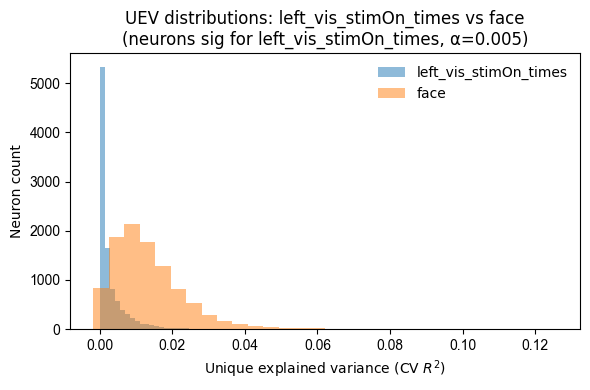

In [30]:
fig, ax, u1, u2 = plot_uev_distribution_two_predictors(
    agg_data=agg_data,
    mouse_ids=mouse_ids,
    unique_predictors=unique_predictors,
    pred1='left_vis_stimOn_times',
    pred2='face',
    filter_pred='left_vis_stimOn_times',
    alpha=0.005
)

In [11]:
def compute_group_effect_around_event_for_neuron(
    neuron,
    design_matrix,
    table_for_img,
    full_predictors,
    align_pred,          # event to align PSTH to, e.g. 'left_vis_stimOn_times'
    loo_group_preds,     # list of predictors to "remove" for this group
    frame_rate,          # e.g. 15
    psth_time_start,     # e.g. -0.4
    psth_time_end,       # e.g.  1.0
    resp_window=(0.0, 0.3),  # window over which to measure effect
    bsl_window=(-0.4, 0.0),  # baseline window
    exact_match=False,
    normalize=False
):
    """
    Return a scalar effect size for a predictor group, based on how much
    removing that group changes the model PSTH around an event.
    """
    # full vs LOO prediction in continuous time
    
    
    

    y_full, y_loo = loo_reconstruct_activity(
        neuron,
        design_matrix,
        loo_group_preds,
        full_predictors=full_predictors,
        exact_match=exact_match
    )

    # prepend zeros before imaging start, like in your plotting function
    pad = int(table_for_img['ruleCue_times'][0])
    y_full = np.concatenate([np.zeros(pad), y_full])
    y_loo  = np.concatenate([np.zeros(pad), y_loo])

    # frame indices for PSTH around the align_pred event
    if align_pred == 'left_choice_times':
        psth_frame_idx = np.concatenate(
            [
                find_frame_indices(table_for_img, frame_rate, (psth_time_start, psth_time_end), 'aud_left_choice_times').astype(int),
                find_frame_indices(table_for_img, frame_rate, (psth_time_start, psth_time_end), 'vis_left_choice_times').astype(int)
            ],
            axis=0
        )
    elif align_pred == 'right_choice_times':
        psth_frame_idx = np.concatenate(
            [
                find_frame_indices(table_for_img, frame_rate, (psth_time_start, psth_time_end), 'aud_right_choice_times').astype(int),
                find_frame_indices(table_for_img, frame_rate, (psth_time_start, psth_time_end), 'vis_right_choice_times').astype(int)
            ],
            axis=0
        )
    else:
        psth_frame_idx = find_frame_indices(table_for_img, frame_rate, (psth_time_start, psth_time_end), align_pred).astype(int)
    

    # PSTHs: shape (n_trials, T)
    full_psth = np.squeeze(get_trial_PSTH(
        y_full.reshape(1, -1),
        psth_frame_idx,
        zscore=False
    ))
    loo_psth = np.squeeze(get_trial_PSTH(
        y_loo.reshape(1, -1),
        psth_frame_idx,
        zscore=False
    ))

    # time axis for PSTH
    T = full_psth.shape[-1]
    t = np.linspace(psth_time_start, psth_time_end, T)

    # baseline subtract using bsl_window (same for full & LOO)
    # get indices for baseline
    b0, b1 = bsl_window
    bmask = (t >= b0) & (t <= b1)
    if not np.any(bmask):
        raise ValueError("Baseline window has no samples in PSTH.")

    full_bsl_mean = np.nanmean(full_psth[:, bmask].ravel())
    loo_bsl_mean  = np.nanmean(loo_psth[:,  bmask].ravel())

    full_mean = np.nanmean(full_psth, axis=0) - full_bsl_mean
    loo_mean  = np.nanmean(loo_psth,  axis=0) - loo_bsl_mean

    # response window
    w0, w1 = resp_window
    wmask = (t >= w0) & (t <= w1)
    if not np.any(wmask):
        raise ValueError("Response window has no samples in PSTH.")

    diff = full_mean[wmask] - loo_mean[wmask]
    if normalize:
        # effect size: mean squared change in PSTH in response window
        effect = np.nanmean(np.abs(diff)) / np.max(np.abs(full_mean[wmask]))
    else:
        effect = np.nanmean(np.abs(diff))
    # (optional) also return some convenience stuff if needed
    return effect, t, full_mean, loo_mean

In [16]:
def compute_vis_vs_move_effects_all_neurons(
    agg_data,
    mouse_ids,
    unique_predictors,
    filter_pred,               # e.g. 'left_vis_stimOn_times'
    full_predictors,      # string key in neuron or per-session var; see below
    align_pred,                # same as filter_pred usually
    vis_group_preds,           # list of predictor names to remove for "vis" group
    mlw_group_preds,           # list for move/lick/wheel group
    alpha=0.05,
    arms=('arm1', 'arm2'),
    frame_rate=15.0,
    psth_time_start=-0.4,
    psth_time_end=1.2,
    resp_window=(0.0, 0.3),
    bsl_window=(-0.4, 0.0),
    normalize=False
):
    """
    For each neuron that is significant for `filter_pred`, compute:
        E_vis  = effect of removing vis kernels
        E_mlw  = effect of removing move/lick/wheel kernels
    Returns a DataFrame with one row per neuron.
    """
    # map unique predictor name -> index in bootstrap p / UEV arrays
    up = np.asarray(unique_predictors)
    try:
        idx_filter = int(np.where(up == filter_pred)[0][0])
    except Exception:
        raise ValueError(f"Predictor '{filter_pred}' not found in unique_predictors.")

    sig_rows = []
    non_sig_rows = []
    for mouse in mouse_ids:
        md = agg_data.get(mouse, {})
        for date, sess in md.items():
            print(mouse, date)
            if date == 'training':
                continue

            for arm in arms:
                if arm not in sess:
                    continue
                stats = sess[arm].get('stat', None)
                if stats is None:
                    continue

                # session-specific objects
                table_for_img = sess[arm]['table_for_img']
                X = sess[arm]['design_matrix']


                for ni, neuron in enumerate(stats):
                    pvals = np.asarray(neuron['bootstrap_p_value'])
                    if idx_filter >= pvals.size:
                        continue
                    p_filter = pvals[idx_filter]
                    if np.isnan(p_filter):
                        continue  # not vis-stim significant

                    # ---- vis kernel effect ----
                    E_vis, _, _, _ = compute_group_effect_around_event_for_neuron(
                        neuron=neuron,
                        design_matrix=X,
                        table_for_img=table_for_img,
                        full_predictors=full_predictors,
                        align_pred=align_pred,
                        loo_group_preds=vis_group_preds,
                        frame_rate=frame_rate,
                        psth_time_start=psth_time_start,
                        psth_time_end=psth_time_end,
                        resp_window=resp_window,
                        bsl_window=bsl_window,
                        exact_match=False,
                        normalize=normalize
                    )

                    # ---- movement/lick/wheel effect ----
                    E_mlw, _, _, _ = compute_group_effect_around_event_for_neuron(
                        neuron=neuron,
                        design_matrix=X,
                        table_for_img=table_for_img,
                        full_predictors=full_predictors,
                        align_pred=align_pred,
                        loo_group_preds=mlw_group_preds,
                        frame_rate=frame_rate,
                        psth_time_start=psth_time_start,
                        psth_time_end=psth_time_end,
                        resp_window=resp_window,
                        bsl_window=bsl_window,
                        exact_match=False,
                        normalize=normalize
                    )
                    if p_filter < alpha:
                        sig_rows.append({
                            'mouse': mouse,
                            'date': date,
                            'arm': arm,
                            'neuron_idx': ni,
                            'E_vis': E_vis,
                            'E_mlw': E_mlw,
                            'ratio_mlw_over_vis': E_mlw / E_vis if E_vis > 0 else np.nan
                        })
                    else:
                        non_sig_rows.append({
                            'mouse': mouse,
                            'date': date,
                            'arm': arm,
                            'neuron_idx': ni,
                            'E_vis': E_vis,
                            'E_mlw': E_mlw,
                            'ratio_mlw_over_vis': E_mlw / E_vis if E_vis > 0 else np.nan
                        })

    return pd.DataFrame(sig_rows), pd.DataFrame(non_sig_rows)

In [26]:
vis_group = ['left_vis_stimOn_times']  # or whatever exact names
mlw_group = ['vel', 'lick', 'body', 'face']  # adjust to match your predictor names

df_sig, df_non_sig = compute_vis_vs_move_effects_all_neurons(
    agg_data=agg_data,
    mouse_ids=mouse_ids,
    unique_predictors=unique_predictors,
    filter_pred='left_vis_stimOn_times',  # vis-sensitive neurons
    full_predictors=predictors,    # see note inside function
    align_pred='left_vis_stimOn_times',
    vis_group_preds=vis_group,
    mlw_group_preds=mlw_group,
    alpha=0.01,
    frame_rate=15.0,
    psth_time_start=-0.4,
    psth_time_end=1.0,
    resp_window=(0.0, 0.2),
    bsl_window=(-0.4, 0.0),
    normalize=True
)



AE_L2 20250612
AE_L2 20250624_valvesilent
AE_L2 20250701_valvesilent
AE_L2 20250708_valvesilent
AE_L2 20250715_valvesilent
AE_L2 20250729_valvesilent
AE_L2 20250814_valvesilent_punishsilent
AE_L2 20250821_valvesilent_punishsilent
AE_L2 training
AE_L3 20250612
AE_L3 20250617_valvesilent
AE_L3 20250624_valvesilent
AE_L3 20250701_valvesilent
AE_L3 20250708_valvesilent
AE_L3 20250722_valvesilent
AE_L3 20250729_valvesilent
AE_L3 20250812_valvesilent
AE_L3 20250820_valvesilent
AE_L3 20250828_valvesilent
AE_L3 20250903_valvesilent
AE_L3 20250909_valvesilent_punishsilent
AE_L3 training
AF_R3 20250528
AF_R3 20250604
AF_R3 20250611_valvesilent
AF_R3 20250618_valvesilent
AF_R3 20250625_valvesilent
AF_R3 20250702_valvesilent
AF_R3 20250710_valvesilent
AF_R3 20250716_valvesilent
AF_R3 20250723_valvesilent
AF_R3 20250730_valvesilent
AF_R3 20250814_valvesilent
AF_R3 20250821_valvesilent
AF_R3 20250828_valvesilent
AF_R3 20250904_valvesilent_punishsilent
AF_R3 20250909_valvesilent_punishsilent
AF_R3 tr

In [27]:
def add_density_contours(ax, x, y, bins=80, levels=(0.2, 0.4, 0.6, 0.8),
                         xrange=(0, 1), yrange=(0, 1), **contour_kwargs):
    """
    Add 2D-density contours to an existing scatter plot.

    Parameters
    ----------
    ax : matplotlib Axes
    x, y : 1D arrays
        Data points.
    bins : int
        Number of bins per axis for the 2D histogram.
    levels : tuple
        Contour levels in *fraction of max density* (0–1).
    xrange, yrange : (min, max)
        Limits for the histogram (match your axis limits).
    contour_kwargs :
        Passed to ax.contour (e.g. colors, linewidths).
    """
    # 2D histogram over fixed range
    H, xedges, yedges = np.histogram2d(
        x, y, bins=bins,
        range=[xrange, yrange]
    )

    # bin centers
    Xc = 0.5 * (xedges[:-1] + xedges[1:])
    Yc = 0.5 * (yedges[:-1] + yedges[1:])
    X, Y = np.meshgrid(Xc, Yc)

    # normalize and convert fractional levels -> actual counts
    Hnorm = H / H.max() if H.max() > 0 else H
    level_vals = [lv * H.max() for lv in levels]

    # plot contours
    ax.contour(
        X, Y, H.T,
        levels=level_vals,
        **contour_kwargs
    )

(0.0, 1.0)

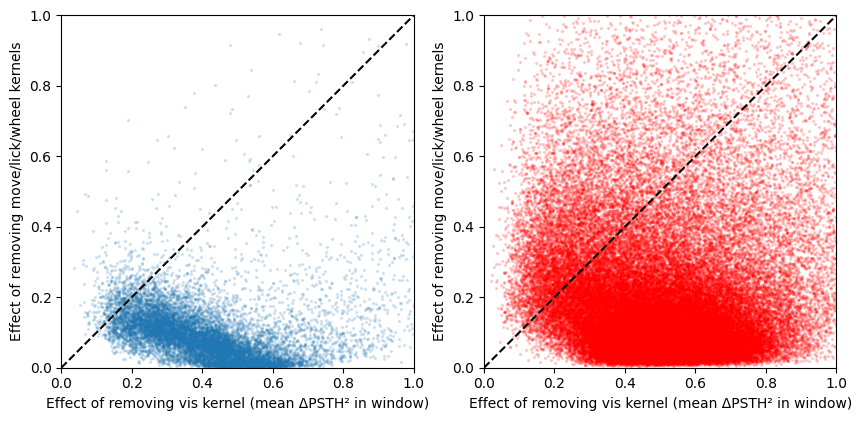

In [29]:
fig, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].scatter(df_sig['E_vis'], df_sig['E_mlw'], alpha=0.15, s=2, rasterized=True)
# add_density_contours(
#     axes[0],
#     df_sig['E_vis'].values,
#     df_sig['E_mlw'].values,
#     bins=60,
#     levels=(0.2, 0.4, 0.6, 0.8),
#     xrange=(0, 1),
#     yrange=(0, 1),
#     colors='k',
#     linewidths=1,
# )
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlabel('Effect of removing vis kernel (mean ΔPSTH² in window)')
axes[0].set_ylabel('Effect of removing move/lick/wheel kernels')
axes[0].set_aspect('equal', 'box')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# NON-SIG
axes[1].scatter(df_non_sig['E_vis'], df_non_sig['E_mlw'], alpha=0.15, s=2,
                color='red', rasterized=True)
# add_density_contours(
#     axes[1],
#     df_non_sig['E_vis'].values,
#     df_non_sig['E_mlw'].values,
#     bins=40,
#     levels=(0.2, 0.4, 0.6, 0.8),
#     xrange=(0, 1),
#     yrange=(0, 1),
#     colors='k',
#     linewidths=1,
# )
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('Effect of removing vis kernel (mean ΔPSTH² in window)')
axes[1].set_ylabel('Effect of removing move/lick/wheel kernels')
axes[1].set_aspect('equal', 'box')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

In [30]:
df_sig.to_pickle(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\scatter_norm_remove_contra_vis_vs_mlw_sig_neurons.pkl')
df_non_sig.to_pickle(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\scatter_norm_remove_contra_vis_vs_mlw_non_sig_neurons.pkl')

In [31]:
fig.savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig5', "scatter_norm_remove_contra_vis_vs_mlw.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

Scatter plot

In [ ]:
old_mice = ['A_R2', 'A_R3', 'R_L2', 'J_L2', 'O_R2']

-1.554312234475219e-16

In [194]:
def get_earliest_dates(dates):
    """
    Given a list of date strings (e.g. ['20240715', '20240715_valvesilent', '20240802_valvesilent_punishsilent']),
    returns:
        - earliest regular imaging date (YYYYMMDD only)
        - earliest valvesilent imaging date (contains 'valvesilent')
    Both returned as strings, or None if not found.
    """
    # ensure unique & sorted
    if not dates:
        return None, None

    # split into two categories
    regular = [d for d in dates if re.fullmatch(r"\d{8}", d)]
    valvesilent = [d for d in dates if "valvesilent" in d.lower()]

    def _to_intsafe(d):
        try:
            return int(d[:8])
        except Exception:
            return np.inf

    earliest_regular = min(regular, key=_to_intsafe) if regular else None
    earliest_valvesilent = min(valvesilent, key=_to_intsafe) if valvesilent else None

    return earliest_regular, earliest_valvesilent

In [168]:
earliest_regular, earliest_valvesilent = get_earliest_dates(list(agg_data['AF_R3'].keys()))
print(earliest_regular, earliest_valvesilent)

20250528 20250611_valvesilent


In [194]:
unique_predictors.index(pred)

10

In [18]:
valvesilent_mice = ['AE_L2', 'AE_L3', 'AF_L3', 'AF_R3', 'AF_L2', 'AB_R2']

In [19]:
def plot_reward_psth_first_naive_vs_valvesilent(
    agg_data,
    mouse_ids,
    psth_time_window=(-0.4, 1.2),
    arms=('arm1', 'arm2'),
    sort_window=(0.0, 0.4),     # for sorting by magnitude
    vmin=-3, vmax=3,
    cmap='viridis',
    roi_masks_full=None,        # dict: roi_name -> 2D bool/0-1 mask (atlas space)
    roi_order=None,
    frac_thresh=0.5
):
    """
    For each mouse, plot reward PSTH heatmaps for:
      - first session whose name is digits only (naive-ish)
      - first session whose name contains 'valvesilent'

    Reward PSTH per neuron = average of:
        neuron['vis_reward_times_psth'] and neuron['aud_reward_times_psth']

    Layout:
      - Figure with n_mouse rows, 2 columns
      - Col 1: first digit-only date
      - Col 2: first 'valvesilent' date
      - Each axis: neurons grouped by ROI, sorted by amplitude in sort_window.

    Parameters
    ----------
    agg_data : dict
        Your big nested dict: agg_data[mouse][date][arm]['stat'] etc.
    mouse_ids : list of str
    psth_time_window : (float, float)
        Time axis range for plotting. Must be consistent with how PSTHs were built.
    arms : tuple(str)
        Arms to include, e.g., ('arm1', 'arm2').
    sort_window : (float, float)
        Time window (s) over which to compute magnitude for sorting.
    vmin, vmax : float
        Color limits for imshow.
    cmap : str
    roi_masks_full : dict or None
        roi_name -> 2D mask in atlas coordinates.
    roi_order : list or None
        Order of ROIs from top to bottom. Defaults to list(roi_masks_full.keys()).
    frac_thresh : float
        Minimal fraction of neuron pixels in ROI to assign it.

    Returns
    -------
    fig, axes : matplotlib Figure and Axes array
    """

    use_roi = roi_masks_full is not None
    if use_roi:
        roi_masks_bool = {r: np.asarray(m, dtype=bool) for r, m in roi_masks_full.items()}
        if roi_order is None:
            roi_order = list(roi_masks_bool.keys())

    n_mice = len(mouse_ids)
    fig, axes = plt.subplots(
        n_mice, 2, figsize=(8, 4 * n_mice),
        squeeze=False
    )

    def _build_session_reward_psth(mouse_data, date):
        """
        For a single mouse and date, build:
          - stacked reward PSTH matrix (neurons x T)
          - time axis t
          - roi_blocks_info for drawing separators
        Returns (psths_sorted_all, t, roi_blocks_info) or (None, None, None) if no data.
        """
        if not any(arm in mouse_data[date] for arm in arms):
            return None, None, None

        if use_roi:
            roi_to_psths = {roi: [] for roi in roi_order}
        else:
            all_means = []

        for arm in arms:
            if arm not in mouse_data[date]:
                continue

            stats = mouse_data[date][arm].get('stat', None)
            if stats is None:
                continue

            for neuron in stats:
                # Reward PSTHs must exist
                if ('vis_reward_times_psth' not in neuron) or ('aud_reward_times_psth' not in neuron):
                    continue

                vis_psth = np.asarray(neuron['vis_reward_times_psth'])
                aud_psth = np.asarray(neuron['aud_reward_times_psth'])

                # average vis & aud (handle 1D vs 2D)
                def _to_mean(p):
                    if p.ndim == 1:
                        return p
                    else:
                        return np.nanmean(p, axis=0)

                vis_mean = _to_mean(vis_psth)
                aud_mean = _to_mean(aud_psth)

                # ensure same length
                if vis_mean.shape[0] != aud_mean.shape[0]:
                    T = min(vis_mean.shape[0], aud_mean.shape[0])
                    vis_mean = vis_mean[:T]
                    aud_mean = aud_mean[:T]

                reward_mean = 0.5 * (vis_mean + aud_mean)  # (T,)

                if use_roi:
                    if 'xcoord_atlas' not in neuron or 'ycoord_atlas' not in neuron:
                        continue
                    x = np.asarray(neuron['xcoord_atlas'], dtype=int)
                    y = np.asarray(neuron['ycoord_atlas'], dtype=int)

                    best_roi = None
                    best_frac = 0.0
                    for roi_name, roi_mask in roi_masks_bool.items():
                        H, W = roi_mask.shape
                        ok = (x >= 0) & (x < W) & (y >= 0) & (y < H)
                        if not np.any(ok):
                            continue
                        xx = x[ok]
                        yy = y[ok]
                        n_pix_total = len(xx)
                        if n_pix_total == 0:
                            continue
                        n_pix_in_roi = np.count_nonzero(roi_mask[yy, xx])
                        frac_in_roi = n_pix_in_roi / n_pix_total
                        if frac_in_roi > best_frac:
                            best_frac = frac_in_roi
                            best_roi = roi_name

                    if best_roi is not None and best_frac > frac_thresh:
                        roi_to_psths[best_roi].append(reward_mean)
                else:
                    all_means.append(reward_mean)

        if use_roi:
            if not any(len(v) > 0 for v in roi_to_psths.values()):
                return None, None, None

            # infer T and time axis
            sample_roi = next(r for r in roi_order if len(roi_to_psths[r]) > 0)
            T = len(roi_to_psths[sample_roi][0])
            t = np.linspace(psth_time_window[0], psth_time_window[1], T)

            psth_blocks = []
            roi_block_sizes = []
            roi_block_names = []

            t_start, t_end = sort_window
            sort_mask = (t >= t_start) & (t <= t_end)
            if not np.any(sort_mask):
                sort_mask = np.ones_like(t, dtype=bool)

            t_sort = t[sort_mask]

            for roi_name in roi_order:
                if len(roi_to_psths[roi_name]) == 0:
                    continue
                psths_roi = np.vstack(roi_to_psths[roi_name])  # (n_roi_neurons, T)

                psth_sort = psths_roi[:, sort_mask]
                mags = np.nanmax(np.abs(psth_sort), axis=1)
                sort_order = np.argsort(mags)  # smallest first (you can flip)

                psths_roi_sorted = psths_roi[sort_order]
                psth_blocks.append((roi_name, psths_roi_sorted))
                roi_block_sizes.append(psths_roi_sorted.shape[0])
                roi_block_names.append(roi_name)

            if len(psth_blocks) == 0:
                return None, None, None

            psths_sorted_all = np.vstack([blk for _, blk in psth_blocks])
            roi_cum_sizes = np.cumsum(roi_block_sizes)
            roi_blocks_info = {
                'names': roi_block_names,
                'sizes': roi_block_sizes,
                'cum_sizes': roi_cum_sizes
            }

        else:
            if not all_means:
                return None, None, None

            psths = np.vstack(all_means)
            T = psths.shape[1]
            t = np.linspace(psth_time_window[0], psth_time_window[1], T)

            t_start, t_end = sort_window
            sort_mask = (t >= t_start) & (t <= t_end)
            if not np.any(sort_mask):
                sort_mask = np.ones_like(t, dtype=bool)

            psth_sort = psths[:, sort_mask]
            mags = np.nanmax(np.abs(psth_sort), axis=1)
            sort_order = np.argsort(mags)
            psths_sorted_all = psths[sort_order]
            roi_blocks_info = None

        return psths_sorted_all, t, roi_blocks_info

    # --- Loop over mice and plot ---
    for mi, mouse in enumerate(mouse_ids):
        mouse_data = agg_data[mouse]
        dates = [d for d in mouse_data.keys() if d != 'training']
        dates = sorted(dates)

        # pick first digit-only session
        first_digit = None
        for d in dates:
            if d.isdigit():
                first_digit = d
                break

        # pick first valvesilent session
        first_valve = None
        for d in dates:
            if 'valvesilent' in d:
                first_valve = d
                break

        for ci, (date, label) in enumerate([(first_digit, 'first digit-only'),
                                            (first_valve, 'first valvesilent')]):
            ax = axes[mi, ci]

            if date is None:
                ax.set_visible(False)
                continue

            psths_sorted_all, t, roi_blocks_info = _build_session_reward_psth(mouse_data, date)
            if psths_sorted_all is None:
                ax.set_visible(False)
                continue

            n_rows = psths_sorted_all.shape[0]
            im = ax.imshow(
                psths_sorted_all,
                aspect='auto',
                extent=[psth_time_window[0], psth_time_window[1], 0, n_rows],
                cmap=cmap,
                vmin=vmin, vmax=vmax
            )
            ax.axvline(0, color='red', linestyle='--')

            # ROI separators
            if roi_blocks_info is not None:
                for ysep in roi_blocks_info['cum_sizes'][:-1]:
                    ax.axhline(y=n_rows - ysep, color='white', linestyle='-', linewidth=1.5)

            ax.set_title(f"{mouse} – {date} ({label})")
            ax.set_xlabel('Time (s)')
            ax.set_ylabel('Neurons')

            # Colorbar only for the rightmost column in each row? Or global?
            # For simplicity, global colorbar later.

    # Global colorbar (based on last visible imshow)
    # Find last visible axis with an image
    last_im = None
    for ax_row in axes:
        for ax in ax_row:
            if len(ax.images) > 0:
                last_im = ax.images[0]
    if last_im is not None:
        cbar = fig.colorbar(last_im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.01)
        cbar.set_label('Reward PSTH (z)')

    fig.tight_layout()
    return fig, axes

C:\Users\dirk\AppData\Local\Temp\ipykernel_27008\2794141574.py:276: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


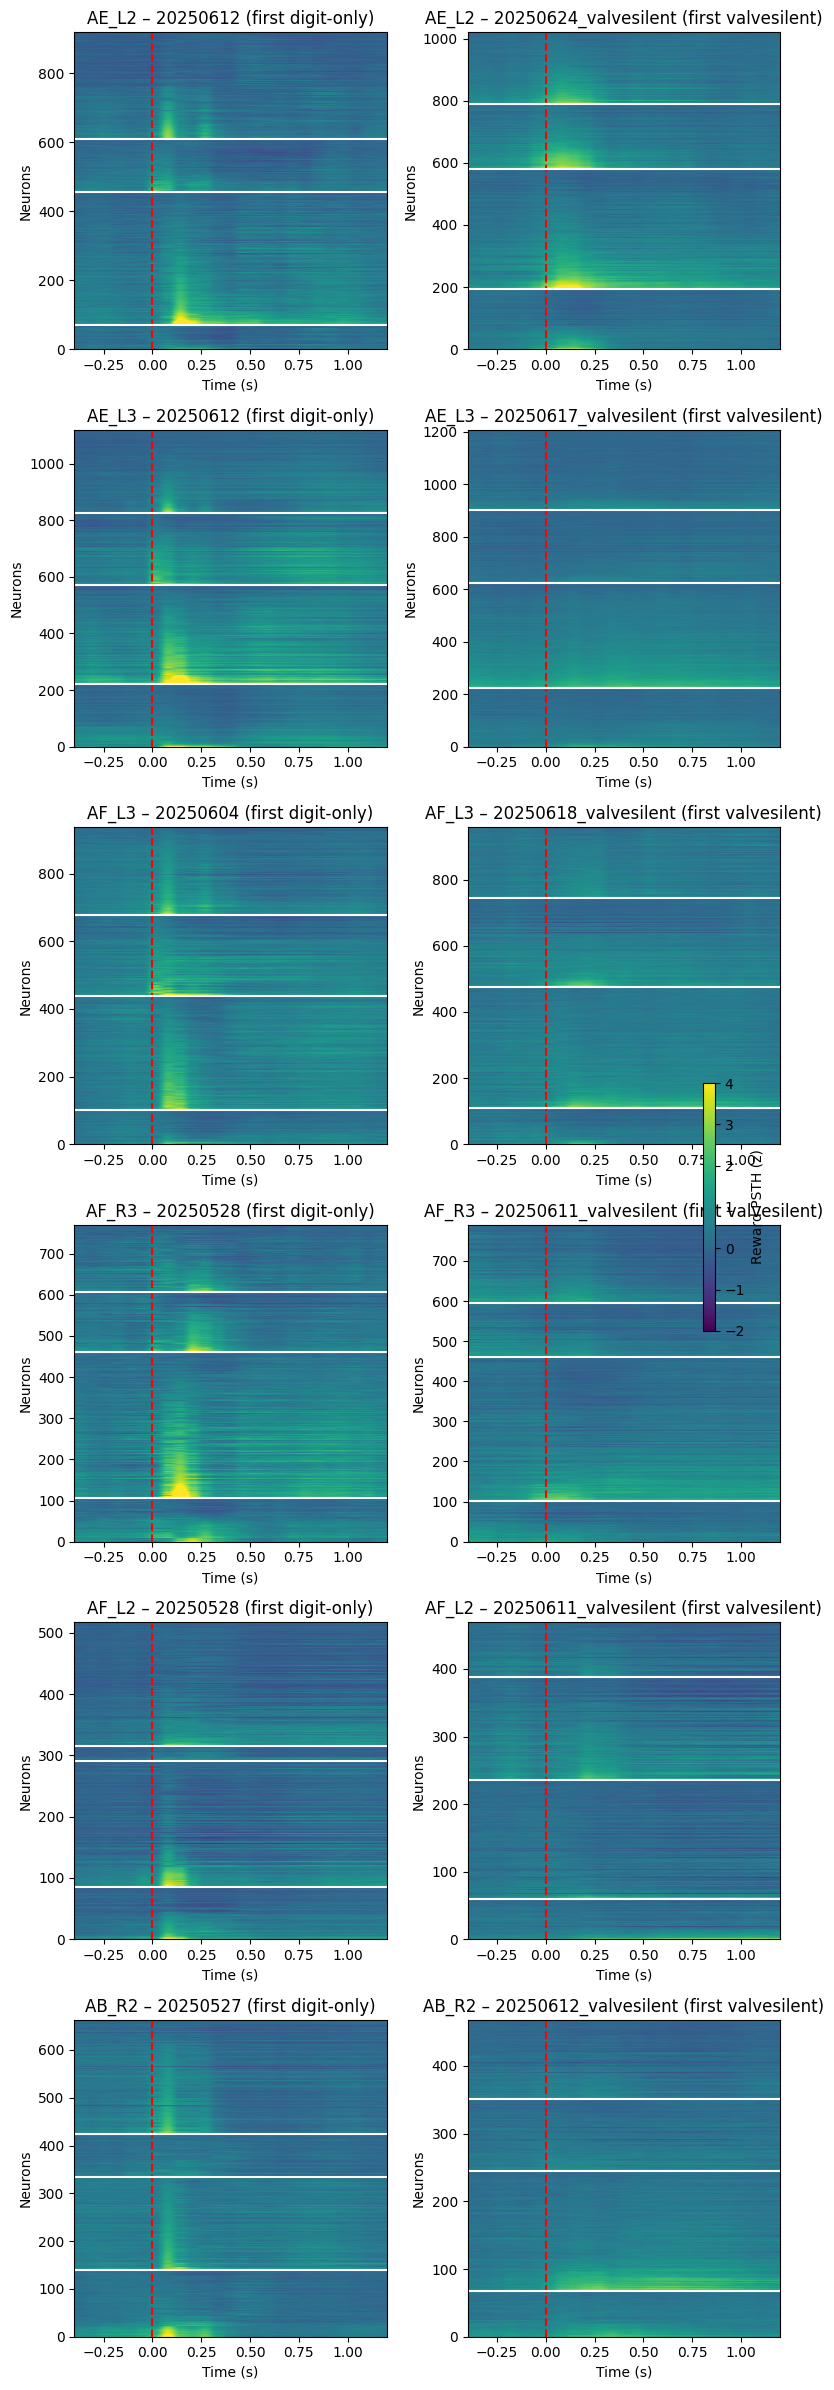

In [21]:
fig, axes = plot_reward_psth_first_naive_vs_valvesilent(
    agg_data=agg_data,
    mouse_ids=valvesilent_mice,
    psth_time_window=(-0.4, 1.2),
    arms=('arm1', 'arm2'),
    sort_window=(0.0, 0.5),
    vmin=-2, vmax=4,
    cmap='viridis',
    roi_masks_full=roi_masks_full,
    roi_order=['lob_V', 'lob_VI','simplex', 'crus_I'],  # or whatever you use
    frac_thresh=0.5
)

In [22]:
fig.savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig6', "valvesilent_effect_heatmap.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

In [29]:
# assuming you already have this somewhere


def plot_reward_region_avg_naive_vs_valvesilent(
    agg_data,
    mouse_ids,
    roi_masks_full,
    roi_order=None,
    psth_time_window=(-0.4, 1.2),
    bsl_window=(-0.4, 0.0),   # <-- baseline window in seconds
    arms=('arm1', 'arm2'),
    frac_thresh=0.5,
    resp_label=('digit day1', 'valvesilent day1')
):
    """
    For each mouse and ROI, plot baseline-corrected mean reward PSTH (with error shading) for:
      - first session with name all digits (e.g. '20250612')
      - first session whose name contains 'valvesilent' (e.g. '20250624_valvesilent')

    Reward PSTH per neuron = average of neuron['vis_reward_times_psth']
    and neuron['aud_reward_times_psth'], then baseline-subtracted using bsl_window.

    Layout:
      rows  = n_mouse
      cols  = n_roi
      each subplot = mouse × ROI, with two overlaid curves (digit-only vs valvesilent).
    """
    roi_masks_bool = {r: np.asarray(m, dtype=bool) for r, m in roi_masks_full.items()}
    if roi_order is None:
        roi_order = list(roi_masks_bool.keys())
    ROI_COLOR_MAP = {
        'simplex': plt.cm.Reds,
        'crus_I': plt.cm.Blues,
        'lob_V': plt.cm.Purples,
        'lob_VI': plt.cm.Oranges,
    }
    n_mice = len(mouse_ids)
    n_rois = len(roi_order)

    fig, axes = plt.subplots(
        n_mice, n_rois,
        figsize=(4 * n_rois, 3 * n_mice),
        squeeze=False
    )

    def _assign_roi(neuron):
        """Assign neuron to ROI by highest frac_in_roi > frac_thresh."""
        if 'xcoord_atlas' not in neuron or 'ycoord_atlas' not in neuron:
            return None
        x = np.asarray(neuron['xcoord_atlas'], dtype=int)
        y = np.asarray(neuron['ycoord_atlas'], dtype=int)

        best_roi = None
        best_frac = 0.0
        for roi_name, roi_mask in roi_masks_bool.items():
            H, W = roi_mask.shape
            ok = (x >= 0) & (x < W) & (y >= 0) & (y < H)
            if not np.any(ok):
                continue
            xx = x[ok]
            yy = y[ok]
            n_pix_total = len(xx)
            if n_pix_total == 0:
                continue
            n_pix_in_roi = np.count_nonzero(roi_mask[yy, xx])
            frac_in_roi = n_pix_in_roi / n_pix_total
            if frac_in_roi > best_frac:
                best_frac = frac_in_roi
                best_roi = roi_name

        if best_roi is not None and best_frac > frac_thresh:
            return best_roi
        return None

    def _get_reward_mean(neuron):
        """
        Return 1D reward PSTH = 0.5*(mean(vis_reward) + mean(aud_reward))
        (no baseline correction here; we’ll do it later once we know t & bsl_window).
        """
        if ('vis_reward_times_psth' not in neuron) or ('aud_reward_times_psth' not in neuron):
            return None
        vis_psth = np.asarray(neuron['vis_reward_times_psth'])
        aud_psth = np.asarray(neuron['aud_reward_times_psth'])

        def _to_mean(p):
            if p.ndim == 1:
                return p
            else:
                return np.nanmean(p, axis=0)

        vis_mean = _to_mean(vis_psth)
        aud_mean = _to_mean(aud_psth)

        T = min(vis_mean.shape[0], aud_mean.shape[0])
        vis_mean = vis_mean[:T]
        aud_mean = aud_mean[:T]
        return 0.5 * (vis_mean + aud_mean)  # (T,)

    # --- loop over mice ---
    for mi, mouse in enumerate(mouse_ids):
        mouse_data = agg_data[mouse]
        dates = [d for d in mouse_data.keys() if d != 'training']
        dates = sorted(dates)

        # first pure-digit session
        first_digit = None
        for d in dates:
            if d.isdigit():
                first_digit = d
                break

        # first valvesilent session
        first_valve = None
        for d in dates:
            if 'valvesilent' in d:
                first_valve = d
                break

        # collect PSTHs per ROI, per condition
        roi_to_psths_digit = {roi: [] for roi in roi_order}
        roi_to_psths_valve = {roi: [] for roi in roi_order}

        def _accumulate_for_date(date, target_dict):
            if date is None or date not in mouse_data:
                return

            for arm in arms:
                if arm not in mouse_data[date]:
                    continue
                stats = mouse_data[date][arm].get('stat', None)
                if stats is None:
                    continue

                for neuron in stats:
                    reward_mean = _get_reward_mean(neuron)
                    if reward_mean is None:
                        continue
                    roi_name = _assign_roi(neuron)
                    if roi_name is None or roi_name not in target_dict:
                        continue
                    target_dict[roi_name].append(reward_mean)

        _accumulate_for_date(first_digit, roi_to_psths_digit)
        _accumulate_for_date(first_valve, roi_to_psths_valve)

        # for each ROI, plot in (mi, ri)
        for ri, roi_name in enumerate(roi_order):
            ax = axes[mi, ri]

            psths_digit = roi_to_psths_digit[roi_name]
            psths_valve = roi_to_psths_valve[roi_name]

            if not psths_digit and not psths_valve:
                ax.set_visible(False)
                continue

            # choose T (assume consistent across PSTHs for that ROI/condition)
            T = None
            if psths_digit:
                T = psths_digit[0].shape[0]
            elif psths_valve:
                T = psths_valve[0].shape[0]

            t = np.linspace(psth_time_window[0], psth_time_window[1], T)

            # baseline mask from bsl_window (e.g. (-0.4, 0.0))
            b0, b1 = bsl_window
            bmask = (t >= b0) & (t <= b1)
            if not np.any(bmask):
                raise ValueError(
                    f"No baseline samples in window {bsl_window} for PSTH time axis."
                )

            # ROI-specific color map and two shades
            cm = ROI_COLOR_MAP.get(roi_name, plt.cm.Greys)
            color_digit = cm(0.35)   # lighter
            color_valve = cm(0.75)   # darker

            # ---- digit-only condition ----
            if psths_digit:
                arr = np.vstack(psths_digit)   # (n_neurons, T)
                # baseline per neuron
                bsl = np.nanmean(arr[:, bmask], axis=1, keepdims=True)
                arr_bc = arr - bsl             # baseline-corrected
                mean = np.nanmean(arr_bc, axis=0)
                sem  = np.nanstd(arr_bc, axis=0) / np.sqrt(arr_bc.shape[0])

                ax.plot(t, mean, color=color_digit, linewidth=2,
                        label=resp_label[0])
                ax.fill_between(t, mean - sem, mean + sem,
                                color=color_digit, alpha=0.3)

            # ---- valvesilent condition ----
            if psths_valve:
                arr = np.vstack(psths_valve)
                bsl = np.nanmean(arr[:, bmask], axis=1, keepdims=True)
                arr_bc = arr - bsl
                mean = np.nanmean(arr_bc, axis=0)
                sem  = np.nanstd(arr_bc, axis=0) / np.sqrt(arr_bc.shape[0])

                ax.plot(t, mean, color=color_valve, linewidth=2,
                        label=resp_label[1])
                ax.fill_between(t, mean - sem, mean + sem,
                                color=color_valve, alpha=0.3)

            ax.axvline(0, color='k', linestyle='--', linewidth=1)

            if mi == 0:  # top row: ROI names as titles
                ax.set_title(roi_name)
            if ri == 0:  # first column: mouse labels on y-axis
                ax.set_ylabel(mouse)

            ax.set_xlabel('Time (s)')

            # only show legend once (top-left)
            if mi == 0 and ri == 0:
                ax.legend(frameon=False, fontsize=8)

    fig.tight_layout()
    return fig, axes

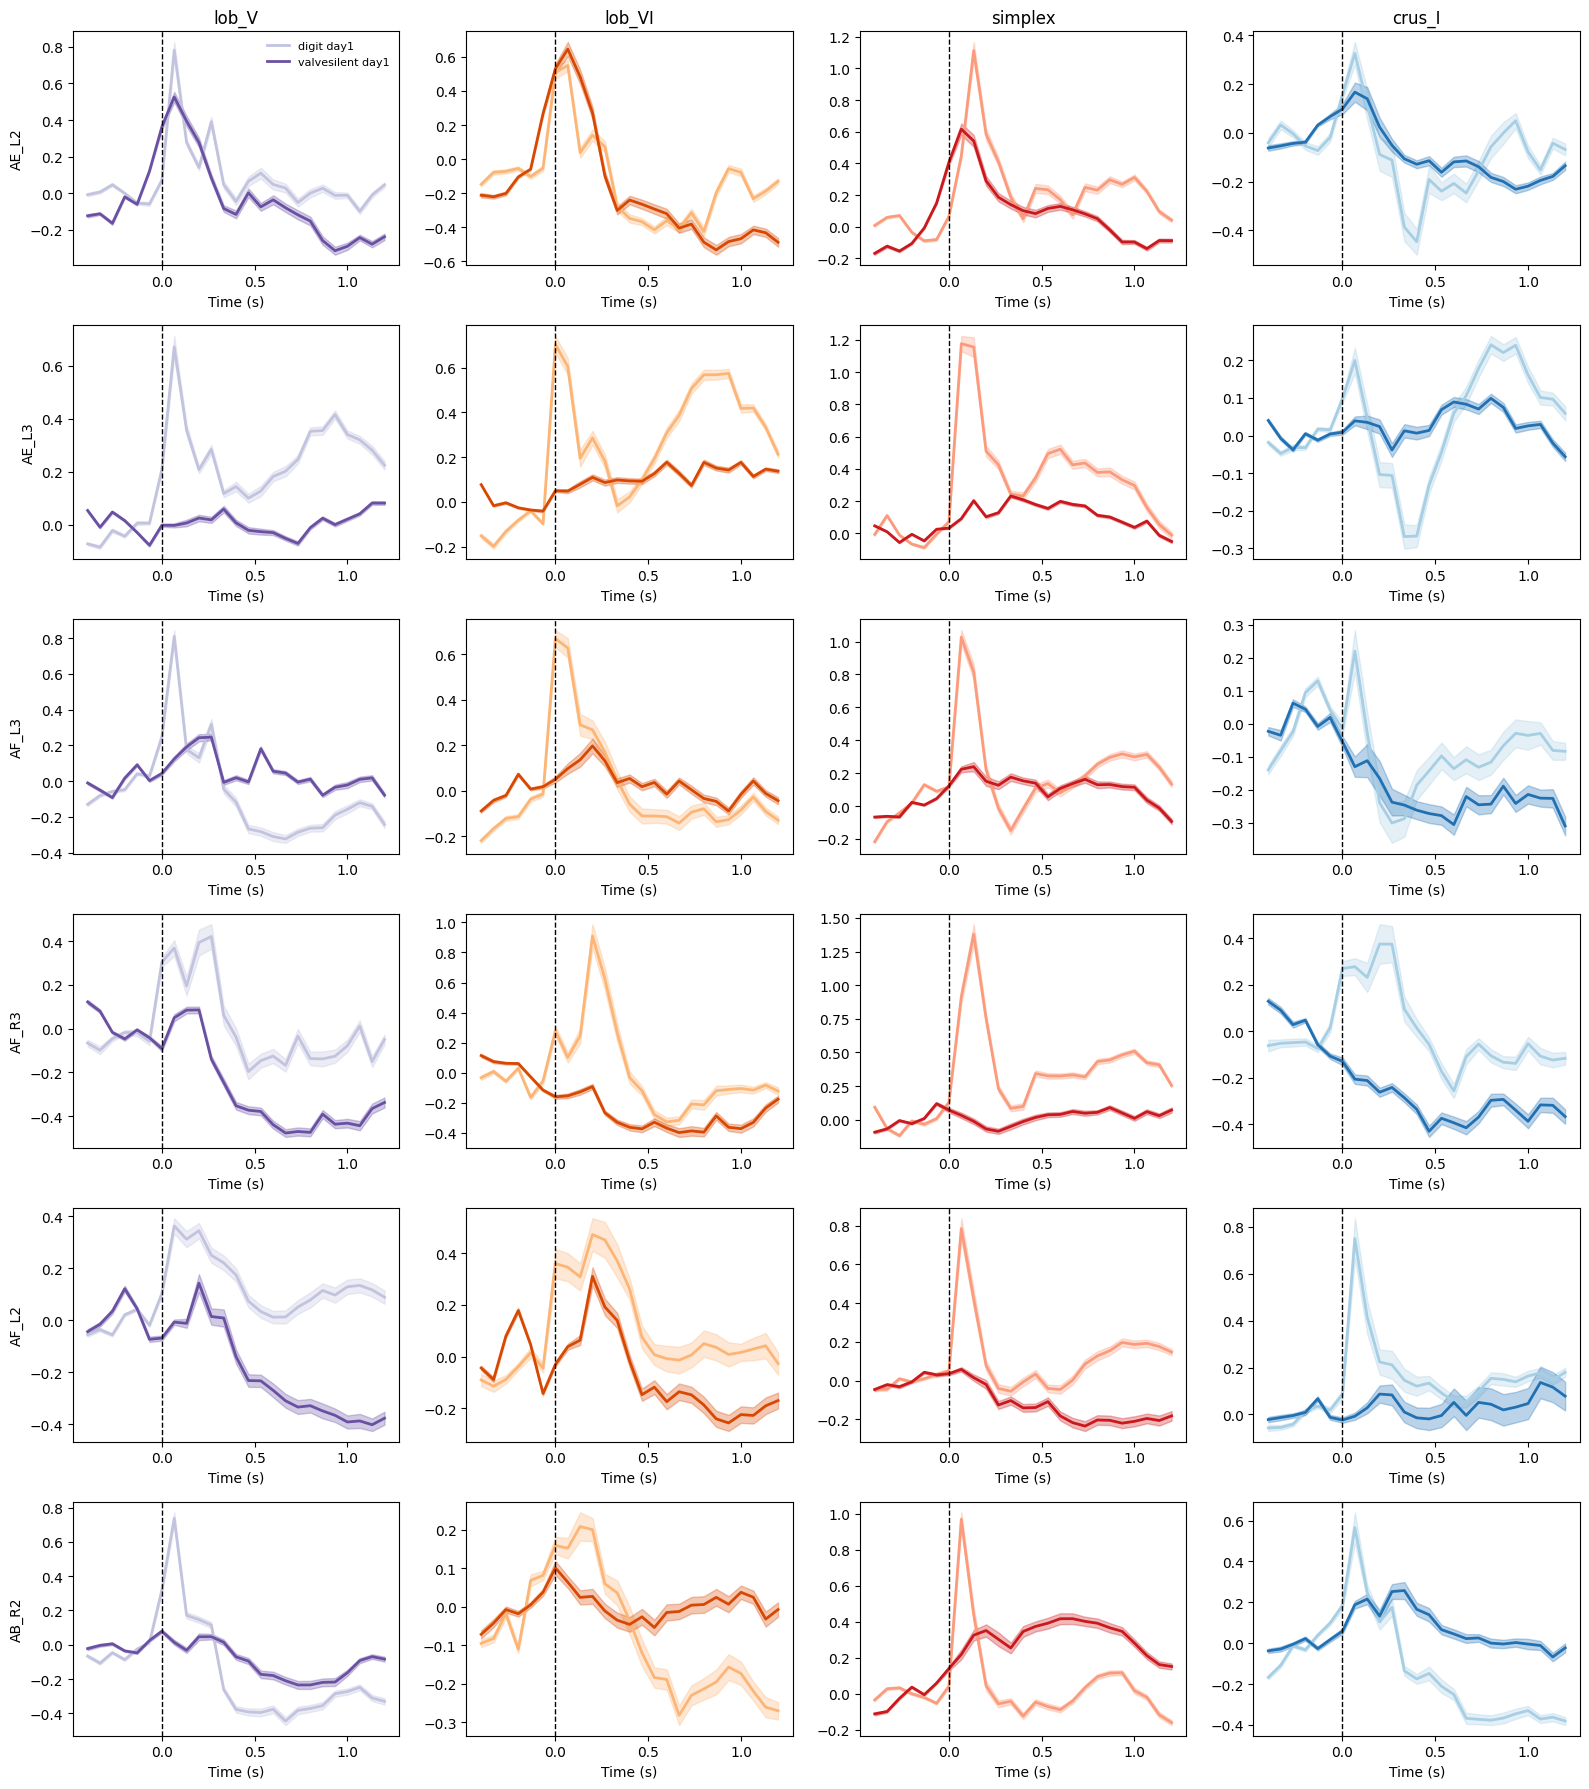

In [31]:
fig, axes = plot_reward_region_avg_naive_vs_valvesilent(
    agg_data=agg_data,
    mouse_ids=valvesilent_mice,
    roi_masks_full=roi_masks_full,
    roi_order=['lob_V', 'lob_VI','simplex', 'crus_I'],  # or whatever regions you have
    psth_time_window=(-0.4, 1.2),
    arms=('arm1', 'arm2'),
    frac_thresh=0.5,
    resp_label=('digit day1', 'valvesilent day1')
)

In [32]:
fig.savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig6', "valvesilent_effect_psth_curve.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

In [197]:
pred = 'vis_reward_times'
pred_win = np.arange(6)
regular_reward_betas = []
valvesilent_reward_betas = []
regular_reward_r2 = []
valvesilent_reward_r2 = []
unique_pred_idx = unique_predictors.index(pred)
for mouse in valvesilent_mice:
    # if mouse_id != 'J_L2':
    #     continue
    mouse_data = agg_data[mouse]
    dates =  [date for date in mouse_data.keys() if date.startswith('202')]
    earliest_regular, earliest_valvesilent = get_earliest_dates(dates)
    for arm in ['arm1', 'arm2']:
        if arm in mouse_data[earliest_regular]:
            neurons = mouse_data[earliest_regular][arm]['stat']
            
            # Loop through all neurons in this arm
            for neuron in neurons:
                beta = np.mean(neuron[pred + '_beta'][pred_win])
                regular_reward_betas.append(beta)
                regular_reward_r2.append(neuron['unique_explained_variance'][unique_pred_idx])
        if arm in mouse_data[earliest_valvesilent]:
            neurons = mouse_data[earliest_valvesilent][arm]['stat']
            for neuron in neurons:
                beta = np.mean(neuron[pred + '_beta'][pred_win])
                valvesilent_reward_betas.append(beta)
                valvesilent_reward_r2.append(neuron['unique_explained_variance'][unique_pred_idx])
regular_reward_betas = np.array(regular_reward_betas)
valvesilent_reward_betas = np.array(valvesilent_reward_betas)
regular_reward_r2 = np.array(regular_reward_r2)
valvesilent_reward_r2 = np.array(valvesilent_reward_r2)

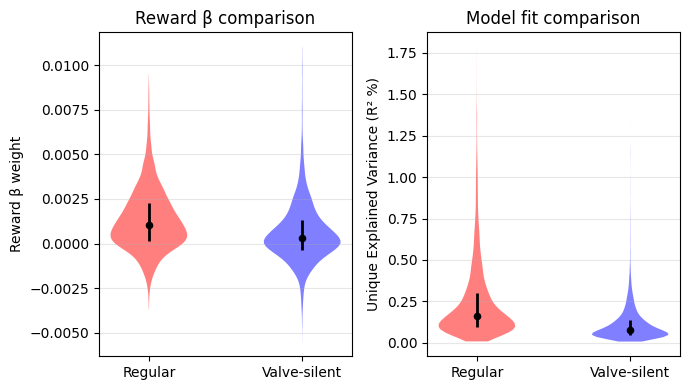

In [201]:
fig, axes = plt.subplots(1, 2, figsize=(7, 4), sharey=False)
color_regular = 'red'
color_valvesilent = 'blue'
# --- β comparison ---
data_betas = [regular_reward_betas, valvesilent_reward_betas]
positions = [1, 2]
parts = axes[0].violinplot(data_betas, positions=positions, showmeans=False, showextrema=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor([color_regular, color_valvesilent][i])
    pc.set_alpha(0.5)
    pc.set_edgecolor('none')
#overlay median and IQR
medians = [np.nanmedian(x) for x in data_betas]
q1 = [np.nanpercentile(x, 25) for x in data_betas]
q3 = [np.nanpercentile(x, 75) for x in data_betas]
axes[0].scatter(positions, medians, color='k', s=20, zorder=3)
axes[0].vlines(positions, q1, q3, color='k', lw=2)
axes[0].set_xticks(positions)
axes[0].set_xticklabels(['Regular', 'Valve-silent'])
axes[0].set_ylabel('Reward β weight')
axes[0].set_title('Reward β comparison')
axes[0].grid(True, axis='y', alpha=0.3)

# --- R² comparison ---
data_r2 = [regular_reward_r2*100, valvesilent_reward_r2*100]
parts = axes[1].violinplot(data_r2, positions=positions, showmeans=False, showextrema=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor([color_regular, color_valvesilent][i])
    pc.set_alpha(0.5)
    pc.set_edgecolor('none')
medians = [np.nanmedian(x) for x in data_r2]
q1 = [np.nanpercentile(x, 25) for x in data_r2]
q3 = [np.nanpercentile(x, 75) for x in data_r2]
axes[1].scatter(positions, medians, color='k', s=20, zorder=3)
axes[1].vlines(positions, q1, q3, color='k', lw=2)
axes[1].set_xticks(positions)
axes[1].set_xticklabels(['Regular', 'Valve-silent'])
axes[1].set_ylabel('Unique Explained Variance (R² %)')
axes[1].set_title('Model fit comparison')
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [198]:
axes[1].set_ylim(0, 0.005)

(0.0, 0.005)

In [196]:
print(np.nanmean(regular_reward_r2))
print(np.nanmean(valvesilent_reward_r2))


0.002401327085134856
0.0011188830471819849


In [ ]:
pred_x = 'left_aud_stimOn_times'
pred_y = 'vis_reward_times'
pred_y_win = np.arange(6)
x_betas = []
y_betas = []


# Loop through all mice, dates, and arms to collect beta coefficients
for mouse_id in agg_data.keys():
    # if mouse_id != 'J_L2':
    #     continue
    mouse_data = agg_data[mouse_id]
    
    # Loop through all dates (excluding 'training')
    for date in mouse_data.keys():
        #print(date)
        if date == 'training':
            continue
        if 'valvesilent' not in date:
            continue
        # Check both arm1 and arm2 if they exist
        for arm in ['arm1', 'arm2']:
            if arm in mouse_data[date]:
                neurons = mouse_data[date][arm]['stat']
                
                # Loop through all neurons in this arm
                for neuron in neurons:
                    x_beta = np.mean(neuron[pred_x + '_beta'])
                    y_beta = np.mean(neuron[pred_y + '_beta'][pred_y_win])
                    
                    x_betas.append(x_beta)
                    y_betas.append(y_beta)

# Convert to numpy arrays
x_betas = np.array(x_betas)
y_betas = np.array(y_betas)

# Create the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(x_betas, y_betas, alpha=0.6, s=20)
plt.xlabel(pred_x, fontsize=18)
plt.ylabel(pred_y, fontsize=18)
plt.title(f'Neuron Response Correlation\n(n={len(x_betas)} neurons from all mice and dates)', fontsize=18)
plt.grid(True, alpha=0.3)

# Make tick labels bigger
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Calculate regression line
slope, intercept, r_value, p_value, std_err = stats.linregress(x_betas, y_betas)

# Plot regression line
x_range = np.linspace(np.min(x_betas), np.max(x_betas), 100)
y_pred = slope * x_range + intercept
plt.plot(x_range, y_pred, 'r-', alpha=0.8, linewidth=2, 
         #label=f'Regression line (R²={r_value**2:.3f})'
         )

# Calculate and display correlation and regression stats
correlation = np.corrcoef(x_betas, y_betas)[0, 1]
plt.text(0.05, 0.8, f'Correlation: {correlation:.3f}\nR²: {r_value**2:.3f}\np-value: {p_value:.2e}', 
         transform=plt.gca().transAxes, fontsize=16, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.legend()
plt.tight_layout()
plt.show()

print(f"Total number of neurons: {len(x_betas)}")
print(f"Correlation coefficient: {correlation:.4f}")
print(f"Regression slope: {slope:.4f}")
print(f"Regression intercept: {intercept:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.2e}")

In [ ]:
psth_timepoint = np.linspace(psth_time_start*1000,psth_time_end*1000,vis_left_choice_psth.shape[1])
beta_timepoint = np.linspace(0,300,vis_left_choice_beta.shape[1])

Unique Explained Variance Box Plot

In [7]:
unique_predictors

['vis_ruleCue_times',
 'aud_ruleCue_times',
 'left_vis_stimOn_times',
 'right_vis_stimOn_times',
 'left_aud_stimOn_times',
 'right_aud_stimOn_times',
 'vis_left_choice_times',
 'vis_right_choice_times',
 'aud_left_choice_times',
 'aud_right_choice_times',
 'vis_reward_times',
 'aud_reward_times',
 'vis_punish_times',
 'aud_punish_times',
 'omission_times',
 'previous_feedbackType',
 'reward_history',
 'body',
 'lick',
 'face',
 'pupil_area',
 'pupil_xpos',
 'pupil_ypos',
 'vel']

In [4]:
indices = [0,1,2,3,4,5,6,7,8,9,10,11,17,18,19,20,23]
unique_predictors2plot = [unique_predictors[i] for i in indices]

In [5]:

unique_explained_cvR = []
full_explained_cvR = []
# Loop through all mice, dates, and arms to collect beta coefficients
for i, pred in enumerate(unique_predictors):
    unique_explained_cvR.append([])
    for mouse_id in agg_data.keys():
        # if mouse_id != 'J_L2':
        #     continue
        mouse_data = agg_data[mouse_id]
        
        # Loop through all dates (excluding 'training')
        for date in mouse_data.keys():
            #print(date)
            if date == 'training':
                continue
            if 'reward' in pred and 'valvesilent' not in date:
                continue
            if 'punish' in pred and 'punishsilent' not in date:
                continue
            # Check both arm1 and arm2 if they exist
            for arm in ['arm1', 'arm2']:
                if arm in mouse_data[date]:
                    neurons = mouse_data[date][arm]['stat']
                    
                    # Loop through all neurons in this arm
                    for neuron in neurons:
                        # Check if both predictors exist for this neuron
                        unique_explained_cvR[i].append(neuron['unique_explained_variance'][i])
                        if i == 0:
                            full_explained_cvR.append(neuron['explained_variance'])
unique_explained_cvR = [unique_explained_cvR[i] for i in indices]
full_explained_cvR = [full_explained_cvR[i] for i in indices]

In [7]:
def get_uev_by_roi(
    agg_data,
    unique_predictors,
    roi_masks_full,
    frac_thresh=0.5,
    indices=None
):
    """
    Collect unique explained variance per predictor, split by ROI.

    Returns
    -------
    unique_explained_cvR_roi : list of length num_preds_plot
        unique_explained_cvR_roi[p][r] is a list of UEV values
        for predictor p in ROI r across all neurons/sessions.
    roi_names : list of ROI names in the same order as axis 1.
    """

    # predictor subset
    if indices is None:
        pred_indices = list(range(len(unique_predictors)))
    else:
        pred_indices = list(indices)

    roi_names = list(roi_masks_full.keys())
    n_rois = len(roi_names)

    # precompute boolean masks and shapes
    roi_masks_bool = {}
    roi_shapes = {}
    for roi_name, roi_mask in roi_masks_full.items():
        mask_bool = np.asarray(roi_mask, dtype=bool)
        roi_masks_bool[roi_name] = mask_bool
        roi_shapes[roi_name] = mask_bool.shape  # (H, W)

    # [pred][roi] -> list
    unique_explained_cvR_roi = [
        [[] for _ in range(n_rois)] for _ in pred_indices
    ]

    # loop over predictors
    for p_idx_out, pred_idx in enumerate(pred_indices):
        pred_name = unique_predictors[pred_idx]

        for mouse_id, mouse_data in agg_data.items():
            for date, day in mouse_data.items():
                if date == 'training':
                    continue
                if 'reward' in pred_name and 'valvesilent' not in date:
                    continue
                if 'punish' in pred_name and 'punishsilent' not in date:
                    continue

                # combine neurons across arms like in count_neurons_in_rois
                neurons = []
                for arm in ['arm1', 'arm2']:
                    if arm in day:
                        neurons.extend(day[arm]['stat'])
                if not neurons:
                    continue

                for neuron in neurons:
                    x = np.asarray(neuron['xcoord_atlas'], dtype=int)
                    y = np.asarray(neuron['ycoord_atlas'], dtype=int)

                    # skip if nothing valid
                    if x.size == 0 or y.size == 0:
                        continue

                    # we assume all ROIs share same atlas shape
                    # use first roi's shape:
                    H, W = next(iter(roi_shapes.values()))
                    ok = (x >= 0) & (x < W) & (y >= 0) & (y < H)
                    if not np.any(ok):
                        continue
                    x = x[ok]
                    y = y[ok]
                    n_pix_total = len(x)
                    if n_pix_total == 0:
                        continue

                    # compute fraction in each ROI, pick best ROI
                    fracs = []
                    for roi_name in roi_names:
                        mask = roi_masks_bool[roi_name]
                        n_in = np.count_nonzero(mask[y, x])
                        fracs.append(n_in / n_pix_total)
                    fracs = np.asarray(fracs)

                    best_roi = np.argmax(fracs)
                    if fracs[best_roi] < frac_thresh:
                        # neuron not strongly in any ROI
                        continue

                    # add UEV for this predictor / ROI
                    uev_val = neuron['unique_explained_variance'][pred_idx]
                    unique_explained_cvR_roi[p_idx_out][best_roi].append(uev_val)

    return unique_explained_cvR_roi, roi_names

In [11]:
unique_explained_cvR_roi, roi_names = get_uev_by_roi(
    agg_data,
    unique_predictors,
    roi_masks_full,
    frac_thresh=0.5,
    indices=indices     # same indices you used before
)

In [20]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

ROI_COLOR_MAP = {
    'simplex' : plt.cm.Reds,
    'crus_I'  : plt.cm.Blues,
    'lob_V'   : plt.cm.Purples,
    'lob_VI'  : plt.cm.Oranges,
}

DESIRED_ROI_ORDER = ['lob_V', 'lob_VI', 'simplex', 'crus_I']


def get_roi_color(roi_name):
    """Return a nice mid-level color from the ROI colormap."""
    cmap = ROI_COLOR_MAP[roi_name]
    return cmap(0.6)   # medium saturation


def plot_uev_by_roi_violin(unique_explained_cvR_roi, roi_names, unique_predictors2plot,
                           add_errorbars=True):
    """
    Grouped violins:
      x-axis = predictors
      4 violins per predictor (ROI order: lob_V, lob_VI, simplex, crus_I).
    Error bars show median ± IQR and match violin colors.

    """
    def hide_violin_artists(parts, keys=('cbars','cmins','cmaxes')):
        for key in keys:
            if key in parts and parts[key] is not None:
                obj = parts[key]
                # If it's a list (e.g. bodies), iterate over it
                if isinstance(obj, (list, tuple)):
                    for artist in obj:
                        artist.set_visible(False)
                else:
                    # Single artist (Line2D, LineCollection, etc.)
                    obj.set_visible(False)
    num_preds = len(unique_explained_cvR_roi)

    # reorder ROIs according to desired order, keeping only those present
    ordered_roi_names = [r for r in DESIRED_ROI_ORDER if r in roi_names]
    num_rois = len(ordered_roi_names)

    fig, ax = plt.subplots(figsize=(14, 8))

    # main predictor centers
    x_centers = np.arange(num_preds) + 1  # 1..num_preds

    group_width = 0.8
    sub_width = group_width / num_rois

    for r_pos, roi_name in enumerate(ordered_roi_names):
        roi_color = get_roi_color(roi_name)
        orig_r_idx = roi_names.index(roi_name)

        # offsets so violins stay grouped
        offset = (r_pos - (num_rois - 1) / 2) * sub_width
        positions = x_centers + offset

        # UEV values for this ROI across predictors
        data_r = [unique_explained_cvR_roi[p][orig_r_idx] for p in range(num_preds)]

        # violin plot
        parts = ax.violinplot(
            data_r,
            positions=positions,
            widths=sub_width * 0.9,
            showmeans=False,
            showmedians=False   # we'll draw our own medians with errorbars
        )
        hide_violin_artists(parts)

        for pc in parts['bodies']:
            pc.set_facecolor(roi_color)
            pc.set_edgecolor('black')
            pc.set_alpha(0.7)

        # robust error bars: median ± IQR, colored like violin
        if add_errorbars:
            for x, vals in zip(positions, data_r):
                if len(vals) == 0:
                    continue
                vals = np.asarray(vals)
                median = np.median(vals)
                q25, q75 = np.percentile(vals, [1, 99])
                lower = median - q25
                upper = q75 - median
                ax.errorbar(
                    x, median,
                    yerr=[[lower], [upper]],
                    fmt='o',
                    color=roi_color,
                    ecolor=roi_color,
                    elinewidth=1.2,
                    capsize=2,
                    markersize=3
                )

    # ---------- labels ----------
    ax.set_xticks(x_centers)
    ax.set_xticklabels(
        unique_predictors2plot,
        fontname='Arial',
        fontsize=14,
        rotation=45,
        ha='right'
    )

    ax.set_ylabel('Unique Explained Variance (CV R²)', fontname='Arial', fontsize=18)
    ax.set_xlabel('Predictors', fontname='Arial', fontsize=18)
    ax.set_title('Unique Explained Variance by Predictor and ROI',
                 fontname='Arial', fontsize=20)

    ax.tick_params(axis='y', labelsize=14)
    for label in ax.get_yticklabels():
        label.set_fontname('Arial')

    # ---------- legend ----------
    handles = [
        Patch(facecolor=get_roi_color(roi),
              edgecolor='black',
              alpha=0.7,
              label=roi)
        for roi in ordered_roi_names
    ]
    ax.legend(handles=handles, title='ROI', fontsize=12, title_fontsize=12)

    plt.tight_layout()
    return fig, ax


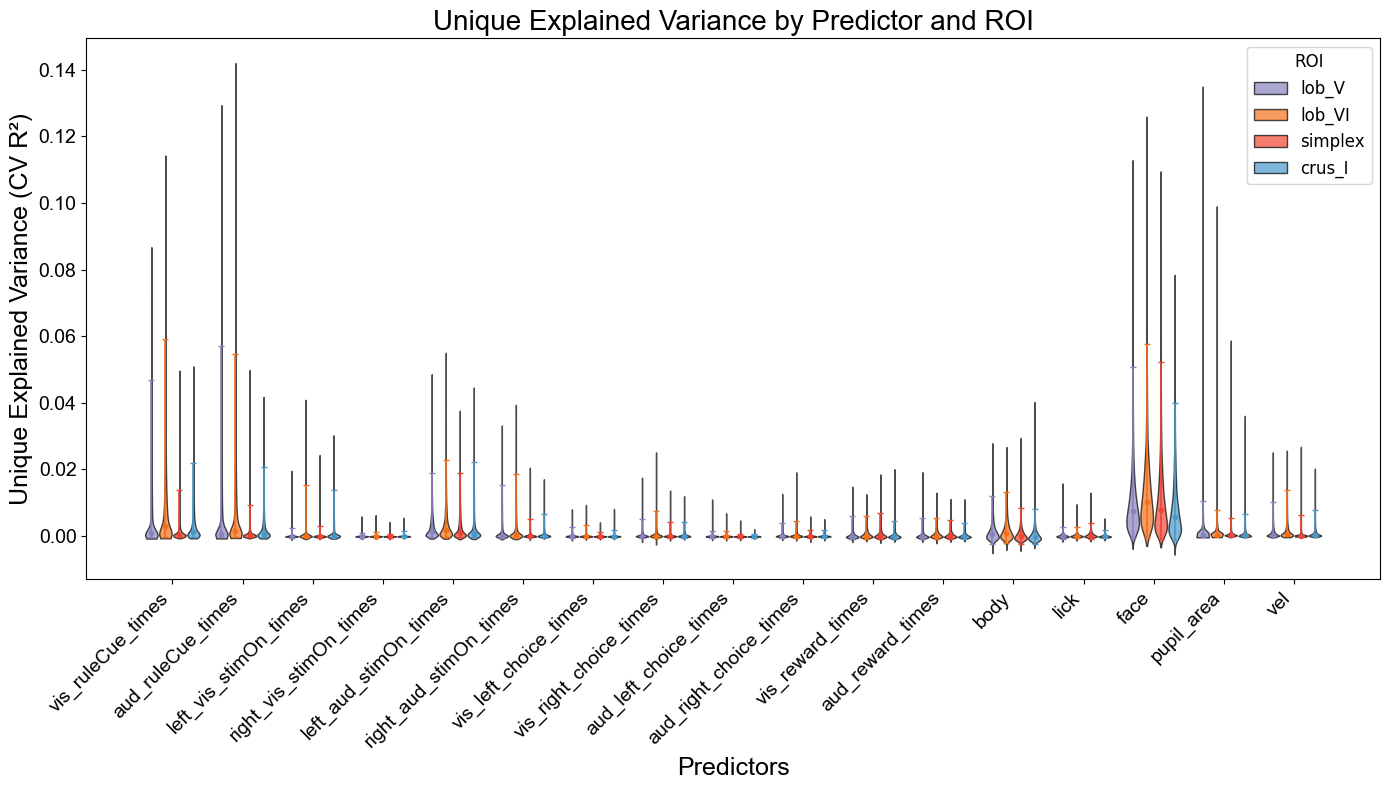

In [21]:
ROI_COLOR_MAP = {
    'simplex': plt.cm.Reds,
    'crus_I': plt.cm.Blues,
    'lob_V': plt.cm.Purples,
    'lob_VI': plt.cm.Oranges,
}
fig, ax = plot_uev_by_roi_violin(unique_explained_cvR_roi, roi_names, unique_predictors2plot)
# fig.savefig("uev_by_roi_violin.png", dpi=300)
plt.show()

In [22]:
fig.savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig2', "uev_region_violin.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

In [ ]:
from matplotlib import font_manager

fig, ax = plt.subplots(figsize=(10, 8))

# Prepare data: list of arrays, one per predictor
violin_data = [unique_explained_cvR[i] for i in range(len(unique_predictors2plot))]

# Create violin plot
parts = ax.violinplot(
    violin_data,
    showmeans=False,
    showmedians=True,
    widths=0.8
)

# Styling: make violins semi-transparent gray
for pc in parts['bodies']:
    pc.set_facecolor('gray')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

# Style median line
if 'cmedians' in parts:
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.5)

# Axis labels / title
ax.set_xlabel('Predictors', fontname='Arial', fontsize=18)
ax.set_ylabel('Unique Explained Variance (CV R²)', fontname='Arial', fontsize=18)
ax.set_title('Unique Explained Variance by Predictor Across Neurons',
             fontname='Arial', fontsize=20)

# Predictor names on x-axis
ax.set_xticks(np.arange(1, len(unique_predictors2plot) + 1))
ax.set_xticklabels(unique_predictors2plot,
                   fontname='Arial',
                   fontsize=16,
                   rotation=45,
                   ha='right')

# Tick params for y-axis
ax.tick_params(axis='y', labelsize=16)
for label in ax.get_yticklabels():
    label.set_fontname('Arial')

# Tight layout + option to save
plt.tight_layout()

# Save example:
# fig.savefig('uev_violin_plot.png', dpi=300)

plt.show()

In [ ]:
fig, ax = plot_uev_boxplot(unique_explained_cvR, unique_predictors2plot,
                           savepath='uev_boxplot.png')

In [ ]:
plt.figure(figsize=(2, 4))

# Create box plot with full explained variance for all neurons
bp = plt.boxplot([full_explained_cvR], patch_artist=True, showfliers=False)

# Customize the plot
plt.ylabel('Full Model Explained Variance (CV R²)')
plt.title('Full Model Explained Variance Across All Neurons')
plt.xticks([1], ['All Neurons'])
plt.grid(True, alpha=0.3)

# Color the box
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_alpha(0.7)

plt.tight_layout()
plt.show()


Clustering

In [6]:
def build_pred_index_map(predictors, unique_predictors):
    """
    Map each unique predictor name -> array of column indices in `predictors`.
    """
    pred_to_idx = {}
    predictors = list(predictors)

    for upred in unique_predictors:
        # same logic you used before: all columns whose name contains `upred`
        idx = [i for i, name in enumerate(predictors) if upred in name]
        if len(idx) == 0:
            # sometimes a unique predictor might not be present; skip
            continue
        pred_to_idx[upred] = np.asarray(idx, dtype=int)

    return pred_to_idx

In [25]:
unique_predictors

['vis_ruleCue_times',
 'aud_ruleCue_times',
 'left_vis_stimOn_times',
 'right_vis_stimOn_times',
 'left_aud_stimOn_times',
 'right_aud_stimOn_times',
 'vis_left_choice_times',
 'vis_right_choice_times',
 'aud_left_choice_times',
 'aud_right_choice_times',
 'vis_reward_times',
 'aud_reward_times',
 'vis_punish_times',
 'aud_punish_times',
 'omission_times',
 'previous_feedbackType',
 'reward_history',
 'body',
 'lick',
 'face',
 'pupil_area',
 'pupil_xpos',
 'pupil_ypos',
 'vel']

In [38]:
agg_data['AE_L2']['20250624_valvesilent']['arm1']['stat'][0]['vis_reward_times_psth']

array([[-2.86461514e-02,  8.05235312e-01, -6.90849781e-01, ...,
         1.17230803e+00, -5.13069937e-01,  4.76528701e-02],
       [ 2.75028770e+00,  2.39854112e-01,  4.49763536e-01, ...,
         6.79189937e+00,  2.70459766e+00,  9.23595004e-02],
       [ 3.28664809e-01, -1.09101267e+00,  1.15005908e+00, ...,
         4.62117876e-01,  1.00581176e+00, -7.27615378e-01],
       ...,
       [ 2.23535040e-01, -4.46173191e-01,  9.54125919e-01, ...,
         6.69561965e-01, -7.91828286e-01,  1.40464389e+00],
       [ 1.68982762e+00,  4.33904681e-03,  3.10286234e-01, ...,
        -9.69710751e-01, -3.53217223e-01,  3.39455493e-01],
       [-6.04610466e-01, -4.03337619e-01,  4.28026618e-01, ...,
         5.82301027e-01,  5.46557755e-01,  9.50055490e-01]])

In [8]:
global_unique_predictors = ['vis_reward_times', 'aud_reward_times']

In [9]:
all_beta_vecs = []
all_meta = []   # will hold mouse/date/arm/idx_in_arm, plus maybe training stage

for mouse in mouse_ids:
    for date in agg_data[mouse].keys():
        if date == 'training':
            continue
        if 'valvesilent' not in date: # for unique predictors containing reward
            continue
        session = agg_data[mouse][date]

        # skip sessions with no imaging
        if ('arm1' not in session) and ('arm2' not in session):
            continue

        pred_to_idx = build_pred_index_map(predictors, global_unique_predictors)  # global order

        for arm in ('arm1', 'arm2'):
            if arm not in session:
                continue
            stat_arr = session[arm]['stat']  # array of neuron dicts

            for ni, neuron in enumerate(stat_arr):
                beta_full = np.asarray(neuron['beta']).ravel()
                pval_full = np.asarray(neuron['bootstrap_p_value']).ravel()
                r2_full = np.asarray(neuron['unique_explained_variance']).ravel()
                # build global features in global_unique_predictors order
                select_pval = pval_full[[unique_predictors.index(pred) for pred in global_unique_predictors]]
                select_r2 = r2_full[[unique_predictors.index(pred) for pred in global_unique_predictors]]
                # if all(select_pval > 0.01):
                #     continue
                if all(select_r2 < 0.005):
                    continue
                blocks = []
                for upred in global_unique_predictors:
                    idx = pred_to_idx.get(upred, None)
                    if idx is None:
                        # predictor group not present in this session → pad with zeros
                        # (or np.zeros(<expected length>), depending how strict you are)
                        continue
                    blocks.append(beta_full[idx])
                    
                if not blocks:
                    continue
                v = np.concatenate(blocks, axis=0)
                # v = np.array(blocks, dtype=float)
                all_beta_vecs.append(v)
                all_meta.append({
                    'mouse': mouse,
                    'date': date,
                    'arm': arm,
                    'idx_in_arm': ni,
                    # you can also insert training stage here if you have it
                })

beta_global = np.vstack(all_beta_vecs)  # (N_total_neurons, F)

In [90]:
beta_global.shape

(1300, 32)

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# X_raw: (84000, 246)
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(beta_global)

pca = PCA(n_components=7, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print(f"{pca.explained_variance_ratio_.sum()*100:.1f}% variance retained")

92.3% variance retained


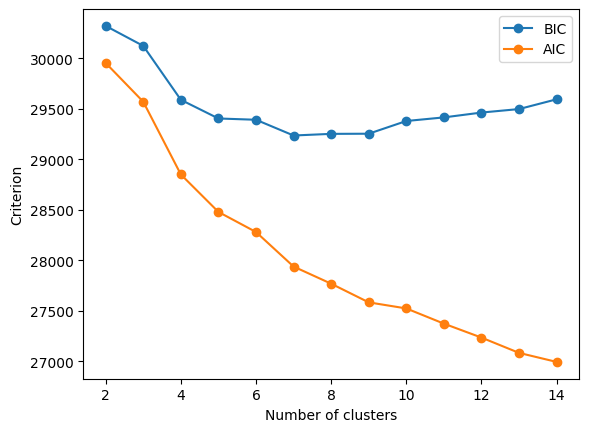

In [95]:
from sklearn.mixture import GaussianMixture
import numpy as np

Ks = range(2, 15)
bics, aics = [], []

for k in Ks:
    gmm = GaussianMixture(n_components=k, covariance_type='full', n_init=5, random_state=0)
    gmm.fit(X_pca)  # X is your standardized beta matrix
    bics.append(gmm.bic(X_pca))
    aics.append(gmm.aic(X_pca))

plt.plot(Ks, bics, 'o-', label='BIC')
plt.plot(Ks, aics, 'o-', label='AIC')
plt.xlabel('Number of clusters')
plt.ylabel('Criterion')
plt.legend()

Text(0.5, 1.0, 'Optimal K ≈ argmax(silhouette)')

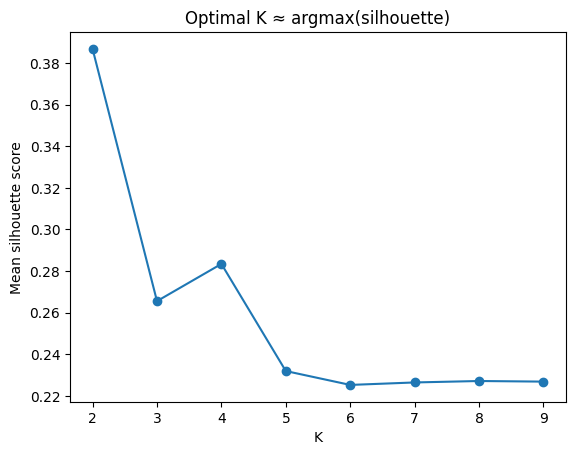

In [11]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

Ks = range(2, 10)
scores = []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=0, n_init=20)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

plt.plot(Ks, scores, 'o-')
plt.xlabel('K')
plt.ylabel('Mean silhouette score')
plt.title('Optimal K ≈ argmax(silhouette)')

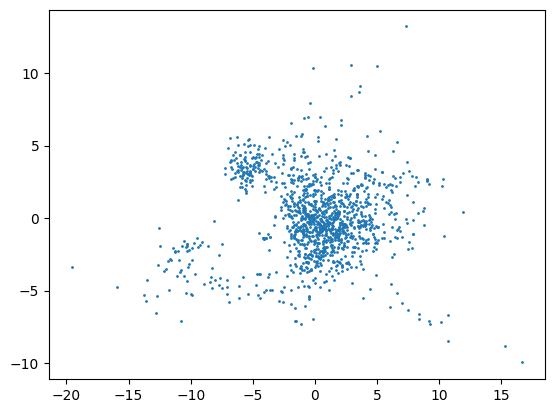

In [12]:
plt.scatter(X_pca[:,0], X_pca[:,1], s=1)

In [16]:
km = KMeans(n_clusters=4, random_state=0, n_init=20)
labels = km.fit_predict(X_pca)

C:\Users\dirk\AppData\Local\Temp\ipykernel_25912\3741109262.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_labels))


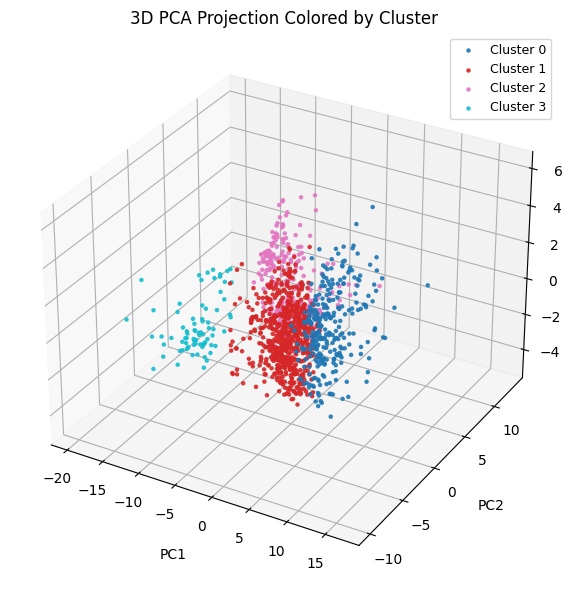

In [17]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# X_pca should have at least 3 components
# labels is (N,) array of cluster IDs

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

unique_labels = np.unique(labels)
cmap = plt.cm.get_cmap('tab10', len(unique_labels))

for i, lab in enumerate(unique_labels):
    idx = labels == lab
    ax.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        X_pca[idx, 2],
        s=5,
        color=cmap(i),
        label=f"Cluster {lab}",
        alpha=0.85
    )

ax.set_xlabel("PC1", labelpad=10)
ax.set_ylabel("PC2", labelpad=10)
ax.set_zlabel("PC3", labelpad=10)
ax.set_title("3D PCA Projection Colored by Cluster")

# Legend
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

C:\Users\dirk\AppData\Local\Temp\ipykernel_25912\1186251371.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_labels))


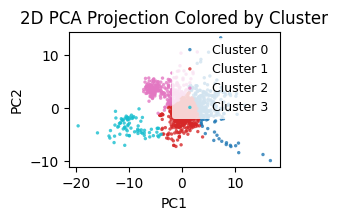

In [71]:
fig = plt.figure(figsize=(3,3))
ax = fig.add_subplot(111)

unique_labels = np.unique(labels)
cmap = plt.cm.get_cmap('tab10', len(unique_labels))

for i, lab in enumerate(unique_labels):
    idx = labels == lab
    ax.scatter(
        X_pca[idx, 0],   # PC1
        X_pca[idx, 1],   # PC2
        s=6,
        color=cmap(i),
        label=f"Cluster {lab}",
        alpha=0.8,
        edgecolors='none'
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("2D PCA Projection Colored by Cluster")

ax.legend(
    loc="upper right",
    fontsize=9,
    frameon=True,
    facecolor='white',
    edgecolor='none'
)

ax.set_aspect('equal', 'box')
plt.tight_layout()
plt.show()

In [72]:
fig.savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig6', "pca_cluster.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

In [13]:
psth_timepoint = np.linspace(psth_time_start*1000, psth_time_end*1000, 25)
beta_timepoint = np.linspace(0, 1000, 16)

In [14]:
import math

VIS_COLOR = '#0072B2'
AUD_COLOR = '#E69F00'

def plot_cluster_psth_and_beta(
    agg_data,
    all_meta,
    labels,
    global_unique_predictors,
    psth_timepoint,
    beta_timepoint,
    cluster_ids=None
):
    """
    For each cluster, compute mean PSTH and beta timecourses for each predictor,
    then plot:
      - one figure with PSTHs for all clusters (subplots = clusters, traces = predictors)
      - one figure with betas for all clusters.

    Predictors containing 'vis' are drawn in VIS_COLOR,
    predictors containing 'aud' are drawn in AUD_COLOR.
    Other predictors (if present) are gray.
    """

    labels = np.asarray(labels)
    if cluster_ids is None:
        cluster_ids = np.unique(labels)
    cluster_ids = np.asarray(cluster_ids)

    n_clusters = len(cluster_ids)
    n_preds = len(global_unique_predictors)

    # store results: cluster_id -> pred_name -> dict with psth/beta stats
    cluster_results = {cl: {} for cl in cluster_ids}

    # ---- collect stats per cluster & predictor ----
    for cl in cluster_ids:
        cl_ix = np.where(labels == cl)[0]
        if cl_ix.size == 0:
            continue

        for pred in global_unique_predictors:
            psth_list = []
            beta_list = []

            key_psth = f"{pred}_psth"
            key_beta = f"{pred}_beta"

            for gi in cl_ix:
                meta = all_meta[gi]
                neuron = agg_data[meta['mouse']][meta['date']][meta['arm']]['stat'][meta['idx_in_arm']]

                psth = neuron.get(key_psth, None)
                beta = neuron.get(key_beta, None)
                if psth is None or beta is None:
                    continue

                psth = np.asarray(psth)
                beta = np.asarray(beta)

                # PSTH shape: (n_trials, T) or (T,)
                if psth.ndim == 2:
                    psth_mean_per_neuron = np.nanmean(psth, axis=0)
                elif psth.ndim == 1:
                    psth_mean_per_neuron = psth
                else:
                    continue

                if beta.ndim != 1:
                    continue

                psth_list.append(psth_mean_per_neuron)
                beta_list.append(beta)

            if len(psth_list) == 0:
                continue

            psth_arr = np.vstack(psth_list)   # (n_neurons, T_psth)
            beta_arr = np.vstack(beta_list)   # (n_neurons, T_beta)

            psth_mean = np.nanmean(psth_arr, axis=0)
            psth_sem  = np.nanstd(psth_arr, axis=0) / np.sqrt(psth_arr.shape[0])

            beta_mean = np.nanmean(beta_arr, axis=0)
            beta_sem  = np.nanstd(beta_arr, axis=0) / np.sqrt(beta_arr.shape[0])

            t_psth = psth_timepoint
            t_beta = beta_timepoint

            cluster_results[cl][pred] = dict(
                psth_mean=psth_mean,
                psth_sem=psth_sem,
                t_psth=t_psth,
                beta_mean=beta_mean,
                beta_sem=beta_sem,
                t_beta=t_beta,
                n_neurons=psth_arr.shape[0]
            )

    # helper for subplot grid
    def _make_grid(n_panels, max_cols=4):
        n_cols = min(max_cols, n_panels)
        n_rows = int(math.ceil(n_panels / n_cols))
        return n_rows, n_cols

    # ---- PSTH figure ----
    n_rows, n_cols = _make_grid(n_clusters, max_cols=4)
    fig_psth, axes_psth = plt.subplots(
        n_rows, n_cols,
        figsize=(1.5 * n_cols, 2 * n_rows),
        squeeze=False,
        sharex=True, sharey=True
    )

    # ---- Beta figure ----
    fig_beta, axes_beta = plt.subplots(
        n_rows, n_cols,
        figsize=(1.5 * n_cols, 2 * n_rows),
        squeeze=False,
        sharex=True, sharey=True,
    )

    def _color_for_pred(pred):
        lp = pred.lower()
        if 'vis' in lp:
            return VIS_COLOR
        elif 'aud' in lp:
            return AUD_COLOR
        else:
            return '0.5'

    # ---- fill subplots ----
    for ci, cl in enumerate(cluster_ids):
        r = ci // n_cols
        c = ci % n_cols

        ax_psth = axes_psth[r, c]
        ax_beta = axes_beta[r, c]

        preds_in_cluster = cluster_results[cl].keys()
        if not preds_in_cluster:
            ax_psth.set_visible(False)
            ax_beta.set_visible(False)
            continue

        # PSTH subplots: overlay vis & aud (and any others if present)
        for pred in global_unique_predictors:
            if pred not in cluster_results[cl]:
                continue
            res = cluster_results[cl][pred]
            col = _color_for_pred(pred)

            t_psth = res['t_psth']
            mean = res['psth_mean']
            sem  = res['psth_sem']

            ax_psth.plot(t_psth, mean, color=col, label=pred)
            ax_psth.fill_between(
                t_psth, mean - sem, mean + sem,
                color=col, alpha=0.3
            )

            t_beta = res['t_beta']
            b_mean = res['beta_mean']
            b_sem  = res['beta_sem']

            ax_beta.plot(t_beta, b_mean, color=col, label=pred)
            ax_beta.fill_between(
                t_beta, b_mean - b_sem, b_mean + b_sem,
                color=col, alpha=0.3
            )
        ax_psth.axvline(0, color = 'gray', linestyle = '--')
        ax_beta.axvline(0, color = 'gray', linestyle = '--')
        ax_psth.set_title(f"Cluster {cl} – PSTH")
        ax_psth.set_xlabel("Time (ms)")
        ax_beta.set_title(f"Cluster {cl} – beta")
        ax_beta.set_xlabel("Time (ms)")
        if c == 0:
            ax_psth.set_ylabel("ΔF/F (a.u.)")
            ax_beta.set_ylabel("Beta (a.u.)")

        # add legend only once per figure (top-left panel)
        if ci == 0:
            ax_psth.legend(frameon=False, fontsize=8)
            ax_beta.legend(frameon=False, fontsize=8)

    fig_psth.suptitle("Mean PSTH per cluster (vis vs aud overlaid)", y=1.02)
    fig_beta.suptitle("Mean beta per cluster (vis vs aud overlaid)", y=1.02)

    fig_psth.tight_layout()
    fig_beta.tight_layout()

    return fig_psth, fig_beta

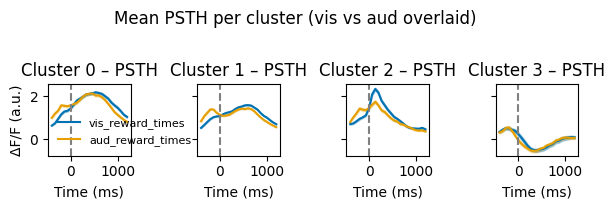

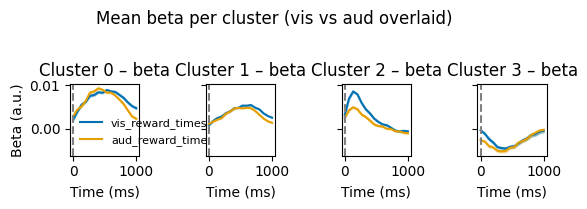

In [26]:
fig_psth, fig_beta = plot_cluster_psth_and_beta(
    agg_data=agg_data,
    all_meta=all_meta,
    labels=labels,
    global_unique_predictors=global_unique_predictors,
    psth_timepoint = psth_timepoint,
    beta_timepoint = beta_timepoint
)

In [27]:
fig_psth.savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig6', "cluster_avg_reward_psth.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)
fig_beta.savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig6', "cluster_avg_reward_beta.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

In [20]:
cluster_idx = {label: np.where(labels == label)[0] for label in np.unique(labels)}

In [ ]:
all_meta[0]['']

1300

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


mouse: AB_R2 date: 20250722_valvesilent arm: arm1
0.005089089715631477


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


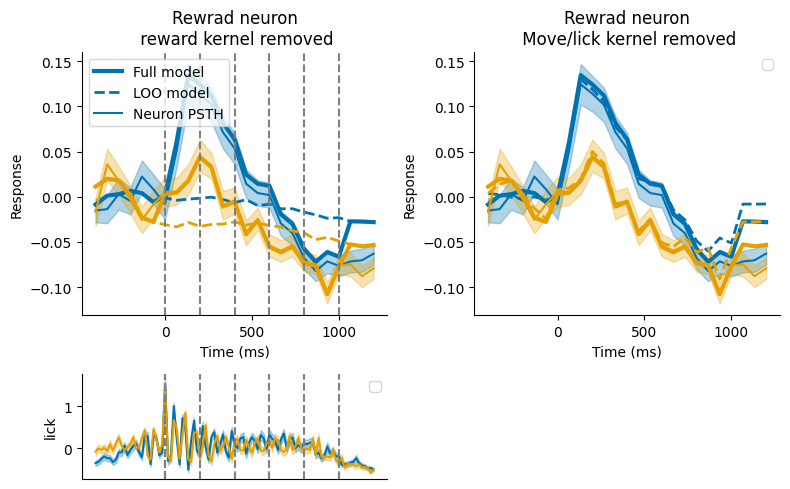

In [69]:

vis_color = '#0072B2'
aud_color = '#E69F00'
pred1 = 'vis_reward_times'
pred2 = 'aud_reward_times'
#sorted_indices = np.argsort(vis_reward_r2 - aud_reward_r2)[::-1]
# id = sorted_indices[-4]
cluster = 2
idx = np.random.choice(cluster_idx[cluster])
#print((vis_reward_r2 - aud_reward_r2)[id])
m = all_meta[idx]['mouse']
d = all_meta[idx]['date']
a = all_meta[idx]['arm']
i = all_meta[idx]['idx_in_arm']
print('mouse: '+m+' date: '+d+' arm: '+a)
neuron = agg_data[m][d][a]['stat'][i]
dm = agg_data[m][d][a]['design_matrix']
tf = agg_data[m][d][a]['table_for_img']
pred1_r2 = neuron['unique_explained_variance'][unique_predictors.index(pred1)]
pred2_r2 = neuron['unique_explained_variance'][unique_predictors.index(pred2)]

print(pred1_r2-pred2_r2)
# psth1 = vis_left_choice_psth_raw[id]
# psth2 = vis_right_choice_psth_raw[id]
fig, axes = plt.subplots(2, 2, gridspec_kw={'height_ratios': [5, 2]}, figsize=(8,5))
plot_loo_reconstruction(neuron, dm, tf, pred=pred1, full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[0,0], color = vis_color)

plot_loo_reconstruction(neuron, dm, tf, pred=pred2, full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[0,0], color = aud_color, label = False)

plot_loo_reconstruction(neuron, dm, tf, pred=pred1, loo_pred=['face', 'body', 'lick'], full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[0,1], color = vis_color, label = False)

plot_loo_reconstruction(neuron, dm, tf, pred=pred2, loo_pred=['face', 'body', 'lick'], full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[0,1], color = aud_color, label = False)

axes[0,0].legend(loc='upper left')
axes[0,0].set_title('Rewrad neuron\n reward kernel removed')
axes[0,1].set_title('Rewrad neuron\n Move/lick kernel removed')
#axes[0,0].title()

lick = agg_data[m][d]
lick = agg_data[m][d]['lick']
tf_v = agg_data[m][d]['table_for_video']
v_vis_reward_frame_idx = find_frame_indices(tf_v[tf_v['modality']==0], 60.4, (psth_time_start, psth_time_end), 'reward_consume_times').astype(int)
v_aud_reward_frame_idx = find_frame_indices(tf_v[tf_v['modality']==1], 60.4, (psth_time_start, psth_time_end), 'reward_consume_times').astype(int)
vis_reward_lick = get_trial_PSTH(np.expand_dims(lick[:,0], axis=0), v_vis_reward_frame_idx, zscore=True).squeeze()
aud_reward_lick = get_trial_PSTH(np.expand_dims(lick[:,0], axis=0), v_aud_reward_frame_idx, zscore=True).squeeze()
lick_timepoint = np.linspace(psth_time_start*1000,psth_time_end*1000,vis_reward_lick.shape[1])
plot_with_error_shading(vis_reward_lick, time_points=lick_timepoint, color=vis_color, ax=axes[1,0])
plot_with_error_shading(aud_reward_lick, time_points=lick_timepoint, color=aud_color, ax=axes[1,0])
axes[1,0].axvline(x=0, color='black', linestyle='--')
axes[1,0].set_xlabel('Time (ms)')
axes[1,0].set_ylabel('lick') 
axes[1,0].xaxis.set_visible(False) 
axes[1,1].axis('off')

vertline = [0, 200,400,600,800,1000]
for v in vertline:
    axes[0,0].axvline(v, color = 'gray', linestyle = '--')
    axes[1,0].axvline(v, color = 'gray', linestyle = '--')
plt.tight_layout()
plt.show()

In [65]:
fig.savefig(
    os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\pub_fig\Fig6', "example_cluster2_reward_psth.svg"),
    format='svg',
    dpi=300,
    bbox_inches='tight',
    transparent=True,   # optional: removes white background
    metadata={'Creator': 'Matplotlib'}
)

In [11]:
full_fm_proc = np.load(os.path.join(r'I:\Cerebellum_imaging_Dec2025\AE_L3\20250617_valvesilent\behavior\raw_video_data',
'_iblrig_leftCamera.raw_proc.npy'), allow_pickle = True).item()

In [13]:
full_fm_proc['motMask_reshape'][3].shape

(43, 91, 500)

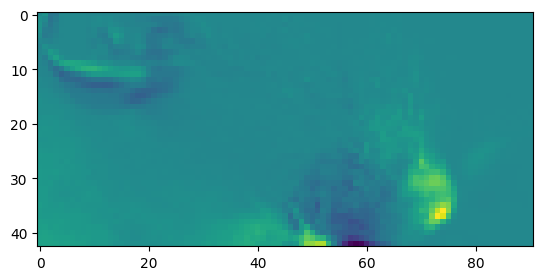

In [19]:
plt.imshow(full_fm_proc['motMask_reshape'][3][:,:,5])

In [5]:
def block_trial_indices(n_trials, block=10, first_k=5, drop_incomplete_block=True):
    """
    Returns two arrays of trial indices:
      - first_k trials of each `block`
      - last_k trials of each `block` (here last_k == first_k)
    """
    n_blocks = n_trials // block if drop_incomplete_block else int(np.ceil(n_trials / block))
    first_idx = []
    last_idx = []

    for b in range(n_blocks):
        start = b * block
        end = min(start + block, n_trials)

        if drop_incomplete_block and (end - start) < block:
            continue

        # first k: [start, start+1, ...]
        f = np.arange(start, min(start + first_k, end))
        # last k: [start+block-first_k, ..., start+block-1]
        l_start = max(start, end - first_k)
        l = np.arange(l_start, end)

        # If block is incomplete and you're not dropping, these may overlap; that's ok.
        first_idx.append(f)
        last_idx.append(l)

    if len(first_idx) == 0:
        return np.array([], dtype=int), np.array([], dtype=int)

    return np.concatenate(first_idx), np.concatenate(last_idx)


def get_neuron_psth_matrix(agg_data, mouse, date, arm, pred, use_raw=False):
    """
    Returns: psth_trials_per_neuron: list of arrays, each (n_trials, n_timepoints)
    """
    key = f"{pred}_psth_raw" if use_raw else f"{pred}_psth"
    stat_arr = agg_data[mouse][date][arm]["stat"]

    psths = []
    for st in stat_arr:
        if key in st:
            psths.append(np.asarray(st[key]))
        else:
            psths.append(None)

    # keep only neurons that have this psth key
    valid = [(i, p) for i, p in enumerate(psths) if p is not None and p.ndim == 2 and p.shape[0] > 0]
    if len(valid) == 0:
        raise ValueError(f"No neurons found with key '{key}' for {mouse} {date} {arm}")

    neuron_ids = [i for i, _ in valid]
    psth_list = [p for _, p in valid]
    return neuron_ids, psth_list


def plot_first_vs_last5_heatmaps(
    agg_data,
    mouse,
    date,
    arm,
    pred="vis_ruleCue_times",
    use_raw=False,
    block=10,
    k=5,
    drop_incomplete_block=True,
    sort_by="diff_peak",   # None, 'first_peak', 'last_peak', 'diff_peak'
):
    """
    Heatmaps:
      left: mean PSTH over first k trials of each block
      right: mean PSTH over last  k trials of each block
    Rows = neurons, Cols = timepoints
    """
    neuron_ids, psth_list = get_neuron_psth_matrix(agg_data, mouse, date, arm, pred, use_raw=use_raw)

    # assume all neurons share same n_trials and n_timepoints (true in your pipeline)
    n_trials = psth_list[0].shape[0]
    n_time = psth_list[0].shape[1]

    first_idx, last_idx = block_trial_indices(
        n_trials, block=block, first_k=k, drop_incomplete_block=drop_incomplete_block
    )
    if first_idx.size == 0 or last_idx.size == 0:
        raise ValueError(f"Not enough trials to form blocks of {block} (n_trials={n_trials}).")

    first_mat = np.zeros((len(psth_list), n_time), dtype=float)
    last_mat  = np.zeros((len(psth_list), n_time), dtype=float)

    for i, psth in enumerate(psth_list):
        # safety: if some neuron has fewer trials (rare), clip indices
        ni = psth.shape[0]
        fi = first_idx[first_idx < ni]
        li = last_idx[last_idx < ni]
        if fi.size == 0 or li.size == 0:
            first_mat[i, :] = np.nan
            last_mat[i, :] = np.nan
        else:
            first_mat[i, :] = np.nanmean(psth[fi, :], axis=0)
            last_mat[i, :]  = np.nanmean(psth[li, :], axis=0)

    # optional sorting
    if sort_by is not None:
        if sort_by == "first_peak":
            order = np.nanmax(first_mat, axis=1)
            sort_ix = np.argsort(order)
        elif sort_by == "last_peak":
            order = np.nanmax(last_mat, axis=1)
            sort_ix = np.argsort(order)
        elif sort_by == "diff_peak":
            diff = last_mat - first_mat
            order = np.nanmax(diff, axis=1)
            sort_ix = np.argsort(order)
        else:
            raise ValueError("sort_by must be None, 'first_peak', 'last_peak', or 'diff_peak'")
        first_mat = first_mat[sort_ix, :]
        last_mat  = last_mat[sort_ix, :]
        neuron_ids = [neuron_ids[i] for i in sort_ix]

    # shared color scale
    vmin = np.nanmin([first_mat.min(), last_mat.min()])
    vmax = np.nanmax([first_mat.max(), last_mat.max()])

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
    im0 = axes[0].imshow(first_mat, aspect="auto", interpolation="nearest", vmin=vmin, vmax=vmax)
    axes[0].set_title(f"{mouse} {date} {arm}\n{pred}: first {k} of each {block}")
    axes[0].set_xlabel("timepoints")
    axes[0].set_ylabel("neurons")

    im1 = axes[1].imshow(last_mat, aspect="auto", interpolation="nearest", vmin=vmin, vmax=vmax)
    axes[1].set_title(f"{mouse} {date} {arm}\n{pred}: last {k} of each {block}")
    axes[1].set_xlabel("timepoints")
    axes[1].set_ylabel("neurons")

    cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.9)
    cbar.set_label("PSTH (z-scored)" if not use_raw else "PSTH (raw)")

    return fig, axes, first_mat, last_mat, neuron_ids, first_idx, last_idx

In [ ]:
agg_data['AE_L2']['']

(132, 25)

In [7]:
a,b = block_trial_indices(132)

In [8]:
b

array([  5,   6,   7,   8,   9,  15,  16,  17,  18,  19,  25,  26,  27,
        28,  29,  35,  36,  37,  38,  39,  45,  46,  47,  48,  49,  55,
        56,  57,  58,  59,  65,  66,  67,  68,  69,  75,  76,  77,  78,
        79,  85,  86,  87,  88,  89,  95,  96,  97,  98,  99, 105, 106,
       107, 108, 109, 115, 116, 117, 118, 119, 125, 126, 127, 128, 129])

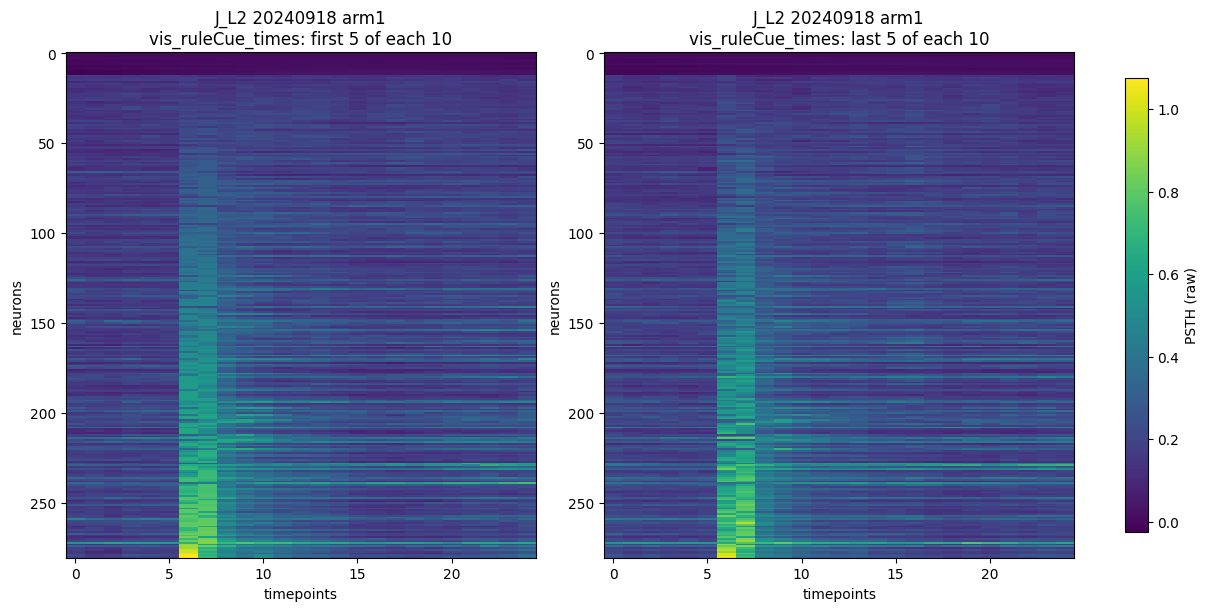

In [31]:
fig, axes, first_mat, last_mat, neuron_ids, first_idx, last_idx = plot_first_vs_last5_heatmaps(
    agg_data,
    mouse="J_L2",
    date="20240918",
    arm="arm1",
    pred="vis_ruleCue_times",
    use_raw=True,          # or True if you want *_psth_raw
    block=10,
    k=5,
    drop_incomplete_block=True,
    sort_by="first_peak",
)
plt.show()

In [22]:
first_mat[-1,:]

array([0.13793131, 0.13266754, 0.16685178, 0.13550313, 0.14362018,
       0.11896975, 1.021553  , 0.6064194 , 0.32976224, 0.2285596 ,
       0.20516068, 0.172692  , 0.17100458, 0.15520548, 0.12240804,
       0.16366002, 0.12266426, 0.12689033, 0.1192416 , 0.11377015,
       0.12422953, 0.1435881 , 0.16725492, 0.13506817, 0.15683536])

In [23]:
last_mat[-1,:]

array([0.13257217, 0.13261298, 0.15971254, 0.17922362, 0.16126939,
       0.16598429, 1.02714824, 0.54417654, 0.29846487, 0.21919649,
       0.20407179, 0.1482499 , 0.14864388, 0.17015965, 0.14881396,
       0.14798601, 0.12842204, 0.16365614, 0.1477526 , 0.13601709,
       0.10913316, 0.14969494, 0.1190791 , 0.14729979, 0.14144162])

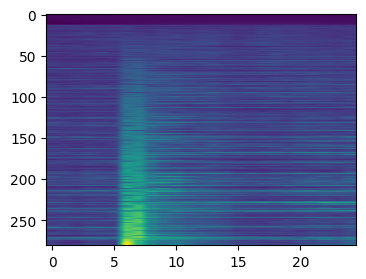

In [32]:

plt.figure(figsize=(4, 3))
plt.imshow(first_mat, aspect='auto')

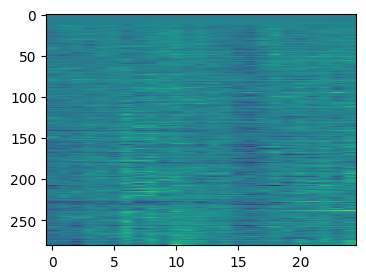

In [33]:
plt.figure(figsize=(4, 3))
plt.imshow(first_mat - last_mat, aspect='auto')